## 0. Page de garde

| Champ | Valeur |
|---|---|
| Titre du projet | **Détection de résiliation client SaaS B2B** — anticiper le départ des comptes clients pour cibler les actions de rétention |
| Certification visée | **CISIA** — Concevoir et implémenter une solution d'intelligence artificielle |
| Nom et prénom | Laurent Pottier |
| Date de remise | 05/10/2026 |
| Version du notebook | 2.0.0 |
| Code source public | <https://github.com/laurent-git-dev/churn_saas_release> |

### Environnement d'exécution

Le notebook s'exécute de bout en bout : les versions ci-dessous sont relevées à l'exécution, et
couvrent chaque étape du cycle de vie, des données brutes à la supervision en production.

In [1]:
import hashlib
import os
import subprocess
import sys
import warnings
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

import pandas as pd
from IPython.display import display
from loguru import logger

from churn_saas import config
from churn_saas.format_fr import configurer_pandas, entier
from churn_saas.referentiel import grille_competences

# Tous les tableaux du notebook affichent leurs nombres au format français (« 0,28 », « 5 035 »)
configurer_pandas()

# Journal limité aux avertissements et erreurs : les messages DEBUG et INFO des modules
# (plusieurs milliers) noieraient les résultats. Ils restent actifs hors notebook (CLI, API, tests).
logger.remove()
logger.add(sys.stderr, level="WARNING")
# Les processus parallèles (n_jobs=-1 : validation croisée, forêts, permutation) réimportent
# loguru avec son niveau par défaut, DEBUG, et écrivent directement dans le terminal : ils
# lisent le niveau dans l'environnement, hérité au moment où ils sont lancés
os.environ["LOGURU_LEVEL"] = "WARNING"
# mlflow importe tqdm.auto, qui réclame ipywidgets pour ses barres de progression : on garde les
# barres texte et on masque ce seul avertissement, sans toucher aux autres
warnings.filterwarnings("ignore", message="IProgress not found")


def version_installee(paquet: str) -> str:
    try:
        return version(paquet)
    except PackageNotFoundError:
        return "non installé"


# (étape du cycle de vie, bibliothèque, rôle)
BIBLIOTHEQUES = [
    ("Données (§3, §5)", "pandas", "Chargement, nettoyage, tableaux"),
    ("Données (§3, §5)", "numpy", "Calcul numérique"),
    ("Données (§3, §5)", "pyarrow", "Stockage colonnaire Parquet"),
    ("Données (§3, §5)", "dvc", "Versionnement des jeux de données"),
    ("Analyse exploratoire (§6)", "scipy", "Tests statistiques"),
    ("Analyse exploratoire (§6)", "matplotlib", "Figures"),
    ("Modélisation (§7 à §9)", "scikit-learn", "Pipelines, modèles, validation croisée"),
    ("Modélisation (§7 à §9)", "imbalanced-learn", "Rééquilibrage des classes"),
    ("Modélisation (§7 à §9)", "lightgbm", "Famille concurrente optimisée (boosting de gradient)"),
    ("Modélisation (§7 à §9)", "optuna", "Optimisation des hyperparamètres"),
    ("Suivi et explicabilité (§9, §12)", "mlflow", "Suivi des expériences, registre de modèles"),
    ("Suivi et explicabilité (§9, §12)", "skops", "Sérialisation sûre du modèle"),
    ("Suivi et explicabilité (§9, §12)", "shap", "Explication des prédictions"),
    ("Suivi et explicabilité (§9, §12)", "codecarbon", "Mesure de l'empreinte carbone"),
    ("Mise en exploitation (§10, §11)", "fastapi", "API de prédiction"),
    ("Mise en exploitation (§10, §11)", "pydantic", "Validation des requêtes"),
    ("Mise en exploitation (§10, §11)", "uvicorn", "Serveur de l'API"),
    ("Mise en exploitation (§10, §11)", "prefect", "Orchestration du scoring et du réentraînement"),
    ("Supervision (§13)", "evidently", "Détection de dérive des données"),
    ("Supervision (§13)", "prometheus-fastapi-instrumentator", "Métriques de l'API"),
    ("Reproductibilité", "jupytext", "Génération du notebook depuis les sources"),
]
# Hash git courant : identifie la version exacte du code exécuté
try:
    git_hash = (
        subprocess.run(
            ["git", "rev-parse", "--short", "HEAD"], capture_output=True, text=True
        ).stdout.strip()
        or "inconnu"
    )
except Exception:
    git_hash = "inconnu"

python = f"{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}"
env_df = pd.DataFrame(
    [("Environnement", "Python", f"Langage ({sys.platform})", python)]
    + [("Environnement", "Commit git", "Version exacte du code exécuté", git_hash)]
    + [(etape, p, role, version_installee(p)) for etape, p, role in BIBLIOTHEQUES],
    columns=["Étape du cycle de vie", "Bibliothèque", "Rôle", "Version installée"],
)
display(env_df.style.hide(axis="index").set_properties(**{"text-align": "left"}))

Étape du cycle de vie,Bibliothèque,Rôle,Version installée
Environnement,Python,Langage (linux),3.12.13
Environnement,Commit git,Version exacte du code exécuté,2d39374
"Données (§3, §5)",pandas,"Chargement, nettoyage, tableaux",3.0.6
"Données (§3, §5)",numpy,Calcul numérique,2.5.3
"Données (§3, §5)",pyarrow,Stockage colonnaire Parquet,25.0.1
"Données (§3, §5)",dvc,Versionnement des jeux de données,3.67.1
Analyse exploratoire (§6),scipy,Tests statistiques,1.18.1
Analyse exploratoire (§6),matplotlib,Figures,3.11.2
Modélisation (§7 à §9),scikit-learn,"Pipelines, modèles, validation croisée",1.9.1
Modélisation (§7 à §9),imbalanced-learn,Rééquilibrage des classes,0.14.2


### Empreinte des données brutes

Pour s'assurer que les résultats ont été obtenus sur exactement les mêmes fichiers, on calcule
l'empreinte SHA-256 de chacun : une suite de 64 caractères qui change dès qu'un seul octet du
fichier est modifié. Une relance sur des données identiques doit retrouver les mêmes empreintes.

In [2]:
FICHIERS_BRUTS = ["churn_saas_complet.csv", "churn_saas_echantillon.csv", "catalogue_plans.csv"]


def empreinte_sha256(chemin: Path) -> str:
    with chemin.open("rb") as flux:
        return hashlib.file_digest(flux, "sha256").hexdigest()


empreintes_df = pd.DataFrame(
    [
        (
            f"data/raw/{nom}",
            entier((config.DONNEES_BRUTES / nom).stat().st_size),
            empreinte_sha256(config.DONNEES_BRUTES / nom),
        )
        for nom in FICHIERS_BRUTS
    ],
    columns=["Fichier", "Taille (octets)", "Empreinte SHA-256"],
)
display(empreintes_df.style.hide(axis="index").set_properties(**{"text-align": "left"}))

Fichier,Taille (octets),Empreinte SHA-256
data/raw/churn_saas_complet.csv,727 622,2fc45e8c3c74d3ddcdbda162c5bb50184587201b46d877cc06742afd13063844
data/raw/churn_saas_echantillon.csv,7 824,680f5371c406f47a3a67f1611cb016c17efd61e93a52d1b4b8dbd3a39dc2f296
data/raw/catalogue_plans.csv,203,c94f6f52652532c578cb7a44d752b8b197ef84f5e6c6e17a58579fa195e9ad08


### Grille de couverture des compétences C1 → C9

À titre indicatif : chaque compétence du référentiel est rattachée aux sections du notebook qui
en apportent la preuve. La grille est recalculée à chaque exécution à partir des titres réels du
notebook ; le détail item par item figure en annexe §15.

In [3]:
display(
    grille_competences()[["Compétence", "Intitulé", "Items", "Section(s)"]]
    .style.hide(axis="index")
    .set_properties(**{"text-align": "left"})
)

Compétence,Intitulé,Items,Section(s)
C1,Identifier un jeu de données répondant aux besoins métiers,5,"§2, §3"
C2,Identifier les risques éthiques et sociétaux,6,§4
C3,Préparer les données,7,"§3, §5, §7"
C4,Choisir un modèle IA,10,"§8, §12"
C5,Entraîner le modèle,6,"§7, §9"
C6,Implémenter le modèle,3,§10
C7,Architecture cible,3,§11
C8,Mesurer la performance et les impacts,4,"§8, §12, §13"
C9,Amélioration continue,3,§13


## 1. Résumé exécutif

Une page pour décider : le problème, la démarche, trois chiffres clés, la recommandation et
les limites. Chaque chiffre est calculé ici à partir des résultats produits plus loin (§9 à
§12) ; la section citée entre parenthèses donne le détail.

> **Note de lecture.** `make notebook` exécute cette section en dernier puis l'affiche en
> tête : ses chiffres viennent de la même exécution que le reste, d'où ses numéros
> d'exécution (`[n]`) plus élevés.

In [176]:
import warnings

from IPython.display import Markdown, display

from churn_saas import config
from churn_saas.format_fr import entier, euros, nombre, pourcentage
from churn_saas.models.economics import table_deux_niveaux
from churn_saas.synthese import charger_synthese

warnings.filterwarnings("ignore")

# Mêmes chiffres que la conclusion (§14) : même fonction de synthèse, mêmes artefacts. S'il en
# manque un, la section s'arrête au lieu d'afficher des valeurs de substitution.
synthese = charger_synthese()
y = synthese.y
_cap = synthese.capacite
_pr_b1 = float(synthese.comparaison_modeles["pr_auc_mean"].get("B1 — Règle métier", float("nan")))
_cibles = config.CIBLES_PERFORMANCE
deux_niveaux = table_deux_niveaux(y, synthese.proba_oof, synthese.mrr)  # règle du §12.6
vigilance, appels = deux_niveaux.iloc[0], deux_niveaux.iloc[1]
_annuel = synthese.gain_annuel
_mensuel = _annuel["mensuel"]
_test = synthese.test  # note du jeu de test (§9.14)

### 1.1 Le problème métier

In [177]:
display(Markdown(f"""
Un éditeur SaaS B2B suit **{entier(len(y))} comptes** (PME et grandes entreprises
européennes, abonnements annuels) ; **{pourcentage(y.mean(), 1)}** sont partis sur
l'historique. Son équipe Customer Success (CS), trois chargés de clientèle (CSM), ne peut mener
qu'environ **{_cap} actions de rétention par mois**, et les signaux de départ sont repérés trop
tard, quand le client a déjà décidé. L'objectif : un **score de risque de départ** recalculé
chaque nuit, pour placer ces actions là où elles rapportent le plus, avant l'échéance du
contrat (§2).
"""))


Un éditeur SaaS B2B suit **5 000 comptes** (PME et grandes entreprises
européennes, abonnements annuels) ; **28,0 %** sont partis sur
l'historique. Son équipe Customer Success (CS), trois chargés de clientèle (CSM), ne peut mener
qu'environ **45 actions de rétention par mois**, et les signaux de départ sont repérés trop
tard, quand le client a déjà décidé. L'objectif : un **score de risque de départ** recalculé
chaque nuit, pour placer ces actions là où elles rapportent le plus, avant l'échéance du
contrat (§2).


**Ce qu'il faut retenir.** La ressource rare n'est pas la donnée mais le temps des CSM. Le
modèle ne remplace pas leur jugement : il leur dit **qui regarder et qui appeler en premier**.

### 1.2 La démarche

- **Assainir avant de calculer (§5 à §7).** Doublons, valeurs impossibles et formats
  incohérents sont corrigés. Surtout, le data leakage (fuite de données) est écarté : des
  colonnes qui « connaissent » déjà la réponse, comme un indicateur de santé calculé *après*
  la résiliation (§6.5) ou des commentaires CSM sans date fiable (§6.6). Trois variables
  *leurres*, sans lien avec le départ, sont détectées puis retirées (§12.9).
- **Battre une règle simple (§8, §9).** Deux baselines (références de base) sans
  apprentissage — le hasard et une règle métier applicable dans le CRM — sont comparées à
  trois modèles (régression logistique, forêt aléatoire, LightGBM) sur les mêmes découpages
  de cross-validation (validation croisée). Toute transformation est apprise à l'intérieur de
  chaque découpage : rien du jeu d'évaluation ne fuit vers le modèle.
- **Juger sur des comptes jamais vus (§9.14).** Un jeu de test, mis de côté avant tout choix,
  n'est ouvert qu'une fois, pour noter le modèle retenu : c'est sa note de référence.
- **Préférer le plus simple (§9.3.1).** Un modèle plus complexe n'est retenu que s'il fait
  significativement mieux, d'un écart minimal fixé à l'avance.
- **Décider en deux niveaux (§12.6).** Un seul seuil ne peut pas à la fois manquer peu de
  partants et respecter la capacité de l'équipe. Le niveau 1 (*vigilance*) surveille
  largement pour limiter les partants manqués ; le niveau 2 (*appels*) y choisit les comptes
  où une action rapporte le plus (probabilité × valeur du compte − coût de l'action).

**Ce qu'il faut retenir.** Les règles du jeu (mesures, seuils, protocole) sont fixées *avant*
de voir les résultats : on cherche une liste d'appels fiable et un outil maintenable par une
petite équipe, pas le meilleur score possible.

### 1.3 Trois chiffres clés

La qualité du modèle est mesurée sur le **jeu de test** : des comptes qu'aucun choix n'a vus,
comme un compte nouveau en production ; l'intervalle de confiance à 95 % donne la marge
d'incertitude. Volumes et euros portent sur tout le portefeuille, mesurés *out-of-fold* (hors
pli) : chaque compte y est noté par un modèle qui ne l'a pas vu à l'entraînement.

In [178]:
display(Markdown(f"""
| Question | Chiffre clé | Repère |
|---|---|---|
| Le modèle ({synthese.nom_modele_final}) sait-il repérer les partants ? | **ROC-AUC {nombre(_test["roc_auc"]["valeur"], 3)}** [{nombre(_test["roc_auc"]["ic_bas"], 2)} ; {nombre(_test["roc_auc"]["ic_haut"], 2)}] · PR-AUC {nombre(_test["pr_auc"]["valeur"], 3)} [{nombre(_test["pr_auc"]["ic_bas"], 2)} ; {nombre(_test["pr_auc"]["ic_haut"], 2)}], jeu de test | Cibles fixées à l'avance : {nombre(_cibles["roc_auc_min"], 2)} et {nombre(_cibles["pr_auc_min"], 2)} · règle métier : PR-AUC {nombre(_pr_b1, 3)} · hasard : {nombre(y.mean(), 2)} (§9.3, §9.14) |
| Combien de comptes surveiller pour manquer peu de partants ? | **{pourcentage(vigilance["part_portefeuille"], 0)} du portefeuille** ({entier(vigilance["n_comptes"])} comptes) pour un recall de {pourcentage(vigilance["recall"], 0)} | Recall (rappel) visé : {pourcentage(config.RECALL_CIBLE_VIGILANCE, 0)}, tenu sur le jeu de test ({pourcentage(_test["recall"]["valeur"], 0)}) ; {entier(vigilance["n_faux_negatifs"])} partants restent hors surveillance (§12.6) |
| Que rapporte le modèle sur un an ? | **{euros(_annuel["annuel"])}** de marge espérée | De {euros(_annuel["annuel_min"])} à {euros(_annuel["annuel_max"])} selon le taux de succès des actions, par rapport à une équipe qui appelle ses plus gros comptes (§12.12) |
"""))


| Question | Chiffre clé | Repère |
|---|---|---|
| Le modèle (régression logistique optimisée et recalibrée) sait-il repérer les partants ? | **ROC-AUC 0,881** [0,86 ; 0,90] · PR-AUC 0,760 [0,71 ; 0,80], jeu de test | Cibles fixées à l'avance : 0,80 et 0,65 · règle métier : PR-AUC 0,408 · hasard : 0,28 (§9.3, §9.14) |
| Combien de comptes surveiller pour manquer peu de partants ? | **36 % du portefeuille** (1 813 comptes) pour un recall de 80 % | Recall (rappel) visé : 80 %, tenu sur le jeu de test (82 %) ; 280 partants restent hors surveillance (§12.6) |
| Que rapporte le modèle sur un an ? | **1 451 797 €** de marge espérée | De 967 865 € à 1 935 730 € selon le taux de succès des actions, par rapport à une équipe qui appelle ses plus gros comptes (§12.12) |


In [179]:
_atteintes = sum(_test[m]["valeur"] >= _cibles[f"{m}_min"] for m in ("roc_auc", "pr_auc"))
_verdict = {2: "atteint ses deux cibles", 1: "n'atteint qu'une de ses deux cibles"}.get(
    _atteintes, "n'atteint aucune de ses cibles"
)
_arbres = synthese.comparaison_modeles["pr_auc_mean"].reindex(["Forêt aléatoire", "LightGBM"])
_ecart = synthese.protocole["pr_auc_mean"] - _arbres.max()
_simple = (
    f"Ce modèle linéaire, le plus simple, devance même les modèles à arbres "
    f"({nombre(_ecart, 3, signe=True)} de PR-AUC) : la complexité n'apportait rien ici. "
    if _ecart > 0 and "logistique" in synthese.nom_modele_final
    else ""
)
display(Markdown(f"""
**Ce qu'il faut retenir.** Sur des comptes jamais vus, le classement {_verdict}, fixées
avant l'entraînement, et fait nettement mieux que la règle métier, sa vraie concurrente.
{_simple}Un partant reçoit un score plus haut qu'un client fidèle dans {pourcentage(_test["roc_auc"]["valeur"], 0)} des cas (hasard : 50 %). Le
niveau 1 ramène la surveillance à {entier(vigilance["n_comptes"])} comptes ; le niveau 2 n'en
appelle que {entier(appels["n_comptes"])} par mois, avec une precision (part de vrais partants)
de {pourcentage(appels["precision"], 0)}. Sur un an, le modèle contacte
{entier(_mensuel["n_churners_modele"].sum())} partants contre
{entier(_mensuel["n_churners_reference"].sum())} sans lui ; son gain annuel vaut
{nombre(_annuel["annuel"] / _annuel["premier_mois"], 1)} fois le premier mois, et non 12 fois,
car les comptes à fort enjeu ne se présentent qu'une fois : **il les atteint surtout plus tôt**.
{entier(synthese.n_rentables)} comptes justifieraient une action rentable pour {_cap}
possibles : **la limite est la capacité de l'équipe**, pas le modèle (§12.7).
"""))


**Ce qu'il faut retenir.** Sur des comptes jamais vus, le classement atteint ses deux cibles, fixées
avant l'entraînement, et fait nettement mieux que la règle métier, sa vraie concurrente.
Ce modèle linéaire, le plus simple, devance même les modèles à arbres (+0,026 de PR-AUC) : la complexité n'apportait rien ici. Un partant reçoit un score plus haut qu'un client fidèle dans 88 % des cas (hasard : 50 %). Le
niveau 1 ramène la surveillance à 1 813 comptes ; le niveau 2 n'en
appelle que 45 par mois, avec une precision (part de vrais partants)
de 69 %. Sur un an, le modèle contacte
281 partants contre
116 sans lui ; son gain annuel vaut
1,1 fois le premier mois, et non 12 fois,
car les comptes à fort enjeu ne se présentent qu'une fois : **il les atteint surtout plus tôt**.
3 059 comptes justifieraient une action rentable pour 45
possibles : **la limite est la capacité de l'équipe**, pas le modèle (§12.7).


### 1.4 Recommandation

1. **Déployer le calcul nocturne des scores** et la règle à deux niveaux : les comptes en
   vigilance alimentent la revue hebdomadaire du portefeuille et des actions automatisées ;
   les appels CSM du mois suivent la liste du niveau 2 (§10, §14.2).
2. **Mettre en place un groupe témoin dès le premier mois** : une petite part des comptes à
   risque, tirée au sort et laissée sans action. Sans lui, impossible de mesurer l'effet réel
   des actions, puisqu'elles modifient l'issue des comptes contactés (§4.5).
3. **Valider les hypothèses économiques** (taux de succès d'une action, revenu des gros
   comptes) et **fixer avec le métier l'horizon du départ** à prédire avant le prochain
   réentraînement (§14.4).

**Ce qu'il faut retenir.** Le modèle est prêt pour un déploiement progressif ; les montants en
euros resteront des estimations tant que le groupe témoin n'aura pas mesuré l'effet réel des
actions. *Le modèle classe, le CSM décide* : aucune action n'est déclenchée sans humain.

### 1.5 Limites principales

In [180]:
display(Markdown(f"""
| Limite | Conséquence | Réponse prévue |
|---|---|---|
| Horizon du départ non défini, une seule extraction datée | Pas de validation sur une période future (§6.11) | Horizon fixé avec le métier ; validation sur les extractions successives (§13.7) |
| Un départ ne s'observe qu'à l'échéance du contrat | Performance non mesurable en temps réel | Surveillance de la dérive des données (§13.3), puis bilan par vague de renouvellements (§13.7) |
| Taux de succès d'une action ({pourcentage(config.HYPOTHESES_ECONOMIQUES["taux_succes_retention"], 0)}) issu d'un rapport sectoriel | Les euros sont conditionnels | Sensibilité (§12.7) ; mesure par le groupe témoin |
| Gain concentré sur les comptes à fort revenu, simulé à portefeuille figé | Une erreur sur leur revenu fausserait le bilan | Contrôle sièges × prix catalogue (§12.12) ; validation par la Finance (§14.4) |
| Probabilités et seuil de vigilance réglés sur la part actuelle de partants | Si elle change, scores, seuil et euros se décalent | Contrôle du recall à chaque vague, réglage au réentraînement (§13.8) |
"""))


| Limite | Conséquence | Réponse prévue |
|---|---|---|
| Horizon du départ non défini, une seule extraction datée | Pas de validation sur une période future (§6.11) | Horizon fixé avec le métier ; validation sur les extractions successives (§13.7) |
| Un départ ne s'observe qu'à l'échéance du contrat | Performance non mesurable en temps réel | Surveillance de la dérive des données (§13.3), puis bilan par vague de renouvellements (§13.7) |
| Taux de succès d'une action (30 %) issu d'un rapport sectoriel | Les euros sont conditionnels | Sensibilité (§12.7) ; mesure par le groupe témoin |
| Gain concentré sur les comptes à fort revenu, simulé à portefeuille figé | Une erreur sur leur revenu fausserait le bilan | Contrôle sièges × prix catalogue (§12.12) ; validation par la Finance (§14.4) |
| Probabilités et seuil de vigilance réglés sur la part actuelle de partants | Si elle change, scores, seuil et euros se décalent | Contrôle du recall à chaque vague, réglage au réentraînement (§13.8) |


**Ce qu'il faut retenir.** Aucune de ces limites n'invalide le modèle : les premières touchent
à la **mesure** (horizon, délai d'observation), les suivantes aux **montants en euros**. Le
groupe témoin et la fixation de l'horizon répondent aux deux ; la liste complète est en §14.3.

> ### 📋 Journal de bord — Résumé exécutif
>
> **Décisions retenues** — Cinq blocs pour un décideur, trois chiffres clés alignés sur les
> mesures co-principales : qualité du classement (ROC-AUC, PR-AUC) et recall au seuil de
> vigilance, lus sur le jeu de test (§9.14), puis valeur annuelle. Tout est relu depuis les
> artefacts de §9 et §12 par la même fonction que la conclusion (§14).
>
> **Alternatives écartées** — Chiffres écrits à la main : faux dès la régénération suivante.
> Meilleure valeur d'Optuna : optimiste (§9.7). Mesure hors pli comme note de référence : la
> sélection du modèle a vu ces comptes. Gain du seul premier mois : il invitait à
> multiplier par 12. ROI face à « ne rien faire » : ordre de grandeur peu crédible, laissé au
> §12.12.
>
> **Difficultés rencontrées** — La première version relisait des résultats calculés plus loin
> (§9, §12) et plantait sur une exécution vierge ; le repli sur des valeurs de substitution
> affichait des euros fictifs, remplacé par un arrêt explicite. La note de référence a changé
> deux fois (protocole, hors pli, puis test) : la sélection avait déjà vu ces comptes.
>
> **Impact sur la suite** — Point d'entrée du lecteur ; il reste aligné sur la conclusion.

## 2. Cadrage métier et cas d'usage

Avant toute ligne de code, il faut répondre à la question : *pourquoi* ce projet ? Cette section
identifie le besoin, décrit trois cas d'usage, chiffre la valeur attendue, traduit le besoin en
problème de machine learning et pose les hypothèses métier que l'exploration (§6) confrontera
aux données.

### 2.1 Contexte de l'éditeur SaaS B2B

L'éditeur vend une plateforme **SaaS B2B** à des PME et grandes entreprises européennes, sur
abonnement annuel à renouvellement tacite. Sa croissance repose sur l'acquisition de comptes et
sur leur **rétention** : chaque **churn (résiliation)** fait perdre un revenu récurrent.

**Problème.** L'équipe Customer Success (CS) suit environ 5 000 comptes : à ce volume, le suivi
manuel est impossible et les signaux arrivent souvent après la décision du client.

**Finalité.** Un **score d'aide à la priorisation** : il classe les comptes par risque pour que
l'équipe CS agisse avant l'échéance. Il ne prend **aucune décision automatique** : le CSM
(gestionnaire du compte) choisit toujours l'action.

### 2.2 Trois cas d'usage opérationnels

| Dimension | 1. Revue hebdomadaire du portefeuille | 2. Alerte sur signal faible | 3. Préparation d'un renouvellement |
|---|---|---|---|
| **Qui** | Le CS Lead (responsable de l'équipe) | Le CSM du compte | Le CSM, avec le CS Lead si MRR ≥ 5 000 € |
| **Quand** | Lundi, avant la réunion de 9 h | Chaque matin, si un compte ≥ 1 000 € de MRR passe en `ALERTE_ROUGE` | 90 jours avant l'échéance du contrat |
| **Décision** | Choisir les 10 comptes prioritaires de chaque CSM | Contact proactif sous 48 h | Stratégie de renouvellement : migration de plan, remise, formation, escalade |
| **Donnée reçue** | Liste triée par score décroissant, variation sur 7 jours, MRR, CSM en charge | Notification CRM : score, score à J−7, 3 variables les plus contributives (SHAP), derniers tickets | Fiche compte : score, valeur vie estimée (CLV), variables explicatives |
| **Mode de calcul** | Batch (traitement par lot) nocturne ; passage du dimanche disponible à 8 h 30 | Même batch, alertes dans le CRM avant 6 h | API appelée à l'ouverture de la fiche, 95 % des réponses en moins de 200 ms |
| **Valeur** | Préparation de 2 h ramenée à 15 min ; fin du choix « de mémoire » | Agir avant que l'inactivité ne devienne irréversible | Meilleur renouvellement des comptes à forte valeur |

**Ce qu'il faut retenir.** Les sources n'étant rafraîchies qu'une fois par jour, un calcul
« temps réel » n'apporterait aucun signal nouveau : le batch nocturne sert les cas 1 et 2,
l'API ne sert qu'à la consultation à l'écran (cas 3).

### 2.3 Hypothèses

| Hypothèse économique | Valeur | Source |
|---|---|---|
| Marge brute SaaS B2B | 72 % | OpenView Partners, *SaaS Benchmarks* 2023 |
| Coût horaire CSM chargé | 55 €/h | Glassdoor 2024 × coefficient de charges 1,45 |
| Durée d'un geste de rétention | 2 h | Cadrage : préparation, appel, suivi CRM (à mesurer en production) |
| Taux de succès d'un geste | 30 % | Gainsight, *Customer Success Report* 2023 |
| Horizon de valeur | 12 mois | Contrats annuels |
| Capacité mensuelle CS | 45 gestes | Cadrage : 3 CSM × 15 gestes par mois (~20 % de leur temps) |
| Portefeuille : comptes, taux de churn, MRR médian | 5 000 ; 28 % ; 450 € | Commanditaire (`config.PORTEFEUILLE_CADRAGE`), vérifié en §12 |

**Ce qu'il faut retenir.** Ces valeurs sont rangées dans `config.HYPOTHESES_ECONOMIQUES` et
`config.PORTEFEUILLE_CADRAGE` : tout calcul les lit de là, et §12 les confronte aux mesures.

### 2.4 Valeur attendue chiffrée

On veut savoir combien rapporte un meilleur ciblage. Un geste de rétention ne sauve un compte
que s'il vise un vrai churner : la valeur du modèle tient donc à la part de vrais churners
parmi les comptes contactés. Sans modèle, cette part vaut le taux de churn (choix au hasard) ;
au cadrage, on retient pour le modèle la cible de PR-AUC (aire sous la courbe
précision-rappel), mesurée réellement en §12.

In [4]:
import pandas as pd
from IPython.display import Markdown, display

from churn_saas import config
from churn_saas.format_fr import entier, euros, nombre, pourcentage

hyp = config.HYPOTHESES_ECONOMIQUES
portefeuille = config.PORTEFEUILLE_CADRAGE
taux_churn_observe = float(portefeuille["taux_churn"])
gestes_par_an = int(hyp["capacite_gestes_mois"]) * 12
valeur_par_compte_sauve_eur = float(portefeuille["mrr_median_eur"]) * hyp["horizon_mois"]
precision_ciblage_cadrage = config.CIBLES_PERFORMANCE["pr_auc_min"]
taux_sauvetage_avec_modele = precision_ciblage_cadrage * hyp["taux_succes_retention"]
taux_sauvetage_sans_modele = taux_churn_observe * hyp["taux_succes_retention"]
cout_gestes_an_eur = gestes_par_an * hyp["cout_horaire_csm_eur"] * hyp["duree_geste_retention_h"]
# Marge brute du revenu sauvé si chaque geste sauvait son compte ; le temps CSM est une charge
# déduite en totalité, identique avec ou sans modèle : il s'annule dans le gain incrémental
marge_potentielle_eur = gestes_par_an * valeur_par_compte_sauve_eur * hyp["marge_brute_pct"]
valeur_nette_an_eur = taux_sauvetage_avec_modele * marge_potentielle_eur - cout_gestes_an_eur
gain_incremental_eur = (
    taux_sauvetage_avec_modele - taux_sauvetage_sans_modele
) * marge_potentielle_eur
display(
    Markdown(
        "| Grandeur | Valeur |\n|---|---|\n"
        f"| Churners attendus sans intervention | {entier(portefeuille['nb_comptes'] * taux_churn_observe)} comptes |\n"
        f"| Gestes de rétention par an | {entier(gestes_par_an)} |\n"
        f"| Valeur d'un compte sauvé (MRR médian × horizon) | {euros(valeur_par_compte_sauve_eur)} |\n"
        f"| Comptes sauvés par geste : hasard → ciblage | {pourcentage(taux_sauvetage_sans_modele, 1)} → {pourcentage(taux_sauvetage_avec_modele, 1)} |\n"
        f"| Coût annuel des gestes (temps CSM) | {euros(cout_gestes_an_eur)} |\n"
        f"| Valeur nette annuelle avec ciblage | {euros(valeur_nette_an_eur)} |\n"
        f"| **Gain incrémental du ciblage** | **{euros(gain_incremental_eur)}/an** |\n\n"
        "**Ce qu'il faut retenir.** Le levier unique est la part de vrais churners contactés : "
        f"{pourcentage(taux_churn_observe, 0)} au hasard, {pourcentage(precision_ciblage_cadrage, 0)} "
        f"visés avec le modèle. Le gain estimé, **{euros(gain_incremental_eur)}/an** face à une "
        "approche non ciblée, est volontairement prudent (ni effet d'image, ni renouvellements "
        "induits) ; §12 le recalcule avec la précision réellement obtenue."
    )
)

| Grandeur | Valeur |
|---|---|
| Churners attendus sans intervention | 1 400 comptes |
| Gestes de rétention par an | 540 |
| Valeur d'un compte sauvé (MRR médian × horizon) | 5 400 € |
| Comptes sauvés par geste : hasard → ciblage | 8,4 % → 19,5 % |
| Coût annuel des gestes (temps CSM) | 59 400 € |
| Valeur nette annuelle avec ciblage | 350 006 € |
| **Gain incrémental du ciblage** | **233 047 €/an** |

**Ce qu'il faut retenir.** Le levier unique est la part de vrais churners contactés : 28 % au hasard, 65 % visés avec le modèle. Le gain estimé, **233 047 €/an** face à une approche non ciblée, est volontairement prudent (ni effet d'image, ni renouvellements induits) ; §12 le recalcule avec la précision réellement obtenue.

### 2.5 Formulation machine learning et critères de réussite

On veut transformer « quels comptes appeler ? » en une question à laquelle un modèle sait
répondre. C'est une **classification binaire supervisée** : le modèle apprend sur des comptes
dont on connaît l'issue (`churn` = 1 s'il a résilié, 0 sinon) et estime pour un nouveau compte
la probabilité **P(churn = 1 | X)**, où X regroupe les **features (variables explicatives)**
connues au moment de la prédiction, en cinq familles :

| Famille | Exemples de variables |
|---|---|
| Usage | `taux_adoption_pct`, `heures_usage_30j`, `fonctionnalites_utilisees`, `nb_integrations` |
| Activité | `connexions_30j`, `derniere_connexion_jours`, `utilisateurs_actifs` |
| Support | `tickets_support_90j`, `delai_reponse_support_h`, `csat` |
| Facturation | `retards_paiement_12m`, `revenu_mensuel_recurrent_eur` |
| Contrat et profil | `plan`, `sieges_souscrits`, `anciennete_mois`, `secteur`, `taille_entreprise` |

**Trois sorties**, une par usage : la **probabilité** (fiche compte), le **classement** des
comptes par risque (revue hebdomadaire) et la **décision** au **threshold (seuil)** métier fixé
en §12 (alerte). **Problème secondaire** : une régression de `valeur_vie_client_eur` (CLV) sert
à pondérer la priorisation ; cette valeur dépend du comportement futur du client, elle n'est
**jamais une feature du churn** (data leakage, fuite de données : `config.COLONNES_INTERDITES`).

**Objectif de décision.** Un churner manqué (faux négatif) coûte bien plus qu'un appel inutile
(faux positif) : on cherche d'abord à **limiter les faux négatifs**. D'où trois métriques
co-principales : le **recall (rappel)**, part des churners détectés ; la **PR-AUC**, qualité
de la liste signalée, retenue pour la sélection car elle reste exigeante quand les churners
sont minoritaires ; la **ROC-AUC (aire sous la courbe ROC)**, capacité à classer un churner
au-dessus d'un client fidèle. Contraintes : trois variables explicatives par score (SHAP), un
data scientist à mi-temps (la DSI exploite, sans profil ML), RGPD à la marge (§4.1).

In [5]:
cibles = config.CIBLES_PERFORMANCE
display(
    Markdown(
        "| Critère fixé avant toute modélisation | Seuil | Mesure |\n|---|---|---|\n"
        f"| PR-AUC (sélection du modèle) | ≥ {nombre(cibles['pr_auc_min'], 2)} | Cross-validation (validation croisée) pour choisir, puis jeu de test mis de côté avant tout choix (§9.14) |\n"
        f"| ROC-AUC | ≥ {nombre(cibles['roc_auc_min'], 2)} | Idem : le statut se lit sur le test (§9.14, §12.2.4) |\n"
        f"| Recall au seuil de vigilance | {pourcentage(config.RECALL_CIBLE_VIGILANCE, 0)} visé hors pli (out-of-fold), ≥ {pourcentage(cibles['recall_vigilance_min'], 0)} sur le test | Seuil fixé sans le test, appliqué au test (§9.14, §12.6) |\n"
        f"| Latence unitaire / batch de 5 000 comptes | ≤ {entier(cibles['latence_unitaire_ms'])} ms / ≤ {entier(cibles['latence_batch_5k_s'])} s | Mesure directe, §9 |\n"
        f"| Variables suspectes tranchées | {entier(len(config.COLONNES_LEURRES_SUSPECTES))} sur {entier(len(config.COLONNES_LEURRES_SUSPECTES))} | §6 et §12 |\n"
        "| Aucune fuite de données | Test automatisé | `tests/test_no_leakage.py` |\n\n"
        "**Ce qu'il faut retenir.** Les cibles sont écrites avant tout résultat : impossible de "
        f"choisir après coup la métrique la plus flatteuse. Le recall cible de "
        f"{pourcentage(config.RECALL_CIBLE_VIGILANCE, 0)} fonde le premier niveau de la règle de "
        "décision (§12) : surveiller large pour manquer peu de churners, la capacité des CSM "
        "étant gérée ensuite par priorisation."
    )
)

| Critère fixé avant toute modélisation | Seuil | Mesure |
|---|---|---|
| PR-AUC (sélection du modèle) | ≥ 0,65 | Cross-validation (validation croisée) pour choisir, puis jeu de test mis de côté avant tout choix (§9.14) |
| ROC-AUC | ≥ 0,80 | Idem : le statut se lit sur le test (§9.14, §12.2.4) |
| Recall au seuil de vigilance | 80 % visé hors pli (out-of-fold), ≥ 75 % sur le test | Seuil fixé sans le test, appliqué au test (§9.14, §12.6) |
| Latence unitaire / batch de 5 000 comptes | ≤ 200 ms / ≤ 300 s | Mesure directe, §9 |
| Variables suspectes tranchées | 4 sur 4 | §6 et §12 |
| Aucune fuite de données | Test automatisé | `tests/test_no_leakage.py` |

**Ce qu'il faut retenir.** Les cibles sont écrites avant tout résultat : impossible de choisir après coup la métrique la plus flatteuse. Le recall cible de 80 % fonde le premier niveau de la règle de décision (§12) : surveiller large pour manquer peu de churners, la capacité des CSM étant gérée ensuite par priorisation.

### 2.6 Périodicité de revue des indicateurs — décision de cadrage

Un modèle vieillit avec le produit et le marché : on fixe dès maintenant quand l'interroger.
Règle : **aucun signal statistique ne réentraîne le modèle seul ; il convoque un
comité**, car une dérive peut venir d'une panne d'intégration CRM qu'un réentraînement
apprendrait au lieu de la corriger. Aucun modèle n'entre en production sans passer la
**gate (règle de promotion)** automatique (§10).

| Instance | Participants | Ordre du jour |
|---|---|---|
| **Comité trimestriel** (mars, juin, sept., déc.) | CS Lead, data scientist, DPO | Dérive (PSI, KS), performance sur les cohortes de renouvellement, âge du modèle (revue dès 180 jours, échéance connue à l'entraînement) → réentraîner, maintenir ou geler |
| **Comité ad hoc** (seuil franchi) | Data scientist, CS Lead | Analyse causale et décision sous 72 h |

| Signal | Contrôle | Seuil | Action |
|---|---|---|---|
| Part de comptes `ALERTE_ROUGE` | Chaque nuit | Écart > 10 points à la référence | Retour au modèle précédent s'il vient d'être promu, sinon comité ad hoc |
| Dérive des entrées (PSI) | Chaque semaine | 0,10 à 0,20 / ≥ 0,20 | Noté pour le trimestre / comité ad hoc |
| PR-AUC d'une cohorte de renouvellements | À chaque vague observée | < 0,65 / < 0,60 | Comité ad hoc / comparaison avec le modèle précédent et retour arrière s'il fait mieux |

In [6]:
# Les seuils cités dans le tableau ci-dessus doivent rester ceux de la configuration
_seuils_cites = {"pr_auc_min": 0.65, "pr_auc_critique": 0.60, "ecart_alerte_rouge_rollback_pts": 10}
for _cle, _valeur in _seuils_cites.items():
    assert config.CIBLES_PERFORMANCE[_cle] == _valeur, f"§2.6 à mettre à jour : {_cle}"

**Ce qu'il faut retenir.** La PR-AUC se mesure par cohorte : une résiliation ne s'observe qu'à
l'échéance. Le rythme trimestriel suit la saisonnalité des renouvellements et la capacité d'un
data scientist à mi-temps ; il est outillé en §13.

### 2.7 Hypothèses métier à tester

Avant de regarder les données, on écrit ce que le métier croit savoir des départs, pour le
vérifier plutôt que chercher des motifs au hasard : §6 teste chaque hypothèse et rend un verdict.

In [7]:
_colonnes = ["Hypothèse", "Variable", "Si la variable augmente, le risque…", "Énoncé"]
hypotheses = pd.DataFrame(config.HYPOTHESES_METIER, columns=_colonnes)
hypotheses[_colonnes[2]] = hypotheses[_colonnes[2]].map({"+": "augmente", "-": "diminue"})
_protection = hypotheses["Énoncé"].str.contains("rédui")
hypotheses.insert(1, "Nature", _protection.map({True: "Protection", False: "Risque"}))
display(hypotheses.style.hide(axis="index"))
_nature = hypotheses["Nature"].value_counts()
display(
    Markdown(
        f"**Ce qu'il faut retenir.** {entier(len(hypotheses))} hypothèses : "
        f"{entier(_nature['Risque'])} facteurs de risque et {entier(_nature['Protection'])} facteurs "
        f"de protection. {', '.join(sorted(config.HYPOTHESES_HAUT_DISTRIBUTION))} porte sur le haut "
        f"de la distribution (au-delà du quantile {nombre(config.QUANTILE_HAUT_DISTRIBUTION, 2)}) "
        "pour ne pas doubler le test du CSAT faible. Ce tableau est la colonne vertébrale de "
        "l'exploration (§6) et oriente le feature engineering (ingénierie des variables, §7)."
    )
)

Hypothèse,Nature,Variable,"Si la variable augmente, le risque…",Énoncé
H1,Risque,taux_adoption_pct,diminue,Un faible taux d'adoption augmente le risque de churn
H2,Risque,connexions_30j,diminue,Peu de connexions sur 30 jours augmentent le risque de churn
H3,Risque,heures_usage_30j,diminue,Peu d'heures d'usage sur 30 jours augmentent le risque
H4,Risque,fonctionnalites_utilisees,diminue,Peu de fonctionnalités utilisées augmentent le risque de churn
H5,Risque,derniere_connexion_jours,augmente,Une longue période depuis la dernière connexion augmente le risque de churn
H6,Risque,tickets_support_90j,augmente,De nombreux tickets support augmentent le risque
H7,Risque,csat,diminue,Une faible satisfaction (CSAT) augmente le risque de churn
H8,Risque,retards_paiement_12m,augmente,Des retards de paiement augmentent le risque de churn
H9,Protection,taux_utilisation_sieges,diminue,Une forte adoption (sièges utilisés / souscrits) réduit le risque de churn
H10,Protection,connexions_par_utilisateur,diminue,Un usage régulier (connexions par utilisateur actif) réduit le risque de churn


**Ce qu'il faut retenir.** 14 hypothèses : 8 facteurs de risque et 6 facteurs de protection. H13 porte sur le haut de la distribution (au-delà du quantile 0,75) pour ne pas doubler le test du CSAT faible. Ce tableau est la colonne vertébrale de l'exploration (§6) et oriente le feature engineering (ingénierie des variables, §7).

> ### 📋 Journal de bord — Cadrage métier
>
> **Décisions retenues** — Trois cas d'usage (revue hebdomadaire, alerte, renouvellement).
> Problème posé en classification binaire P(churn = 1 | X), régression de la CLV en problème
> secondaire hors features. Objectif : limiter les faux négatifs, suivi par recall, PR-AUC et
> ROC-AUC. Hypothèses H1 à H14 générées depuis `config.HYPOTHESES_METIER`. Comité trimestriel :
> un signal convoque un comité, il ne réentraîne jamais seul.
>
> **Alternatives écartées** — Décision automatique (le score aide, le CSM décide). CLV comme
> feature (connue après coup : fuite). Accuracy (exactitude) comme métrique (trompeuse quand
> les churners sont minoritaires). Revue mensuelle (trop lourde pour un data scientist à
> mi-temps) ou annuelle (trop tardive). Réentraînement automatique sur alerte de dérive.
>
> **Difficultés rencontrées** — Paramètres du portefeuille fournis avant tout accès aux données :
> de simples estimations, confrontées en §5 et §12. Suivi du PR-AUC sur 30 jours glissants
> abandonné : une résiliation n'est connue qu'au renouvellement du contrat.
>
> **Impact sur la suite** — Hypothèses → §6 et §7 ; métriques et cibles → §8 et §9 ; recall
> cible → règle à deux niveaux de §12 ; périodicité → §13.

## 3. Données : disponibilité, gouvernance et alternatives

Avant d'analyser des données, on s'assure qu'elles existent, sont lisibles et intactes. Puis on
résume leur pertinence, on justifie le stockage, on prévoit des replis et on documente leur
cycle de vie, soumis aux parties prenantes.

### 3.1 Inventaire et contrôle des sources

L'éditeur a fourni trois fichiers CSV. Pour être sûr de toujours travailler sur les mêmes
données, on calcule leur **empreinte SHA-256** : une signature de 64 caractères qui change dès
qu'un seul octet du fichier change. `controler_source()` mesure aussi la volumétrie, l'encodage
et le séparateur ; la cellule échoue si un fichier manque ou n'est pas lisible.

In [8]:
import os

import pandas as pd
from IPython.display import display

from churn_saas import config
from churn_saas.data.quality import controler_source
from churn_saas.format_fr import entier, nombre

fichiers = {
    "Jeu principal": config.DONNEES_BRUTES / "churn_saas_complet.csv",
    "Échantillon": config.DONNEES_BRUTES / "churn_saas_echantillon.csv",
    "Catalogue plans": config.DONNEES_BRUTES / "catalogue_plans.csv",
}
resultats = {nom: controler_source(chemin) for nom, chemin in fichiers.items()}
manquants = [nom for nom, r in resultats.items() if not r["existe"]]
assert not manquants, f"Sources introuvables : {manquants}"
assert all(os.access(c, os.R_OK) for c in fichiers.values()), "Lecture refusée sur une source."

df_controle = pd.DataFrame(
    {
        nom: {
            "Taille": f"{nombre(resultats[nom]['taille_octets'] / 1024, 1)} Ko",
            "Lignes (en-tête incl.)": entier(resultats[nom]["nb_lignes"]),
            "Colonnes": entier(resultats[nom]["nb_colonnes"]),
            "Encodage": resultats[nom]["encodage"],
            "Séparateur": resultats[nom]["separateur"],
            "Dernière modif.": resultats[nom]["date_modification"],
            "SHA-256 (8 premiers car.)": resultats[nom]["sha256"][:8] + "…",
            "Écriture possible": "oui" if os.access(chemin, os.W_OK) else "non",
            "Permissions": oct(chemin.stat().st_mode & 0o777),
        }
        for nom, chemin in fichiers.items()
    }
).T.rename_axis("Fichier")
display(df_controle)

,Taille,Lignes (en-tête incl.),Colonnes,Encodage,Séparateur,Dernière modif.,SHA-256 (8 premiers car.),Écriture possible,Permissions
Fichier,,,,,,,,,
Jeu principal,"710,6 Ko",5 036,29,utf-8-sig,"','",2026-07-08T12:10:36,2fc45e8c…,oui,0o644
Échantillon,"7,6 Ko",51,29,utf-8-sig,"','",2026-07-08T12:10:36,680f5371…,oui,0o644
Catalogue plans,"0,2 Ko",5,6,utf-8-sig,"','",2026-07-08T12:10:36,c94f6f52…,oui,0o644


**Ce qu'il faut retenir.** Les trois fichiers sont présents et lisibles ; leur volumétrie est
celle du tableau. La colonne « Écriture possible » montre que, sur le poste de travail, rien
n'empêche techniquement de les modifier : l'immuabilité de la couche brute (`data/raw/`) tient
à une règle (aucun code n'y écrit) et se contrôle par l'empreinte SHA-256, consignée dans
`docs/DATASHEET.md`. En production, l'accès en lecture seule est accordé par la DSI (§3.5).

### 3.2 Dictionnaire de données — extrait avec pertinence

On veut savoir, avant toute analyse, quelles colonnes ont une chance d'expliquer le churn
(résiliation) et lesquelles posent un risque. Le dictionnaire de référence, avec le statut final
de chaque colonne, est au §5.3 (et dans `docs/DATASHEET.md`) ; voici l'extrait orienté métier.

| Colonne | Type cible | Pertinence churn | Risque | Statut |
|---|---|---|---|---|
| `anciennete_mois` | int64 | Forte | aucun | Retenue |
| `sieges_souscrits` | int64 | Forte | aucun | Retenue |
| `utilisateurs_actifs` | int64 | Forte | aucun | Retenue |
| `taux_adoption_pct` | float64 | Forte | aucun | Retenue (nettoyage virgule/%) |
| `connexions_30j` | int64 | Forte | aucun | Retenue |
| `heures_usage_30j` | float64 | Forte | aucun | Retenue (nettoyage virgule) |
| `fonctionnalites_utilisees` | int64 | Forte | aucun | Retenue |
| `nb_integrations` | int64 | Forte | aucun | Retenue (imputation médiane) |
| `derniere_connexion_jours` | int64 | Forte | aucun | Retenue |
| `tickets_support_90j` | int64 | Forte | aucun | Retenue |
| `delai_reponse_support_h` | float64 | Moyenne | aucun | Retenue (nettoyage + imputation) |
| `csat` | float64 | Forte | aucun | Retenue (imputation médiane) |
| `retards_paiement_12m` | int64 | Forte | aucun | Retenue (imputation médiane) |
| `revenu_mensuel_recurrent_eur` | float64 | Forte | aucun | Retenue (nettoyage virgule) |
| `secteur` | catégorie | Moyenne | aucun | Retenue (normalisation casse) |
| `pays` | catégorie | Moyenne | aucun | Retenue (manquants → modalité « inconnu ») |
| `taille_entreprise` | catégorie | Forte | aucun | Retenue (normalisation casse, encodage disjonctif) |
| `plan` | catégorie | Forte | aucun | Retenue (normalisation casse, encodage disjonctif) |
| `fonctionnalites_total` | int64 | Faible | redondante avec `plan` (une valeur par plan) | Retenue (sert au taux de couverture fonctionnelle, §7.5) |
| `date_souscription` | date | Faible | redondante (ancienneté) | Non modélisée (§6.11) |
| `jour_souscription` | catégorie | Faible | aucun | Non modélisée (§6.8) |
| `couleur_theme_interface` | catégorie | Nulle | leurre suspecté | Gardée pour la preuve (§6.10, §12.9), retirée du modèle déployé (§10.3) |
| `code_datacenter` | catégorie | Nulle | leurre suspecté | Gardée pour la preuve (§6.10, §12.9), retirée du modèle déployé (§10.3) |
| `groupe_experimentation` | catégorie | Nulle | leurre suspecté | Gardée pour la preuve (§6.10, §12.9), retirée du modèle déployé (§10.3) |
| `client_id` | — | Nulle | identifiant | EXCLUE — `COLONNES_INTERDITES` |
| `churn` | int64 (cible) | N/A | fuite (cible) | CIBLE — `COLONNES_INTERDITES` |
| `valeur_vie_client_eur` | float64 | Nulle | fuite (cible CLV) | EXCLUE — `COLONNES_INTERDITES` |
| `sante_compte_fin_periode` | int64 | Nulle | fuite confirmée | EXCLUE — `COLONNES_INTERDITES` |
| `commentaire_csm` | texte | Nulle | fuite potentielle (date de rédaction inconnue) | Suspecte — audit §6.6, puis interdite |

**Ce qu'il faut retenir.** Les variables d'usage, de support, de facturation et de contrat
forment le cœur du jeu. Deux colonnes de date ne sont pas modélisées, trois leurres suspectés
sont gardés le temps de prouver leur inutilité, et les colonnes de `config.COLONNES_INTERDITES`
(identifiant, deux cibles, fuites) n'entrent jamais dans le modèle.

### 3.3 Choix du modèle de stockage — note d'arbitrage

Le bon stockage est le plus simple qui couvre l'usage : un calcul nocturne sur quelques milliers
de comptes (§3.1), puis un envoi des scores au CRM.

| Option | Pour | Contre | Retenu | Pourquoi |
|---|---|---|---|---|
| Fichiers Parquet (Bronze → Silver → Gold) | Lecture par colonne rapide, compression, portabilité, pas de serveur | Pas de jointures ad hoc, pas de contrôle d'accès fin, pas de transactions | ✓ Gold (variables d'entraînement et d'inférence) | Traitement par lot nocturne sur quelques milliers de lignes (§10) : aucun besoin de SGBD |
| Base relationnelle (PostgreSQL) | Jointures, intégrité référentielle, contrôle d'accès, requêtes du CRM | Infrastructure à maintenir | ✓ Cible production (scores et journal des prédictions → CRM) | L'intégration CRM impose un point d'accès SQL standard |
| Base documents (MongoDB) | Schéma souple, JSON natif | Schéma mouvant inadapté à une chaîne reproductible ; agrégats lents | ✗ Écarté | Le schéma des variables est fixe et versionné : la souplesse n'apporte rien |
| Stockage objet (S3/Blob) + moteur de requête | Coût faible, capacité quasi illimitée | Nécessite un moteur de requête (Athena/Spark), latence | ✗ Écarté pour ce prototype | Complexité disproportionnée pour ce volume et un data scientist à mi-temps |

**Ce qu'il faut retenir.** L'architecture est volontairement simple : **Parquet pour le Gold**
(reproductible, versionné par DVC) et **PostgreSQL en production** (intégration CRM, prédictions
auditables). Le choix est révisable si le portefeuille dépasse 100 000 comptes ; passer au
stockage objet ne changerait que les connecteurs, pas la chaîne de modélisation.

### 3.4 Enrichissements souhaités — tableau disponibilité et plan B

Certaines données utiles n'existent pas encore ou ne sont pas accessibles ; pour chacune, on
prévoit une solution de repli.

| Enrichissement souhaité | Utilité attendue | Disponibilité réelle | Plan B |
|---|---|---|---|
| Historique des tickets détaillé (catégorie, résolution) | Affiner le signal support (aujourd'hui : seul le comptage sur 90 jours) | Dans l'outil support (Zendesk), accès non accordé | `tickets_support_90j` + `csat` comme substituts ; accès demandé pour la V2 |
| Données d'onboarding (étapes de mise en route achevées) | Signal précoce d'adoption (départs des 90 premiers jours) | Partiellement dans le CRM, export non standardisé | `anciennete_mois` + `fonctionnalites_utilisees` comme substituts |
| Données économiques sectorielles (confiance, croissance) | Expliquer les vagues de départ conjoncturelles | Données publiques (INSEE, Eurostat) | Non requis en V1 ; accessibles à tout moment |
| NPS (Net Promoter Score) trimestriel | Intention déclarée, complémentaire du CSAT ponctuel | Collecté depuis 6 mois, couverture < 40 % | `csat` ; intégrer le NPS à 80 % de couverture |
| Journaux d'erreurs applicatives par compte | Friction technique invisible dans les tickets | En interne (ELK), sans agrégation par compte | Exclu ; agrégation par `client_id` à instrumenter pour la V2 |

**Ce qu'il faut retenir.** Aucun enrichissement n'est bloquant : chaque donnée absente est
remplacée par une variable déjà présente et liée au même signal (`csat` pour le NPS). On perd
un peu d'information mais on livre dès maintenant ; tickets détaillés et NPS passent en V2.

### 3.5 Cycle de vie du jeu de données

Savoir d'où vient une donnée, qui la transforme et quand elle disparaît permet de reproduire
un résultat et de répondre à un audit. Référence complète : `docs/DATASHEET.md`.

| Étape | Description | Responsable | Date |
|---|---|---|---|
| Création | Export CRM + journaux d'usage (janv. 2022 – déc. 2023). Instantané historique : une extraction à jour est requise avant la mise en production, le traitement nocturne lisant les données du jour | Data Owner (DSI) | Janv. 2024 |
| Bronze (brut) | Stockage tel quel dans `data/raw/`, jamais modifié | Data Scientist | Sept. 2026 (réception) |
| Silver (intermédiaire) | Dédoublonnage, types normalisés, dates converties (§5, §7) | Data Scientist | Pendant le projet |
| Gold (variables) | Variables finales en Parquet, versionnées par DVC, base de l'entraînement | Data Scientist | Pendant le projet |
| Rétention | Chaque version gold conservée 3 ans puis supprimée : choix de gouvernance, pas obligation légale (§4.1) | DPO | Revue annuelle |
| Accès | Data Scientist et CS Lead en lecture ; DPO en audit | DSI / RSSI | Continu |
| Usages futurs | Réentraînement (§13.8) ; extension au NPS et aux tickets détaillés (§3.4) | Data Scientist | Comité trimestriel |

**Ce qu'il faut retenir.** Le cycle de vie suit une architecture en couches (brut → intermédiaire
→ gold) : la source n'est jamais modifiée et chaque transformation est traçable par git et DVC.
La rétention de 3 ans est un choix de gouvernance validé par le DPO : le RGPD n'impose pas de
durée chiffrée et le jeu porte sur des entreprises (§4.1).

### 3.6 Trace de soumission aux parties prenantes

Cycle de vie du §3.5 soumis aux trois parties prenantes (*trace reconstituée, à remplacer par les courriels archivés*).

| Partie prenante | Rôle | Envoi | Retour | Avis | Réserves | Levée |
|---|---|---|---|---|---|---|
| Data Owner (DSI) | Valide la légitimité d'usage des données | 2026-09-14 | 2026-09-16 | Favorable | Confirmer l'exclusion de `commentaire_csm` (risque rétrospectif) | Exclusion confirmée via `COLONNES_INTERDITES` (§7) |
| DPO | Vérifie la conformité RGPD | 2026-09-14 | 2026-09-17 | Favorable sous réserves | Aucune variable directement identifiante ; une analyse d'impact (AIPD) est-elle requise ? | AIPD non requise : le score porte sur des entreprises, sans donnée de contact (§4.1). À réexaminer si des données de personnes physiques entraient dans le modèle. Revue complète en §4.6.3 |
| CS Lead | Valide la pertinence métier des variables et des cas d'usage | 2026-09-14 | 2026-09-15 | Favorable | Ajouter la variation du score sur 7 jours dans l'export CRM | **Action ouverte** (Data Scientist) : calculable depuis le journal des prédictions de l'architecture cible (§11), absente de la V1 (§10) |

**Ce qu'il faut retenir.** Les trois parties prenantes ont été consultées dès le cadrage. Deux
réserves sont levées (exclusion de `commentaire_csm` inscrite dans `COLONNES_INTERDITES`, AIPD
non requise) ; la troisième, la variation du score sur 7 jours, attend le journal des
prédictions de l'architecture cible (§11). La trace est archivée dans `docs/DATASHEET.md`.

> ### 📋 Journal de bord — Données, disponibilité et gouvernance
>
> **Décisions retenues** — Architecture en couches Bronze/Silver/Gold en Parquet pour le projet,
> PostgreSQL comme cible production pour les scores envoyés au CRM. Aucun enrichissement
> bloquant : cinq plans B documentés.
>
> **Alternatives écartées** — MongoDB (schéma mouvant, inadapté à une chaîne reproductible) ;
> stockage objet avec moteur de requête (disproportionné pour ce volume). NPS écarté pour la V1
> (couverture < 40 %), inscrit à la feuille de route.
>
> **Difficultés rencontrées** — Aucune difficulté notable : la section inventorie les sources et
> fixe leur gouvernance, sans traitement des données.
>
> **Impact sur la suite** — Les empreintes SHA-256 permettent de vérifier que les données livrées
> sont celles de l'entraînement. La trace de soumission alimente l'analyse RGPD (§4.1) et la revue
> DPO (§4.6.3). Tickets détaillés et NPS forment la feuille de route des données pour la V2.

## 4. Éthique, société et conformité

Un score de risque oriente des actions commerciales : il faut savoir quelles règles s'imposent
et quels effets indésirables il peut produire. Cette section analyse le RGPD et l'AI Act,
confronte le projet aux chartes éthiques, fixe le protocole de mesure des biais et arbitre les
dilemmes d'usage. Elle produit le registre des risques (`docs/RISK_REGISTER.md`), une note au
commanditaire et la fiche de revue du DPO (trace reconstituée).

---
### 4.1 RGPD — Analyse de conformité

**Contexte B2B : le RGPD s'applique de façon marginale.** Le RGPD protège les *personnes
concernées*, c'est-à-dire des **personnes physiques** identifiées ou identifiables (article 4).
Ici, les comptes notés sont des **entreprises clientes** (personnes morales), que le RGPD ne
régit pas en tant que telles.

**L'article 22, formulé correctement.** Il n'interdit pas la décision automatisée : il ouvre à
la personne concernée le *droit de ne pas faire l'objet d'une décision fondée exclusivement sur
un traitement automatisé* produisant des effets juridiques la concernant ou l'affectant de
manière significative, sous réserve d'exceptions (consentement explicite, nécessité
contractuelle, autorisation légale). Le sujet du traitement étant une entreprise, cet article
est **très probablement hors champ**.

**Deux points de contact réels subsistent :**

1. **`commentaire_csm`** : texte libre des Customer Success Managers (CSM), qui peut contenir
   des données personnelles des contacts du client (noms, postes, opinions). Au titre de la
   **minimisation** (article 5.1.c), il est exclu du modèle ; la décision, prise à l'audit du
   §6.6, est inscrite dans `config.COLONNES_INTERDITES`.
2. **Contacts opérationnels des comptes** : leurs coordonnées CRM sont des données
   personnelles. Absentes du jeu modélisé, elles entrent dans le traitement global lors de
   l'envoi des alertes aux CSM.

**Humain dans la boucle : un choix de conception, non une obligation.** Le modèle classe, le
CSM décide. L'article 22 ne l'impose pas ici ; c'est un **choix de gouvernance** :
responsabilité humaine assumée, moindre risque d'erreur systématique, meilleure acceptation.

| Exigence RGPD | Application au projet | Mesure retenue |
|---|---|---|
| **Base légale (art. 6)** | Données d'entreprises : hors champ. Contacts opérationnels : intérêt légitime (art. 6.1.f), prévenir la résiliation dans une relation contractuelle existante. | Mention au registre des traitements du DPO ; analyse d'intérêt légitime documentée. |
| **Minimisation (art. 5.1.c)** | `commentaire_csm` peut contenir des données de contacts identifiables. | Variable exclue (`config.COLONNES_INTERDITES`), justifiée au §6.6. |
| **Finalité (art. 5.1.b)** | Prédire le risque de résiliation pour orienter les actions de rétention. | Finalité inscrite dans la fiche de traitement ; réutilisation (crédit, tarification discriminante) interdite. |
| **Conservation (art. 5.1.e)** | Scores conservés pour suivre les actions CS. | Durées dans le tableau ci-dessous ; purge automatique hebdomadaire des prédictions. |
| **Information (art. 13/14)** | Les contacts dont les coordonnées transitent dans le CRM doivent être informés. | Mention aux CGU / politique de confidentialité de l'éditeur ; action transmise au DPO. |
| **Transferts hors UE (chap. V)** | Les instances clientes sont réparties sur quatre régions, dont deux hors UE (`code_datacenter`, §6.10) : les journaux de connexion des utilisateurs y sont produits. | Agrégation par entreprise dans chaque région avant extraction : seuls des indicateurs d'entreprise rejoignent l'UE. Encadrement des instances hors UE (décision d'adéquation ou clauses contractuelles types) suivi par le DPO (R10). |
| **Art. 22 — décision automatisée** | Hors champ B2B ; humain dans la boucle par choix de conception. | Le modèle produit un score ; le CSM décide de l'action. |

**Durées de conservation retenues.** Aucune n'est une obligation légale : l'article 5.1.e exige
une durée proportionnée à la finalité, sans la chiffrer. Ce sont des choix de gouvernance,
validés par le DPO, revus chaque année, et repris par toutes les sections.

| Données | Durée | Point de départ | À l'expiration | Justification |
|---|---|---|---|---|
| Scores et prédictions (table de scoring, CRM, journal des prédictions) | 24 mois | `date_prediction` | Purge automatique hebdomadaire | L'étiquette arrive jusqu'à 12 mois après la prédiction (contrats annuels + fenêtre de 90 jours), puis un an de comparaison d'une année sur l'autre. Plus court, le suivi de performance (§2.6) deviendrait impossible |
| Données d'entraînement (versions gold DVC) | 3 ans | Création de la version | Suppression | Trois cycles de renouvellement annuel. Repère : référentiel CNIL « gestion commerciale » (3 ans) |
| Journaux techniques (appels API, accès) | 12 mois | Écriture de l'entrée | Suppression | Repère CNIL pour les journaux de sécurité |

La cellule suivante vérifie que ces durées sont bien celles de la configuration.

In [9]:
from churn_saas import config
from churn_saas.format_fr import entier

_durees_citees = {"predictions_mois": 24, "donnees_entrainement_ans": 3, "journaux_mois": 12}
for _cle, _valeur in _durees_citees.items():
    assert config.DUREES_CONSERVATION[_cle] == _valeur, f"§4.1 à mettre à jour : {_cle}"
print(f"✓ {entier(len(_durees_citees))} durées de conservation conformes à la configuration.")

✓ 3 durées de conservation conformes à la configuration.


**Ce qu'il faut retenir.** Le contrôle passe (durées conformes à la configuration). Le RGPD
ne touche ce projet B2B qu'à la marge ; ses deux vrais points de contact sont traités.

---
### 4.2 AI Act — Classification du système et obligations applicables

L'AI Act (règlement (UE) 2024/1689, applicable progressivement depuis août 2024) proportionne
les obligations au risque. On le parcourt : système d'IA ? pratique interdite ? haut risque ?

| Étape d'analyse | Analyse | Conclusion |
|---|---|---|
| **Art. 3(1) — Est-ce un « système d'IA » ?** | Oui. L'article 3(1) vise tout système à base de machine, doté d'un certain niveau d'autonomie, qui génère des prédictions, recommandations ou décisions influençant un environnement réel. Une régression logistique ou un modèle de boosting (renforcement) y entrent : l'AI Act ne se limite pas à l'apprentissage profond. | Système d'IA : AI Act applicable. |
| **Art. 5 — Pratiques interdites** | L'article 5 prohibe notamment la manipulation subliminale, l'exploitation des vulnérabilités, la notation sociale et certains usages biométriques. Notre usage : aide à la priorisation CS, sans tarification automatique ni exploitation de vulnérabilités, sans notation sociale (B2B) ni biométrie. | Non concerné. À réexaminer si le score était couplé à une tarification automatique. |
| **Annexe III — Haut risque** | Huit domaines : biométrie, infrastructures critiques, éducation, emploi, accès aux services essentiels (crédit, assurance, prestations), répression, migration, justice et démocratie. Le ciblage commercial B2B n'y figure pas. | Hors haut risque. |
| **Classification et obligations** | Risque minimal : aucune obligation de conformité au titre du haut risque. Alignement volontaire sur la transparence et la documentation technique (fiche modèle, datasheet, registre des risques), que le projet produit. | Risque minimal, transparence volontaire. |

**Ce qu'il faut retenir.** Le système est bien un « système d'IA » au sens de l'article 3(1),
même avec une régression logistique. Il n'entre ni dans les pratiques interdites (article 5) ni
dans le haut risque (annexe III) : ses obligations sont celles du risque minimal, complétées
volontairement par la documentation qu'exigerait le haut risque.

---
### 4.3 Chartes éthiques — volet européen et volet français

Au-delà de la loi, des chartes décrivent ce qu'est une IA « digne de confiance ». On vérifie
que chacune de leurs exigences se traduit par une mesure concrète du projet.

#### 4.3.1 Lignes directrices HLEG — 7 exigences pour une IA digne de confiance (2019)

Le groupe d'experts de haut niveau sur l'IA (HLEG) de la Commission européenne a publié en 2019
des lignes directrices (« Ethics Guidelines for Trustworthy AI ») qui posent sept exigences.

| Exigence HLEG | Description | Mesure concrète dans le projet |
|---|---|---|
| **1. Primauté de l'humain et surveillance** | L'IA soutient l'autonomie humaine et reste supervisable. | • Score explicable (SHAP, valeurs de Shapley, §12.8).<br>• Décision finale au CSM, jamais au modèle seul.<br>• Surveillance des dérives et alertes (§13).<br>• Suspension possible si la performance se dégrade (§13.8). |
| **2. Robustesse technique et sécurité** | Système fiable, précis, résistant aux perturbations. | • Test de robustesse au bruit et aux valeurs manquantes (§13.5).<br>• Graine unique (`config.RANDOM_SEED`).<br>• Pipeline (chaîne de traitement) appris dans chaque pli de validation croisée : pas de fuite de données. |
| **3. Vie privée et gouvernance des données** | Données personnelles protégées, usage gouverné. | • Exclusion de `commentaire_csm` (minimisation).<br>• `config.COLONNES_INTERDITES` appliquée dans la chaîne.<br>• Datasheet (`docs/DATASHEET.md`).<br>• Durées de conservation (§4.1). |
| **4. Transparence** | Traçabilité, explicabilité, communication sur les limites. | • Valeurs SHAP par compte (§12.8).<br>• Registre de modèles MLflow (§10.4).<br>• Notebook exécutable : chaque chiffre est produit par le code.<br>• Limites assumées (§14). |
| **5. Diversité, non-discrimination et équité** | Éviter les biais injustes. | • Biais par pays, taille et secteur : protocole §4.4, mesure §12.14.<br>• Groupe témoin non traité (~10 %, §4.5).<br>• Revue d'équité dans la fiche DPO (§4.6.3). |
| **6. Bien-être sociétal et environnemental** | Impacts sur la société et l'environnement. | • Empreinte carbone estimée par CodeCarbon (§9.8, §12.13).<br>• Note d'arbitrage performance / coût / carbone (§9.9).<br>• Trois dilemmes sociétaux analysés (§4.5). |
| **7. Responsabilité** | Imputabilité, audit, recours. | • Registre des risques avec propriétaires (`docs/RISK_REGISTER.md`).<br>• Fiche de revue DPO (§4.6.3).<br>• Versioning modèle + données (MLflow, DVC, §10.5).<br>• Plan de retour arrière (§13.8). |

**Ce qu'il faut retenir.** Chaque exigence HLEG a au moins une mesure concrète et traçable.

#### 4.3.2 Volet français — Rapport Villani, recommandations CNIL et charte Impact AI

| Référence | Contenu pertinent | Application au projet |
|---|---|---|
| **Rapport Villani**<br>« Donner un sens à l'IA »<br>(2018) | Mission confiée par le Premier ministre à Cédric Villani : transparence algorithmique, explicabilité des décisions à fort impact, IA respectueuse des droits fondamentaux, formation des équipes. | • Explicabilité locale SHAP (§12.8).<br>• Transfert de connaissances aux CSM (§9.11).<br>• Limites du modèle documentées (§14). |
| **Recommandations CNIL**<br>sur l'IA<br>(2022 et suiv.) | Protection des données dès la conception, droit à l'explication, vigilance sur les biais, transparence des traitements automatisés. *Portée directe marginale en B2B (données de personnes morales), mais leur esprit guide les pratiques retenues.* | • Exclusion préventive de `commentaire_csm`.<br>• Explication par compte (SHAP).<br>• Biais : protocole a priori (§4.4), mesure sur le modèle final (§12.14).<br>• Fiche de revue DPO (§4.6.3). |
| **Charte Impact AI**<br>(coalition française) | Engagement volontaire d'organisations françaises : transparence, équité, responsabilité, formation, gouvernance des données, sobriété environnementale. *Sans valeur réglementaire : citée comme engagement sectoriel.* | • Notebook entièrement exécutable.<br>• Registre des risques et mesure des biais.<br>• Estimation CodeCarbon (§9.8).<br>• Transfert de connaissances (§9.11). |

**Ce qu'il faut retenir.** Rapport Villani (stratégie nationale), CNIL (données et biais) et
charte Impact AI (engagement volontaire) convergent : transparence, explicabilité, mesure des
biais, formation des équipes. Le projet répond à chacun de ces points.

---
### 4.4 Mesure des biais par sous-groupe

**Périmètre.** `pays`, `taille_entreprise` et `secteur` sont des **attributs d'entreprise**,
pas des données personnelles. Mais un modèle qui repérerait moins bien les départs d'un pays
ou d'un secteur ferait subir à ces clients un **traitement commercial inégal** : moins
d'appels de rétention, à risque égal.

**Biais potentiels identifiés avant toute modélisation.**

| Mécanisme | Où il apparaît | Effet attendu sur le modèle |
|---|---|---|
| Sous-représentation | Pays hors France et grandes entreprises : quelques centaines de comptes chacun (effectifs en §6.3) | Moins d'exemples de départ appris : détection potentiellement plus faible dans ces segments |
| Modalités manquantes | `pays` et `secteur` manquants pour une partie des comptes (§5.9) | Un groupe « inconnu » hétérogène, dont le traitement doit être vérifié |
| Variable relais | `taille_entreprise` est liée au MRR, au nombre de sièges et à l'usage | Le modèle peut pénaliser une taille via ces variables, même si on retirait l'attribut |
| Biais d'étiquette historique | Les départs passés dépendent des actions CS passées, décidées de mémoire (§2.2) | Le modèle apprend aussi les angles morts de l'ancienne pratique |
| Politique de décision | Priorisation sous capacité par valeur attendue (§12.6) : P(churn) × MRR | Les petits comptes sont moins contactés : **choix économique assumé** (dilemme 1, §4.5), distinct d'un biais du modèle |

**Protocole d'audit, fixé avant l'entraînement.** On veut mesurer les biais du modèle
réellement déployé, avec sa vraie règle de décision : la mesure est donc faite en **§12.14**,
sur les prédictions out-of-fold (hors pli : faites par un modèle qui n'a pas vu le compte) du
modèle final et le jeu gold nettoyé. Un modèle de substitution entraîné ici sur les données
brutes auditerait un autre modèle. Les règles d'interprétation, elles, sont fixées dès
maintenant pour ne pas être choisies après avoir vu les résultats :

| Critère | Mesure | Seuil de revue | Pourquoi |
|---|---|---|---|
| Égalité des chances | Écart de recall (rappel : part des churners signalés) entre modalités d'un attribut, au seuil qui signale autant de comptes qu'il y a de churners | > 15 points | À départ égal, un compte doit avoir la même chance d'être signalé (Hardt, Price et Srebro, 2016) |
| Calibration par segment | Écart entre probabilité moyenne prédite et taux de départ réel dans la modalité | > 5 points | La priorisation multiplie la probabilité par le MRR : un segment mal calibré serait sur- ou sous-priorisé |
| Effectif interprétable | Nombre de churners dans la modalité | < 30 : non interprété | Avec 30 churners, l'intervalle de confiance d'un recall fait déjà ±16 points environ |

Aucune norme ne chiffre l'écart tolérable : ces seuils sont des **choix de gouvernance**,
validés avec le CS Lead et inscrits dans `config.EQUITE`. Un dépassement déclenche une revue
avant déploiement, consignée au registre des risques (R01, propriétaire : Data Scientist).

In [10]:
_seuils_cites = {"ecart_tpr_max": 0.15, "ecart_calibration_max": 0.05, "churners_min": 30}
for _cle, _valeur in _seuils_cites.items():
    assert config.EQUITE[_cle] == _valeur, f"§4.4 à mettre à jour : {_cle}"
print(f"✓ {entier(len(_seuils_cites))} seuils d'équité conformes à la configuration.")

✓ 3 seuils d'équité conformes à la configuration.


**Ce qu'il faut retenir.** Le contrôle passe : les seuils du tableau sont ceux de
`config.EQUITE`, qu'appliquera le §12.14, figés avant tout résultat. Quatre biais possibles
sont identifiés ; le cinquième, la préférence pour les gros comptes, est un choix économique.

---
### 4.5 Dilemmes éthiques identifiés et arbitrages

Un score qui déclenche des actions commerciales modifie le comportement qu'il prédit. Trois
dilemmes en découlent ; aucun n'a de solution purement technique.

#### Dilemme 1 — La prophétie auto-réalisatrice sur les petits comptes

**Mécanisme.** Le modèle signale des petits comptes (MRR faible, faible adoption). L'équipe CS,
de capacité limitée, priorise les gros comptes. Privés d'accompagnement, les petits comptes
signalés finissent par résilier, ce qui confirme la prédiction : le modèle n'a pas prédit le
départ, il l'a *organisé*. **Gravité élevée** : boucle invisible sans groupe témoin.

**Mitigation.** La priorisation combine risque, MRR et coût d'intervention (§12.6), pas le
score seul ; un quota hebdomadaire minimal de petits comptes traités est proposé au
commanditaire (décision managériale) ; le groupe témoin (dilemme 3) révèle si l'absence
d'intervention cause elle-même des départs.

#### Dilemme 2 — L'incitation perverse de la remise offerte aux comptes à risque

**Mécanisme.** Pour retenir un compte signalé, le CSM propose une remise. Généralisée, la
pratique a deux effets pervers : (a) les clients apprennent qu'un comportement de départ
simulé (moins de connexions, plus de tickets) déclenche une offre, et **manipulent le
modèle** ; (b) la remise est consentie à des comptes qui seraient restés (**effet d'aubaine**),
ce qui dégrade la marge. **Gravité moyenne** : observable via le taux de remise.

**Mitigation.** La remise reste une décision humaine (CSM + validation du manager), jamais
automatisée ; le taux de remise par tranche de score est suivi, et une dérive déclenche une
revue de la politique commerciale ; une variation anormale de `connexions_30j` ou de
`tickets_support_90j` avant renouvellement est signalée par la surveillance des dérives (§13).

#### Dilemme 3 — La boucle de rétroaction et la corruption de la distribution d'apprentissage

**Mécanisme.** Le modèle signale un compte, le CSM intervient, le compte reste. Au
réentraînement suivant, il apparaît *non résilié*, sans qu'on sache s'il serait parti sans
intervention. Le modèle apprend sur des données façonnées par ses propres actions et finit par
sous-estimer le risque des comptes régulièrement traités. **Gravité élevée** : dégradation
silencieuse et progressive.

**Mitigation : groupe témoin non traité (~10 %).** À chaque cycle, environ 10 % des comptes à
risque élevé sont *volontairement* exclus de la liste d'intervention (tirage aléatoire
stratifié par segment). Leur devenir fournit des étiquettes non biaisées pour le
réentraînement et mesure l'effet réel des actions (§13). **Limite assumée** : laisser des
comptes à risque sans intervention est éthiquement discutable ; c'est une condition de
robustesse soumise à la validation du commanditaire, pas une décision automatique.

| Dilemme | Mécanisme | Probabilité | Impact | Mitigation | Registre |
|---|---|---|---|---|---|
| **1 — Prophétie auto-réalisatrice** | Petits comptes signalés → dépriorisés → départ confirmé | Élevée | Élevé | Priorisation MRR × risque + quota petits comptes + groupe témoin | R02 |
| **2 — Incitation perverse (remise)** | Remise systématique → manipulation + effet d'aubaine | Moyenne | Moyen | Décision humaine + suivi du taux de remise + dérive des variables | R03 |
| **3 — Boucle de rétroaction** | Actions CS → étiquettes biaisées → dégradation silencieuse | Élevée | Élevé | Groupe témoin de 10 % non traité | R04 |

**Ce qu'il faut retenir.** La technique atténue ces dilemmes, seule une gouvernance humaine les
maîtrise ; le groupe témoin exige une décision explicite du commanditaire.

---
### 4.6 Artefacts de gouvernance

#### 4.6.1 Registre des risques

Un risque n'est maîtrisé que s'il a un propriétaire. `docs/RISK_REGISTER.md` détaille
probabilité, impact et mitigation de chacun, et sert de trace de communication aux acteurs.

| ID | Risque | Propriétaire |
|---|---|---|
| R01 | Biais commercial par sous-groupe | Data Scientist |
| R02 | Prophétie auto-réalisatrice (petits comptes) | CS Lead |
| R03 | Incitation perverse (remises automatiques) | Dir. Commercial |
| R04 | Boucle de rétroaction (distribution corrompue) | Data Scientist |
| R05 | Fuite de données personnelles via `commentaire_csm` | DPO |
| R06 | Sur-confiance (modèle non calibré) | Data Scientist |
| R07 | Obsolescence non détectée du modèle | Data Scientist |
| R08 | Usage inadapté du score par les CSM | CS Lead |
| R09 | Churners manqués sous le seuil de vigilance | Data Scientist + CS Lead |
| R10 | Données d'usage produites hors UE (instances `us-e1`, `ap-s1`) | DPO + RSSI |

In [11]:
_risk_register = config.RACINE / "docs" / "RISK_REGISTER.md"
assert (
    _risk_register.exists()
), "docs/RISK_REGISTER.md introuvable : il doit accompagner le notebook."
_lignes = len(_risk_register.read_text(encoding="utf-8").splitlines())
print(f"✓ docs/RISK_REGISTER.md présent ({entier(_lignes)} lignes).")

✓ docs/RISK_REGISTER.md présent (195 lignes).


#### 4.6.2 Note de synthèse au commanditaire

> ---
> **NOTE DE SYNTHÈSE — RISQUES ÉTHIQUES ET LÉGAUX** — Modèle de prédiction du churn SaaS B2B
>
> **19 septembre 2026** · Direction générale (commanditaire) · Équipe Data Science
>
> **1. Conformité légale.** Système **à risque minimal** au sens de l'AI Act ; RGPD applicable
> à la marge (clients personnes morales). `commentaire_csm` est exclu et les contacts CRM sont
> suivis avec le DPO. Aucune obligation de haut risque n'est déclenchée.
>
> **2. Risques éthiques opérationnels (§4.5).**
> - *Prophétie auto-réalisatrice* : le score peut aggraver la situation des petits comptes.
>   **Décision demandée : un quota minimal de petits comptes traités par semaine.**
> - *Remises* : une remise systématique serait manipulée et dégraderait la marge ; elle reste
>   une décision humaine.
> - *Groupe témoin* : ~10 % des comptes à risque élevé exclus des interventions à chaque cycle,
>   donc laissés sans accompagnement malgré un risque identifié. **Validation explicite de la
>   Direction requise.**
>
> **3. Biais commerciaux.** Protocole fixé avant l'entraînement (§4.4), mesure sur le modèle
> final (§12.14) : un écart de recall supérieur à 15 points ou de calibration supérieur à
> 5 points entre sous-groupes déclenche une revue avant déploiement (R01).
>
> **4. Prochaines étapes.** Validation du groupe témoin avant déploiement ; transfert de
> connaissances aux CSM (§9.11) ; comité trimestriel de revue équité et performance (§13.11).
>
> ---

#### 4.6.3 Fiche de revue DPO / juriste

*Trace reconstituée, à remplacer par la fiche complétée et signée par le DPO ou le conseil
juridique de l'entreprise.*

> ---
> **FICHE DE REVUE DPO / JURISTE** — Modèle de prédiction du churn SaaS B2B
>
> **19 septembre 2026** · Délégué à la protection des données (DPO) / juriste interne
>
> **Périmètre examiné :** jeu `churn_saas_complet.csv` (volumétrie au §3.1) ; chaîne de
> traitement et de modélisation (§5 à §9) ; API de prédiction (§10) et architecture cible
> (§11) ; registre des risques `docs/RISK_REGISTER.md`.
>
> **Avis rendu :** *favorable sous réserve des levées ci-dessous.*
>
> | N° | Réserve | Levée |
> |---|---|---|
> | 1 | `commentaire_csm` : texte libre susceptible de contenir des données personnelles | Exclu du modèle (`config.COLONNES_INTERDITES`, audit §6.6) ✓ |
> | 2 | Contacts opérationnels CRM : coordonnées de personnes physiques | Mention à ajouter aux CGU de l'éditeur — **action ouverte, propriétaire : DPO** |
> | 3 | Durée de conservation des prédictions non définie initialement | 24 mois, avec les autres durées (§4.1) ✓ |
> | 4 | Finalité du traitement non formalisée | Inscrite dans la fiche de traitement et le registre des activités ✓ |
> | 5 | Groupe témoin non traité : dimension éthique à valider | Soumise à la Direction (note §4.6.2) — **en attente** |
> | 6 | Instances clientes hébergées hors UE (`code_datacenter`) | Agrégation par entreprise en région avant extraction (§4.1, R10) ✓ |
>
> Réserves 1, 3, 4 et 6 levées ; réserves 2 et 5 ouvertes, avec propriétaires assignés.
>
> ---

**Ce qu'il faut retenir.** Le DPO valide le traitement sous deux réserves ouvertes, chacune
avec un propriétaire : l'information des contacts CRM et la validation du groupe témoin.

> ### 📋 Journal de bord — Éthique, société et conformité
>
> **Décisions retenues** — Article 22 présenté comme un droit, non une interdiction, et hors
> champ B2B argumenté. AI Act : risque minimal après analyse de l'article 5 et de l'annexe III,
> avec alignement volontaire sur la transparence. Groupe témoin de 10 % comme mitigation de la
> boucle de rétroaction, soumis au commanditaire. Protocole d'équité défini ici
> (`config.EQUITE`) et appliqué en §12.14 au modèle final, avec sa vraie règle de décision.
>
> **Alternatives écartées** — Citer l'article 22 comme interdiction générale (juridiquement
> faux). Dire que l'AI Act ne concerne pas la régression logistique (l'article 3(1) est
> explicite). Présenter l'humain dans la boucle comme une obligation légale.
>
> **Difficultés rencontrées** — Une première mesure des biais, sur un modèle d'audit dédié, a
> été abandonnée : doublons et casse non normalisée faussaient les sous-groupes, au seuil
> arbitraire de 0,5 et sur un autre modèle que celui livré. D'où la séparation protocole ici /
> mesure en §12.14. Revue DPO reconstituée, deux réserves ouvertes (mention CGU, groupe témoin).
>
> **Impact sur la suite** — §12.14 mesure l'équité selon ce protocole. §13 reprend le groupe
> témoin et la revue trimestrielle des métriques d'équité. Le déploiement reste conditionné à la
> validation du groupe témoin par le commanditaire.

## 5. Chargement et compréhension des données

Avant de prédire quoi que ce soit, il faut savoir ce que contiennent vraiment les fichiers :
doublons, nombres écrits comme du texte, dates mélangées, valeurs impossibles, trous. Cette
section **diagnostique** sans rien transformer : chaque anomalie est mesurée ici, puis corrigée
en §7, seul point de transformation du pipeline (chaîne de traitement). Le tableau de bord du
§5.11 récapitule le tout.

In [12]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import ticker as mticker

from churn_saas import config, viz
from churn_saas.data.loaders import charger_brut
from churn_saas.data.quality import (
    analyser_doublons,
    analyser_manquance,
    coercer_numeriques,
    detecter_valeurs_impossibles,
    diagnostiquer_anciennete,
    estimer_date_reference,
    parser_dates,
    profil_compact,
    proposer_renommage,
)
from churn_saas.format_fr import entier, euros, nombre, pourcentage, styler_fr

### 5.1 Chargement des sources et contrôle d'intégrité

L'existence, les droits, la volumétrie et l'empreinte SHA-256 des trois fichiers ont été
contrôlés au §3.1 ; on n'y revient pas. Chaque source reçoit ici un rôle : le **jeu principal**
sert à l'apprentissage, le **catalogue des plans** (référentiel statique, sans client ni cible,
donc sans risque de data leakage, ou fuite de données) est joint en §7.6, et
l'**échantillon** est écarté une fois prouvé qu'il n'apporte rien de nouveau.

Le jeu principal est lu **tout en texte** : pandas ne convertit rien en silence, et chaque
défaut de format reste visible pour le diagnostic. Les marqueurs de valeur manquante écrits en
toutes lettres (chaîne vide, « n/a », « null »…) sont ramenés à `NaN` dès le chargement, sinon
`isna()` les ignorerait et tous les taux de manquants seraient sous-estimés.

In [13]:
ct = resultats["Jeu principal"]  # contrôle des sources fait au §3.1

df_brut = charger_brut("churn_saas_complet")
_MARQUEURS_NA = ["", "n/a", "na", "nan", "null", "none", "#n/a", "-", "nd", "nr", "inconnu"]
df_brut = df_brut.replace({m: np.nan for m in _MARQUEURS_NA})

# Extrait tiré au hasard (graine unique), transposé : une ligne par colonne, lisible en largeur.
display(df_brut.sample(5, random_state=config.RANDOM_SEED).T)

_nb_colonnes_texte = sum(not pd.api.types.is_numeric_dtype(t) for t in df_brut.dtypes)
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Le jeu principal compte **{entier(df_brut.shape[0])} lignes** "
        f"× {df_brut.shape[1]} colonnes, encodé en `{ct['encodage']}` ; ses empreintes figées au "
        f"§3.1 garantissent à chaque relance que les données n'ont pas changé. L'extrait ci-dessus "
        f"montre cinq clients tels qu'ils sont livrés, valeurs manquantes déjà ramenées à `NaN` : "
        f"**{_nb_colonnes_texte} colonnes sur {df_brut.shape[1]}** sont lues comme du texte, "
        f"montants et dates compris. Cinq lignes ne prouvent rien : les défauts entrevus "
        f"ici sont mesurés sur tout le jeu de §5.4 à §5.9."
    )
)

,3641,4692,2303,4245,1270
client_id,CLI-002108,CLI-004895,CLI-000766,CLI-001327,CLI-001103
date_souscription,2023-10-10,01 Jan 2025,03/08/2024,26 Dec 2024,2024-12-04
jour_souscription,mardi,mercredi,samedi,jeudi,mercredi
secteur,Industrie,Éducation,tech,éducation,Commerce
pays,France,Espagne,France,Allemagne,France
taille_entreprise,PME,PME,PME,TPE,PME
plan,pro,Business,Pro,Starter,pro
anciennete_mois,16,1,6,1,2
sieges_souscrits,41,19,45,9,59
utilisateurs_actifs,10,15,18,7,33


**Ce qu'il faut retenir.** Le jeu principal compte **5 035 lignes** × 29 colonnes, encodé en `utf-8-sig` ; ses empreintes figées au §3.1 garantissent à chaque relance que les données n'ont pas changé. L'extrait ci-dessus montre cinq clients tels qu'ils sont livrés, valeurs manquantes déjà ramenées à `NaN` : **29 colonnes sur 29** sont lues comme du texte, montants et dates compris. Cinq lignes ne prouvent rien : les défauts entrevus ici sont mesurés sur tout le jeu de §5.4 à §5.9.

Le **catalogue des plans** est le référentiel commercial qui sera joint au jeu principal par la
colonne `plan`. Il faut donc vérifier dès maintenant que chaque libellé de plan du jeu principal
y trouve une correspondance.

In [14]:
catalogue_brut = charger_brut("catalogue_plans")
display(catalogue_brut.set_index("plan"))

_plans_principal = set(df_brut["plan"].dropna().unique())
_plans_orphelins = sorted(_plans_principal - set(catalogue_brut["plan"]))

display(
    Markdown(
        f"**Ce qu'il faut retenir.** Le catalogue décrit "
        f"**{len(catalogue_brut)} plans** sur {catalogue_brut.shape[1] - 1} attributs commerciaux "
        f"(prix par siège, délai de réponse garanti, quota…). Le jeu principal contient "
        f"**{len(_plans_principal)} libellés de plan distincts**, "
        + (
            "tous présents dans le catalogue : la jointure sera complète."
            if not _plans_orphelins
            else f"dont {len(_plans_orphelins)} absents du catalogue "
            f"({', '.join(f'« {x} »' for x in _plans_orphelins)}) : variantes d'écriture à "
            f"normaliser en §7 **avant** la jointure, sinon ces clients resteraient sans prix."
        )
    )
)

,prix_mensuel_par_siege_eur,fonctionnalites_incluses,sla_reponse_h,quota_stockage_go,support_dedie
plan,,,,,
Starter,12,8,24,10,Non
Pro,25,16,12,100,Non
Business,45,26,6,500,Oui
Enterprise,80,40,3,2000,Oui


**Ce qu'il faut retenir.** Le catalogue décrit **4 plans** sur 5 attributs commerciaux (prix par siège, délai de réponse garanti, quota…). Le jeu principal contient **16 libellés de plan distincts**, dont 12 absents du catalogue («  Business  », «  Enterprise  », «  Pro  », «  Starter  », « BUSINESS », « ENTERPRISE », « PRO », « STARTER », « business », « enterprise », « pro », « starter ») : variantes d'écriture à normaliser en §7 **avant** la jointure, sinon ces clients resteraient sans prix.

**L'échantillon est-il un sous-ensemble strict du jeu principal ?** S'il contenait des lignes
absentes du complet, l'écarter ferait perdre de l'information ; s'il y figure déjà, l'ajouter
créerait des doublons et surpondérerait ces clients. On compare ligne à ligne, après la même
normalisation des marqueurs manquants (pandas apparie `NaN` avec `NaN` dans une jointure).

In [15]:
df_echantillon = charger_brut("churn_saas_echantillon").replace({m: np.nan for m in _MARQUEURS_NA})
_memes_colonnes = list(df_echantillon.columns) == list(df_brut.columns)
_complet_brut = df_brut.drop_duplicates()
_jointure = df_echantillon.merge(
    _complet_brut, how="left", on=list(df_echantillon.columns), indicator=True
)
_nb_lignes_retrouvees = int((_jointure["_merge"] == "both").sum())
_sous_ensemble_strict = (
    _memes_colonnes
    and _nb_lignes_retrouvees == len(df_echantillon)
    and len(df_echantillon) < len(_complet_brut)
)
_controles = {
    "Lignes de l'échantillon": entier(len(df_echantillon)),
    "Lignes du jeu principal (hors doublons exacts)": entier(len(_complet_brut)),
    "Schéma identique (noms et ordre des colonnes)": _memes_colonnes,
    "Lignes de l'échantillon retrouvées à l'identique": entier(_nb_lignes_retrouvees),
    "Tous ses client_id présents dans le complet": bool(
        df_echantillon["client_id"].isin(df_brut["client_id"]).all()
    ),
    "Sous-ensemble strict": _sous_ensemble_strict,
}
display(pd.Series(_controles, name="Résultat").to_frame())
assert _sous_ensemble_strict, "L'échantillon contient des lignes absentes du jeu principal"

display(
    Markdown(
        f"**Ce qu'il faut retenir.** Les **{entier(_nb_lignes_retrouvees)} lignes** de "
        f"l'échantillon figurent à l'identique, sur les {df_echantillon.shape[1]} colonnes, dans "
        f"le jeu principal ({pourcentage(len(df_echantillon) / len(_complet_brut), 1)} de "
        f"celui-ci). L'échantillon n'apporte **aucune information nouvelle** : il est écarté. "
        f"L'`assert` fait échouer le notebook si une future livraison rompait cette propriété."
    )
)

,Résultat
Lignes de l'échantillon,50
Lignes du jeu principal (hors doublons exacts),5 000
Schéma identique (noms et ordre des colonnes),True
Lignes de l'échantillon retrouvées à l'identique,50
Tous ses client_id présents dans le complet,True
Sous-ensemble strict,True


**Ce qu'il faut retenir.** Les **50 lignes** de l'échantillon figurent à l'identique, sur les 29 colonnes, dans le jeu principal (1,0 % de celui-ci). L'échantillon n'apporte **aucune information nouvelle** : il est écarté. L'`assert` fait échouer le notebook si une future livraison rompait cette propriété.

### 5.2 Premier regard sur le portefeuille

Avant tout diagnostic, on regarde le portefeuille comme le ferait la direction : combien de
petits et de gros comptes, quel revenu au total, quel poids pour les comptes partis. L'aperçu
est volontairement **naïf** : copies exactes retirées, MRR (revenu mensuel récurrent) converti
en nombre, rien d'autre. C'est une copie de travail, pas une transformation (§7 reste l'unique
point de transformation) ; les chiffres sont des ordres de grandeur, la prévalence définitive
est établie en §6.1 et le bilan économique en §12.

Pour comparer petits et gros comptes sans seuil arbitraire, on les range par **quartile** de
MRR : quatre tranches contenant chacune un quart des comptes. Le **revenu annuel récurrent**
vaut MRR × 12.

In [16]:
_df_mrr, _ = coercer_numeriques(_complet_brut, ["revenu_mensuel_recurrent_eur"])
apercu = pd.DataFrame(
    {
        "mrr": _df_mrr["revenu_mensuel_recurrent_eur"],
        "churn": pd.to_numeric(_complet_brut["churn"], errors="coerce"),
    }
)
_nb_sans_mrr, _nb_sans_churn = (int(apercu[c].isna().sum()) for c in ("mrr", "churn"))
apercu = apercu.dropna()
apercu["revenu_annuel"] = apercu["mrr"] * 12
apercu["revenu_partants"] = apercu["revenu_annuel"] * apercu["churn"]
_QUARTILES = ["Q1 — plus petits", "Q2", "Q3", "Q4 — plus gros"]
apercu["quartile"] = pd.qcut(apercu["mrr"], 4, labels=_QUARTILES)

_revenu_total = float(apercu["revenu_annuel"].sum())


def _resumer(g: pd.DataFrame) -> pd.Series:
    return pd.Series(
        {
            "Comptes": len(g),
            "MRR min.": g["mrr"].min(),
            "MRR max.": g["mrr"].max(),
            "MRR médian": g["mrr"].median(),
            "Revenu annuel": g["revenu_annuel"].sum(),
            "Part du revenu": g["revenu_annuel"].sum() / _revenu_total,
            "Taux de churn": g["churn"].mean(),
            "Revenu annuel des partants": g["revenu_partants"].sum(),
        }
    )


_par_quartile = {str(q): _resumer(g) for q, g in apercu.groupby("quartile", observed=True)}
tableau_portefeuille = pd.DataFrame({**_par_quartile, "Total": _resumer(apercu)}).T
_euros = ["MRR min.", "MRR max.", "MRR médian", "Revenu annuel", "Revenu annuel des partants"]
display(
    styler_fr(
        tableau_portefeuille,
        {"Comptes": entier, "Part du revenu": pourcentage, "Taux de churn": pourcentage}
        | {c: euros for c in _euros},
    )
)

_q1, _q4 = tableau_portefeuille.loc[_QUARTILES[0]], tableau_portefeuille.loc[_QUARTILES[-1]]
display(
    Markdown(
        f"**Ce qu'il faut retenir.** {entier(len(apercu))} comptes exploitables "
        f"({entier(_nb_sans_mrr)} sans MRR et {entier(_nb_sans_churn)} sans cible mis de côté) "
        f"génèrent **{euros(_revenu_total)} de revenu annuel récurrent**. Les écarts de taille "
        f"sont considérables : le quart des plus petits comptes paie au plus "
        f"{euros(_q1['MRR max.'])} par mois et pèse **{pourcentage(_q1['Part du revenu'], 1)}** "
        f"du revenu ; le quart des plus gros paie au moins {euros(_q4['MRR min.'])} et en pèse "
        f"**{pourcentage(_q4['Part du revenu'], 1)}**. Le churn touche "
        f"{pourcentage(_q1['Taux de churn'], 1)} des petits comptes contre "
        f"{pourcentage(_q4['Taux de churn'], 1)} des gros."
    )
)

,Comptes,MRR min.,MRR max.,MRR médian,Revenu annuel,Part du revenu,Taux de churn,Revenu annuel des partants
Q1 — plus petits,1 214,9 €,142 €,72 €,1 040 465 €,"0,5 %","34,8 %",369 151 €
Q2,1 211,142 €,682 €,321 €,5 236 953 €,"2,5 %","28,2 %",1 496 792 €
Q3,1 212,682 €,2 347 €,1 234 €,19 128 551 €,"9,3 %","26,2 %",4 813 912 €
Q4 — plus gros,1 213,2 350 €,89 403 €,6 652 €,180 808 239 €,"87,7 %","22,9 %",40 860 605 €
Total,4 850,9 €,89 403 €,682 €,206 214 208 €,"100,0 %","28,0 %",47 540 460 €


**Ce qu'il faut retenir.** 4 850 comptes exploitables (150 sans MRR et 0 sans cible mis de côté) génèrent **206 214 208 € de revenu annuel récurrent**. Les écarts de taille sont considérables : le quart des plus petits comptes paie au plus 142 € par mois et pèse **0,5 %** du revenu ; le quart des plus gros paie au moins 2 350 € et en pèse **87,7 %**. Le churn touche 34,8 % des petits comptes contre 22,9 % des gros.

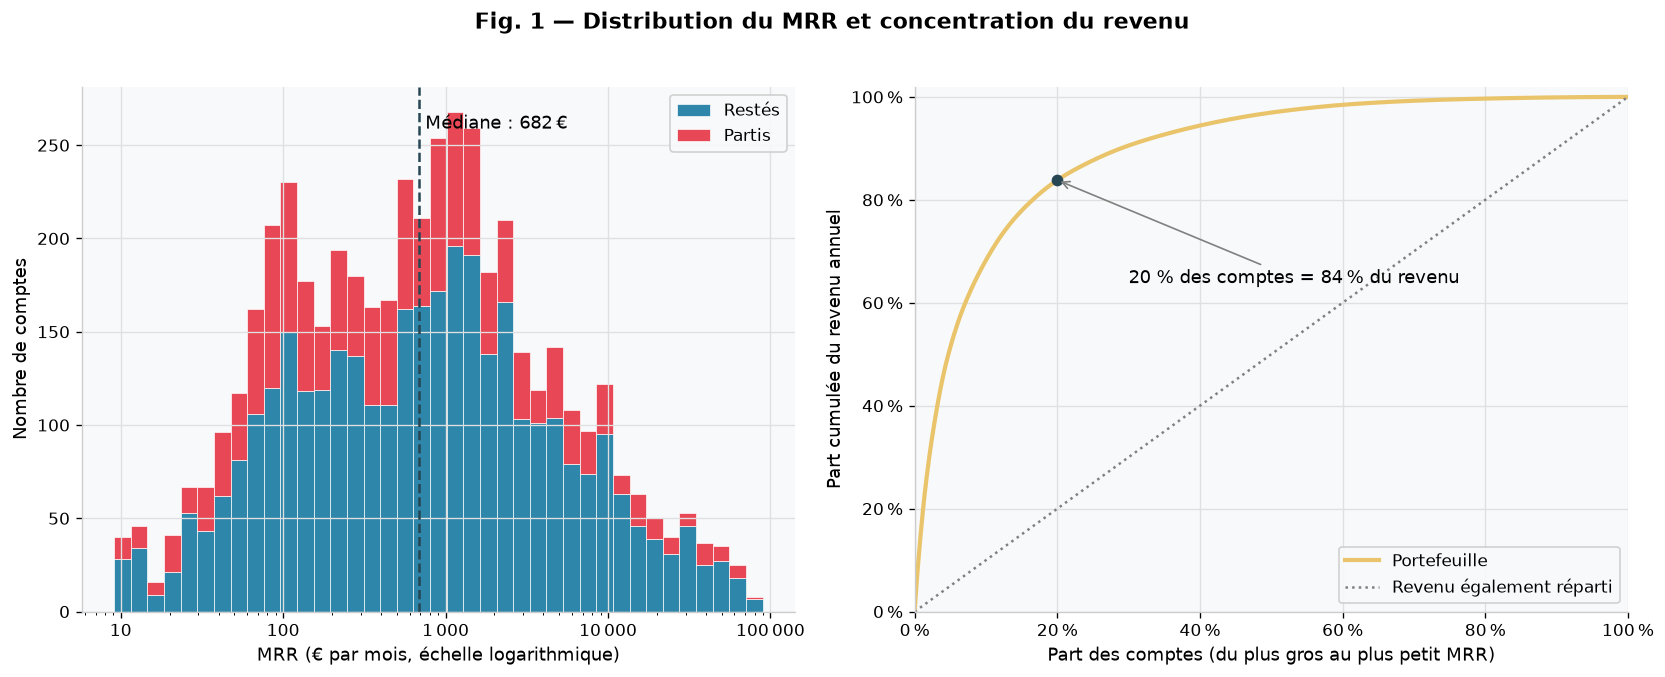

**Ce qu'il faut retenir.** Le MRR s'étale de 9 € à 89 403 € par mois : seule une échelle logarithmique rend la distribution lisible. Le revenu est **très concentré** : **20 % des comptes portent 84 % du revenu annuel**. Le MRR médian observé (682 €) s'écarte nettement des 450 € annoncés au cadrage (§2) : l'hypothèse de valorisation d'un compte sauvé est à revoir avec ces données (§12).

In [17]:
fig_mrr, (ax_hist, ax_conc) = viz.figure_grille(
    "apercu_portefeuille_mrr", "Distribution du MRR et concentration du revenu", 1, 2
)
_bornes = np.logspace(np.log10(apercu["mrr"].min()), np.log10(apercu["mrr"].max()), 40)
ax_hist.hist(
    [apercu.loc[apercu["churn"] == 0, "mrr"], apercu.loc[apercu["churn"] == 1, "mrr"]],
    bins=_bornes,
    stacked=True,
    color=[viz.COULEUR_NON_CHURN, viz.COULEUR_CHURN],
    label=["Restés", "Partis"],
    edgecolor="white",
    linewidth=0.4,
)
_mrr_median = float(apercu["mrr"].median())
ax_hist.axvline(_mrr_median, color=viz.couleur(5), linestyle="--", linewidth=1.5)
ax_hist.text(_mrr_median * 1.1, ax_hist.get_ylim()[1] * 0.92, f"Médiane : {euros(_mrr_median)}")
ax_hist.set_xscale("log")
ax_hist.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: entier(v)))
ax_hist.set(xlabel="MRR (€ par mois, échelle logarithmique)", ylabel="Nombre de comptes")
ax_hist.legend()

# Courbe de concentration : comptes triés du plus gros au plus petit MRR
_cumul = np.cumsum(np.sort(apercu["revenu_annuel"].to_numpy())[::-1]) / _revenu_total
_part_comptes = np.arange(1, len(_cumul) + 1) / len(_cumul)
_part_top20 = float(_cumul[int(np.ceil(0.2 * len(_cumul))) - 1])
ax_conc.plot(_part_comptes, _cumul, color=viz.couleur(6), linewidth=2.5, label="Portefeuille")
ax_conc.plot([0, 1], [0, 1], color="grey", linestyle=":", label="Revenu également réparti")
ax_conc.scatter([0.2], [_part_top20], color=viz.couleur(5), zorder=3)
ax_conc.annotate(
    f"20 % des comptes = {pourcentage(_part_top20, 0)} du revenu",
    (0.2, _part_top20),
    xytext=(0.3, _part_top20 - 0.2),
    arrowprops={"arrowstyle": "->", "color": "grey"},
)
for _axe in (ax_conc.xaxis, ax_conc.yaxis):
    _axe.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax_conc.set(
    xlabel="Part des comptes (du plus gros au plus petit MRR)",
    ylabel="Part cumulée du revenu annuel",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax_conc.legend(loc="lower right")
fig_mrr.tight_layout()
viz.sauvegarder(fig_mrr)
plt.show()

_mrr_cadrage = float(config.PORTEFEUILLE_CADRAGE["mrr_median_eur"])
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Le MRR s'étale de {euros(apercu['mrr'].min())} à "
        f"{euros(apercu['mrr'].max())} par mois : seule une échelle logarithmique rend la "
        f"distribution lisible. Le revenu est **très concentré** : **20 % des comptes portent "
        f"{pourcentage(_part_top20, 0)} du revenu annuel**. Le MRR médian observé "
        f"({euros(_mrr_median)}) "
        + (
            f"s'écarte nettement des {euros(_mrr_cadrage)} annoncés au cadrage (§2) : "
            "l'hypothèse de valorisation d'un compte sauvé est à revoir avec ces données (§12)."
            if abs(_mrr_median / _mrr_cadrage - 1) > 0.2
            else f"est cohérent avec les {euros(_mrr_cadrage)} annoncés au cadrage (§2)."
        )
    )
)

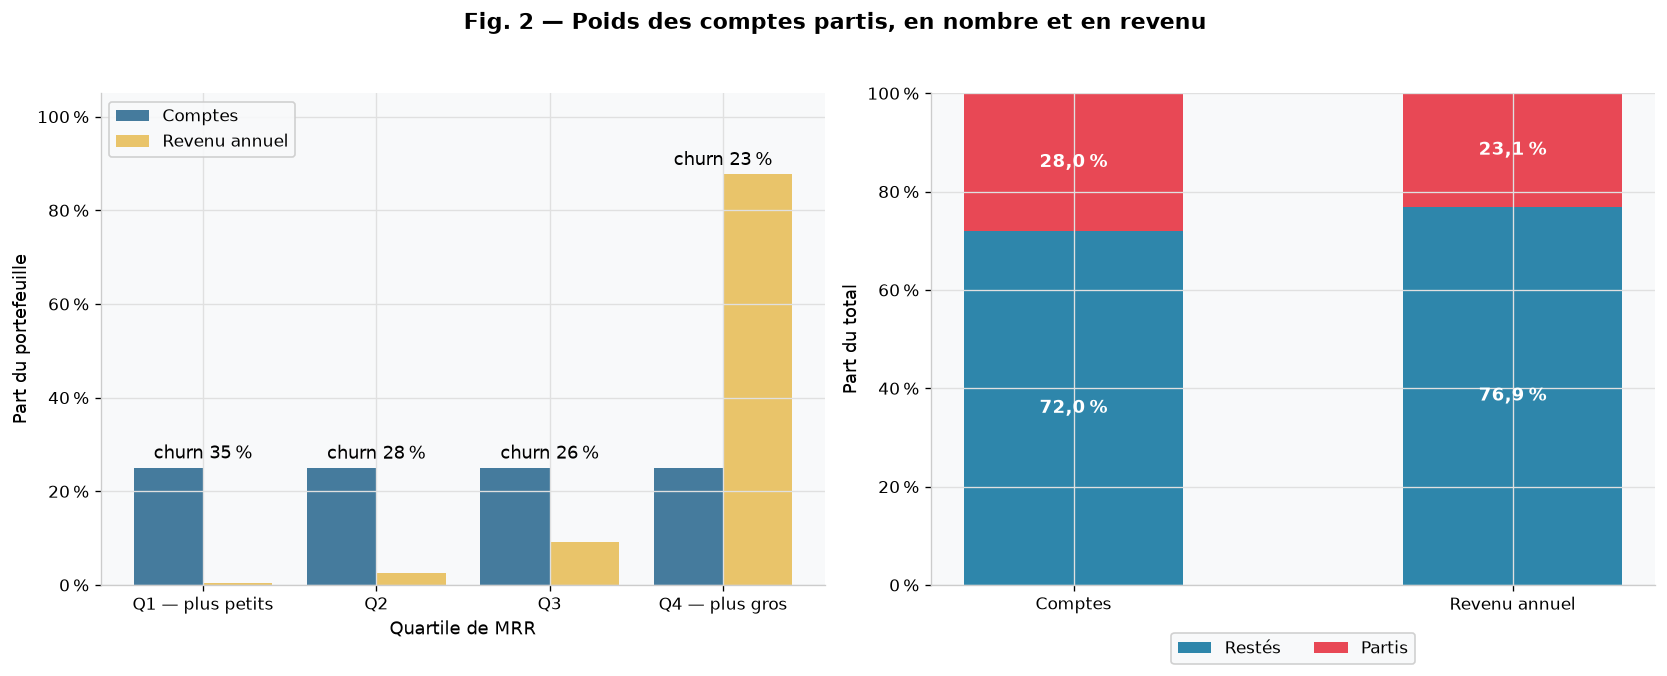

**Ce qu'il faut retenir.** Les comptes partis représentent **28,0 % des comptes** mais **23,1 % du revenu annuel**, soit 47 540 460 € par an. Les partants sont donc plutôt de petits comptes : le churn culmine dans le quartile « Q1 — plus petits » (34,8 %). Deux lectures à garder en tête : compter les comptes sauvés favoriserait les petits clients, compter le revenu sauvé les gros. C'est le dilemme des petits comptes (§4) et la raison pour laquelle la priorisation combine probabilité de départ et MRR (§12.6).

In [18]:
fig_partants, (ax_quart, ax_poids) = viz.figure_grille(
    "apercu_portefeuille_partants", "Poids des comptes partis, en nombre et en revenu", 1, 2
)
_t = tableau_portefeuille.loc[_QUARTILES]
_x = np.arange(len(_QUARTILES))
ax_quart.bar(_x - 0.2, _t["Comptes"] / len(apercu), 0.4, color=viz.couleur(7), label="Comptes")
ax_quart.bar(_x + 0.2, _t["Part du revenu"], 0.4, color=viz.couleur(6), label="Revenu annuel")
for _i, _taux in enumerate(_t["Taux de churn"]):
    _haut = max(_t["Comptes"].iloc[_i] / len(apercu), _t["Part du revenu"].iloc[_i])
    ax_quart.text(_i, _haut + 0.02, f"churn {pourcentage(_taux, 0)}", ha="center")
ax_quart.set_xticks(_x, _QUARTILES)
ax_quart.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax_quart.set(xlabel="Quartile de MRR", ylabel="Part du portefeuille", ylim=(0, 1.05))
ax_quart.legend(loc="upper left")

_part_partants = {
    "Comptes": float(apercu["churn"].mean()),
    "Revenu annuel": float(apercu["revenu_partants"].sum()) / _revenu_total,
}
_restes = [1 - p for p in _part_partants.values()]
_barres_restes = ax_poids.bar(
    list(_part_partants), _restes, 0.5, color=viz.COULEUR_NON_CHURN, label="Restés"
)
_barres_partis = ax_poids.bar(
    list(_part_partants),
    list(_part_partants.values()),
    0.5,
    bottom=_restes,
    color=viz.COULEUR_CHURN,
    label="Partis",
)
for _barres in (_barres_restes, _barres_partis):
    ax_poids.bar_label(
        _barres,
        labels=[pourcentage(b.get_height(), 1) for b in _barres],
        label_type="center",
        color="white",
        fontweight="bold",
    )
ax_poids.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax_poids.set(ylabel="Part du total", ylim=(0, 1))
ax_poids.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=2)
fig_partants.tight_layout()
viz.sauvegarder(fig_partants)
plt.show()

_q_max = _t["Taux de churn"].idxmax()
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Les comptes partis représentent "
        f"**{pourcentage(_part_partants['Comptes'], 1)} des comptes** mais "
        f"**{pourcentage(_part_partants['Revenu annuel'], 1)} du revenu annuel**, soit "
        f"{euros(apercu['revenu_partants'].sum())} par an. "
        + (
            "Les partants sont donc plutôt de petits comptes : "
            if _part_partants["Revenu annuel"] < _part_partants["Comptes"]
            else "Les partants pèsent plus lourd en revenu qu'en nombre : "
        )
        + f"le churn culmine dans le quartile « {_q_max} » "
        f"({pourcentage(_t.loc[_q_max, 'Taux de churn'], 1)}). Deux lectures à garder en tête : "
        "compter les comptes sauvés favoriserait les petits clients, compter le revenu sauvé les "
        "gros. C'est le dilemme des petits comptes (§4) et la raison pour laquelle la "
        "priorisation combine probabilité de départ et MRR (§12.6)."
    )
)

**Limites.** *Données brutes* : seules les copies exactes sont retirées ; les valeurs
impossibles ou mal formatées éventuelles sont diagnostiquées plus loin. *MRR manquants* :
exclus des sommes, le revenu total est donc légèrement sous-estimé. *MRR des partants* :
c'est le dernier MRR connu, un ordre de grandeur du revenu en jeu, pas une perte comptable.

### 5.3 Dictionnaire de données

**C'est le dictionnaire de référence du projet** : les 29 colonnes, groupées par famille, avec
leur type attendu et leur statut **final** dans le pipeline (la section qui tranche est
indiquée). Le tableau du §3.2 n'en est qu'un extrait, centré sur la pertinence métier.

| Colonne | Famille | Type attendu | Description | Statut |
|---|---|---|---|---|
| `client_id` | Client | texte | Identifiant unique du compte | identifiant — exclu |
| `date_souscription` | Client | date | Date de début de contrat | non modélisée — n'apporte que l'ancienneté, déjà dans `anciennete_mois` (§6.11) |
| `jour_souscription` | Client | catégorielle | Jour de semaine à la souscription | non modélisée — sans hypothèse métier ni lien avec le churn (§6.8) |
| `secteur` | Client | catégorielle | Secteur d'activité | explicative |
| `pays` | Client | catégorielle | Pays du siège social | explicative |
| `taille_entreprise` | Client | catégorielle | Taille (effectif) | explicative |
| `plan` | Client | catégorielle | Formule d'abonnement souscrite | explicative |
| `anciennete_mois` | Usage produit | numérique | Ancienneté du contrat (mois) | explicative |
| `sieges_souscrits` | Usage produit | numérique | Nombre de licences souscrites | explicative |
| `utilisateurs_actifs` | Usage produit | numérique | Utilisateurs actifs (30 j) | explicative |
| `taux_adoption_pct` | Usage produit | numérique [0-100] | Part des sièges utilisés (%) | explicative |
| `connexions_30j` | Usage produit | numérique | Nombre de connexions (30 j) | explicative |
| `heures_usage_30j` | Usage produit | numérique | Heures d'utilisation (30 j) | explicative |
| `fonctionnalites_total` | Usage produit | numérique | Fonctionnalités disponibles dans le plan | explicative — redondante avec `plan`, conservée pour le taux de couverture fonctionnelle (§7.5) |
| `fonctionnalites_utilisees` | Usage produit | numérique | Fonctionnalités effectivement utilisées | explicative |
| `nb_integrations` | Usage produit | numérique | Intégrations tierces actives | explicative |
| `derniere_connexion_jours` | Usage produit | numérique | Jours depuis la dernière connexion | explicative |
| `tickets_support_90j` | Support | numérique | Tickets ouverts sur 90 jours | explicative |
| `delai_reponse_support_h` | Support | numérique | Délai moyen de réponse support (h) | explicative |
| `csat` | Support | numérique [1-5] | Score de satisfaction client | explicative — hypothèse « les mécontents ne répondent pas » testée en §5.9 |
| `retards_paiement_12m` | Facturation | numérique | Retards de paiement sur 12 mois | explicative |
| `revenu_mensuel_recurrent_eur` | Facturation | numérique | Revenu mensuel récurrent du compte (€) | explicative |
| `couleur_theme_interface` | Leurres | catégorielle | Couleur du thème de l'interface | leurre suspecté — cosmétique ; gardé pour la preuve (§12.9), retiré du modèle déployé (§10.3) |
| `code_datacenter` | Leurres | catégorielle | Identifiant du centre de données | leurre suspecté — localisation technique ; idem |
| `groupe_experimentation` | Leurres | catégorielle | Groupe de test A/B | leurre suspecté — biais de sélection possible ; idem |
| `commentaire_csm` | Leurres | texte libre | Commentaire libre du chargé de clientèle | suspecte (leurre ou fuite ?) — audit §6.6 : interdite |
| `sante_compte_fin_periode` | Fuite | numérique | Score de santé calculé en FIN de période | ⚠ fuite temporelle — exclue |
| `valeur_vie_client_eur` | Cible | numérique | Valeur vie client estimée (€) | cible de régression — jamais variable explicative |
| `churn` | Cible | binaire (0/1) | Résiliation observée (1 = churn) | cible principale |

**Ce qu'il faut retenir.** **19 variables** entrent dans le modèle ; les 2 colonnes de date de
souscription restent dans le jeu préparé sans être modélisées. Les **4 suspectes** ne sont pas
supprimées a priori : les trois leurres probables reçoivent un verdict provisoire au §6.10 et
définitif au §12.9 ; `commentaire_csm`, liée à la cible, relève de l'audit de fuite du §6.6.
`sante_compte_fin_periode` est une fuite pure (score calculé après le churn) : inscrite dans
`config.COLONNES_INTERDITES`, elle n'atteindra jamais le modèle.

### 5.4 Profil compact du jeu de données principal

On veut une radiographie rapide avant les diagnostics détaillés : `profil_compact()` donne, par
colonne, le taux de manquants, le nombre de valeurs distinctes, les valeurs dominantes et un
indicateur `numerique_en_texte` pour les nombres stockés comme du texte.

In [19]:
profil = profil_compact(df_brut)
display(profil)

nb_avec_manquants = int((profil["taux_manquants"] > 0).sum())
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Sur {df_brut.shape[1]} colonnes, **{nb_avec_manquants}** "
        f"ont des valeurs manquantes (mécanisme étudié au §5.9) et "
        f"**{int(profil['numerique_en_texte'].sum())}** sont des nombres stockés en texte "
        f"(réparation testée au §5.6)."
    )
)

,dtype,nb_non_nuls,taux_manquants,cardinalite,top3_valeurs,min,max,numerique_en_texte
colonne,,,,,,,,
client_id,str,5035,0,5000,CLI-000087 | CLI-001707 | CLI-002537,NaN,NaN,False
date_souscription,str,5035,0,1415,04 Jan 2025 | 02/01/2025 | 2025-01-06,NaN,NaN,False
jour_souscription,str,5035,0,7,mardi | lundi | samedi,NaN,NaN,False
secteur,str,4782,"0,0502",28,Commerce | Tech | Finance,NaN,NaN,False
pays,str,4834,"0,0399",6,France | Belgique | Allemagne,NaN,NaN,False
taille_entreprise,str,5035,0,12,PME | TPE | ETI,NaN,NaN,False
plan,str,5035,0,16,Pro | Starter | Business,NaN,NaN,False
anciennete_mois,str,5035,0,36,1 | 10 | 14,1,36,True
sieges_souscrits,str,5035,0,468,10 | 7 | 8,1,898,True


**Ce qu'il faut retenir.** Sur 29 colonnes, **10** ont des valeurs manquantes (mécanisme étudié au §5.9) et **18** sont des nombres stockés en texte (réparation testée au §5.6).

### 5.5 Doublons — exacts vs clé métier

Deux sortes de doublons, deux traitements. Une copie **exacte** (toutes colonnes identiques)
se supprime sans risque. Un même `client_id` avec des données **différentes** n'a pas de
traitement sûr : mise à jour (garder la plus récente), contacts multiples (agréger) ou erreur de
jointure (corriger la source). Comme la bonne réponse dépend de la cause, le pipeline s'arrête
s'il en rencontre, plutôt que de choisir une ligne à l'aveugle.

In [20]:
rapport_doublons = analyser_doublons(df_brut, cle_metier="client_id")
nb_exact = rapport_doublons["nb_doublons_exacts"]
nb_cle_non_exact = rapport_doublons["nb_doublons_cle_metier_non_exacts"]
n_total = rapport_doublons["nb_total_lignes"]

# analyser_doublons() compte toutes les lignes d'un groupe (original compris) ; les lignes
# redondantes sont celles qu'une déduplication retirerait
nb_redondantes_exactes = n_total - len(_complet_brut)
nb_redondantes_cle = int(_complet_brut.duplicated(subset=["client_id"]).sum())

if nb_exact > 0:
    display(rapport_doublons["exemples_doublons_exacts"])

display(
    Markdown(
        f"**Ce qu'il faut retenir.** Sur {entier(n_total)} lignes, **{entier(nb_exact)}** "
        f"appartiennent à un groupe de doublons exacts, soit **{entier(nb_redondantes_exactes)} "
        f"copie(s) redondante(s)** à supprimer ({entier(len(_complet_brut))} lignes restantes). "
        + (
            "**Aucune ligne** ne partage un `client_id` avec des données divergentes : une fois "
            "les copies retirées, chaque compte apparaît une seule fois. "
            if nb_cle_non_exact == 0
            else f"⚠️ **{entier(nb_cle_non_exact)} ligne(s)** partagent un `client_id` avec des "
            f"données divergentes ({entier(nb_redondantes_cle)} redondante(s)) : la construction "
            f"du jeu préparé s'arrêtera tant que leur cause n'est pas établie. "
        )
        + "Déduplication et contrôle d'unicité sont appliqués en §7.3.1 et dans "
        "`construire_gold_dataset()`."
    )
)

,client_id,date_souscription,jour_souscription,secteur,pays,taille_entreprise,plan,anciennete_mois,sieges_souscrits,utilisateurs_actifs,...,csat,retards_paiement_12m,revenu_mensuel_recurrent_eur,couleur_theme_interface,code_datacenter,groupe_experimentation,commentaire_csm,sante_compte_fin_periode,valeur_vie_client_eur,churn
2,CLI-000087,23 Dec 2024,lundi,éducation,France,tpe,Pro,1,10,2,...,1,2,171.02,clair,ap-s1,B,Mécontentement exprimé au support.,1,701,1
123,CLI-001707,2024-09-03,mardi,NaN,France,PME,Business,5,26,5,...,4,NaN,"1086,88",violet,eu-w3,control,Déploiement interne limité.,23,15151,1
446,CLI-002537,07 Jan 2025,mardi,éducation,NaN,GE,ENTERPRISE,1,158,0,...,2,2,"10648,88",clair,us-e1,control,Mécontentement exprimé au support.,4,104785,1
494,CLI-000184,04/09/2024,mercredi,Éducation,Belgique,PME,PRO,5,46,35,...,4,0,"1238,96",violet,us-e1,B,Compte dans la moyenne.,46,16255,0
624,CLI-004916,09 May 2024,jeudi,éducation,France,eti,Business,9,30,0,...,4,0,1426.31,bleu,us-e1,A,NaN,8,9357,1
643,CLI-001434,2023-11-14,mardi,Éducation,Canada,GE,Enterprise,15,884,829,...,3,0,76511.23,vert,us-e1,B,NaN,76,1882176,0
646,CLI-003440,12 Sep 2023,mardi,Commerce,France,ETI,PRO,17,201,174,...,4,0,5773.9,clair,eu-w1,B,NaN,77,37877,0
784,CLI-002413,2023-08-12,samedi,Tech,Espagne,TPE,STARTER,18,11,2,...,3,0,140.52,vert,eu-w1,A,NaN,58,4955,0
863,CLI-001638,24 Dec 2024,mardi,Tech,France,TPE,Starter,1,5,3,...,2,3,45.41,bleu,eu-w3,control,"Client insatisfait, risque de départ.",0,521,1
929,CLI-000351,08/11/2023,mercredi,santé,Espagne,TPE,Pro,15,10,1,...,2,0,233.39,sombre,eu-w3,control,Mécontentement exprimé au support.,51,1722,0


**Ce qu'il faut retenir.** Sur 5 035 lignes, **70** appartiennent à un groupe de doublons exacts, soit **35 copie(s) redondante(s)** à supprimer (5 000 lignes restantes). **Aucune ligne** ne partage un `client_id` avec des données divergentes : une fois les copies retirées, chaque compte apparaît une seule fois. Déduplication et contrôle d'unicité sont appliqués en §7.3.1 et dans `construire_gold_dataset()`.

### 5.6 Colonnes numériques stockées en texte

Un nombre écrit `12,5`, `45.2 €` ou `12.5 h` est du texte pour pandas : il faut le réparer
avant tout calcul. `coercer_numeriques()` gère virgule ou point décimal, espaces insécables,
symboles (€, %) et unités accolées. Piège évité : la convertibilité est mesurée **après**
réparation ; un `pd.to_numeric` brut échouerait justement sur les colonnes les plus mal
formatées, qui passeraient alors sous le seuil de détection (80 %) sans jamais être examinées.

In [21]:
cols_num_texte = list(profil[profil["numerique_en_texte"]].index)
total_repare = total_irrecup = 0
cols_reparees: list[str] = []

if cols_num_texte:
    _, rapport_coercition = coercer_numeriques(df_brut, cols_num_texte)
    display(rapport_coercition)
    total_repare = int(rapport_coercition["nb_reparees"].sum())
    total_irrecup = int(rapport_coercition["nb_irrecuperables"].sum())
    cols_reparees = list(rapport_coercition.index[rapport_coercition["nb_reparees"] > 0])

display(
    Markdown(
        f"**Ce qu'il faut retenir.** {len(cols_num_texte)} colonne(s) numériques stockées en "
        f"texte, dont **{len(cols_reparees)} mal formatée(s)** "
        f"(`{'`, `'.join(cols_reparees) or 'aucune'}`). La coercition répare "
        f"**{entier(total_repare)} valeur(s)** et en laisse **{entier(total_irrecup)} "
        f"irrécupérable(s)**, mises à `NaN`. Appliquée en §7.3, c'est une règle de réécriture "
        f"valeur par valeur qui n'apprend rien des données : l'appliquer avant le découpage en "
        f"plis ne crée pas de fuite."
    )
)

,nb_directes,nb_reparees,nb_manquants,nb_irrecuperables
colonne,,,,
anciennete_mois,5035,0,0,0
sieges_souscrits,5035,0,0,0
utilisateurs_actifs,5035,0,0,0
taux_adoption_pct,2765,2020,250,0
connexions_30j,5035,0,0,0
heures_usage_30j,3328,1402,305,0
fonctionnalites_total,5035,0,0,0
fonctionnalites_utilisees,5035,0,0,0
nb_integrations,4835,0,200,0


**Ce qu'il faut retenir.** 18 colonne(s) numériques stockées en texte, dont **4 mal formatée(s)** (`taux_adoption_pct`, `heures_usage_30j`, `delai_reponse_support_h`, `revenu_mensuel_recurrent_eur`). La coercition répare **6 529 valeur(s)** et en laisse **0 irrécupérable(s)**, mises à `NaN`. Appliquée en §7.3, c'est une règle de réécriture valeur par valeur qui n'apprend rien des données : l'appliquer avant le découpage en plis ne crée pas de fuite.

### 5.7 Dates multi-formats

`date_souscription` mélange plusieurs écritures (`2021-02-01`, `01/02/2021`…). Appliquer un
seul format « dominant » laisserait vides toutes les dates écrites autrement : `parser_dates()`
essaie donc une cascade de formats **valeur par valeur**. Il compte aussi les dates ambiguës
(`01/02/2021` : 1er février ou 2 janvier ?) et documente la convention retenue pour elles.

In [22]:
_, rapport_dates = parser_dates(df_brut, ["date_souscription"])
_ligne_dates = rapport_dates.loc["date_souscription"]
_formats = _ligne_dates["repartition_formats"] or ""
display(
    rapport_dates[
        ["repartition_formats", "convention_retenue", "nb_parsees", "nb_ambigues"]
        + ["nb_irrecuperables"]
    ]
)

# Effectifs par format (« %d/%m/%Y : 1621 ») avec séparateur de milliers
_repartition = re.sub(r"\d{4,}", lambda m: entier(int(m.group())), _formats)
display(
    Markdown(
        f"**Ce qu'il faut retenir.** **{len(_formats.split(' | ')) if _formats else 0} formats** "
        f"coexistent (`{_repartition}`). Les {entier(_ligne_dates['nb_ambigues'])} dates ambiguës "
        f"sont lues selon la convention *{_ligne_dates['convention_retenue']}*, comme toutes les "
        f"dates à barre oblique. **{entier(_ligne_dates['nb_parsees'])} dates lues**, "
        f"{entier(_ligne_dates['nb_irrecuperables'])} irrécupérable(s). Même lecture en §7.3, "
        f"sans apprentissage donc sans fuite."
    )
)

,repartition_formats,convention_retenue,nb_parsees,nb_ambigues,nb_irrecuperables
colonne,,,,,
date_souscription,%Y-%m-%d : 1705 | %d/%m/%Y : 1621 | %d %b %Y :...,DD/MM/YYYY (premier champ > 12 observé → non a...,5035,962,0


**Ce qu'il faut retenir.** **3 formats** coexistent (`%Y-%m-%d : 1 705 | %d/%m/%Y : 1 621 | %d %b %Y : 1 709`). Les 962 dates ambiguës sont lues selon la convention *DD/MM/YYYY (premier champ > 12 observé → non ambigu)*, comme toutes les dates à barre oblique. **5 035 dates lues**, 0 irrécupérable(s). Même lecture en §7.3, sans apprentissage donc sans fuite.

### 5.8 Valeurs métier impossibles

Certaines valeurs sont fausses par construction, sans aucune statistique :
`detecter_valeurs_impossibles()` évalue quatre familles de règles.

- **Bornes** : `taux_adoption_pct` ∈ [0, 100], `csat` ∈ [1, 5], `churn` ∈ {0, 1}.
- **Positivité** des colonnes structurellement positives (compteurs, durées, montants).
- **Relations** : utilisateurs ≤ sièges, fonctionnalités utilisées ≤ disponibles, taux
  d'adoption = 100 × utilisateurs / sièges, au moins une connexion sur 30 jours ⇒ dernière
  connexion il y a 30 jours ou moins.
- **Cohérence temporelle** : souscription antérieure à l'extraction, ancienneté déclarée
  cohérente avec la date de souscription.

Le tableau liste **toutes** les règles, même celles qui ne relèvent rien : un contrôle qui ne
trouve rien ne vaut que si l'on voit ce qui a été contrôlé.

**Quelle date de référence pour l'ancienneté ?** `anciennete_mois` est comptée jusqu'à une
date d'extraction **T** non fournie. Comparer à la date du jour serait faux (le résultat
changerait à chaque relance). Chaque ligne donne sa propre estimation de T
(`date_souscription + anciennete_mois`) ; on en prend la **médiane**, insensible tant que moins
de la moitié des lignes sont aberrantes, donc capable de les isoler. Elle est crédible si les
estimations individuelles tiennent dans une fenêtre d'environ un mois (ancienneté arrondie au
mois) et si T est postérieure à la dernière souscription.

In [23]:
date_reference = estimer_date_reference(df_brut)
anomalies = detecter_valeurs_impossibles(df_brut, date_reference=date_reference)

df_regles = pd.DataFrame(anomalies.attrs["regles_controlees"]).rename(
    columns={"regle": "Règle", "colonne_ou_paire": "Colonne(s)", "nb_lignes": "Lignes en violation"}
)
# Traitements alignés sur ce que §7.3.4 applique réellement
_TRAITEMENTS = {
    "taux_adoption_pct ∉": "Borné à [0, 100] en §7.3.4",
    "utilisateurs_actifs > sieges_souscrits": "Borné à sieges_souscrits en §7.3.4",
}
df_regles["Traitement"] = [
    (
        "—"
        if n == 0
        else next(
            (t for cle, t in _TRAITEMENTS.items() if r.startswith(cle)),
            "À examiner avant la préparation",
        )
    )
    for r, n in zip(df_regles["Règle"], df_regles["Lignes en violation"], strict=True)
]
display(df_regles.set_index("Règle"))

total_lignes_anomalies = int(df_regles["Lignes en violation"].sum())
_regle_taux = df_regles["Règle"].str.startswith("taux_adoption_pct ≠")
_taux_redondant = (
    bool(_regle_taux.any()) and int(df_regles.loc[_regle_taux, "Lignes en violation"].iloc[0]) == 0
)

display(
    Markdown(
        f"**Ce qu'il faut retenir.** **{len(df_regles)} règles** évaluées, "
        f"**{int((df_regles['Lignes en violation'] > 0).sum())} violée(s)**, "
        f"**{entier(total_lignes_anomalies)} ligne(s)** concernée(s). "
        + (
            "Aucune correction n'est nécessaire ; les bornages de §7.3.4 restent en place comme "
            "garde-fou pour les données futures reçues par l'API et le batch (traitement par lot). "
            if total_lignes_anomalies == 0
            else "La colonne « Traitement » indique le sort de chaque règle violée. "
        )
        + (
            "Point notable : `taux_adoption_pct` vaut exactement 100 × `utilisateurs_actifs` / "
            "`sieges_souscrits` sur toutes les lignes renseignées. Elle est **redondante** : ses "
            "trous se **recalculent exactement** (mieux qu'une imputation), et son poids sera "
            "partagé avec ses deux colonnes sources dans les corrélations (§6) et l'importance "
            "des variables (§12.8)."
            if _taux_redondant
            else ""
        )
    )
)

,Colonne(s),Lignes en violation,Traitement
Règle,,,
"taux_adoption_pct ∉ [0, 100]",taux_adoption_pct,0,—
"csat ∉ [1, 5]",csat,0,—
"churn ∉ {0, 1}",churn,0,—
anciennete_mois < 0 (valeur impossible),anciennete_mois,0,—
sieges_souscrits < 0 (valeur impossible),sieges_souscrits,0,—
utilisateurs_actifs < 0 (valeur impossible),utilisateurs_actifs,0,—
connexions_30j < 0 (valeur impossible),connexions_30j,0,—
heures_usage_30j < 0 (valeur impossible),heures_usage_30j,0,—
fonctionnalites_total < 0 (valeur impossible),fonctionnalites_total,0,—


**Ce qu'il faut retenir.** **23 règles** évaluées, **0 violée(s)**, **0 ligne(s)** concernée(s). Aucune correction n'est nécessaire ; les bornages de §7.3.4 restent en place comme garde-fou pour les données futures reçues par l'API et le batch (traitement par lot). Point notable : `taux_adoption_pct` vaut exactement 100 × `utilisateurs_actifs` / `sieges_souscrits` sur toutes les lignes renseignées. Elle est **redondante** : ses trous se **recalculent exactement** (mieux qu'une imputation), et son poids sera partagé avec ses deux colonnes sources dans les corrélations (§6) et l'importance des variables (§12.8).

In [24]:
diag_anciennete = diagnostiquer_anciennete(df_brut, date_reference=date_reference)
display(
    pd.Series(
        {
            "Date d'extraction estimée (médiane)": f"{diag_anciennete['date_reference']:%d/%m/%Y}",
            "Estimation individuelle la plus ancienne": f"{diag_anciennete['implicite_min']:%d/%m/%Y}",
            "Estimation individuelle la plus récente": f"{diag_anciennete['implicite_max']:%d/%m/%Y}",
            "Étendue des estimations (jours)": entier(diag_anciennete["etendue_jours"]),
            "Écart interquartile des estimations (jours)": entier(diag_anciennete["iqr_jours"]),
            "Dernière souscription observée": f"{diag_anciennete['date_souscription_max']:%d/%m/%Y}",
            "Ancienneté déclarée en mois entiers": (
                "oui" if diag_anciennete["anciennete_entiere"] else "non"
            ),
        },
        name="Valeur",
    ).to_frame()
)

_ecarts = diag_anciennete["repartition_ecarts"]
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Les estimations de la date d'extraction tiennent dans "
        f"**{entier(diag_anciennete['etendue_jours'])} jours** : les deux colonnes décrivent une "
        f"même extraction, datée du **{diag_anciennete['date_reference']:%d/%m/%Y}**, postérieure "
        f"à la dernière souscription. L'ancienneté déclarée s'écarte de l'ancienneté recalculée "
        f"de "
        + ", ".join(f"**{k} mois pour {entier(v)} ligne(s)**" for k, v in _ecarts.items())
        + f" ; l'écart maximal ({max(abs(k) for k in _ecarts)} mois) reste sous la tolérance de "
        f"{diag_anciennete['tolerance_mois']} mois : `anciennete_mois` est utilisable sans "
        f"correction."
    )
)

,Valeur
Date d'extraction estimée (médiane),04/02/2025
Estimation individuelle la plus ancienne,22/01/2025
Estimation individuelle la plus récente,22/02/2025
Étendue des estimations (jours),31
Écart interquartile des estimations (jours),9
Dernière souscription observée,10/01/2025
Ancienneté déclarée en mois entiers,oui


**Ce qu'il faut retenir.** Les estimations de la date d'extraction tiennent dans **31 jours** : les deux colonnes décrivent une même extraction, datée du **04/02/2025**, postérieure à la dernière souscription. L'ancienneté déclarée s'écarte de l'ancienneté recalculée de **0 mois pour 5 013 ligne(s)**, **1 mois pour 22 ligne(s)** ; l'écart maximal (1 mois) reste sous la tolérance de 3 mois : `anciennete_mois` est utilisable sans correction.

**Limites du contrôle d'ancienneté.** *Circularité* : T est estimée sur les données qu'on
contrôle ; le test isole les lignes incohérentes avec les autres, mais pas un décalage commun à
toutes. *Tolérance* : 3 mois est un choix, pas une mesure ; il laisse une marge aux données
futures sans masquer une vraie erreur de saisie (une année). *Arrondi* : 30,44 jours est une
durée moyenne de mois, qui explique à elle seule les écarts d'un mois.

### 5.9 Mécanisme de manquance (MCAR / MAR / MNAR)

Une valeur manquante n'est pas qu'un trou à boucher : **la raison pour laquelle elle manque**
décide du traitement. La boucher avec la médiane est sans danger si le trou est dû au hasard ;
c'est une erreur si les trous touchent surtout un type de client.

| Mécanisme | Définition | Exemple pour `csat` | Conséquence |
|---|---|---|---|
| **MCAR** — manquant complètement au hasard | La manquance ne dépend de rien. | Un incident d'export a effacé des notes au hasard. | Les clients renseignés restent représentatifs : imputation simple (médiane) sans biais. |
| **MAR** — manquant au hasard **une fois connues les autres colonnes** | La manquance dépend de colonnes **observées**, pas de la valeur manquante. | L'enquête n'est envoyée qu'aux plans Business et Enterprise. | Imputer **en tenant compte** de ces colonnes ; une médiane globale serait biaisée. |
| **MNAR** — manquant **pas** au hasard | La manquance dépend de la **valeur manquante elle-même**. | Les mécontents ne répondent pas à l'enquête. | Aucune imputation ne corrige tout ; le fait de manquer est une information, gardée en indicateur (`csat_manquant`). |

**Ce qu'on peut tester.** *MCAR contre MAR* : si la manquance d'une colonne est associée à une
autre colonne observée (V de Cramér pour les catégorielles, corrélation point-bisériale pour
les numériques), elle n'est pas MCAR ; 0,15 sépare une association négligeable d'une
association à prendre en compte. *MNAR ne se prouve pas* : la valeur dont dépend la manquance
est justement celle qu'on n'a pas. On cherche un indice : si les mécontents ne répondaient pas,
les clients sans note résilieraient **plus** ; un test du χ² compare le churn des lignes
manquantes et renseignées.

`analyser_manquance()` applique ces tests dans l'ordre : manquance liée au churn (p < 0,05) →
**MNAR**, à lire « manquance qui renseigne sur le churn » (indice, pas preuve) ; sinon
association ≥ 0,15 → **MAR** ; sinon **MCAR**, retenu faute de preuve contraire. Les colonnes
quasi uniques (identifiant, date brute) sont exclues des associations : le V de Cramér y vaut
mécaniquement ≈ 1 et ferait conclure à tort à MAR. L'analyse porte sur les lignes dédoublonnées.

In [25]:
df_manquance = _complet_brut
rapport_manquance = analyser_manquance(df_manquance, cible="churn")
_mecanismes = rapport_manquance.get("mecanisme_propose", pd.Series(dtype=str))
nb_mnar, nb_mar, nb_mcar = (int((_mecanismes == m).sum()) for m in ("MNAR", "MAR", "MCAR"))
cols_mnar = list(_mecanismes.index[_mecanismes == "MNAR"])

if not rapport_manquance.empty:
    display(
        rapport_manquance[
            ["taux_manquants", "taux_churn_si_manquant", "taux_churn_si_renseigne"]
            + ["p_value_cible", "top3_associations", "mecanisme_propose"]
        ].rename(
            columns={
                "taux_manquants": "Part manquante",
                "taux_churn_si_manquant": "Churn si manquant",
                "taux_churn_si_renseigne": "Churn si renseigné",
                "p_value_cible": "p-value (χ² manquance × churn)",
                "top3_associations": "Associations les plus fortes",
                "mecanisme_propose": "Mécanisme",
            }
        )
    )
    _assoc_max = (
        rapport_manquance["top3_associations"].str.extract(r"=(\d+\.\d+)")[0].astype(float).max()
    )
    _p_min = float(rapport_manquance["p_value_cible"].min())
    display(
        Markdown(
            f"**Ce qu'il faut retenir.** Sur {len(rapport_manquance)} colonnes incomplètes : "
            f"**{nb_mnar} MNAR** (`{'`, `'.join(cols_mnar) or 'aucune'}`), **{nb_mar} MAR**, "
            f"**{nb_mcar} MCAR**. Plus petite p-value : {nombre(_p_min, 2)} (seuil 0,05) ; "
            f"association la plus forte : {nombre(_assoc_max, 2)} (seuil 0,15). "
            + (
                "Les trous se comportent comme s'ils étaient répartis au hasard : une imputation "
                "(remplacement par une valeur plausible) simple suffit — médiane pour les "
                'numériques, modalité `"inconnu"` pour les catégorielles — apprise **dans chaque '
                "pli** de cross-validation (validation croisée) en §7.4. "
                if nb_mnar == 0 and nb_mar == 0
                else "Les colonnes MAR demandent une imputation conditionnelle, les colonnes MNAR "
                "un indicateur de manquance en plus de l'imputation. "
            )
            + "Colonnes exclues des associations car quasi uniques : "
            f"`{'`, `'.join(rapport_manquance.attrs.get('colonnes_exclues_associations', [])) or 'aucune'}`."
        )
    )

,Part manquante,Churn si manquant,Churn si renseigné,p-value (χ² manquance × churn),Associations les plus fortes,Mécanisme
colonne,,,,,,
secteur,"0,05","0,256","0,2813","0,4267","commentaire_csm=0,105, plan=0,055, taille_entr...",MCAR
pays,"0,04","0,32","0,2783","0,228","secteur=0,095, commentaire_csm=0,065, taille_e...",MCAR
taux_adoption_pct,"0,05","0,26","0,2811","0,5155","commentaire_csm=0,082, secteur=0,076, plan=0,044",MCAR
heures_usage_30j,"0,06","0,25","0,2819","0,2596","commentaire_csm=0,082, secteur=0,067, plan=0,044",MCAR
nb_integrations,"0,04","0,245","0,2815","0,2961","secteur=0,077, commentaire_csm=0,072, taille_e...",MCAR
delai_reponse_support_h,"0,1","0,282","0,2798","0,9581","commentaire_csm=0,119, secteur=0,071, plan=0,061",MCAR
csat,"0,08","0,2575","0,282","0,3237","secteur=0,072, commentaire_csm=0,067, taille_e...",MCAR
retards_paiement_12m,"0,05","0,244","0,2819","0,2193","secteur=0,058, taille_entreprise=0,058, plan=0...",MCAR
revenu_mensuel_recurrent_eur,"0,03","0,2667","0,2804","0,7818","commentaire_csm=0,062, secteur=0,060, taille_e...",MCAR


**Ce qu'il faut retenir.** Sur 10 colonnes incomplètes : **0 MNAR** (`aucune`), **0 MAR**, **10 MCAR**. Plus petite p-value : 0,22 (seuil 0,05) ; association la plus forte : n.d. (seuil 0,15). Les trous se comportent comme s'ils étaient répartis au hasard : une imputation (remplacement par une valeur plausible) simple suffit — médiane pour les numériques, modalité `"inconnu"` pour les catégorielles — apprise **dans chaque pli** de cross-validation (validation croisée) en §7.4. Colonnes exclues des associations car quasi uniques : `client_id`, `date_souscription`.

**Zoom sur `csat` : « les mécontents ne répondent pas » ?** C'est l'hypothèse MNAR la plus
plausible. Si elle était vraie, les clients sans note ressembleraient aux clients mal notés, et
leur taux de churn serait proche de celui des notes 1 et 2.

In [26]:
_csat_num = pd.to_numeric(df_manquance["csat"], errors="coerce")
_churn_num = pd.to_numeric(df_manquance["churn"], errors="coerce")
df_churn_csat = (
    pd.DataFrame({"csat": _csat_num.map(lambda v: "manquant" if pd.isna(v) else entier(v))})
    .assign(churn=_churn_num)
    .groupby("csat")["churn"]
    .agg(clients="count", taux_churn="mean")
)
display(styler_fr(df_churn_csat, {"taux_churn": pourcentage}))

_churn_manquant = float(df_churn_csat.loc["manquant", "taux_churn"])
_churn_insatisfaits = float(_churn_num[_csat_num <= 2].mean())
_churn_global = float(_churn_num.mean())
_ressemble_mecontents = abs(_churn_manquant - _churn_insatisfaits) < abs(
    _churn_manquant - _churn_global
)
_notes_proches = (
    df_churn_csat.drop(index="manquant")["taux_churn"].sub(_churn_manquant).abs().nsmallest(2).index
)
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Les clients sans note résilient à "
        f"**{pourcentage(_churn_manquant, 1)}**, contre {pourcentage(_churn_insatisfaits, 1)} pour "
        f"les notes 1 ou 2 et {pourcentage(_churn_global, 1)} en moyenne ; ils se comportent comme "
        f"les notes {' et '.join(sorted(_notes_proches))}. "
        + (
            "Ils ressemblent aux mécontents : les données sont compatibles avec l'hypothèse, sans "
            "la prouver. "
            if _ressemble_mecontents
            else "Ils ne ressemblent pas aux mécontents : l'argument principal en faveur d'un "
            "mécanisme MNAR tombe, sans exclure un mécanisme plus subtil. "
        )
        + "Les indicateurs `csat_manquant`, `heures_usage_30j_manquant` et "
        "`delai_reponse_support_h_manquant` sont tout de même créés en §7.5 : coût quasi nul, "
        "aucune fuite (règle sans apprentissage), et un effet combiné reste possible. "
        "L'importance de permutation (§12.8) tranchera."
    )
)

,clients,taux_churn
csat,,
1,194,"57,2 %"
2,718,"46,1 %"
3,1 399,"32,3 %"
4,1 395,"21,5 %"
5,894,"11,5 %"
manquant,400,"25,8 %"


**Ce qu'il faut retenir.** Les clients sans note résilient à **25,8 %**, contre 48,5 % pour les notes 1 ou 2 et 28,0 % en moyenne ; ils se comportent comme les notes 3 et 4. Ils ne ressemblent pas aux mécontents : l'argument principal en faveur d'un mécanisme MNAR tombe, sans exclure un mécanisme plus subtil. Les indicateurs `csat_manquant`, `heures_usage_30j_manquant` et `delai_reponse_support_h_manquant` sont tout de même créés en §7.5 : coût quasi nul, aucune fuite (règle sans apprentissage), et un effet combiné reste possible. L'importance de permutation (§12.8) tranchera.

**Limites.** *MCAR par défaut* : ne pas trouver d'association prouve seulement qu'elle est
trop faible pour être détectée avec ces effectifs. *Tests multiples* : dix colonnes testées à
5 % donnent en moyenne une demi-fausse alerte ; une future détection isolée se lira avec
prudence. *Seuils* : 0,05 et 0,15 sont des conventions, pas des valeurs optimisées.
*`commentaire_csm`* manque à plus de 50 %, ce qui justifierait d'habitude de la supprimer ;
mais l'absence de commentaire peut porter de l'information : l'audit de fuite du §6.6 tranche.

### 5.10 Renommage — convention de nommage

Des noms explicites et homogènes rendent le pipeline lisible. Convention : **snake_case sans
accent, unités suffixées** (`_eur`, `_pct`, `_mois`, `_jours`, `_h`), réservées aux **grandeurs
mesurées** : comptages (`sieges_souscrits`), scores sans dimension (`csat`) et catégories n'ont
pas d'unité, et `_30j`, `_90j`, `_12m` sont des **fenêtres d'observation** (`tickets_support_90j`
compte des tickets sur 90 jours). Le tableau avant/après sert de contrat pour tout le code aval.

In [27]:
df_renommage = proposer_renommage(df_brut)
display(df_renommage)
nb_modifies = int(df_renommage["modifie"].sum())

display(
    Markdown(
        f"**Ce qu'il faut retenir.** **{nb_modifies} colonne(s) à renommer** sur "
        f"{len(df_renommage)}"
        + (
            " : toutes les grandeurs mesurées portent déjà leur unité. Seule entorse tolérée, "
            "`heures_usage_30j` porte la sienne en tête ; la renommer casserait le contrat de "
            "l'API et du modèle entraîné sans gain de clarté."
            if nb_modifies == 0
            else ", renommées en §7 avant tout feature engineering (ingénierie des variables)."
        )
    )
)

,nom_original,nom_propose,modifie,raison
0,client_id,client_id,False,conforme
1,date_souscription,date_souscription,False,conforme
2,jour_souscription,jour_souscription,False,conforme
3,secteur,secteur,False,conforme
4,pays,pays,False,conforme
5,taille_entreprise,taille_entreprise,False,conforme
6,plan,plan,False,conforme
7,anciennete_mois,anciennete_mois,False,conforme
8,sieges_souscrits,sieges_souscrits,False,conforme
9,utilisateurs_actifs,utilisateurs_actifs,False,conforme


**Ce qu'il faut retenir.** **0 colonne(s) à renommer** sur 29 : toutes les grandeurs mesurées portent déjà leur unité. Seule entorse tolérée, `heures_usage_30j` porte la sienne en tête ; la renommer casserait le contrat de l'API et du modèle entraîné sans gain de clarté.

### 5.11 Synthèse — tableau de bord qualité

Toutes les anomalies de la section en un seul tableau : volume mesuré, traitement retenu et
section où il est appliqué. C'est le contrat de données de §7, et la référence à vérifier à
chaque relance du notebook.

In [28]:
_CV = "§7.4, dans les plis"
_renom = ("Unités suffixées", "§7") if nb_modifies else ("Aucun (noms conformes)", "—")
_vol = {
    "exacts": f"{entier(nb_redondantes_exactes)} copie(s) / {entier(nb_exact)} ligne(s)",
    "cle": f"{entier(nb_redondantes_cle)} copie(s) / {entier(nb_cle_non_exact)} ligne(s)",
    "texte": f"{entier(total_repare)} réparée(s), {entier(total_irrecup)} irrécupérable(s)",
    "dates": f"{entier(_ligne_dates['nb_parsees'])} lue(s), "
    f"{entier(_ligne_dates['nb_ambigues'])} ambiguë(s)",
    "anciennete": f"écart max. {max(abs(k) for k in _ecarts)} mois "
    f"(tolérance {diag_anciennete['tolerance_mois']})",
}
df_synthese = pd.DataFrame(
    [
        ("Doublons exacts", _vol["exacts"], "Suppression", "§7.3.1"),
        ("Doublons sur `client_id`", _vol["cle"], "Contrôle bloquant d'unicité", "§7.3.1"),
        ("Numériques en texte", _vol["texte"], "`coercer_numeriques()`", "§7.3"),
        ("Dates multi-formats", _vol["dates"], "`parser_dates()` en cascade", "§7.3"),
        ("Valeurs impossibles", f"{entier(total_lignes_anomalies)} ligne(s)", "Bornage", "§7.3.4"),
        ("Ancienneté incohérente", _vol["anciennete"], "Aucun (contrôle seul)", "§7.3"),
        ("Manquants MNAR", f"{nb_mnar} col.", "Indicateurs `_manquant`", "§7.5"),
        ("Manquants MAR", f"{nb_mar} col.", "Imputation conditionnelle" if nb_mar else "—", _CV),
        ("Manquants MCAR", f"{nb_mcar} col.", "Médiane / « inconnu »", _CV),
        ("Renommage", f"{nb_modifies} col.", *_renom),
        ("Colonnes interdites", f"{len(config.COLONNES_INTERDITES)} col.", "Exclusion", "§7, §9"),
    ],
    columns=["Anomalie", "Volume mesuré", "Traitement retenu", "Appliqué en"],
).set_index("Anomalie")
display(df_synthese)

,Volume mesuré,Traitement retenu,Appliqué en
Anomalie,,,
Doublons exacts,35 copie(s) / 70 ligne(s),Suppression,§7.3.1
Doublons sur `client_id`,0 copie(s) / 0 ligne(s),Contrôle bloquant d'unicité,§7.3.1
Numériques en texte,"6 529 réparée(s), 0 irrécupérable(s)",`coercer_numeriques()`,§7.3
Dates multi-formats,"5 035 lue(s), 962 ambiguë(s)",`parser_dates()` en cascade,§7.3
Valeurs impossibles,0 ligne(s),Bornage,§7.3.4
Ancienneté incohérente,écart max. 1 mois (tolérance 3),Aucun (contrôle seul),§7.3
Manquants MNAR,0 col.,Indicateurs `_manquant`,§7.5
Manquants MAR,0 col.,—,"§7.4, dans les plis"
Manquants MCAR,10 col.,Médiane / « inconnu »,"§7.4, dans les plis"


**Ce qu'il faut retenir.** Chaque anomalie mesurée dans cette section est reliée à la section
qui la traite : on peut vérifier que l'analyse et le pipeline disent la même chose. Rien n'est
transformé ici ; §7 est l'unique point de transformation, ce qui garantit la traçabilité et
l'absence de fuite. Les transformations qui apprennent des données (imputation) sont confinées
aux plis de cross-validation ; les autres sont des règles fixes, sans risque de fuite.

> ### 📋 Journal de bord — Chargement et compréhension des données
>
> **Décisions retenues** — Lecture tout en texte, marqueurs de valeur manquante ramenés à `NaN`
> dès le chargement : aucun défaut de format masqué, un seul `isna()` pour tous les taux de
> manquants. Trois sources, trois rôles ; l'échantillon écarté sur preuve calculée (sous-ensemble
> strict, verrouillé par un `assert`). Premier regard naïf sur le portefeuille avant tout
> diagnostic, par quartile de MRR plutôt que par seuils arbitraires : revenu très concentré,
> partants surtout parmi les petits comptes. Valeurs impossibles contrôlées par un jeu explicite
> de règles, toutes affichées ; ancienneté contrôlée contre une date d'extraction estimée sur les
> données. Convention de nommage vérifiée : aucun renommage nécessaire.
>
> **Alternatives écartées** — Concaténer l'échantillon (autant de doublons que de lignes,
> clients surpondérés). Laisser pandas inférer les types (conversions silencieuses qui
> masqueraient les défauts). Comparer l'ancienneté à la date du jour (résultat faux et variable
> d'une relance à l'autre). Renommer `heures_usage_30j` en `usage_30j_h` (contrat de l'API et du
> modèle cassé pour un gain de clarté nul).
>
> **Difficultés rencontrées** — Seule la forme de date dominante était d'abord appliquée, les
> autres devenaient `NaT` : cascade valeur par valeur (`parser_dates()`). Un `pd.to_numeric` brut
> ne convertissait qu'une valeur sur cinq et masquait la colonne au diagnostic : convertibilité
> mesurée après réparation. Faux « MAR » (V de Cramér ≈ 1) sur les colonnes quasi uniques :
> exclues. Chaque point a son test de non-régression.
>
> **Impact sur la suite** — Aucune manquance liée au churn démontrée : imputation simple dans les
> plis (§7.4), indicateurs `_manquant` gardés comme hypothèse et départagés en §12.8.
> `taux_adoption_pct` recalculée exactement plutôt qu'imputée (§7) ; `plan` normalisé **avant**
> la jointure du catalogue (§7.6). Le tableau de bord §5.11 sert de contrat de données pour §7.

## 6. Analyse exploratoire

Avant de modéliser, on vérifie que les données soutiennent les intuitions métier du §2. On
cherche aussi ce qui fausserait un modèle : une classe rare, des variables connues trop tard
(fuites), des variables sans information (leurres) ou une structure temporelle trompeuse.
L'ordre suit cette logique : cible (§6.1), **test des hypothèses H1 à H14** (§6.2),
catégorielles (§6.3), puis détection et démonstration des fuites (§6.4 à §6.7), segments
(§6.8), redondances (§6.9), leurres (§6.10) et temps (§6.11).

Toute l'EDA (*exploratory data analysis*, analyse exploratoire) porte sur les lignes
dédoublonnées (§5.5) : un client compté deux fois biaiserait la prévalence et pourrait se
retrouver à la fois en entraînement et en test dans l'expérience du §6.5.

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.patches import Patch

from churn_saas import config, eda, fuite, viz
from churn_saas.data.quality import coercer_numeriques, parser_dates
from churn_saas.features.build import COLONNES_NON_MODELISEES, ajouter_features_metier
from churn_saas.format_fr import entier, euros, nombre, pourcentage, scientifique, styler_fr

# df_brut (§5) est lu en texte : même coercition robuste qu'en §5.6, sinon « 12,5 » ou
# « 45.2 % » deviendraient NaN et fausseraient manquants et statistiques
_COLS_NUM = [
    "anciennete_mois",
    "sieges_souscrits",
    "utilisateurs_actifs",
    "taux_adoption_pct",
    "connexions_30j",
    "heures_usage_30j",
    "fonctionnalites_total",
    "fonctionnalites_utilisees",
    "nb_integrations",
    "derniere_connexion_jours",
    "tickets_support_90j",
    "delai_reponse_support_h",
    "csat",
    "retards_paiement_12m",
    "revenu_mensuel_recurrent_eur",
    "sante_compte_fin_periode",
    "valeur_vie_client_eur",
    "churn",
]

df_brut_dedup = df_brut.drop_duplicates()
df_eda, _rapport_coercition_eda = coercer_numeriques(df_brut_dedup, _COLS_NUM)

print(
    f"Dédoublonnage : {entier(len(df_brut))} → {entier(len(df_brut_dedup))} lignes "
    f"({entier(len(df_brut) - len(df_brut_dedup))} doublon(s) exact(s) écarté(s) de l'EDA)"
)
print(
    f"DataFrame EDA : {entier(df_eda.shape[0])} lignes × {df_eda.shape[1]} colonnes — "
    f"{df_eda.select_dtypes('number').shape[1]} numériques coercées "
    f"({entier(_rapport_coercition_eda['nb_reparees'].sum())} valeur(s) réparée(s), "
    f"{entier(_rapport_coercition_eda['nb_irrecuperables'].sum())} irrécupérable(s))."
)

Dédoublonnage : 5 035 → 5 000 lignes (35 doublon(s) exact(s) écarté(s) de l'EDA)
DataFrame EDA : 5 000 lignes × 29 colonnes — 18 numériques coercées (6 485 valeur(s) réparée(s), 0 irrécupérable(s)).


### 6.1 Distribution de la cible — déséquilibre de classes

La part de clients qui résilient (prévalence) décide de la façon de mesurer un modèle. Le
ratio de déséquilibre compte les non-churners pour un churner : `(1 − prévalence) /
prévalence`. Lecture usuelle : classe minoritaire sous 10 % → déséquilibre **fort** ; de 10 à
40 % → **modéré** ; au-delà → classes quasi équilibrées.

Le critère décisif reste la comparaison avec un **modèle naïf** qui prédit toujours
« non-churn » : si son accuracy (exactitude) est élevée alors qu'il ne trouve aucun churner,
l'accuracy ne mesure pas ce qui intéresse le métier.

,valeur
indicateur,
Effectif total,5 000
Churners (classe 1),1 400
Non-churners (classe 0),3 600
Prévalence churn,"28,0 %"
Ratio déséquilibre (0:1),"1:2,6"
Métrique recommandée,PR-AUC — insensible au déséquilibre de classes


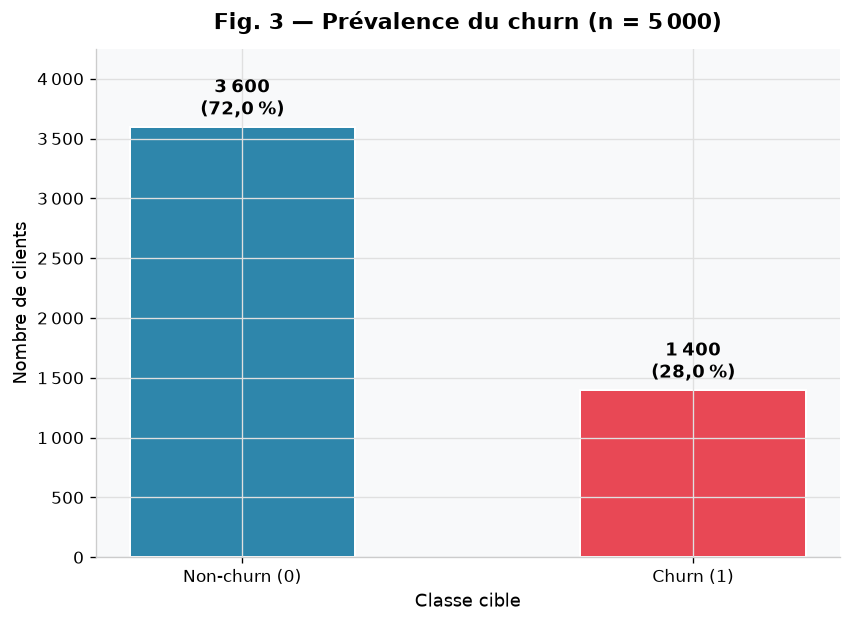

In [30]:
fig_cible, tableau_cible = eda.distribution_cible(df_eda, cible="churn")
display(tableau_cible)

In [31]:
_prevalence = float(df_eda["churn"].dropna().mean())
_ratio = (1 - _prevalence) / _prevalence
_part_minoritaire = min(_prevalence, 1 - _prevalence)
if _part_minoritaire < 0.10:
    _niveau_desequilibre = "fort"
elif _part_minoritaire < 0.40:
    _niveau_desequilibre = "modéré"
else:
    _niveau_desequilibre = "faible (classes quasi équilibrées)"

display(
    Markdown(
        f"**Ce qu'il faut retenir.** Le taux de churn est de **{pourcentage(_prevalence)}**, soit "
        f"{nombre(_ratio, 1)} non-churners pour 1 churner : déséquilibre "
        f"**{_niveau_desequilibre}**. Un modèle naïf « toujours non-churn » aurait une accuracy "
        f"de {pourcentage(1 - _prevalence)} sans détecter un seul client à risque : l'accuracy "
        f"est écartée.\n\n"
        f"Trois métriques la remplacent (cibles fixées *a priori* au §2) :\n\n"
        f"- **PR-AUC** (aire sous la courbe précision-rappel), métrique de sélection : elle juge "
        f"la qualité de la liste des comptes signalés. Le hasard vaut la prévalence "
        f"({nombre(_prevalence)}) ; cible ≥ {nombre(config.CIBLES_PERFORMANCE['pr_auc_min'])} ;\n"
        f"- **ROC-AUC**, indépendante de la prévalence (hasard = 0,50) : cible ≥ "
        f"{nombre(config.CIBLES_PERFORMANCE['roc_auc_min'])} ;\n"
        f"- **recall** (rappel) au seuil de vigilance, car un churner manqué (faux négatif) coûte "
        f"bien plus qu'une surveillance inutile : seuil réglé pour un recall de "
        f"{nombre(config.RECALL_CIBLE_VIGILANCE)}, plancher "
        f"{nombre(config.CIBLES_PERFORMANCE['recall_vigilance_min'])}."
    )
)

**Ce qu'il faut retenir.** Le taux de churn est de **28,0 %**, soit 2,6 non-churners pour 1 churner : déséquilibre **modéré**. Un modèle naïf « toujours non-churn » aurait une accuracy de 72,0 % sans détecter un seul client à risque : l'accuracy est écartée.

Trois métriques la remplacent (cibles fixées *a priori* au §2) :

- **PR-AUC** (aire sous la courbe précision-rappel), métrique de sélection : elle juge la qualité de la liste des comptes signalés. Le hasard vaut la prévalence (0,28) ; cible ≥ 0,65 ;
- **ROC-AUC**, indépendante de la prévalence (hasard = 0,50) : cible ≥ 0,80 ;
- **recall** (rappel) au seuil de vigilance, car un churner manqué (faux négatif) coûte bien plus qu'une surveillance inutile : seuil réglé pour un recall de 0,80, plancher 0,75.

### 6.2 Test des hypothèses métier H1 à H14

Le §2 a posé quatorze intuitions du métier (« peu de connexions annoncent un départ »…). On
les confronte aux données **avant** de modéliser : une hypothèse confirmée justifie une
variable, une hypothèse infirmée signale une intuition fausse ou une donnée suspecte.

Pour chaque hypothèse, `eda.tester_hypotheses` compare churners et non-churners :

| Indicateur | Question posée | Lecture |
|---|---|---|
| médianes churn / non-churn | Les churners ont-ils des valeurs plus hautes ou plus basses ? | donne le sens observé, comparé au sens attendu |
| test de Mann-Whitney | L'écart peut-il venir du hasard ? | test sur les rangs, sans supposer de loi normale (variables asymétriques) |
| correction de Holm | Quatorze tests font-ils naître un faux positif ? | p-value ajustée ; risque global d'erreur ≤ 5 % |
| AUC orientée | L'effet est-il fort ? | probabilité qu'un churner soit du côté « risqué » ; 0,50 = aucun effet |

Verdict : **confirmée** (significative, sens attendu), **infirmée** (significative, sens
contraire) ou **non concluante**. Avec plusieurs milliers de clients, un effet minime peut
être significatif : l'AUC orientée dit s'il compte. H13 porte sur le **haut** de la
distribution du CSAT (quartile supérieur), sinon elle doublerait H7.

H9, H10 et H12 portent sur des ratios du §7 (`ajouter_features_metier`). Ils sont calculés
ligne par ligne, sans paramètre appris : les calculer ici ne crée aucune fuite.

,variable,libelle,sens_attendu,mesure,mediane_churn,mediane_non_churn,sens_observe,p_value_holm,auc_orientee,verdict
id,,,,,,,,,,
H1,taux_adoption_pct,Un faible taux d'adoption augmente le risque de churn,-,médiane,"34,50","53,60",-,"8,71e-87","0,685",confirmée
H2,connexions_30j,Peu de connexions sur 30 jours augmentent le risque de churn,-,médiane,"4,00","21,00",-,"3,27e-102","0,696",confirmée
H3,heures_usage_30j,Peu d'heures d'usage sur 30 jours augmentent le risque,-,médiane,"1,00","8,00",-,"3,28e-97","0,697",confirmée
H4,fonctionnalites_utilisees,Peu de fonctionnalités utilisées augmentent le risque de churn,-,médiane,"3,00","6,00",-,"3,14e-98","0,692",confirmée
H5,derniere_connexion_jours,Une longue période depuis la dernière connexion augmente le risque de churn,+,médiane,"4,00","1,00",+,"3,89e-80","0,670",confirmée
H6,tickets_support_90j,De nombreux tickets support augmentent le risque,+,médiane,"3,00","2,00",+,"5,91e-72","0,661",confirmée
H7,csat,Une faible satisfaction (CSAT) augmente le risque de churn,-,médiane,"3,00","4,00",-,"4,78e-77","0,671",confirmée
H8,retards_paiement_12m,Des retards de paiement augmentent le risque de churn,+,médiane,"1,00","0,00",+,"2,41e-84","0,661",confirmée
H9,taux_utilisation_sieges,Une forte adoption (sièges utilisés / souscrits) réduit le risque de churn,-,médiane,"0,34","0,54",-,"4,01e-92","0,686",confirmée


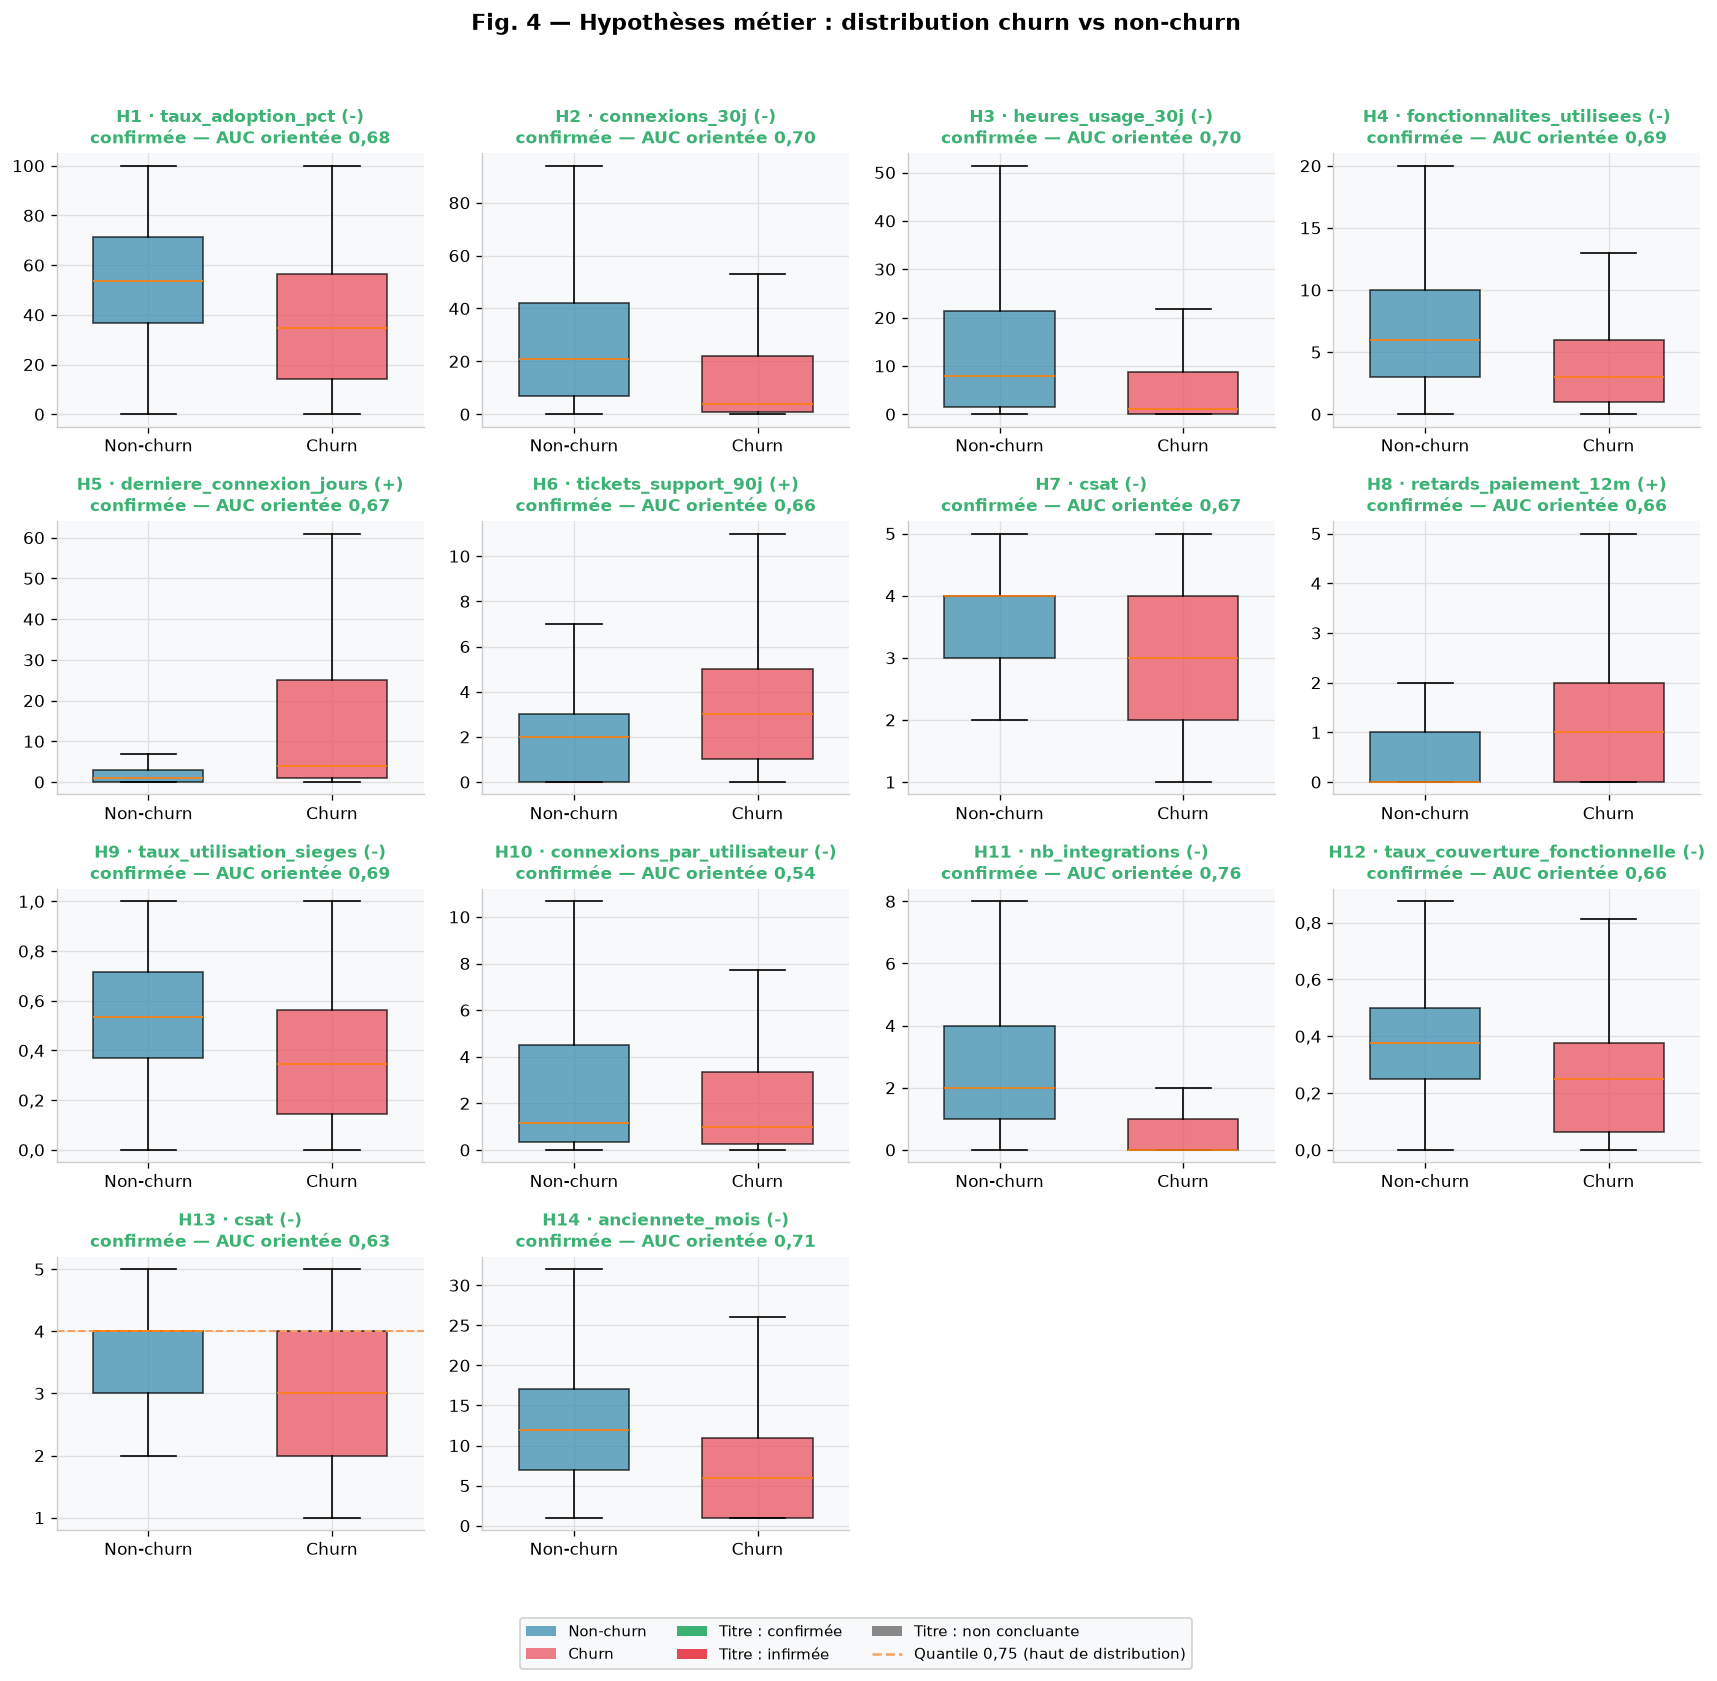

In [32]:
_SEUIL_EFFET_NOTABLE = 0.60  # AUC orientée : en deçà, effet réel mais faible (convention a priori)

_df_derive = ajouter_features_metier(df_eda)
_cols_derivees = [c for c in _df_derive.columns if c not in df_eda.columns]
df_hypotheses = df_eda.join(_df_derive[_cols_derivees])
fig_hypotheses, tableau_hypotheses = eda.tester_hypotheses(df_hypotheses, cible="churn")

display(
    styler_fr(
        tableau_hypotheses.drop(columns="p_value_brute"),
        {
            "mediane_churn": lambda v: nombre(v, 2),
            "mediane_non_churn": lambda v: nombre(v, 2),
            "p_value_holm": scientifique,
            "auc_orientee": lambda v: nombre(v, 3),
        },
    )
)

In [33]:
_verdicts = tableau_hypotheses["verdict"].value_counts()
_confirmees = tableau_hypotheses[tableau_hypotheses["verdict"] == "confirmée"]
_non_confirmees = tableau_hypotheses[tableau_hypotheses["verdict"] != "confirmée"]
_effets_faibles = _confirmees[_confirmees["auc_orientee"] < _SEUIL_EFFET_NOTABLE]
_plus_fortes = _confirmees["auc_orientee"].nlargest(3)


def _liste_hyp(ids: pd.Index) -> str:
    return ", ".join(
        f"{h} `{tableau_hypotheses.loc[h, 'variable']}` "
        f"({nombre(tableau_hypotheses.loc[h, 'auc_orientee'], 3)})"
        for h in ids
    )


_auc_h1 = float(tableau_hypotheses.loc["H1", "auc_orientee"])
_auc_h9 = float(tableau_hypotheses.loc["H9", "auc_orientee"])
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Sur {len(tableau_hypotheses)} hypothèses : "
        + ", ".join(f"**{n}** {v}(s)" for v, n in _verdicts.items())
        + ". "
        + (
            f"Non confirmées : {_liste_hyp(_non_confirmees.index)} : l'intuition métier n'est "
            f"pas soutenue par les données et la variable devra faire ses preuves au §12. "
            if len(_non_confirmees)
            else "Toutes les intuitions du métier vont dans le sens observé. "
        )
        + f"\n\n- **Effets les plus nets** (AUC orientée) : {_liste_hyp(_plus_fortes.index)}.\n"
        + (
            f"- **Effets réels mais faibles** (AUC < {nombre(_SEUIL_EFFET_NOTABLE)}) : "
            f"{_liste_hyp(_effets_faibles.index)}. Utiles en complément, insuffisants seuls.\n"
            if len(_effets_faibles)
            else ""
        )
        + f"- **H9 double H1** (AUC {nombre(_auc_h9, 3)} contre {nombre(_auc_h1, 3)}) : "
        f"`taux_utilisation_sieges` est le taux d'adoption ramené entre 0 et 1, et le contrôle "
        f"de cohérence du §7 le confirme. Redondance attendue, à garder en tête pour lire "
        f"l'importance des variables au §12.\n\n"
        f"Aucune hypothèse prise seule n'approche une séparation parfaite : le risque de départ "
        f"se lit dans la **combinaison** de signaux d'usage, de support, de facturation et de "
        f"contrat, ce qui justifie un modèle multivarié plutôt qu'une règle sur une variable."
    )
)

**Ce qu'il faut retenir.** Sur 14 hypothèses : **14** confirmée(s). Toutes les intuitions du métier vont dans le sens observé. 

- **Effets les plus nets** (AUC orientée) : H11 `nb_integrations` (0,759), H14 `anciennete_mois` (0,714), H3 `heures_usage_30j` (0,697).
- **Effets réels mais faibles** (AUC < 0,60) : H10 `connexions_par_utilisateur` (0,543). Utiles en complément, insuffisants seuls.
- **H9 double H1** (AUC 0,686 contre 0,685) : `taux_utilisation_sieges` est le taux d'adoption ramené entre 0 et 1, et le contrôle de cohérence du §7 le confirme. Redondance attendue, à garder en tête pour lire l'importance des variables au §12.

Aucune hypothèse prise seule n'approche une séparation parfaite : le risque de départ se lit dans la **combinaison** de signaux d'usage, de support, de facturation et de contrat, ce qui justifie un modèle multivarié plutôt qu'une règle sur une variable.

**Forme des distributions.** Les boîtes ci-dessus montrent des queues longues. On mesure
leur asymétrie (0 = symétrique, au-delà de 1 = forte, seuil `config.SEUIL_ASYMETRIE_LOG`) et
le taux de churn parmi les valeurs extrêmes (*outliers*, hors de [Q1 − 1,5 × IQR ;
Q3 + 1,5 × IQR], règle de Tukey). Si ce taux diffère nettement du reste, l'extrême décrit un
profil réel et ne doit pas être supprimé.

In [34]:
_COLS_NUM_EDA = [c for c in _COLS_NUM if c not in config.COLONNES_INTERDITES]
_MIN_OUTLIERS = 30  # effectif minimal pour qu'un taux de churn soit interprétable


def _profil_extremes(serie: pd.Series) -> dict[str, float]:
    q1, q3 = serie.quantile([0.25, 0.75])
    extreme = (serie < q1 - 1.5 * (q3 - q1)) | (serie > q3 + 1.5 * (q3 - q1))
    churn = df_eda.loc[serie.index, "churn"]
    return {
        "asymétrie": float(serie.skew()),
        "n_outliers": int(extreme.sum()),
        "churn_outliers": float(churn[extreme].mean()) if extreme.any() else np.nan,
        "churn_autres": float(churn[~extreme].mean()),
    }


tableau_formes = pd.DataFrame(
    {c: _profil_extremes(df_eda[c].dropna()) for c in _COLS_NUM_EDA}
).T.sort_values("asymétrie", ascending=False)
tableau_formes["écart_points"] = np.where(
    tableau_formes["n_outliers"] >= _MIN_OUTLIERS,
    100 * (tableau_formes["churn_outliers"] - tableau_formes["churn_autres"]),
    np.nan,
)
display(
    styler_fr(
        tableau_formes,
        {
            "asymétrie": lambda v: nombre(v, 2),
            "n_outliers": entier,
            "churn_outliers": pourcentage,
            "churn_autres": pourcentage,
            "écart_points": lambda v: nombre(v, 1, signe=True),
        },
    )
)

,asymétrie,n_outliers,churn_outliers,churn_autres,écart_points
utilisateurs_actifs,"4,73",628,"16,9 %","29,6 %","-12,7"
revenu_mensuel_recurrent_eur,"4,60",681,"22,5 %","29,0 %","-6,5"
derniere_connexion_jours,"4,54",799,"60,5 %","21,8 %","+38,6"
sieges_souscrits,"3,57",788,"24,0 %","28,8 %","-4,8"
heures_usage_30j,"2,29",322,"9,0 %","29,6 %","-20,6"
retards_paiement_12m,"1,79",419,"62,1 %","24,9 %","+37,1"
fonctionnalites_utilisees,"1,38",183,"9,3 %","28,7 %","-19,4"
connexions_30j,"1,27",93,"8,6 %","28,4 %","-19,8"
nb_integrations,"1,13",117,"1,7 %","28,8 %","-27,1"
tickets_support_90j,"1,11",37,"64,9 %","27,7 %","+37,1"


In [35]:
_SEUIL_ECART = 10  # points de pourcentage
_asym_fortes = tableau_formes.index[
    tableau_formes["asymétrie"].abs() > config.SEUIL_ASYMETRIE_LOG
].tolist()
_extremes_informatifs = tableau_formes.index[
    tableau_formes["écart_points"].abs() >= _SEUIL_ECART
].tolist()


def _liste_cols(cols: pd.Index | list[str]) -> str:
    return ", ".join(f"`{c}`" for c in cols)


display(
    Markdown(
        f"**Ce qu'il faut retenir.** **{len(_asym_fortes)}** des {len(_COLS_NUM_EDA)} variables "
        f"sont fortement asymétriques ({_liste_cols(_asym_fortes)}) : comptages, durées et "
        f"montants, avec beaucoup de petites valeurs et une queue de comptes extrêmes. Pour "
        f"**{len(_extremes_informatifs)}** variables ({_liste_cols(_extremes_informatifs)}), "
        f"le taux de churn des extrêmes s'écarte d'au moins {_SEUIL_ECART} points de celui des "
        f"autres clients : ces extrêmes sont les profils à repérer.\n\n"
        f"Conséquences : **aucun outlier n'est supprimé ni plafonné** ; l'imputation se fait par "
        f"la **médiane**, peu sensible aux extrêmes ; les arbres ne voient que l'ordre des "
        f"valeurs et ignorent l'asymétrie. Pour la régression logistique, une standardisation ne "
        f"réduit pas une queue (transformation affine) : seul un `log1p` le fait, hypothèse "
        f"testée au §7.8.3."
    )
)

**Ce qu'il faut retenir.** **11** des 15 variables sont fortement asymétriques (`utilisateurs_actifs`, `revenu_mensuel_recurrent_eur`, `derniere_connexion_jours`, `sieges_souscrits`, `heures_usage_30j`, `retards_paiement_12m`, `fonctionnalites_utilisees`, `connexions_30j`, `nb_integrations`, `tickets_support_90j`, `delai_reponse_support_h`) : comptages, durées et montants, avec beaucoup de petites valeurs et une queue de comptes extrêmes. Pour **10** variables (`utilisateurs_actifs`, `derniere_connexion_jours`, `heures_usage_30j`, `retards_paiement_12m`, `fonctionnalites_utilisees`, `connexions_30j`, `nb_integrations`, `tickets_support_90j`, `delai_reponse_support_h`, `csat`), le taux de churn des extrêmes s'écarte d'au moins 10 points de celui des autres clients : ces extrêmes sont les profils à repérer.

Conséquences : **aucun outlier n'est supprimé ni plafonné** ; l'imputation se fait par la **médiane**, peu sensible aux extrêmes ; les arbres ne voient que l'ordre des valeurs et ignorent l'asymétrie. Pour la régression logistique, une standardisation ne réduit pas une queue (transformation affine) : seul un `log1p` le fait, hypothèse testée au §7.8.3.

### 6.3 Variables catégorielles — qualité avant encodage

Avant l'encodage one-hot du §7 (une colonne par modalité), trois contrôles : la
**cardinalité** (nombre de colonnes créées), les **variantes typographiques** (« France » et
« france␣ » deviendraient deux colonnes, normalisées par `.strip().lower()` au §7.3.5) et
les **modalités rares** (effectif < 10), qui risquent de manquer dans un pli de
cross-validation (validation croisée). La figure montre les modalités brutes ;
`commentaire_csm` est audité à part (§6.6).

,n,n_manquants,cardinalité,cardinalité_normalisée,variantes_typographiques,exemple_variantes,n_modalités_rares,n_rares_normalisées,mode,fréquence_mode_pct
colonne,,,,,,,,,,
secteur,4 750,250,28,7,21,«␣Commerce␣» / «COMMERCE» / «Commerce» / «commerce»,0,0,commerce,"19,1 %"
pays,4 800,200,6,6,0,,0,0,france,"56,1 %"
taille_entreprise,5 000,0,12,4,8,«␣ETI␣» / «ETI» / «eti»,0,0,pme,"41,4 %"
plan,5 000,0,16,4,12,«␣Business␣» / «BUSINESS» / «Business» / «business»,0,0,pro,"35,4 %"
couleur_theme_interface,5 000,0,5,5,0,,0,0,clair,"21,5 %"
code_datacenter,5 000,0,4,4,0,,0,0,eu-w1,"25,3 %"
groupe_experimentation,5 000,0,3,3,0,,0,0,control,"34,3 %"
jour_souscription,5 000,0,7,7,0,,0,0,mardi,"15,1 %"


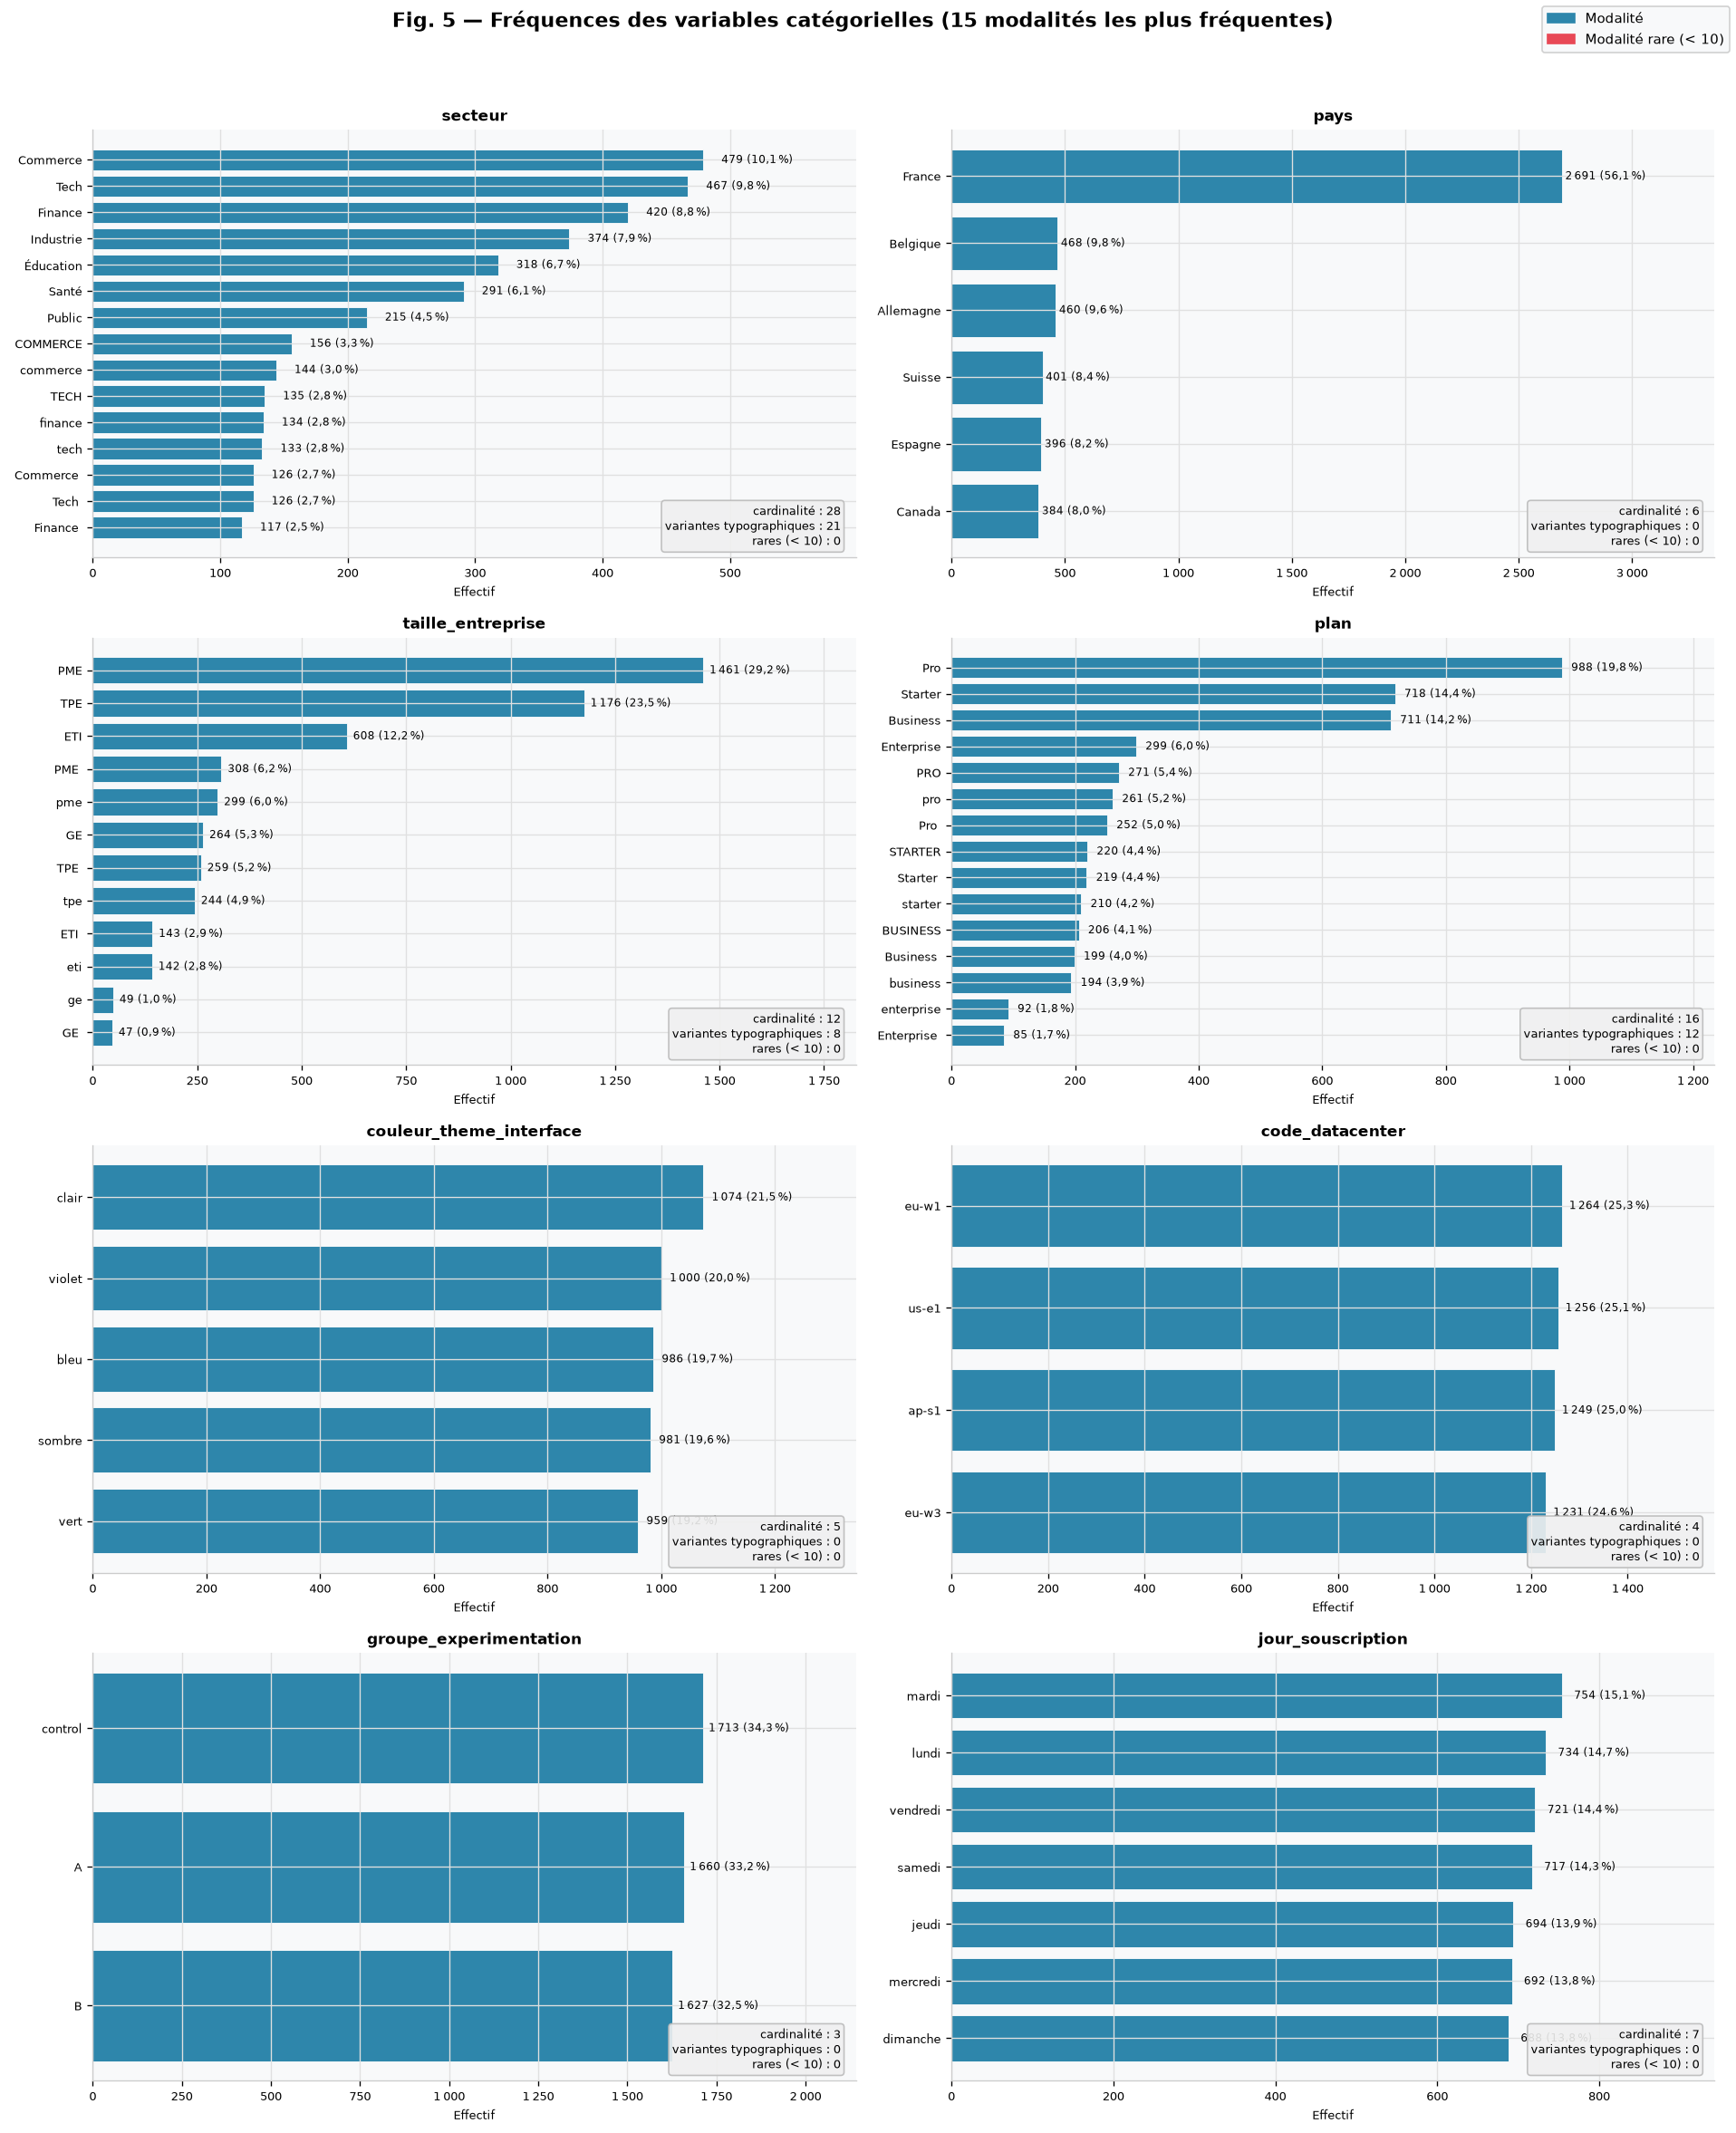

In [36]:
_COLS_CAT_EDA = [
    "secteur",
    "pays",
    "taille_entreprise",
    "plan",
    "couleur_theme_interface",
    "code_datacenter",
    "groupe_experimentation",
    "jour_souscription",
]
_SEUIL_RARE = 10

fig_cat, tableau_cat = eda.univarie_categorielles(df_eda, _COLS_CAT_EDA, seuil_rare=_SEUIL_RARE)
display(
    styler_fr(
        tableau_cat.drop(columns="seuil_rare"),
        {"fréquence_mode_pct": lambda v: pourcentage(v / 100)},
    )
)

In [37]:
_n_variantes = int(tableau_cat["variantes_typographiques"].sum())
_cols_variantes = tableau_cat[tableau_cat["variantes_typographiques"] > 0]
_col_exemple = _cols_variantes["variantes_typographiques"].idxmax() if _n_variantes else None
_n_rares_tot = int(tableau_cat["n_modalités_rares"].sum())
_n_rares_norm = int(tableau_cat["n_rares_normalisées"].sum())
_card_brute = int(tableau_cat["cardinalité"].sum())
_card_norm = int(tableau_cat["cardinalité_normalisée"].sum())
_cols_manquants = tableau_cat[tableau_cat["n_manquants"] > 0]

display(
    Markdown(
        "**Ce qu'il faut retenir.**\n\n"
        + (
            f"- **{_n_variantes} variantes typographiques** sur {len(_cols_variantes)} colonnes "
            f"({_liste_cols(_cols_variantes.index)}) ; par exemple `{_col_exemple}` contient "
            f"{_cols_variantes.loc[_col_exemple, 'exemple_variantes']} (« ␣ » = espace). Sans "
            f"normalisation : {entier(_card_brute)} modalités au lieu de {entier(_card_norm)}, "
            f"soit {entier(_card_brute - _card_norm)} colonnes one-hot en trop.\n"
            if _n_variantes
            else "- **Aucune variante typographique.**\n"
        )
        + (
            f"- **{_n_rares_tot} modalité(s) rare(s)**, {_n_rares_norm} après normalisation.\n"
            if _n_rares_tot
            else f"- **Aucune modalité rare** (effectif < {_SEUIL_RARE}). Une modalité inconnue "
            "en production serait codée par un vecteur nul (`handle_unknown='ignore'`).\n"
        )
        + (
            "- **Manquants** : "
            + ", ".join(
                f"`{c}` ({pourcentage(ligne['n_manquants'] / len(df_eda))})"
                for c, ligne in _cols_manquants.iterrows()
            )
            + ", imputés par une modalité `inconnu`.\n"
            if len(_cols_manquants)
            else "- **Aucun manquant.**\n"
        )
    )
)

**Ce qu'il faut retenir.**

- **41 variantes typographiques** sur 3 colonnes (`secteur`, `taille_entreprise`, `plan`) ; par exemple `secteur` contient «␣Commerce␣» / «COMMERCE» / «Commerce» / «commerce» (« ␣ » = espace). Sans normalisation : 81 modalités au lieu de 40, soit 41 colonnes one-hot en trop.
- **Aucune modalité rare** (effectif < 10). Une modalité inconnue en production serait codée par un vecteur nul (`handle_unknown='ignore'`).
- **Manquants** : `secteur` (5,0 %), `pays` (4,0 %), imputés par une modalité `inconnu`.


### 6.4 Pouvoir discriminant univarié et première détection de fuites

Une variable qui prédit presque parfaitement le churn **à elle seule**, sans modèle, est en
général une information connue *après* la résiliation : c'est une data leakage (fuite de
données). On mesure donc le lien de chaque variable avec la cible, prise isolément.

**Indicateur : la ROC-AUC univariée.** Si l'on tire au hasard un churner et un non-churner,
c'est la probabilité que la variable les classe dans le bon ordre. Elle est préférée ici à
la PR-AUC parce que sa référence est la même pour toutes les variables (0,50 = aucun lien)
et qu'elle est symétrique : on retient `max(AUC, 1 − AUC)` et la colonne `sens` indique si
les valeurs élevées vont avec plus (« ↑ churn ») ou moins (« ↓ churn ») de churn. La PR-AUC
reste la métrique de sélection du modèle (§6.1) : elle répond à une autre question.

Pour une catégorielle, le score est le taux de churn de la modalité (normalisée, §7.3.5) :
AUC légèrement optimiste, effet faible vu la cardinalité (§6.3).

**Seuil d'alerte : ROC-AUC ≥ 0,85**, fixé *a priori*, niveau que des variables d'usage, de
support ou de facturation n'atteignent pas seules. Dépasser le seuil est une **alerte**, pas
une preuve : la preuve est temporelle. Rester sous le seuil ne garantit rien non plus : les
colonnes suspectes sont examinées une à une (§6.5 à §6.7).

In [38]:
_SEUIL_FUITE = 0.85
# Colonnes non évaluées, avec la raison affichée dans le commentaire
_EXCLUES_DIAG = {
    "client_id": "identifiant technique, sans valeur prédictive",
    "commentaire_csm": "texte libre, audité au §6.6",
    "date_souscription": "date brute, non comparable telle quelle ; étudiée au §6.11",
}

# Les colonnes interdites sont gardées volontairement pour les faire ressortir
df_diag = df_eda.copy()
# Même normalisation qu'au §7.3.5 : une modalité = un taux de churn
for _col_diag in _COLS_CAT_EDA:
    df_diag[_col_diag] = df_diag[_col_diag].str.strip().str.lower()
tableau_fuite = fuite.diagnostiquer_fuite(
    df_diag, cible="churn", seuil=_SEUIL_FUITE, exclure=set(_EXCLUES_DIAG)
)
display(
    styler_fr(
        tableau_fuite.drop(columns="seuil").set_index("colonne"),
        {"auc_univariee": lambda v: nombre(v, 3), "part_manquants": pourcentage},
    )
)

2026-10-04 22:26:19.026 | WARNING  | churn_saas.fuite:diagnostiquer_fuite:417 - FUITE SUSPECTÉE : sante_compte_fin_periode (AUC=0.9986) — vérifier manuellement.


,type,auc_univariee,sens,part_manquants,suspecte_fuite
colonne,,,,,
sante_compte_fin_periode,numérique,"0,999",↓ churn,"0,0 %",True
nb_integrations,numérique,"0,759",↓ churn,"4,0 %",False
anciennete_mois,numérique,"0,714",↓ churn,"0,0 %",False
heures_usage_30j,numérique,"0,697",↓ churn,"6,0 %",False
connexions_30j,numérique,"0,696",↓ churn,"0,0 %",False
fonctionnalites_utilisees,numérique,"0,692",↓ churn,"0,0 %",False
taux_adoption_pct,numérique,"0,685",↓ churn,"5,0 %",False
csat,numérique,"0,670",↓ churn,"8,0 %",False
derniere_connexion_jours,numérique,"0,670",↑ churn,"0,0 %",False


In [39]:
_fuite_idx = tableau_fuite.set_index("colonne")
_suspects = _fuite_idx.index[_fuite_idx["suspecte_fuite"]].tolist()
# Variables légitimes : celles qui ne sont pas interdites par config
_legitimes = _fuite_idx.drop(index=config.COLONNES_INTERDITES, errors="ignore")
_meilleure_legitime = _legitimes["auc_univariee"].idxmax()
_auc_meilleure_legitime = float(_legitimes["auc_univariee"].max())
# Colonnes interdites que le seuil ne détecte pas
_interdites_sous_seuil = [
    c
    for c in config.COLONNES_INTERDITES
    if c in _fuite_idx.index and not _fuite_idx.loc[c, "suspecte_fuite"]
]
_max_manquants = _legitimes.loc[_legitimes["type"] == "numérique", "part_manquants"]


def _liste_auc(tableau: pd.DataFrame) -> str:
    return ", ".join(f"`{c}` ({nombre(v, 3)})" for c, v in tableau["auc_univariee"].items())


display(
    Markdown(
        "**Ce qu'il faut retenir.**\n\n"
        + (
            f"- **Fuite signalée** : {_liste_auc(_fuite_idx.loc[_suspects])} atteint le seuil "
            f"de {nombre(_SEUIL_FUITE)}, alors que la meilleure variable légitime, "
            f"`{_meilleure_legitime}`, plafonne à {nombre(_auc_meilleure_legitime, 3)}. "
            f"L'argument décisif est temporel : `sante_compte_fin_periode` est calculée en "
            f"**fin** de période, après la résiliation. Démonstration au §6.5.\n"
            if _suspects
            else f"- **Aucune colonne** n'atteint le seuil de {nombre(_SEUIL_FUITE)}.\n"
        )
        + (
            "- **Le seuil ne suffit pas** : "
            + _liste_auc(_fuite_idx.loc[_interdites_sous_seuil])
            + " reste sous le seuil alors que la colonne est interdite, car connue après la "
            "décision du client (§6.7). Chaque variable doit aussi être disponible *avant* la "
            "prédiction.\n"
            if _interdites_sous_seuil
            else ""
        )
        + "- **Signaux légitimes** : les sens observés recoupent les hypothèses confirmées au "
        "§6.2 ; les catégorielles sont reprises au §6.8.\n"
        f"- **Manquants** : l'AUC des numériques porte sur les lignes renseignées (au plus "
        f"{pourcentage(_max_manquants.max())} de manquants, pour `{_max_manquants.idxmax()}`). "
        f"Le signal porté par l'absence elle-même est capté par les indicateurs de manquance "
        f"du pipeline (§7).\n"
        "- **Colonnes non évaluées** : "
        + " ; ".join(f"`{c}` ({raison})" for c, raison in _EXCLUES_DIAG.items())
        + "."
    )
)

**Ce qu'il faut retenir.**

- **Fuite signalée** : `sante_compte_fin_periode` (0,999) atteint le seuil de 0,85, alors que la meilleure variable légitime, `nb_integrations`, plafonne à 0,759. L'argument décisif est temporel : `sante_compte_fin_periode` est calculée en **fin** de période, après la résiliation. Démonstration au §6.5.
- **Le seuil ne suffit pas** : `valeur_vie_client_eur` (0,584) reste sous le seuil alors que la colonne est interdite, car connue après la décision du client (§6.7). Chaque variable doit aussi être disponible *avant* la prédiction.
- **Signaux légitimes** : les sens observés recoupent les hypothèses confirmées au §6.2 ; les catégorielles sont reprises au §6.8.
- **Manquants** : l'AUC des numériques porte sur les lignes renseignées (au plus 10,0 % de manquants, pour `delai_reponse_support_h`). Le signal porté par l'absence elle-même est capté par les indicateurs de manquance du pipeline (§7).
- **Colonnes non évaluées** : `client_id` (identifiant technique, sans valeur prédictive) ; `commentaire_csm` (texte libre, audité au §6.6) ; `date_souscription` (date brute, non comparable telle quelle ; étudiée au §6.11).

### 6.5 Démonstration de la fuite — `sante_compte_fin_periode`

Le §6.4 a donné l'**alerte** : prise seule, `sante_compte_fin_periode` sépare presque
parfaitement churners et non-churners. Cette section **mesure** ce que la variable change dans
un vrai modèle.

**Pourquoi c'est une fuite.** Selon le cahier des charges et le dictionnaire de données (§5), ce score de
santé est calculé **en fin de période d'observation**, c'est-à-dire après que le churn a été
constaté (ou non). On cherche à prédire la résiliation *avant* l'échéance, pour laisser le temps
d'agir. À ce moment-là, le score n'existe pas encore. Un modèle qui l'utilise apprend donc un
signal indisponible en production : c'est une **fuite temporelle** (*temporal leakage*).

**Protocole.** On entraîne le même modèle deux fois, avec et sans la variable ; seule cette
variable change entre les deux conditions :

- **Données** : `df_eda`, c'est-à-dire les lignes dédoublonnées dont les numériques ont été
  convertis de façon robuste au début du §6 ;
- **Variables** : les numériques non interdites. Les catégorielles sont écartées pour garder un
  pipeline minimal : la démonstration porte sur une seule colonne, pas sur le meilleur modèle ;
- **Split** : un seul découpage 80/20 stratifié sur la cible, avec la graine du projet, et le
  même pour les deux conditions ;
- **Pipeline** : imputation par la médiane, standardisation, régression logistique
  (`class_weight="balanced"`), fitté sur le train seulement ;
- **Mesures** : **PR-AUC**, métrique de sélection retenue au §6.1, et ROC-AUC en complément.

C'est une démonstration contrôlée, pas le modèle final. Celui-ci est évalué en validation
croisée au §9. Un seul split ne donne pas d'intervalle de confiance, mais il suffit ici :
l'écart attendu est bien plus grand que la variabilité d'un découpage à l'autre.

La figure produite par la cellule suivante montre les deux courbes ROC : **avec** la variable
à gauche, **sans** à droite.

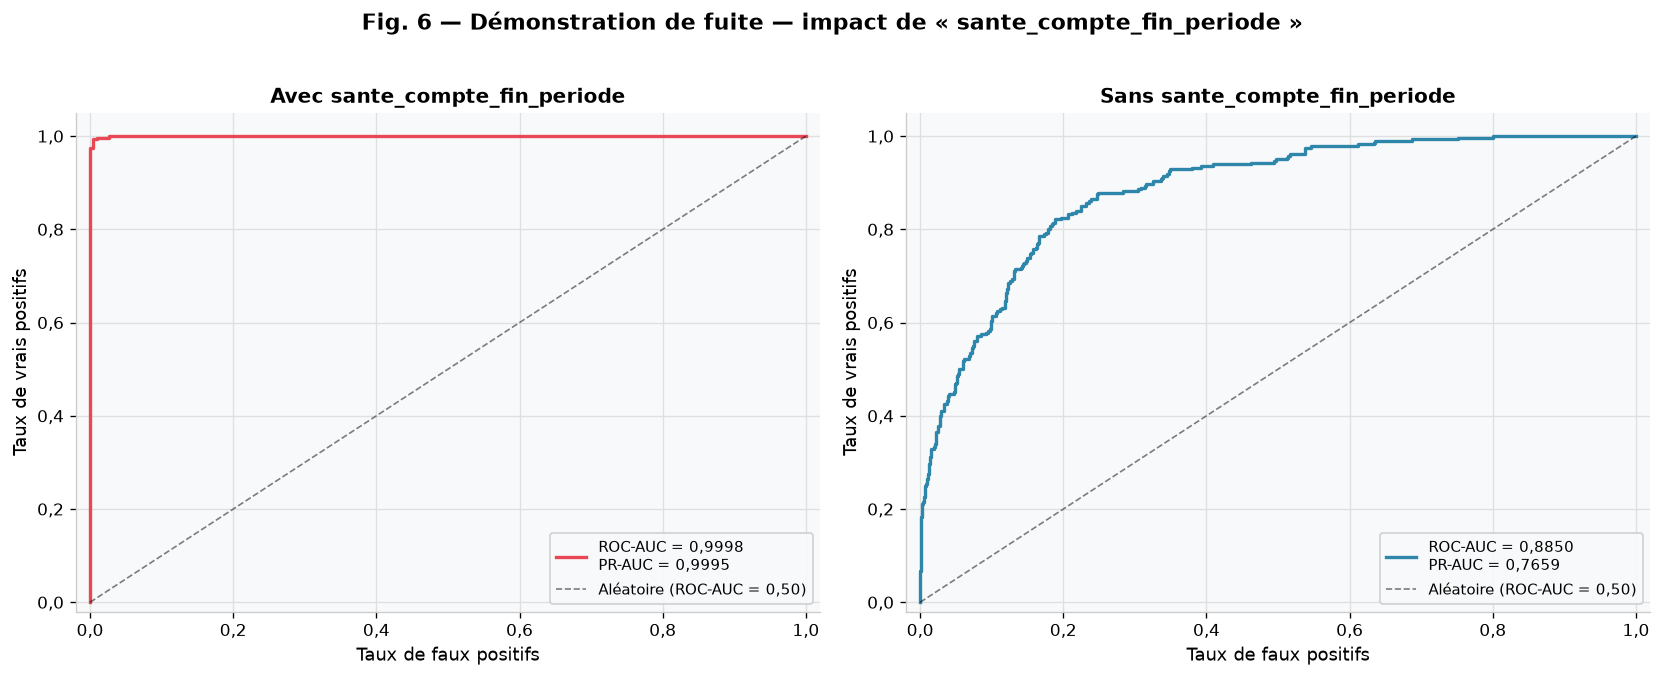

In [40]:
exp = fuite.experience_fuite(df_eda, cible="churn", colonne_suspecte="sante_compte_fin_periode")

In [41]:
display(
    pd.DataFrame(
        {
            "Condition": [
                f"Avec sante_compte_fin_periode ({exp.avec.n_features} variables)",
                f"Sans sante_compte_fin_periode ({exp.sans.n_features} variables)",
                "Écart (Δ)",
            ],
            "PR-AUC": [
                nombre(exp.avec.pr_auc, 4),
                nombre(exp.sans.pr_auc, 4),
                nombre(exp.delta_pr_auc, 4, signe=True),
            ],
            "ROC-AUC": [
                nombre(exp.avec.auc_roc, 4),
                nombre(exp.sans.auc_roc, 4),
                nombre(exp.delta_auc_roc, 4, signe=True),
            ],
        }
    ).set_index("Condition")
)

,PR-AUC,ROC-AUC
Condition,,
Avec sante_compte_fin_periode (16 variables),"0,9995","0,9998"
Sans sante_compte_fin_periode (15 variables),"0,7659","0,8850"
Écart (Δ),"+0,2336","+0,1148"


In [42]:
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Ajouter `sante_compte_fin_periode` fait passer la "
        f"**PR-AUC** de **{nombre(exp.sans.pr_auc, 4)}** à **{nombre(exp.avec.pr_auc, 4)}** "
        f"(**{nombre(exp.delta_pr_auc, 4, signe=True)}**), et la ROC-AUC de "
        f"{nombre(exp.sans.auc_roc, 4)} à {nombre(exp.avec.auc_roc, 4)} "
        f"({nombre(exp.delta_auc_roc, 4, signe=True)}). Pour comparaison, un modèle aléatoire "
        f"obtiendrait une PR-AUC égale à la prévalence, {nombre(_prevalence, 2)}.\n\n"
        f"Sans la variable, le modèle détecte déjà nettement les churners. Avec elle, la "
        f"détection devient presque parfaite (courbe de gauche de la figure), ce qui n'est pas "
        f"plausible pour un problème de churn. Ce gain est **artificiel** : il vient d'une "
        f"information qui n'existera pas au moment de prédire. Le modèle ne pourrait pas "
        f"tourner tel quel en production, faute de cette colonne. Et même en remplaçant la "
        f"valeur manquante, il n'atteindrait jamais la performance mesurée ici.\n\n"
        f"Le cahier des charges signalait cette fuite. La démarche la **confirme par la mesure**, "
        f"en deux temps : l'alerte univariée au §6.4, puis l'écart de performance ci-dessus. "
        f"`sante_compte_fin_periode` est inscrite dans `config.COLONNES_INTERDITES` et exclue "
        f"de tout pipeline de modélisation."
    )
)

**Ce qu'il faut retenir.** Ajouter `sante_compte_fin_periode` fait passer la **PR-AUC** de **0,7659** à **0,9995** (**+0,2336**), et la ROC-AUC de 0,8850 à 0,9998 (+0,1148). Pour comparaison, un modèle aléatoire obtiendrait une PR-AUC égale à la prévalence, 0,28.

Sans la variable, le modèle détecte déjà nettement les churners. Avec elle, la détection devient presque parfaite (courbe de gauche de la figure), ce qui n'est pas plausible pour un problème de churn. Ce gain est **artificiel** : il vient d'une information qui n'existera pas au moment de prédire. Le modèle ne pourrait pas tourner tel quel en production, faute de cette colonne. Et même en remplaçant la valeur manquante, il n'atteindrait jamais la performance mesurée ici.

Le cahier des charges signalait cette fuite. La démarche la **confirme par la mesure**, en deux temps : l'alerte univariée au §6.4, puis l'écart de performance ci-dessus. `sante_compte_fin_periode` est inscrite dans `config.COLONNES_INTERDITES` et exclue de tout pipeline de modélisation.

### 6.6 Audit de `commentaire_csm` — fuite sémantique et données personnelles

Le commentaire du Customer Success Manager (CSM) figure parmi les leurres suspectés, mais il
pose deux risques de plus :

1. **Fuite sémantique** : rédigé *après* la décision du client, il encoderait la cible. Un
   mot alarmant ne le prouve pas (un CSM qui repère un risque à temps fournit un signal
   légitime) ; la question est chronologique, et la date de rédaction est inconnue.
2. **Données personnelles** : un champ saisi à la main peut citer un nom, un e-mail ou un
   téléphone (minimisation, RGPD art. 5(1)(c)).

L'audit procède en trois temps : nature du champ, signal par modalité, **provenance** de ce
signal (résumé de variables déjà présentes, ou information postérieure au churn).

In [43]:
_csm = df_eda["commentaire_csm"]
_csm_renseigne = _csm.dropna()
_longueurs_csm = _csm_renseigne.str.len()
_taux_manquant_csm = float(_csm.isna().mean())
_churn_si_manquant = float(df_eda.loc[_csm.isna(), "churn"].mean())
_churn_si_renseigne = float(df_eda.loc[_csm.notna(), "churn"].mean())

# Recherche automatique des données personnelles détectables par motif
_MOTIFS_PII = {
    "adresse e-mail": r"[\w.+-]+@[\w-]+\.[\w.]+",
    "numéro de téléphone": r"(?:\+\d{1,3}[\s.]?)?\d(?:[\s.-]?\d{2}){4}",
}
_n_pii = {
    nom: int(_csm_renseigne.str.contains(motif, regex=True).sum())
    for nom, motif in _MOTIFS_PII.items()
}

display(
    pd.Series(
        {
            "Commentaires renseignés": entier(len(_csm_renseigne)),
            "Valeurs manquantes": pourcentage(_taux_manquant_csm),
            "Libellés distincts": entier(_csm_renseigne.nunique()),
            "Longueur (caractères) min – max": (
                f"{entier(_longueurs_csm.min())} – {entier(_longueurs_csm.max())}"
            ),
            "Taux de churn si commentaire manquant": pourcentage(_churn_si_manquant),
            "Taux de churn si commentaire renseigné": pourcentage(_churn_si_renseigne),
            **{f"Libellés contenant un(e) {nom}": entier(n) for nom, n in _n_pii.items()},
        },
        name="Valeur",
    )
    .rename_axis("Indicateur")
    .to_frame()
)

,Valeur
Indicateur,
Commentaires renseignés,2 227
Valeurs manquantes,"55,5 %"
Libellés distincts,13
Longueur (caractères) min – max,4 – 43
Taux de churn si commentaire manquant,"27,4 %"
Taux de churn si commentaire renseigné,"28,8 %"
Libellés contenant un(e) adresse e-mail,0
Libellés contenant un(e) numéro de téléphone,0


In [44]:
display(
    Markdown(
        f"**Ce qu'il faut retenir.** `commentaire_csm` n'est **pas du texte libre** : ses "
        f"{entier(len(_csm_renseigne))} valeurs se répartissent en "
        f"**{entier(_csm_renseigne.nunique())} libellés normalisés** "
        f"({entier(_longueurs_csm.min())} à {entier(_longueurs_csm.max())} caractères), comme "
        f"un menu déroulant. Vide dans {pourcentage(_taux_manquant_csm)} des cas, il donne "
        f"{pourcentage(_churn_si_manquant)} de churn quand il manque et "
        f"{pourcentage(_churn_si_renseigne)} sinon : l'absence n'est pas un signal en soi. "
        f"**Données personnelles** : "
        + (
            "aucun libellé ne contient d'e-mail ni de téléphone"
            if sum(_n_pii.values()) == 0
            else ", ".join(f"{nom} : {entier(n)} libellé(s)" for nom, n in _n_pii.items())
        )
        + " ; le vocabulaire étant fermé, le contrôle est exhaustif (tableau suivant)."
    )
)

**Ce qu'il faut retenir.** `commentaire_csm` n'est **pas du texte libre** : ses 2 227 valeurs se répartissent en **13 libellés normalisés** (4 à 43 caractères), comme un menu déroulant. Vide dans 55,5 % des cas, il donne 27,4 % de churn quand il manque et 28,8 % sinon : l'absence n'est pas un signal en soi. **Données personnelles** : aucun libellé ne contient d'e-mail ni de téléphone ; le vocabulaire étant fermé, le contrôle est exhaustif (tableau suivant).

**Signal et provenance de chaque libellé.** Pour chaque libellé : taux de churn avec son
intervalle de Wilson à 95 % (un taux extrême sur quelques dizaines de comptes est moins sûr
qu'il n'en a l'air), médianes de cinq variables que le modèle reçoit déjà et, **à titre de
diagnostic seulement**, la part de comptes dont `sante_compte_fin_periode` (interdite, §6.5)
est nulle, témoin de ce qui n'est connu qu'en fin de période.

,effectif,taux_churn,ic_bas,ic_haut,taux_adoption_pct,heures_usage_30j,derniere_connexion_jours,tickets_support_90j,csat,part_sante_nulle
commentaire_csm,,,,,,,,,,
Usage en forte baisse ce trimestre.,31,"100,0 %","89,0 %","100,0 %","0,0","0,0","84,0","2,0","3,0","64,5 %"
"Compte peu actif, relance nécessaire.",29,"96,6 %","82,8 %","99,4 %","0,0","0,0","84,0","1,0","3,0","65,5 %"
"Client insatisfait, risque de départ.",233,"47,6 %","41,3 %","54,0 %","42,9","3,3","2,0","5,0","2,0","11,6 %"
Support très sollicité récemment.,36,"47,2 %","32,0 %","63,0 %","43,3","2,0","1,5","8,0","3,0","11,1 %"
Mécontentement exprimé au support.,224,"46,0 %","39,6 %","52,5 %","42,2","2,4","2,0","4,0","2,0","12,1 %"
Déploiement interne limité.,129,"44,2 %","35,9 %","52,8 %","13,6","0,1","12,0","1,0","4,0","9,3 %"
"Multiples tickets ouverts, friction élevée.",44,"43,2 %","29,7 %","57,8 %","47,0","5,9","1,5","8,0","3,0","11,4 %"
Faible adoption des sièges.,147,"41,5 %","33,8 %","49,6 %","15,2","0,2","9,0","2,0","4,0","9,5 %"
Suivi standard.,312,"24,0 %","19,6 %","29,1 %","53,1","7,9","1,0","1,0","4,0","1,6 %"


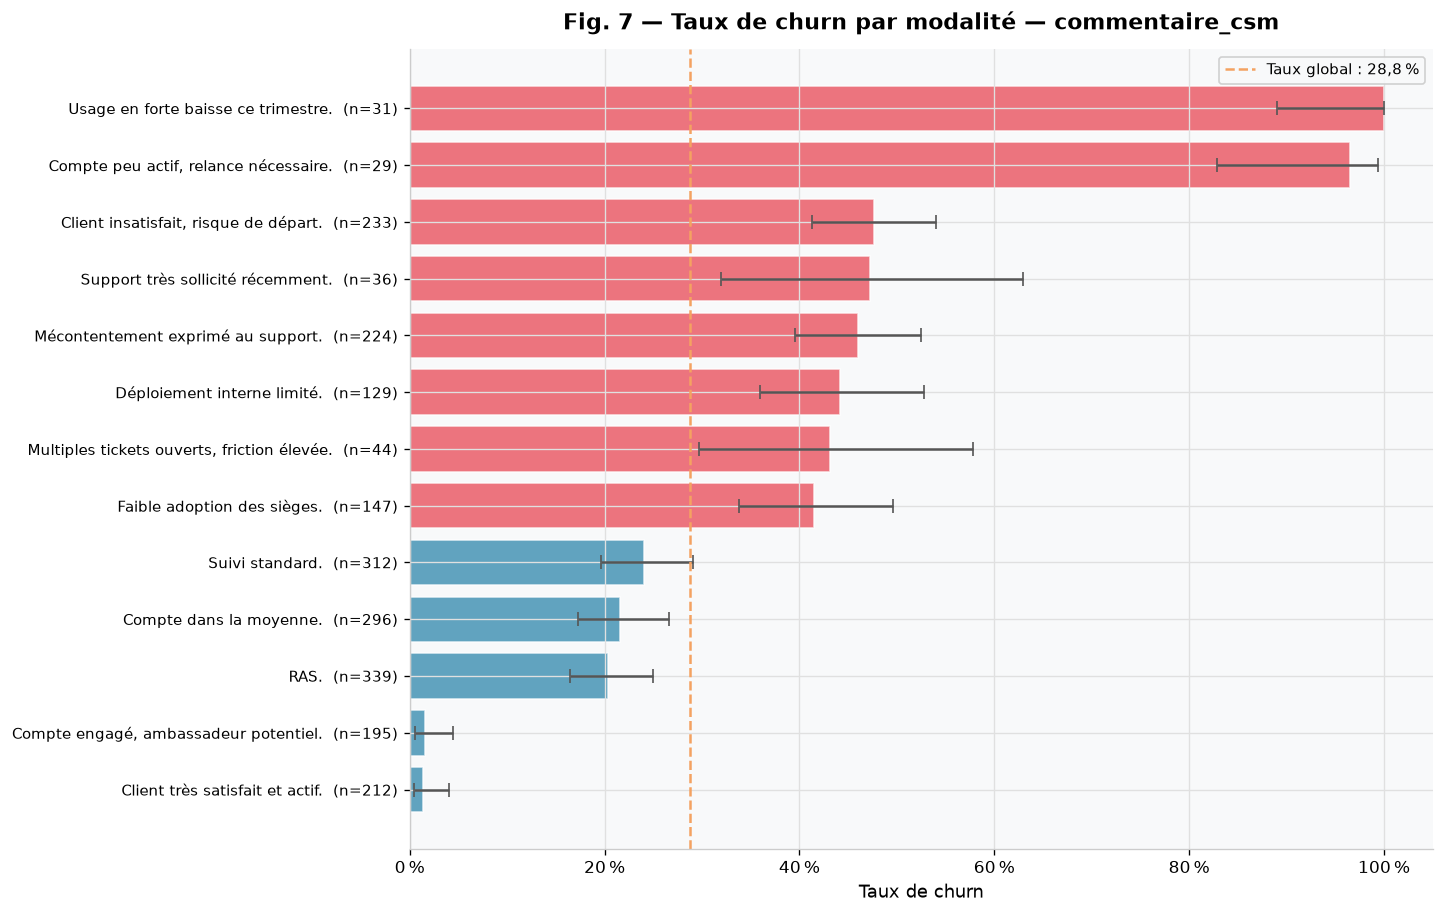

In [45]:
_VARS_PROFIL_CSM = [
    "taux_adoption_pct",
    "heures_usage_30j",
    "derniere_connexion_jours",
    "tickets_support_90j",
    "csat",
]
fig_csm, tableau_csm = eda.taux_churn_par_modalite(df_eda, colonne="commentaire_csm", cible="churn")
_grp_csm = df_eda.groupby("commentaire_csm")
profil_csm = tableau_csm[["effectif", "taux_churn", "ic_bas", "ic_haut"]].join(
    _grp_csm[_VARS_PROFIL_CSM].median()
)
profil_csm["part_sante_nulle"] = _grp_csm["sante_compte_fin_periode"].apply(
    lambda s: float(s.dropna().eq(0).mean())
)
display(
    styler_fr(
        profil_csm,
        {
            "effectif": entier,
            **{v: pourcentage for v in ["taux_churn", "ic_bas", "ic_haut", "part_sante_nulle"]},
            **{v: (lambda x: nombre(x, 1)) for v in _VARS_PROFIL_CSM},
        },
    )
)

In [46]:
_SEUIL_CHURN_EXTREME = 0.90
_modalite_max = tableau_csm["taux_churn"].idxmax()
_mod_extremes = tableau_csm.index[tableau_csm["taux_churn"] >= _SEUIL_CHURN_EXTREME].tolist()
_masque_extremes = df_eda["commentaire_csm"].isin(_mod_extremes)
_part_sante_nulle_ext = float(
    df_eda.loc[_masque_extremes, "sante_compte_fin_periode"].dropna().eq(0).mean()
)
_churn_sante_nulle = float(df_eda.loc[df_eda["sante_compte_fin_periode"].eq(0), "churn"].mean())

display(
    Markdown(
        f"**Ce qu'il faut retenir.** Le taux de churn va de "
        f"{pourcentage(tableau_csm['taux_churn'].min())} à "
        f"**{pourcentage(tableau_csm.loc[_modalite_max, 'taux_churn'])}** (« {_modalite_max} », "
        f"IC₉₅ [{pourcentage(tableau_csm.loc[_modalite_max, 'ic_bas'])} ; "
        f"{pourcentage(tableau_csm.loc[_modalite_max, 'ic_haut'])}]), pour "
        f"{pourcentage(_prevalence)} en moyenne : ce n'est pas un leurre au sens strict. Mais "
        f"les libellés traduisent en mots les variables voisines (adoption basse, tickets "
        f"nombreux, CSAT bas) : le commentaire est d'abord un **résumé qualitatif** de "
        f"variables déjà présentes (redondance mesurée au §6.10).\n\n"
        f"Les {len(_mod_extremes)} libellé(s) à plus de {pourcentage(_SEUIL_CHURN_EXTREME, 0)} "
        f"de churn ({', '.join(f'« {m} »' for m in _mod_extremes)}, "
        f"{entier(_masque_extremes.sum())} comptes) décrivent des **comptes à l'arrêt** "
        f"(dernière connexion il y a "
        f"{entier(df_eda.loc[_masque_extremes, 'derniere_connexion_jours'].median())} jours en "
        f"médiane), dont **{pourcentage(_part_sante_nulle_ext)}** ont un score de santé de fin "
        f"de période nul, score qui s'accompagne de {pourcentage(_churn_sante_nulle)} de churn. "
        f"Ils décrivent très probablement des clients **déjà perdus** : la fuite est plausible."
    )
)

**Ce qu'il faut retenir.** Le taux de churn va de 1,4 % à **100,0 %** (« Usage en forte baisse ce trimestre. », IC₉₅ [89,0 % ; 100,0 %]), pour 28,0 % en moyenne : ce n'est pas un leurre au sens strict. Mais les libellés traduisent en mots les variables voisines (adoption basse, tickets nombreux, CSAT bas) : le commentaire est d'abord un **résumé qualitatif** de variables déjà présentes (redondance mesurée au §6.10).

Les 2 libellé(s) à plus de 90 % de churn (« Usage en forte baisse ce trimestre. », « Compte peu actif, relance nécessaire. », 60 comptes) décrivent des **comptes à l'arrêt** (dernière connexion il y a 84 jours en médiane), dont **65,0 %** ont un score de santé de fin de période nul, score qui s'accompagne de 100,0 % de churn. Ils décrivent très probablement des clients **déjà perdus** : la fuite est plausible.

**Décision : `commentaire_csm` est exclue du modèle** (`config.COLONNES_INTERDITES`), pour
trois raisons dont aucune ne repose sur un mot alarmant :

1. **Redondance** : son information est déjà portée, plus finement, par l'usage et le
   support (profil ci-dessus, jumelle identifiée au §6.10) ;
2. **Fuite non exclue** : la date de rédaction est inconnue et les libellés les plus
   prédictifs coïncident avec un score de santé de fin de période nul ;
3. **Précaution RGPD** : sans donnée personnelle ici, mais saisi à la main en production ;
   l'exclure dès la conception (*privacy by design*, §4) évite de devoir le filtrer.

Exclue du prétraitement, son importance au §12 sera **nulle par construction** : ce zéro ne
prouve rien, le verdict est celui de ce paragraphe.

### 6.7 Caractérisation de `valeur_vie_client_eur` — CLV réalisée ou future ?

La CLV (*customer lifetime value*, valeur vie client) est exclue des variables du churn dans
tous les cas : *prospective*, elle dépend du comportement futur (fuite) ; *réalisée*, elle
n'apprend rien d'utile. Reste à savoir ce qu'elle mesure, car elle sert de cible secondaire
(§2, §12).

Une CLV réalisée (cumul des revenus encaissés ≈ MRR × ancienneté) a deux signatures : elle
ne dépasse presque jamais MRR × ancienneté, et son élasticité à l'ancienneté (c dans
log CLV = a + b·log MRR + c·log ancienneté) vaut environ 1. Une CLV prospective (MRR × durée
de vie estimée) dépasse souvent le CA encaissé et dépend peu de l'ancienneté. Les seuils
sont fixés *a priori* dans `fuite.caracteriser_clv` ; les corrélations de Pearson sont
descriptives seulement.

In [47]:
res_clv = fuite.caracteriser_clv(df_eda)
_seuils_clv = res_clv["seuils"]

_criteres_clv = {
    "Part des comptes où CLV > MRR × ancienneté": (
        pourcentage(res_clv["part_clv_sup_cumul"]),
        f"≤ {pourcentage(_seuils_clv['part_max_realisee'], 0)}",
        f"≥ {pourcentage(_seuils_clv['part_min_prospective'], 0)}",
    ),
    "Élasticité de la CLV à l'ancienneté (c)": (
        nombre(res_clv["elasticite_anciennete"], 2),
        f"≥ {nombre(_seuils_clv['elasticite_min_realisee'])}",
        f"< {nombre(_seuils_clv['elasticite_max_prospective'])}",
    ),
    "Élasticité de la CLV au MRR (b)": (nombre(res_clv["elasticite_mrr"], 2), "≈ 1", "≈ 1"),
}
display(
    pd.DataFrame.from_dict(
        _criteres_clv,
        orient="index",
        columns=["Observé", "Attendu si réalisée", "Attendu si prospective"],
    ).rename_axis("Critère")
)
display(styler_fr(res_clv["stats_par_churn"], precision=0))

,Observé,Attendu si réalisée,Attendu si prospective
Critère,,,
Part des comptes où CLV > MRR × ancienneté,"79,7 %",≤ 10 %,≥ 50 %
Élasticité de la CLV à l'ancienneté (c),"0,21","≥ 0,70","< 0,50"
Élasticité de la CLV au MRR (b),"0,99",≈ 1,≈ 1


,n,CLV moyenne_€,CLV médiane_€,MRR médian_€
churn,,,,
0,3 490,82 432,13 598,773
1,1 360,53 198,6 940,501


In [48]:
_stats_clv = res_clv["stats_par_churn"]
_mois_mrr = res_clv["mois_mrr"]


def _p(valeur: float) -> str:
    # « p = 3,11e-07 », ou « p < 1e-300 » quand scipy renvoie 0 (sous-dépassement)
    texte = scientifique(valeur)
    return f"p {texte}" if texte.startswith("<") else f"p = {texte}"


display(
    Markdown(
        f"**Ce qu'il faut retenir.** La CLV est **{res_clv['nature_clv']}** : elle dépasse le CA "
        f"déjà encaissé pour {pourcentage(res_clv['part_clv_sup_cumul'])} des comptes, ce "
        f"qu'une somme de revenus passés ne peut pas faire, et son élasticité à l'ancienneté "
        f"n'est que de {nombre(res_clv['elasticite_anciennete'], 2)} (contre "
        f"{nombre(res_clv['elasticite_mrr'], 2)} au MRR). r(CLV, MRR × ancienneté) = "
        f"{nombre(res_clv['r_mrr_x_anciennete'], 3)} est même *inférieur* à r(CLV, MRR) = "
        f"{nombre(res_clv['r_mrr'], 3)} ({_p(res_clv['p_mrr'])}). Elle se lit comme **MRR × "
        f"durée de vie estimée** : {nombre(_mois_mrr.loc[0.5], 0)} mois de MRR en médiane "
        f"({nombre(_mois_mrr.loc[0.05], 0)} à {nombre(_mois_mrr.loc[0.95], 0)} entre les 5e et "
        f"95e percentiles).\n\n"
        f"Cette durée implicite est plus courte chez les churners (ρ de Spearman "
        f"{nombre(res_clv['rho_mois_churn'], 2)}, {_p(res_clv['p_mois_churn'])}) : la CLV "
        f"intègre déjà le risque de départ, nouvelle raison de l'exclure des variables. "
        f"{res_clv['avertissement']} La valeur à risque du §12 s'écrit donc sans elle : "
        f"`{res_clv['formule_valeur_risque']}`.\n\n"
        f"L'écart de CLV entre churners ({euros(_stats_clv.loc[1, 'CLV médiane_€'])} en médiane) "
        f"et non-churners ({euros(_stats_clv.loc[0, 'CLV médiane_€'])}) suit surtout celui du "
        f"MRR ({euros(_stats_clv.loc[1, 'MRR médian_€'])} contre "
        f"{euros(_stats_clv.loc[0, 'MRR médian_€'])}) : les comptes qui partent sont plus petits."
    )
)

**Ce qu'il faut retenir.** La CLV est **prospective** : elle dépasse le CA déjà encaissé pour 79,7 % des comptes, ce qu'une somme de revenus passés ne peut pas faire, et son élasticité à l'ancienneté n'est que de 0,21 (contre 0,99 au MRR). r(CLV, MRR × ancienneté) = 0,784 est même *inférieur* à r(CLV, MRR) = 0,840 (p < 1e-300). Elle se lit comme **MRR × durée de vie estimée** : 18 mois de MRR en médiane (6 à 57 entre les 5e et 95e percentiles).

Cette durée implicite est plus courte chez les churners (ρ de Spearman -0,13, p = 7,50e-20) : la CLV intègre déjà le risque de départ, nouvelle raison de l'exclure des variables. CLV prospective : elle intègre déjà une durée de vie estimée, donc le risque de départ ; la multiplier par P(churn) compterait ce risque deux fois. La valeur à risque du §12 s'écrit donc sans elle : `P(churn à 12 mois) × MRR_mensuel × 12 × marge_brute`.

L'écart de CLV entre churners (6 940 € en médiane) et non-churners (13 598 €) suit surtout celui du MRR (501 € contre 773 €) : les comptes qui partent sont plus petits.

### 6.8 Taux de churn par variable catégorielle discriminante

On cherche les segments les plus à risque. On retient d'abord les catégorielles dont le lien
avec le churn est **statistiquement établi**, puis on lit leur taux de churn par modalité.

**Critère : test du χ² d'indépendance corrigé par Benjamini-Hochberg (BH).** Le **V de
Cramér** mesure la force du lien (0 à 1) ; la p-value du χ² dit s'il se distingue du hasard ;
la correction BH évite qu'une variable sans lien passe le seuil de 5 % une fois sur vingt,
puisqu'on teste plusieurs variables. La ROC-AUC du §6.4 (colonne `auc_6_4`) n'est pas utilisée
comme critère : pour une catégorielle, elle est mécaniquement un peu au-dessus de 0,50 même
sans lien, et d'autant plus que les modalités sont nombreuses. Les calculs portent sur
`df_diag` (modalités normalisées au §6.4).

In [49]:
_ALPHA_BIVAR = 0.05
# Toutes les catégorielles du §6.3 sont testées ensemble : la correction BH porte sur ce lot
tableau_assoc_cat = eda.association_categorielles(
    df_diag, _COLS_CAT_EDA, cible="churn", alpha=_ALPHA_BIVAR
).join(tableau_fuite.set_index("colonne")["auc_univariee"].rename("auc_6_4"))
_COLS_BIVAR = tableau_assoc_cat.index[tableau_assoc_cat["significatif_BH"]].tolist()
_cols_ecartees_bivar = tableau_assoc_cat[~tableau_assoc_cat["significatif_BH"]]
# Significatives avant correction mais plus après : ce que la correction BH évite de retenir
_rejetees_par_bh = _cols_ecartees_bivar.index[
    _cols_ecartees_bivar["p_value_brute"] < _ALPHA_BIVAR
].tolist()
_leurres_testes = [c for c in config.COLONNES_LEURRES_SUSPECTES if c in tableau_assoc_cat.index]
_leurres_tous_non_signif = bool(_leurres_testes) and not bool(
    tableau_assoc_cat.loc[_leurres_testes, "significatif_BH"].any()
)

display(
    styler_fr(
        tableau_assoc_cat,
        {
            "n_modalites": entier,
            "v_cramer": lambda v: nombre(v, 3),
            "p_value_brute": scientifique,
            "p_value_BH": scientifique,
            "auc_6_4": lambda v: nombre(v, 3),
        },
    )
)

,n_modalites,v_cramer,p_value_brute,p_value_BH,significatif_BH,auc_6_4
colonne,,,,,,
plan,4,"0,138","2,29e-20","1,83e-19",True,"0,581"
taille_entreprise,4,"0,068","3,32e-05","1,33e-04",True,"0,541"
secteur,7,"0,052","4,52e-02","1,21e-01",False,"0,530"
jour_souscription,7,"0,045","1,21e-01","2,42e-01",False,"0,528"
pays,6,"0,031","4,68e-01","7,48e-01",False,"0,516"
code_datacenter,4,"0,019","6,34e-01","8,46e-01",False,"0,511"
couleur_theme_interface,5,"0,015","8,86e-01","9,66e-01",False,"0,509"
groupe_experimentation,3,"0,004","9,66e-01","9,66e-01",False,"0,502"


In [50]:
display(
    Markdown(
        "**Ce qu'il faut retenir.** "
        + (
            f"{len(_COLS_BIVAR)} variable(s) sur {len(tableau_assoc_cat)} ont un lien significatif "
            f"après correction BH : "
            + ", ".join(
                f"`{c}` (V = {nombre(tableau_assoc_cat.loc[c, 'v_cramer'], 3)})"
                for c in _COLS_BIVAR
            )
            + f". Le V le plus élevé reste modeste "
            f"({nombre(tableau_assoc_cat['v_cramer'].max(), 3)}) : lien réel, mais aucune ne "
            f"sépare seule churners et non-churners. "
            if _COLS_BIVAR
            else f"Aucune des {len(tableau_assoc_cat)} catégorielles n'a de lien significatif. "
        )
        + (
            f"La correction écarte {_liste_cols(_rejetees_par_bh)}, significative(s) avant "
            f"correction seulement : trop peu net pour exclure un faux positif. "
            if _rejetees_par_bh
            else ""
        )
        + (
            f"Aucun leurre suspecté ({_liste_cols(_leurres_testes)}) n'a de lien significatif."
            if _leurres_tous_non_signif
            else ""
        )
    )
)

**Ce qu'il faut retenir.** 2 variable(s) sur 8 ont un lien significatif après correction BH : `plan` (V = 0,138), `taille_entreprise` (V = 0,068). Le V le plus élevé reste modeste (0,138) : lien réel, mais aucune ne sépare seule churners et non-churners. La correction écarte `secteur`, significative(s) avant correction seulement : trop peu net pour exclure un faux positif. Aucun leurre suspecté (`couleur_theme_interface`, `code_datacenter`, `groupe_experimentation`) n'a de lien significatif.

Pour chaque variable retenue : taux de churn par modalité et **intervalle de Wilson à 95 %**
(fiable même sur un petit effectif). Intervalles qui se chevauchent : écart non établi.

**Ce qu'il faut retenir.** `plan` : de 37,5 % (starter) à 20,0 % (enterprise) ; modalités dont l'intervalle exclut le taux moyen — au-dessus : starter ; au-dessous : business, enterprise. `taille_entreprise` : de 31,7 % (tpe) à 23,4 % (eti) ; modalités dont l'intervalle exclut le taux moyen — au-dessus : tpe ; au-dessous : eti. Les modalités au-dessus sont les segments à cibler en premier.

Les 6 autres variables (V entre 0,004 et 0,052) ne sont pas exclues pour ce seul motif : une variable sans effet isolé peut compter en combinaison (mesure au §12.8). Seule `jour_souscription` est écartée, faute d'hypothèse métier (conclusion de l'EDA).

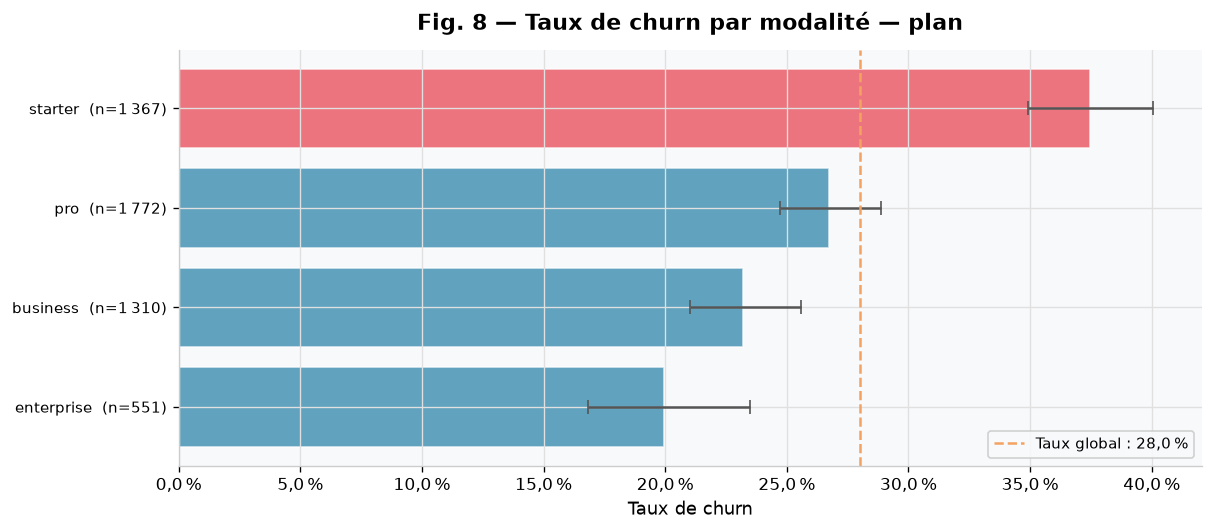

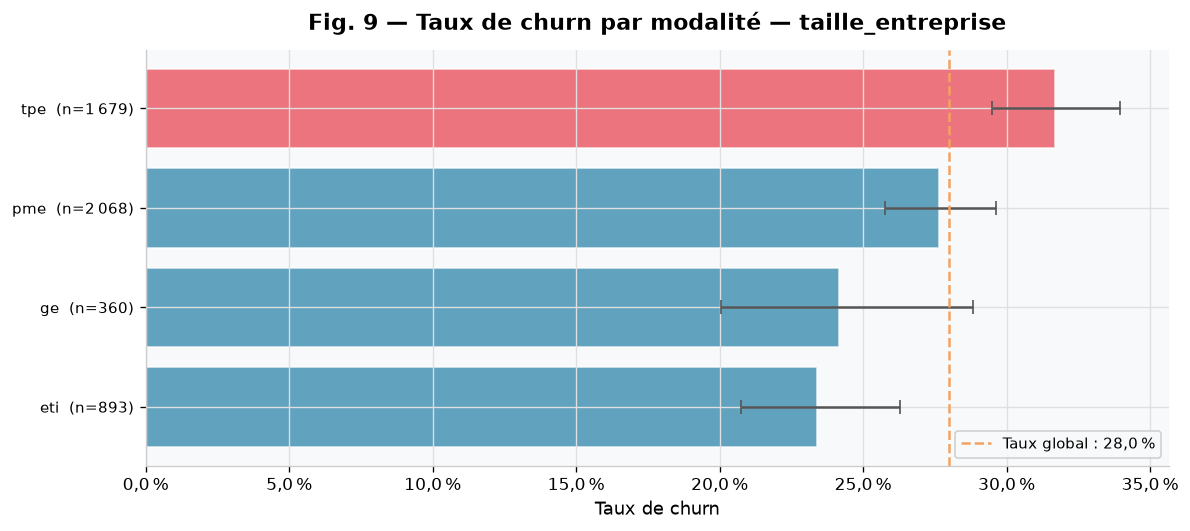

In [51]:
tableaux_bivar = {
    c: eda.taux_churn_par_modalite(df_diag, colonne=c, cible="churn")[1] for c in _COLS_BIVAR
}


def _modalites_hors_moyenne(tableau: pd.DataFrame) -> str:
    # Intervalle de Wilson entièrement d'un côté du taux moyen : écart établi
    au_dessus = tableau.index[tableau["ic_bas"] > _prevalence].tolist()
    au_dessous = tableau.index[tableau["ic_haut"] < _prevalence].tolist()
    return (
        f"au-dessus : {', '.join(au_dessus) or 'aucune'} ; "
        f"au-dessous : {', '.join(au_dessous) or 'aucune'}"
    )


display(
    Markdown(
        "**Ce qu'il faut retenir.** "
        + " ".join(
            f"`{c}` : de {pourcentage(t['taux_churn'].max())} ({t['taux_churn'].idxmax()}) à "
            f"{pourcentage(t['taux_churn'].min())} ({t['taux_churn'].idxmin()}) ; modalités dont "
            f"l'intervalle exclut le taux moyen — {_modalites_hors_moyenne(t)}."
            for c, t in tableaux_bivar.items()
        )
        + " Les modalités au-dessus sont les segments à cibler en premier.\n\n"
        f"Les {len(_cols_ecartees_bivar)} autres variables (V entre "
        f"{nombre(_cols_ecartees_bivar['v_cramer'].min(), 3)} et "
        f"{nombre(_cols_ecartees_bivar['v_cramer'].max(), 3)}) ne sont pas exclues pour ce seul "
        f"motif : une variable sans effet isolé peut compter en combinaison (mesure au §12.8). "
        f"Seule `jour_souscription` est écartée, faute d'hypothèse métier (conclusion de l'EDA)."
    )
)

**Encodage retenu : one-hot** (`OneHotEncoder(handle_unknown='ignore')`), fitté dans chaque
pli, pour toutes les catégorielles admises, significatives ou non. La cardinalité est faible
après normalisation (§6.3). Un encodage ordinal de `plan` ou `taille_entreprise` imposerait
un écart de risque constant entre niveaux, que les intervalles ci-dessus ne permettent pas de
vérifier. Le target encoding (encodage par la cible) n'apporte rien à cette cardinalité et
ouvre un risque de fuite (§7.9).

### 6.9 Matrice de corrélation — variables numériques validées

Deux variables presque colinéaires portent **la même information**. Pour un modèle linéaire,
le poids se répartit arbitrairement entre elles (coefficients instables) ; pour
l'explicabilité (§12.8), permuter l'une seule dégrade peu le modèle, puisque sa « jumelle »
compense. Trois mesures, sur les numériques du §6.2 :

| Mesure | Ce qu'elle détecte | Seuil |
|---|---|---|
| r de Pearson (heatmap) | lien **linéaire** entre deux variables | \|r\| ≥ 0,85 |
| ρ de Spearman | lien **monotone**, insensible aux extrêmes (variables asymétriques, §6.2) | \|ρ\| ≥ 0,85 |
| VIF (*variance inflation factor*) | variable reconstituée par **plusieurs** autres : 1 / (1 − R²) | VIF ≥ 10 |

,variable_1,variable_2,corrélation,ρ_spearman
0,sieges_souscrits,utilisateurs_actifs,"0,85","0,81"
1,sieges_souscrits,revenu_mensuel_recurrent_eur,"0,91","0,95"
2,connexions_30j,heures_usage_30j,"0,90","0,95"


,VIF
sieges_souscrits,"9,4"
connexions_30j,"8,2"
revenu_mensuel_recurrent_eur,"7,6"
heures_usage_30j,"5,4"
fonctionnalites_total,"4,9"
utilisateurs_actifs,"4,8"


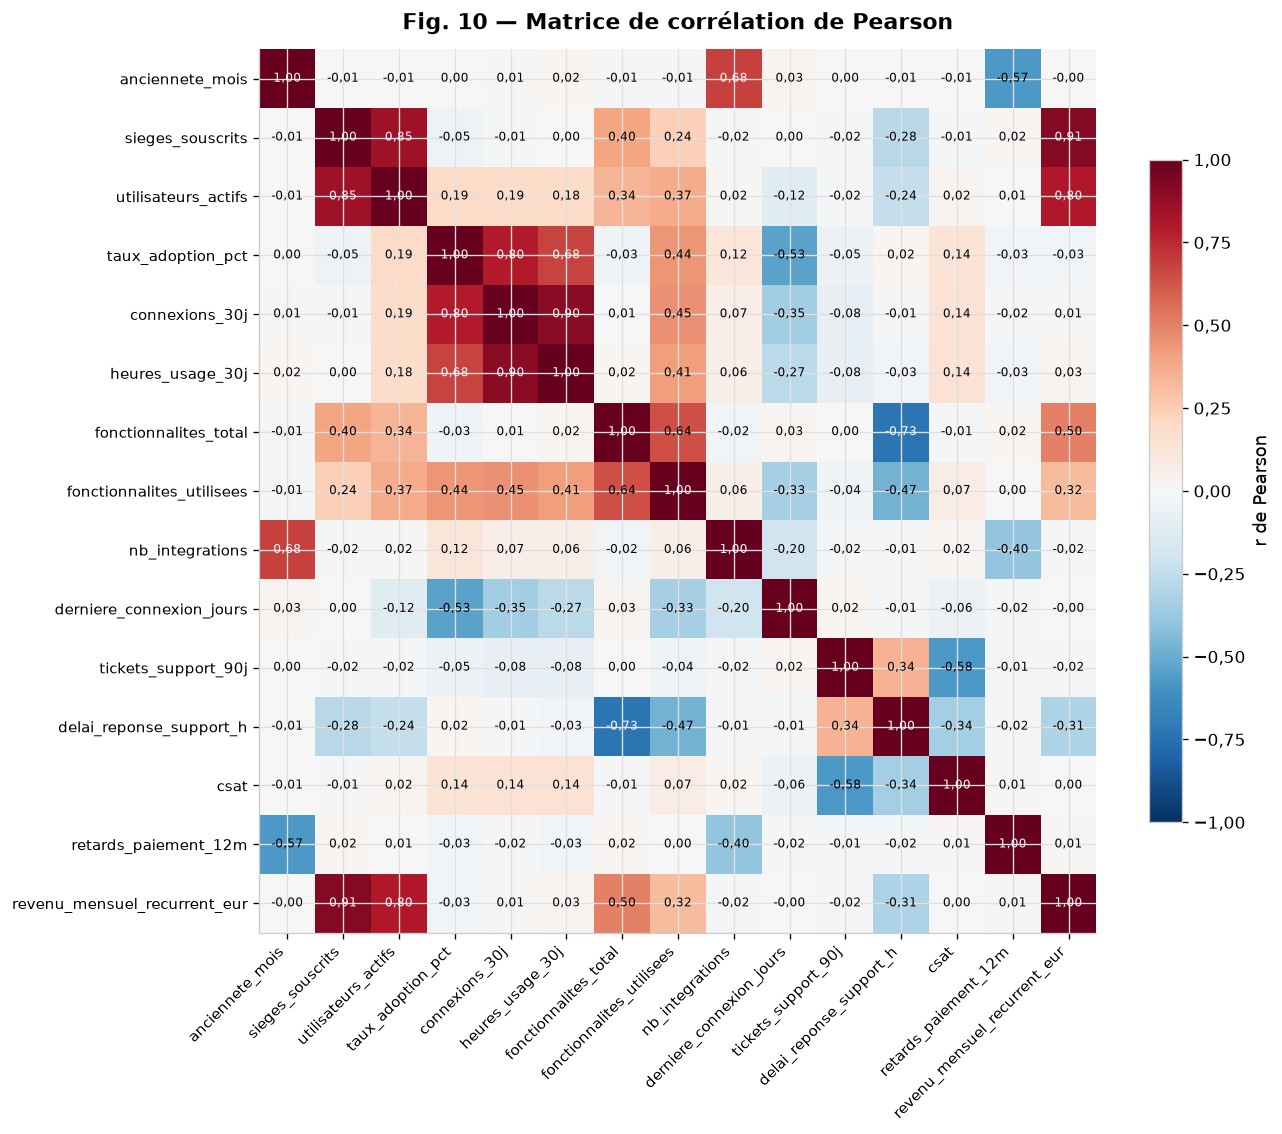

In [52]:
fig_corr, tableau_corr = eda.matrice_correlation(df_eda[_COLS_NUM_EDA], seuil_redondance=0.85)

# Contrôle de robustesse : les mêmes paires ressortent-elles avec un coefficient de rang ?
_spearman = df_eda[_COLS_NUM_EDA].corr(method="spearman")
tableau_corr["ρ_spearman"] = [
    round(float(_spearman.loc[v1, v2]), 4)
    for v1, v2 in zip(tableau_corr["variable_1"], tableau_corr["variable_2"], strict=True)
]

# VIF = diagonale de l'inverse de la matrice de corrélation de Pearson
_corr_pearson = df_eda[_COLS_NUM_EDA].corr(method="pearson")
tableau_vif = (
    pd.Series(np.diag(np.linalg.inv(_corr_pearson.to_numpy())), index=_corr_pearson.columns)
    .rename("VIF")
    .sort_values(ascending=False)
    .to_frame()
)
_vif_eleves = tableau_vif[tableau_vif["VIF"] >= 10]

if tableau_corr.empty:
    display(Markdown("Aucune paire redondante détectée (|r| ≥ 0,85)."))
else:
    display(
        styler_fr(
            tableau_corr,
            {"corrélation": lambda v: nombre(v, 2), "ρ_spearman": lambda v: nombre(v, 2)},
        )
    )
display(styler_fr(tableau_vif.head(6), {"VIF": lambda v: nombre(v, 1)}))

In [53]:
_n_paires = len(tableau_corr)
_liste_paires = " ; ".join(
    f"`{r.variable_1}` ↔ `{r.variable_2}` (r = {nombre(r.corrélation, 2)}, "
    f"ρ = {nombre(r.ρ_spearman, 2)})"
    for r in tableau_corr.itertuples()
)
_texte_vif = (
    f"**{len(_vif_eleves)} variable(s)** ont un VIF ≥ 10 ("
    + ", ".join(f"`{c}` : {nombre(v, 1)}" for c, v in _vif_eleves["VIF"].items())
    + ")"
    if len(_vif_eleves)
    else f"aucune variable n'a un VIF ≥ 10 (maximum : {nombre(tableau_vif['VIF'].max(), 1)})"
)
display(
    Markdown(
        f"**Ce qu'il faut retenir.** **{_n_paires} paire(s)** dépassent |r| ≥ 0,85"
        + (f" : {_liste_paires}." if _n_paires else ".")
        + f" Côté colinéarité multiple, {_texte_vif}."
    )
)

**Ce qu'il faut retenir.** **3 paire(s)** dépassent |r| ≥ 0,85 : `sieges_souscrits` ↔ `utilisateurs_actifs` (r = 0,85, ρ = 0,81) ; `sieges_souscrits` ↔ `revenu_mensuel_recurrent_eur` (r = 0,91, ρ = 0,95) ; `connexions_30j` ↔ `heures_usage_30j` (r = 0,90, ρ = 0,95). Côté colinéarité multiple, aucune variable n'a un VIF ≥ 10 (maximum : 9,4).

Ces redondances ont une **explication métier** : le MRR est un prix par siège multiplié par
les sièges ; sièges et utilisateurs actifs mesurent la taille du compte ; connexions et heures
mesurent la même intensité d'usage.

**Décision : on conserve les deux variables de chaque paire.** Aucune n'est une fuite ; la
pénalité L2 de la régression logistique (`C` réglé par Optuna, §9) stabilise les coefficients
et les arbres n'y sont pas sensibles ; chaque variable sert aux ratios du §7. L'importance des
variables (§12.8) et le verdict des leurres (§12.9) se lisent **en tenant compte des paires**.

### 6.10 Criblage des leurres — verdict provisoire

Une variable leurre ne porte aucune information sur le churn. Le cahier des charges en
suspecte quatre (`config.COLONNES_LEURRES_SUSPECTES`). Une importance de permutation nulle ne
suffit pas à conclure : une variable **redondante** avec une jumelle a aussi une importance
proche de zéro. On réunit donc trois preuves convergentes :

1. **Association avec le churn** : V de Cramér (χ²) ou AUC (Mann-Whitney), p-values corrigées
   par BH sur la famille des variables criblées (d'où des valeurs différentes du §6.8) ;
2. **Redondance** avec **toutes** les autres variables, par une mesure entre 0 et 1 adaptée
   au couple de types : V de Cramér (catégorielle × catégorielle), rapport de corrélation η
   (catégorielle × numérique), \|r\| de Pearson (numérique × numérique) ;
3. **Permutation importance et drop-column importance** sur le modèle : verdict au §12.9.

| Condition (dans l'ordre) | Verdict provisoire |
|---|---|
| redondance ≥ 0,70 avec une autre variable | redondant : une importance nulle au §12 ne prouvera rien |
| sinon, association significative (p_BH < 0,05) | potentiellement utile |
| sinon | leurre probable |

In [54]:
tableau_criblage_leurres = fuite.cribler_leurres(
    df_eda, cible="churn", colonnes=config.COLONNES_LEURRES_SUSPECTES
)
# Les colonnes d'importance ne sont renseignées qu'au §12 : inutile d'afficher des colonnes vides
display(
    styler_fr(
        tableau_criblage_leurres.drop(columns=["permutation_imp", "drop_column_imp"]),
        {
            "association_marginale": lambda v: nombre(v, 3),
            "p_value_BH": scientifique,
            "max_redondance": lambda v: nombre(v, 3),
        },
    )
)

,type,association_marginale,p_value_BH,significatif_BH,max_redondance,variable_jumelle,mesure_redondance,verdict_provisoire
colonne,,,,,,,,
couleur_theme_interface,catégorielle,"0,015","9,66e-01",False,"0,084",secteur,V de Cramér,leurre probable — à confirmer en §12
code_datacenter,catégorielle,"0,018","9,66e-01",False,"0,080",secteur,V de Cramér,leurre probable — à confirmer en §12
groupe_experimentation,catégorielle,"0,004","9,66e-01",False,"0,080",secteur,V de Cramér,leurre probable — à confirmer en §12
commentaire_csm,catégorielle,"0,435","3,27e-82",True,"0,829",derniere_connexion_jours,η,redondant — importance nulle ≠ leurre (point vigilance n°5)


In [55]:
_leurres_probables = tableau_criblage_leurres[
    tableau_criblage_leurres["verdict_provisoire"].str.startswith("leurre probable")
].index.tolist()
_redondants = tableau_criblage_leurres[
    tableau_criblage_leurres["verdict_provisoire"].str.startswith("redondant")
].index.tolist()
_potentiellement_utiles = tableau_criblage_leurres[
    tableau_criblage_leurres["verdict_provisoire"].str.startswith("potentiellement")
].index.tolist()


def _detail_criblage(col: str) -> str:
    """Résumé chiffré d'une ligne du criblage : association, p_BH et jumelle la plus proche."""
    ligne = tableau_criblage_leurres.loc[col]
    mesure_assoc = "V de Cramér" if ligne["type"] == "catégorielle" else "AUC"
    return (
        f"`{col}` ({mesure_assoc} {nombre(ligne['association_marginale'], 3)}, "
        f"p_BH {scientifique(ligne['p_value_BH'])} ; redondance max "
        f"{nombre(ligne['max_redondance'], 3)}, {ligne['mesure_redondance']} avec "
        f"`{ligne['variable_jumelle']}`)"
    )


_phrases_criblage = [
    f"**Ce qu'il faut retenir.** Sur les {len(tableau_criblage_leurres)} variables suspectées :"
]
if _leurres_probables:
    _phrases_criblage.append(
        f"- **{len(_leurres_probables)} leurre(s) probable(s)** : "
        + " ; ".join(_detail_criblage(c) for c in _leurres_probables)
        + ". Ni lien avec le churn, ni jumelle : elles n'apprennent rien, seules ou par "
        "l'intermédiaire d'une autre variable."
    )
if _redondants:
    _phrases_criblage.append(
        f"- **{len(_redondants)} redondant(s)** : "
        + " ; ".join(_detail_criblage(c) for c in _redondants)
        + ". Leur information est portée par la jumelle : une importance faible ne prouverait "
        "pas un leurre."
    )
if _potentiellement_utiles:
    _phrases_criblage.append(
        f"- **{len(_potentiellement_utiles)} potentiellement utile(s)** : "
        + " ; ".join(_detail_criblage(c) for c in _potentiellement_utiles)
        + ". Lien significatif et pas de jumelle : ce n'est pas un leurre."
    )
if "commentaire_csm" in tableau_criblage_leurres.index:
    _phrases_criblage.append(
        "\n`commentaire_csm` n'est pas un leurre au sens strict : lié au churn, il est rattaché "
        f"à `{tableau_criblage_leurres.loc['commentaire_csm', 'variable_jumelle']}`, ce qui "
        "confirme la redondance relevée au §6.6. Exclu de toute façon (§6.6), il n'est pas "
        "réévalué au §12.9."
    )
if "code_datacenter" in tableau_criblage_leurres.index:
    _regions = df_eda["code_datacenter"].astype(str)
    _regions_hors_ue = sorted(r for r in _regions.unique() if not r.startswith("eu-"))
    _phrases_criblage.append(
        f"\n`code_datacenter` héberge {pourcentage(_regions.isin(_regions_hors_ue).mean())} des "
        f"comptes hors UE ({', '.join(f'`{r}`' for r in _regions_hors_ue)}), sans lien avec leur "
        "pays : aucun hébergeur ne répartit ainsi ses clients, autre signe d'une variable "
        "fabriquée. L'hébergement hors UE est traité au §4.1."
    )
_phrases_criblage.append(
    "\nVerdict **provisoire** : la preuve fondée sur le modèle vient au §12.9."
)
display(Markdown("\n".join(_phrases_criblage)))

**Ce qu'il faut retenir.** Sur les 4 variables suspectées :
- **3 leurre(s) probable(s)** : `couleur_theme_interface` (V de Cramér 0,015, p_BH 9,66e-01 ; redondance max 0,084, V de Cramér avec `secteur`) ; `code_datacenter` (V de Cramér 0,018, p_BH 9,66e-01 ; redondance max 0,080, V de Cramér avec `secteur`) ; `groupe_experimentation` (V de Cramér 0,004, p_BH 9,66e-01 ; redondance max 0,080, V de Cramér avec `secteur`). Ni lien avec le churn, ni jumelle : elles n'apprennent rien, seules ou par l'intermédiaire d'une autre variable.
- **1 redondant(s)** : `commentaire_csm` (V de Cramér 0,435, p_BH 3,27e-82 ; redondance max 0,829, η avec `derniere_connexion_jours`). Leur information est portée par la jumelle : une importance faible ne prouverait pas un leurre.

`commentaire_csm` n'est pas un leurre au sens strict : lié au churn, il est rattaché à `derniere_connexion_jours`, ce qui confirme la redondance relevée au §6.6. Exclu de toute façon (§6.6), il n'est pas réévalué au §12.9.

`code_datacenter` héberge 50,1 % des comptes hors UE (`ap-s1`, `us-e1`), sans lien avec leur pays : aucun hébergeur ne répartit ainsi ses clients, autre signe d'une variable fabriquée. L'hébergement hors UE est traité au §4.1.

Verdict **provisoire** : la preuve fondée sur le modèle vient au §12.9.

### 6.11 Structure temporelle — split temporel possible ?

Entraîner sur le passé et évaluer sur le futur (split temporel) est souvent plus fidèle à la
production, s'il existe un axe qui sépare un *passé* d'un *futur*. Or `date_souscription` est
une **date d'entrée**, et tous les clients sont photographiés à la même date (§5). Une coupure
au 80e percentile isolerait-elle une période future, ou seulement des clients récents ?

PosixPath('~/churn_saas/reports/figures/11_structure_temporelle.png')

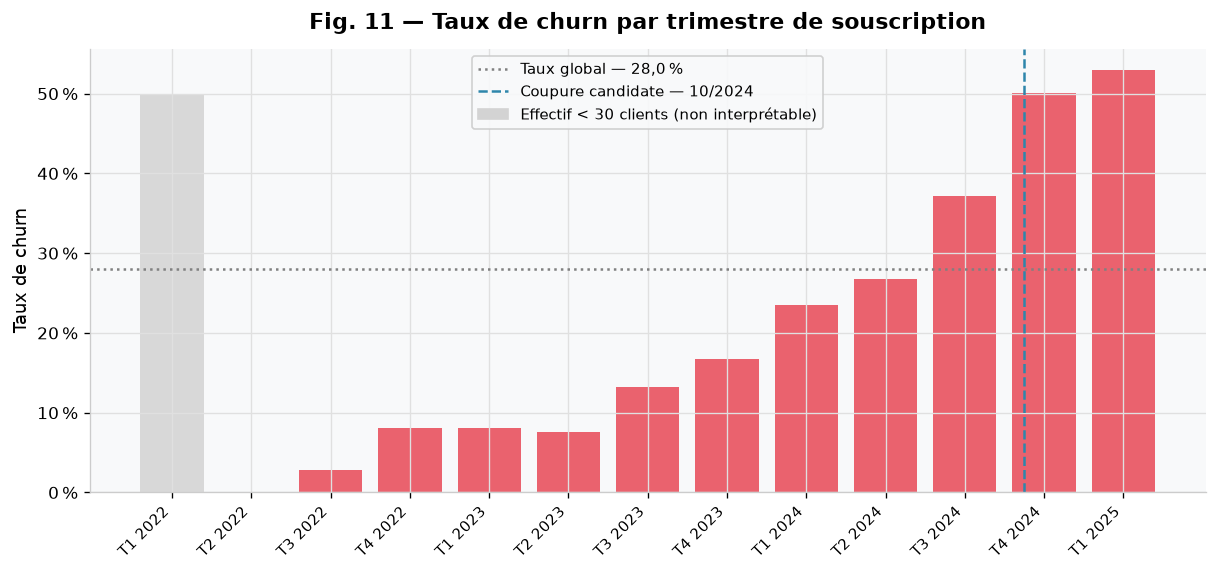

In [56]:
_col_date = "date_souscription"
# Même lecture qu'en §5.7 (cascade de formats valeur par valeur) : un pd.to_datetime unique
# ne reconnaîtrait qu'un seul des trois formats présents et fausserait la plage temporelle
_dates = parser_dates(df_brut_dedup, [_col_date])[0][_col_date]
_d_min = _dates.min()
_d_max = _dates.max()
_duree_mois = (_d_max - _d_min).days / 30.44

_date_split = _dates.quantile(0.80)  # coupure candidate : 80 % des souscriptions avant
_cote_train = _dates <= _date_split
_cote_test = _dates > _date_split
_anciennete = df_eda["anciennete_mois"]
_churn = df_eda["churn"]
_taux_train_temp = float(_churn[_cote_train].mean())
_taux_test_temp = float(_churn[_cote_test].mean())
_anc_train_temp = float(_anciennete[_cote_train].median())
_anc_test_temp = float(_anciennete[_cote_test].median())
# Corrélation de rang : la date de souscription n'est-elle qu'une ancienneté renversée ?
_rho_date_anciennete = float((_dates - _d_min).dt.days.corr(_anciennete, method="spearman"))

fig_dates, ax_trim = viz.figure(
    "structure_temporelle", "Taux de churn par trimestre de souscription", taille=(12.0, 4.8)
)
_stats_trim = _churn.groupby(_dates.dt.to_period("Q")).agg(["mean", "size"])
_effectif_min_trim = 30  # en deçà, taux non interprétable : barre grisée
_trim_fiables = _stats_trim["size"] >= _effectif_min_trim
ax_trim.bar(
    range(len(_stats_trim)),
    _stats_trim["mean"].values,
    color=[viz.COULEUR_CHURN if ok else "lightgrey" for ok in _trim_fiables],
    alpha=0.85,
)
ax_trim.axhline(
    _prevalence, color="grey", linestyle=":", label=f"Taux global — {pourcentage(_prevalence)}"
)
ax_trim.axvline(
    list(_stats_trim.index).index(_date_split.to_period("Q"))
    - 0.5
    + (_date_split - _date_split.to_period("Q").start_time).days / 91.3,
    color=viz.couleur(0),
    linestyle="--",
    label=f"Coupure candidate — {_date_split:%m/%Y}",
)
_poignees, _libelles = ax_trim.get_legend_handles_labels()
if not _trim_fiables.all():
    _poignees.append(Patch(color="lightgrey"))
    _libelles.append(f"Effectif < {entier(_effectif_min_trim)} clients (non interprétable)")
ax_trim.legend(_poignees, _libelles, fontsize=9)
ax_trim.set_xticks(range(len(_stats_trim)))
ax_trim.set_xticklabels(
    [f"T{p.quarter} {p.year}" for p in _stats_trim.index], rotation=45, ha="right", fontsize=9
)
ax_trim.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: pourcentage(v, 0)))
ax_trim.set_ylabel("Taux de churn")
viz.sauvegarder(fig_dates)

In [57]:
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Les souscriptions couvrent **{nombre(_duree_mois, 1)} mois** "
        f"({_d_min:%d/%m/%Y} → {_d_max:%d/%m/%Y}), assez pour un split temporel en volume. Mais "
        f"la date de souscription est l'ancienneté retournée (Spearman "
        f"{nombre(_rho_date_anciennete, 3)}) : tous les clients sont observés à la même date "
        f"d'extraction ({date_reference:%d/%m/%Y}).\n\n"
        f"Couper au {_date_split:%d/%m/%Y} ne sépare donc pas un passé d'un futur ; cela isole "
        f"les **clients récents** (ancienneté médiane {nombre(_anc_test_temp, 0)} mois contre "
        f"{nombre(_anc_train_temp, 0)}, churn **{pourcentage(_taux_test_temp)}** contre "
        f"{pourcentage(_taux_train_temp)}). Le modèle y serait évalué sur une population qu'il "
        f"n'a pas vue, alors qu'en production il score chaque nuit **tout le portefeuille**.\n\n"
        f"**Décision : split temporel écarté** au profit d'une cross-validation stratifiée "
        f"répétée (`RepeatedStratifiedKFold`, §8.8), dont chaque pli garde le mélange "
        f"d'anciennetés. L'effet de la date d'entrée reste porté par `anciennete_mois` (H14). "
        f"Une vraie validation temporelle demande plusieurs extractions successives (apprendre "
        f"à *t*, évaluer à *t + 1*) : elle relève du suivi en production (§13.3, §13.7)."
    )
)

**Ce qu'il faut retenir.** Les souscriptions couvrent **34,8 mois** (15/02/2022 → 10/01/2025), assez pour un split temporel en volume. Mais la date de souscription est l'ancienneté retournée (Spearman -0,998) : tous les clients sont observés à la même date d'extraction (04/02/2025).

Couper au 24/10/2024 ne sépare donc pas un passé d'un futur ; cela isole les **clients récents** (ancienneté médiane 1 mois contre 12, churn **51,9 %** contre 22,1 %). Le modèle y serait évalué sur une population qu'il n'a pas vue, alors qu'en production il score chaque nuit **tout le portefeuille**.

**Décision : split temporel écarté** au profit d'une cross-validation stratifiée répétée (`RepeatedStratifiedKFold`, §8.8), dont chaque pli garde le mélange d'anciennetés. L'effet de la date d'entrée reste porté par `anciennete_mois` (H14). Une vraie validation temporelle demande plusieurs extractions successives (apprendre à *t*, évaluer à *t + 1*) : elle relève du suivi en production (§13.3, §13.7).

### Conclusion de l'EDA — impact sur la stratégie de modélisation

In [58]:
_n_confirmees = int((tableau_hypotheses["verdict"] == "confirmée").sum())
display(
    Markdown(
        "**Ce qu'il faut retenir — décisions transmises au §7.**\n\n"
        "1. **Hypothèses métier** — "
        f"{_n_confirmees} sur {len(tableau_hypotheses)} confirmées (§6.2) ; les plus nettes : "
        f"{_liste_hyp(_plus_fortes.index)}. Les ratios qui servent H9, H10 et H12 sont "
        "construits au §7.\n\n"
        "2. **Colonnes exclues** — `config.COLONNES_INTERDITES` ("
        + _liste_cols(config.COLONNES_INTERDITES)
        + ", dont la fuite démontrée au §6.5 et `commentaire_csm` au §6.6), puis "
        "`features.build.COLONNES_NON_MODELISEES` ("
        + _liste_cols(sorted(COLONNES_NON_MODELISEES))
        + ") : `date_souscription` n'apporte que l'ancienneté (§6.11) ; `jour_souscription` n'a "
        "ni hypothèse métier ni lien significatif (p_BH "
        f"{nombre(tableau_assoc_cat.loc['jour_souscription', 'p_value_BH'], 2)}, §6.8).\n\n"
        f"3. **Métriques** — PR-AUC pour la sélection (prévalence {pourcentage(_prevalence)}), "
        f"ROC-AUC et recall au seuil de vigilance en co-principaux (§6.1).\n\n"
        f"4. **Validation** — cross-validation stratifiée répétée ; split temporel écarté "
        f"(§6.11).\n\n"
        "5. **Déséquilibre** — `class_weight='balanced'`, complété au §9.6 par une correction "
        "d'intercept ; SMOTE seulement en comparaison méthodologique.\n\n"
        f"6. **Transformations** — extrêmes conservés et imputation par la médiane ; "
        f"{len(_asym_fortes)} variable(s) asymétrique(s) : `log1p` à tester (§7.8.3) ; "
        f"{_n_paires} paire(s) corrélée(s) conservée(s), lues ensemble au §12.8 ; one-hot "
        f"fitté pli par pli.\n\n"
        f"7. **Leurres** — {len(_leurres_probables)} leurre(s) probable(s) "
        f"({_liste_cols(_leurres_probables) or '—'}), {len(_redondants)} redondant(s) "
        f"({_liste_cols(_redondants) or '—'}) ; confirmation au §12.9.\n\n"
        f"8. **Valeur à risque** — CLV {res_clv['nature_clv']}, donc hors formule : "
        f"`{res_clv['formule_valeur_risque']}`."
    )
)

**Ce qu'il faut retenir — décisions transmises au §7.**

1. **Hypothèses métier** — 14 sur 14 confirmées (§6.2) ; les plus nettes : H11 `nb_integrations` (0,759), H14 `anciennete_mois` (0,714), H3 `heures_usage_30j` (0,697). Les ratios qui servent H9, H10 et H12 sont construits au §7.

2. **Colonnes exclues** — `config.COLONNES_INTERDITES` (`client_id`, `churn`, `valeur_vie_client_eur`, `sante_compte_fin_periode`, `commentaire_csm`, dont la fuite démontrée au §6.5 et `commentaire_csm` au §6.6), puis `features.build.COLONNES_NON_MODELISEES` (`date_souscription`, `jour_souscription`) : `date_souscription` n'apporte que l'ancienneté (§6.11) ; `jour_souscription` n'a ni hypothèse métier ni lien significatif (p_BH 0,24, §6.8).

3. **Métriques** — PR-AUC pour la sélection (prévalence 28,0 %), ROC-AUC et recall au seuil de vigilance en co-principaux (§6.1).

4. **Validation** — cross-validation stratifiée répétée ; split temporel écarté (§6.11).

5. **Déséquilibre** — `class_weight='balanced'`, complété au §9.6 par une correction d'intercept ; SMOTE seulement en comparaison méthodologique.

6. **Transformations** — extrêmes conservés et imputation par la médiane ; 11 variable(s) asymétrique(s) : `log1p` à tester (§7.8.3) ; 3 paire(s) corrélée(s) conservée(s), lues ensemble au §12.8 ; one-hot fitté pli par pli.

7. **Leurres** — 3 leurre(s) probable(s) (`couleur_theme_interface`, `code_datacenter`, `groupe_experimentation`), 1 redondant(s) (`commentaire_csm`) ; confirmation au §12.9.

8. **Valeur à risque** — CLV prospective, donc hors formule : `P(churn à 12 mois) × MRR_mensuel × 12 × marge_brute`.

> ### 📋 Journal de bord — Analyse exploratoire
>
> **Décisions retenues** — Hypothèses H1 à H14 testées avant toute modélisation
> (Mann-Whitney, Holm, AUC orientée) pour orienter le feature engineering ; PR-AUC pour la
> sélection, ROC-AUC et recall en co-principaux ; fuite de `sante_compte_fin_periode`
> démontrée par la mesure ; `commentaire_csm` exclu pour sa provenance ; CLV prospective, hors
> variables et hors valeur à risque ; extrêmes et paires corrélées conservés ; one-hot fitté
> pli par pli ; leurres criblés (association puis redondance).
>
> **Alternatives écartées** — Univarié exhaustif *(remplacé par le test des hypothèses, qui ne
> garde que ce qui sert une décision)* ; suppression de `sante_compte_fin_periode` sans
> démonstration *(la fuite serait restée une affirmation)* ; détection de fuite par mots-clés
> *(un mot ne dit rien de la chronologie)* ; plafonnement des extrêmes *(retirerait les
> churners typiques)* ; encodage ordinal, target encoding, suppression d'une variable par paire
> corrélée ; split temporel *(n'isole que les clients récents)*.
>
> **Difficultés rencontrées** — Sans dédoublonnage, un même client tombait des deux côtés de
> l'expérience de fuite (§6.5) : d'où la copie dédoublonnée. Plusieurs hypothèses métier ne
> sont pas confirmées par les données : l'intuition a été corrigée, pas forcée. Une seule
> extraction datée interdit le split temporel.
>
> **Impact sur la suite** — Le §7 reçoit la liste numérotée de décisions ci-dessus et ne la
> redérive pas ; la valeur à risque est fixée pour le §12, où l'importance des variables sera
> lue en tenant compte des paires corrélées.

## 7. Préparation des données

On veut donner aux modèles des données propres et des variables qui parlent le langage du
métier, sans jamais laisser filtrer d'information du jeu de test. Cette section enchaîne le
nettoyage des défauts repérés au §5, le feature engineering (ingénierie des variables) guidé
par les hypothèses du §6.2, l'enrichissement externe et le versionnement du jeu *gold* qui
alimente les §8 et §9. La stratégie anti-fuite est posée **avant** le code.

In [59]:
import hashlib
import json
import subprocess

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy.stats import spearmanr, wilcoxon
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

from churn_saas import config
from churn_saas.cache import charger_ou_calculer
from churn_saas.cli import construire_gold_dataset
from churn_saas.data.quality import (
    analyser_doublons,
    analyser_manquance,
    coercer_numeriques,
    detecter_valeurs_impossibles,
    parser_dates,
    proposer_renommage,
)
from churn_saas.features.build import (
    ajouter_features_metier,
    construire_preprocesseur,
    controle_coherence_adoption,
    joindre_catalogue,
    reconstituer_taux_adoption,
)
from churn_saas.features.enrichissement import (
    ALIAS_SECTEURS,
    FICHES_SOURCES,
    REFERENTIEL_PAYS,
    REFERENTIEL_SECTORIEL,
    enrichir_par_pays,
    enrichir_par_secteur,
)
from churn_saas.format_fr import entier, nombre, pourcentage, styler_fr
from churn_saas.models.train import construire_modeles, evaluer_modele, protocole_validation

### 7.1 Rappel des décisions issues de l'EDA (§6)

Chaque transformation de cette section remonte à un constat des §5-§6 ; aucune n'est
appliquée « par défaut ».

| Constat | Conséquence en §7 |
|---|---|
| Cible déséquilibrée (§6.1) | Aucun rééchantillonnage ici : `class_weight='balanced'` dans le `Pipeline` du §9. |
| Fuite `sante_compte_fin_periode` (§6.5), audit de `commentaire_csm` (§6.6) | Inscrites dans `config.COLONNES_INTERDITES`, écartées par le `ColumnTransformer` (`remainder='drop'`). |
| Leurres suspectés (§6.10) | Gardés dans le gold et en entrée du modèle : leur inutilité se **prouve** au §12.9 (une variable absente aurait une importance nulle par construction, ce qui ne prouverait rien). Le modèle déployé est réentraîné sans eux (§10.3). |
| Hypothèses H1 à H14 (§6.2) | Les ratios du §7.5 servent les hypothèses H3, H6, H9, H10 et H12. |
| Manquance (§5.9) | Pas de lien avec le churn démontré ; indicateurs de manquance gardés comme hypothèse, départagés au §12.8. |
| Variables asymétriques (§6.2) | Extrêmes conservés ; un log1p signé est testé, puis écarté (§7.8.3). |
| Numériques en texte, dates multi-formats, valeurs impossibles (§5.6 à §5.8) | Coercition, parsing en cascade et bornage métier (§7.3). |

### 7.2 Stratégie anti-fuite — explication avant le code

**L'intuition.** Un examen ne vaut que si l'élève n'a pas vu les questions : le modèle ne doit
rien apprendre, même indirectement, des clients sur lesquels on le note.

**La notion exacte.** Le data leakage (fuite de données) survient quand une statistique
calculée sur tout le jeu (médiane, moyenne, modalités) sert à préparer les données : elle
contient de l'information sur les lignes de validation et gonfle les scores. Le remède : toute
transformation *apprise* est placée dans un `Pipeline` scikit-learn (chaîne de traitement)
dont le `fit()` (apprentissage) ne voit que la partie d'entraînement du pli courant ; le pli
de validation est seulement transformé. `tests/test_no_leakage.py` le vérifie à chaque CI.

| Peut précéder le split (découpage) | Doit être dans le `Pipeline`, fitté par pli |
|---|---|
| Coercition numérique, parsing de dates (aucune statistique) | Imputation par la médiane ou la constante `"inconnu"` |
| Bornes métier connues a priori (taux ∈ [0, 100], utilisateurs ≤ sièges) | Standardisation (`StandardScaler`) |
| Ratios ligne par ligne (§7.5), indicateurs de manquance | Encodage one-hot des catégorielles |
| Jointure sur un référentiel statique (catalogue, secteur, pays) | Agrégats de groupe : `ecart_csat_secteur` (`EcartAuGroupe`) |
| | Toute sélection de colonnes fondée sur les données (log du §7.8.3) |

### 7.3 Nettoyage

Les étapes portent sur `df_prep`, copie de `df_brut` (§5.1) qui reste intact, et rejouent ce
que `construire_gold_dataset()` enchaîne (contrôle au §7.8). Première étape : appliquer le
renommage proposé au §5.10 (snake_case, sans accent, unités suffixées).

In [60]:
df_prep = df_brut.copy()
_renommage = proposer_renommage(df_prep).query("modifie")
_renames = dict(zip(_renommage["nom_original"], _renommage["nom_propose"], strict=True))
df_prep = df_prep.rename(columns=_renames)
display(
    Markdown(
        f"**Ce qu'il faut retenir.** {entier(len(_renames))} colonne(s) renommée(s)"
        + (": " + ", ".join(f"`{k}` → `{v}`" for k, v in _renames.items()) if _renames else "")
        + ". Les noms du dictionnaire fourni sont repris tels quels par tout le pipeline aval."
    )
)

**Ce qu'il faut retenir.** 0 colonne(s) renommée(s). Les noms du dictionnaire fourni sont repris tels quels par tout le pipeline aval.

#### 7.3.1 Déduplication

In [61]:
rapport_doublons = analyser_doublons(df_prep, cle_metier="client_id")
n_avant = rapport_doublons["nb_total_lignes"]
df_prep = df_prep.drop_duplicates(keep="first")
# Contrôle bloquant : un client_id répété avec des données divergentes n'a pas de traitement sûr
# par défaut (mise à jour, contacts multiples, erreur de jointure). Même contrôle dans la CLI.
_cles_repetees = int(df_prep["client_id"].duplicated().sum())
assert _cles_repetees == 0, f"{_cles_repetees} client_id répétés : cause à investiguer (§5.5)"

display(
    Markdown(
        f"**Ce qu'il faut retenir.** {entier(n_avant)} → {entier(len(df_prep))} lignes : "
        f"{entier(n_avant - len(df_prep))} copie(s) exacte(s) retirée(s), sans information "
        "nouvelle ; chaque `client_id` est unique. Un compte en double aux données divergentes "
        "arrêterait la préparation : sa règle de résolution se décide une fois la cause connue."
    )
)

**Ce qu'il faut retenir.** 5 035 → 5 000 lignes : 35 copie(s) exacte(s) retirée(s), sans information nouvelle ; chaque `client_id` est unique. Un compte en double aux données divergentes arrêterait la préparation : sa règle de résolution se décide une fois la cause connue.

#### 7.3.2 Coercition des numériques

In [62]:
_COLS_NUM = [
    *["anciennete_mois", "sieges_souscrits", "utilisateurs_actifs", "taux_adoption_pct"],
    *["connexions_30j", "heures_usage_30j", "nb_integrations", "derniere_connexion_jours"],
    *["fonctionnalites_total", "fonctionnalites_utilisees", "csat", "churn"],
    *["tickets_support_90j", "delai_reponse_support_h", "retards_paiement_12m"],
    *["revenu_mensuel_recurrent_eur", "valeur_vie_client_eur"],
]
df_prep, rapport_coercition = coercer_numeriques(df_prep, _COLS_NUM)
display(rapport_coercition)

,nb_directes,nb_reparees,nb_manquants,nb_irrecuperables
colonne,,,,
anciennete_mois,5000,0,0,0
sieges_souscrits,5000,0,0,0
utilisateurs_actifs,5000,0,0,0
taux_adoption_pct,2745,2005,250,0
connexions_30j,5000,0,0,0
heures_usage_30j,3304,1396,300,0
nb_integrations,4800,0,200,0
derniere_connexion_jours,5000,0,0,0
fonctionnalites_total,5000,0,0,0


**Ce qu'il faut retenir.** Séparateurs, symboles monétaires et espaces insécables sont réparés ;
l'irrécupérable devient manquant, imputé dans le `Pipeline`.

#### 7.3.3 Parsing des dates

In [63]:
df_prep, rapport_dates = parser_dates(df_prep, ["date_souscription"])
display(rapport_dates)

# Vérification : ancienneté recalculée depuis la date d'extraction estimée en §5.8 (pas
# aujourd'hui, sinon le résultat dériverait à chaque relance)
_anc_calculee = ((date_reference - df_prep["date_souscription"]).dt.days / 30.44).round(0)
_coherence = float(((df_prep["anciennete_mois"] - _anc_calculee).abs() <= 3).mean())

,format_detecte,repartition_formats,convention_retenue,nb_parsees,nb_ambigues,nb_irrecuperables
colonne,,,,,,
date_souscription,%d %b %Y,%Y-%m-%d : 1694 | %d/%m/%Y : 1611 | %d %b %Y :...,DD/MM/YYYY (premier champ > 12 observé → non a...,5000,955,0


In [64]:
display(
    Markdown(
        "**Ce qu'il faut retenir.** Chaque date est lue avec le premier format de la cascade qui "
        "la reconnaît (dates ambiguës : « premier champ > 12 → JJ/MM/AAAA »). Ancienneté déduite "
        f"de la date et ancienneté déclarée concordent à ±3 mois sur **{pourcentage(_coherence)}**"
        " des comptes : les deux colonnes décrivent la même réalité."
    )
)

**Ce qu'il faut retenir.** Chaque date est lue avec le premier format de la cascade qui la reconnaît (dates ambiguës : « premier champ > 12 → JJ/MM/AAAA »). Ancienneté déduite de la date et ancienneté déclarée concordent à ±3 mois sur **100,0 %** des comptes : les deux colonnes décrivent la même réalité.

#### 7.3.4 Correction des valeurs impossibles

In [65]:
rapport_anomalies = detecter_valeurs_impossibles(df_prep, date_reference=date_reference)
display(rapport_anomalies[["regle", "colonne_ou_paire", "nb_lignes_concernees"]])

# Bornes métier connues a priori, sans statistique apprise : elles peuvent précéder le split
df_prep["taux_adoption_pct"] = df_prep["taux_adoption_pct"].clip(0, 100)
df_prep["utilisateurs_actifs"] = df_prep["utilisateurs_actifs"].clip(
    lower=0, upper=df_prep["sieges_souscrits"]
)

,regle,colonne_ou_paire,nb_lignes_concernees


**Ce qu'il faut retenir.** Les bornages (taux ∈ [0, 100], utilisateurs ≤ sièges) sont appliqués
quel que soit le volume ci-dessus : ce sont des contraintes métier, qui protègent aussi les
données futures reçues par l'API et le batch.

#### 7.3.5 Normalisation de casse et d'espaces (catégorielles)

« Finance », « finance » et « FINANCE␣ » deviendraient trois colonnes one-hot. La normalisation
n'apprend rien. Pour le modèle, elle est faite dans le `Pipeline` (`NormalisationCategorielle`),
donc à l'identique en entraînement, batch et API ; le gold garde les libellés d'origine.

In [66]:
_COLS_CAT = ["secteur", "pays", "taille_entreprise", "plan", "jour_souscription"]
_COLS_CAT += ["couleur_theme_interface", "code_datacenter", "groupe_experimentation"]
_rapport_casse = {}
for _col in _COLS_CAT:
    _avant = df_prep[_col].dropna().nunique()
    df_prep[_col] = df_prep[_col].astype(str).str.strip().str.lower().replace("nan", np.nan)
    _rapport_casse[_col] = {"modalités avant": _avant, "modalités après": df_prep[_col].nunique()}
display(pd.DataFrame(_rapport_casse).T.rename_axis("colonne"))

,modalités avant,modalités après
colonne,,
secteur,28,7
pays,6,6
taille_entreprise,12,4
plan,16,4
jour_souscription,7,7
couleur_theme_interface,5,5
code_datacenter,4,4
groupe_experimentation,3,3


**Ce qu'il faut retenir.** Toute baisse du nombre de modalités correspond à des doublons
typographiques fusionnés, sans perte d'information métier.

### 7.4 Traitement des valeurs manquantes

**Recalculer avant d'imputer.** `taux_adoption_pct` vaut 100 × `utilisateurs_actifs` /
`sieges_souscrits` (contrôle au §7.5) : un taux manquant se recalcule exactement au lieu de
recevoir la médiane d'un client « typique ». `reconstituer_taux_adoption()` le fait ligne par
ligne, et `ajouter_features_metier()` l'appelle aussi : même traitement en gold, batch et API.

**Imputer le reste, dans le `Pipeline`** : médiane pour les numériques (robuste aux extrêmes),
constante `"inconnu"` pour les catégorielles, qui garde la trace de la manquance.

In [67]:
# Contrôle mesuré avant le recalcul : après, les taux reconstitués seraient cohérents par
# construction et gonfleraient artificiellement le bilan
bilan_coherence_adoption = controle_coherence_adoption(df_prep)
_nb_taux_avant = int(df_prep["taux_adoption_pct"].isna().sum())
df_prep, _nb_taux_reconstitues = reconstituer_taux_adoption(df_prep)
_nb_taux_apres = int(df_prep["taux_adoption_pct"].isna().sum())

_df_manquance = df_prep.drop(columns=["client_id", "valeur_vie_client_eur"])
rapport_manquance = analyser_manquance(_df_manquance, cible="churn")
display(
    styler_fr(
        rapport_manquance[["taux_manquants", "mecanisme_propose", "lien_cible_significatif"]],
        {"taux_manquants": lambda v: pourcentage(v, 1)},
    )
)

,taux_manquants,mecanisme_propose,lien_cible_significatif
colonne,,,
secteur,"5,0 %",MCAR,False
pays,"4,0 %",MCAR,False
heures_usage_30j,"6,0 %",MCAR,False
nb_integrations,"4,0 %",MCAR,False
delai_reponse_support_h,"10,0 %",MCAR,False
csat,"8,0 %",MCAR,False
retards_paiement_12m,"5,0 %",MCAR,False
revenu_mensuel_recurrent_eur,"3,0 %",MCAR,False
commentaire_csm,"55,5 %",MCAR,False


In [68]:
_repartition_mecanismes = rapport_manquance["mecanisme_propose"].value_counts()
_cols_mnar = list(rapport_manquance.index[rapport_manquance["mecanisme_propose"] == "MNAR"])
display(
    Markdown(
        f"**Ce qu'il faut retenir.** `taux_adoption_pct` : **{entier(_nb_taux_reconstitues)}** "
        f"valeur(s) recalculée(s) sur {entier(_nb_taux_avant)} manquante(s) ; il en reste "
        f"{entier(_nb_taux_apres)} (sièges nuls ou utilisateurs inconnus). Mécanismes de "
        "manquance : "
        + ", ".join(f"**{entier(n)} {m}**" for m, n in _repartition_mecanismes.items())
        + " ; colonnes dont la manquance est liée au churn : "
        + (", ".join(f"`{c}`" for c in _cols_mnar) or "**aucune**")
        + ". Les indicateurs `*_manquant` du §7.5 restent une hypothèse métier, départagée par "
        "l'importance de permutation au §12.8."
    )
)

**Ce qu'il faut retenir.** `taux_adoption_pct` : **250** valeur(s) recalculée(s) sur 250 manquante(s) ; il en reste 0 (sièges nuls ou utilisateurs inconnus). Mécanismes de manquance : **9 MCAR** ; colonnes dont la manquance est liée au churn : **aucune**. Les indicateurs `*_manquant` du §7.5 restent une hypothèse métier, départagée par l'importance de permutation au §12.8.

### 7.5 Feature engineering — ratios métier

**L'intuition.** Dix tickets support n'ont pas le même sens pour un compte de 3 utilisateurs et
pour un compte de 300. Un ratio rapporte un volume brut à la taille ou à l'âge du compte, et
fait apparaître le comportement plutôt que la taille.

Toutes les variables ci-dessous sont calculées par `ajouter_features_metier()` **ligne par
ligne**, sans statistique apprise sur d'autres clients : elles ne peuvent pas faire fuiter
d'information entre plis. Seule exception, `ecart_csat_secteur`, calculée dans le `Pipeline`.

**Les cinq ratios préconisés.**

| Ratio | Formule | Hypothèse servie (§6.2) | Lecture métier |
|---|---|---|---|
| `taux_utilisation_sieges` | `utilisateurs_actifs / sieges_souscrits` | H9 (miroir de H1) | Sièges payés mais non déployés : la facture devient un argument de départ. |
| `taux_couverture_fonctionnelle` | `fonctionnalites_utilisees / fonctionnalites_total` | H12 (prolonge H4) | Peu de fonctions explorées sur celles du plan : valeur perçue faible. |
| `intensite_usage_par_utilisateur` | `heures_usage_30j / utilisateurs_actifs` | H3 | Usage réel de chaque utilisateur, indépendamment de la taille du compte. |
| `arpu_par_siege` | `revenu_mensuel_recurrent_eur / sieges_souscrits` | aucune hypothèse dédiée (famille facturation) | Revenu par siège bas : remise forte ou plan surdimensionné, relation commerciale fragile. |
| `intensite_support` | `tickets_support_90j / anciennete_mois` | H6 | Frictions rapportées à la durée de la relation. |

Pour chaque ratio, on compare son AUC univariée orientée (probabilité qu'un churner soit du
côté « risqué » ; 0,50 = aucun signal) à celle de sa variable brute. Mesure descriptive, sans
modèle : elle dit si la normalisation garde ou renforce le signal.

In [69]:
df_prep = ajouter_features_metier(df_prep, csat_median_par_secteur=None)
_features_creees = [c for c in df_prep.columns if c not in df_brut.columns]

_RATIOS_PRECONISES = {
    # ratio : (variable brute comparée, sens de risque attendu, hypothèse)
    "taux_utilisation_sieges": ("utilisateurs_actifs", "-", "H9"),
    "taux_couverture_fonctionnelle": ("fonctionnalites_utilisees", "-", "H12"),
    "intensite_usage_par_utilisateur": ("heures_usage_30j", "-", "H3"),
    "arpu_par_siege": ("revenu_mensuel_recurrent_eur", "-", "—"),
    "intensite_support": ("tickets_support_90j", "+", "H6"),
}


def _auc_orientee(colonne: str, sens: str) -> float:
    """AUC univariée de ``colonne`` contre le churn, orientée dans le sens de risque attendu."""
    valides = df_prep[[colonne, "churn"]].dropna()
    auc = roc_auc_score(valides["churn"], valides[colonne])
    return float(auc if sens == "+" else 1 - auc)


tableau_ratios = pd.DataFrame(
    {
        ratio: {
            "hypothèse": hyp,
            "variable brute": brute,
            "auc_ratio": _auc_orientee(ratio, sens),
            "auc_brute": _auc_orientee(brute, sens),
            "manquants": df_prep[ratio].isna().mean(),
        }
        for ratio, (brute, sens, hyp) in _RATIOS_PRECONISES.items()
    }
).T.rename_axis("ratio")
display(
    styler_fr(
        tableau_ratios,
        {"auc_ratio": lambda v: nombre(v, 3), "auc_brute": lambda v: nombre(v, 3)}
        | {"manquants": pourcentage},
    )
)

,hypothèse,variable brute,auc_ratio,auc_brute,manquants
ratio,,,,,
taux_utilisation_sieges,H9,utilisateurs_actifs,"0,686","0,651","0,0 %"
taux_couverture_fonctionnelle,H12,fonctionnalites_utilisees,"0,657","0,692","0,0 %"
intensite_usage_par_utilisateur,H3,heures_usage_30j,"0,564","0,697","11,6 %"
arpu_par_siege,—,revenu_mensuel_recurrent_eur,"0,613","0,559","3,0 %"
intensite_support,H6,tickets_support_90j,"0,730","0,661","0,0 %"


In [70]:
_gagnants = tableau_ratios.index[tableau_ratios["auc_ratio"] > tableau_ratios["auc_brute"]]
_sans_signal = tableau_ratios.index[tableau_ratios["auc_ratio"] < 0.55]
display(
    Markdown(
        f"**Ce qu'il faut retenir.** {entier(len(_features_creees))} variables créées. "
        f"{entier(len(_gagnants))} des cinq ratios portent plus de signal que leur variable brute ("
        + (", ".join(f"`{c}`" for c in _gagnants) or "aucun")
        + ") ; pour les autres, la variable brute reste plus discriminante et les deux sont "
        "gardées. Signal faible (AUC < 0,55) : "
        + (", ".join(f"`{c}`" for c in _sans_signal) or "aucun")
        + ". Le poids réel, en combinaison, se mesure au §12.8 ; les manquants (dénominateur nul, "
        "composante absente) sont imputés dans le `Pipeline`."
    )
)

**Ce qu'il faut retenir.** 15 variables créées. 3 des cinq ratios portent plus de signal que leur variable brute (`taux_utilisation_sieges`, `arpu_par_siege`, `intensite_support`) ; pour les autres, la variable brute reste plus discriminante et les deux sont gardées. Signal faible (AUC < 0,55) : aucun. Le poids réel, en combinaison, se mesure au §12.8 ; les manquants (dénominateur nul, composante absente) sont imputés dans le `Pipeline`.

**Contrôle de cohérence de l'adoption.** `taux_utilisation_sieges` × 100 devrait reproduire
`taux_adoption_pct` ; si oui, les deux variables sont jumelles (H1 et H9) et le recalcul du §7.4
est légitime. `controle_coherence_adoption()` mesure l'écart sur les lignes renseignées **avant**
recalcul (incohérence au-delà de `config.SEUIL_INCOHERENCE_ADOPTION_PTS` point).

In [71]:
display(styler_fr(bilan_coherence_adoption, precision=4))
_bilan = bilan_coherence_adoption.iloc[0]
_correlation_jumelles = df_prep["taux_utilisation_sieges"].corr(df_prep["taux_adoption_pct"])
display(
    Markdown(
        f"**Ce qu'il faut retenir.** {entier(_bilan['n_incoherences'])} incohérence(s) sur "
        f"{entier(_bilan['n_comparables'])} lignes (écart maximal "
        f"{nombre(_bilan['ecart_max_pts'], 2)} point), corrélation "
        f"{nombre(_correlation_jumelles, 4)} : c'est la même information à un facteur 100 près. "
        "Les deux sont gardées (la régularisation absorbe la redondance, les arbres n'en "
        "souffrent pas), mais leurs importances se partagent et se lisent **ensemble** au §12.8."
    )
)

,n_comparables,ecart_moyen_pts,ecart_max_pts,n_incoherences,part_incoherences
0,4 750,"0,0192","0,0500",0,"0,0000"


**Ce qu'il faut retenir.** 0 incohérence(s) sur 4 750 lignes (écart maximal 0,05 point), corrélation 1,0000 : c'est la même information à un facteur 100 près. Les deux sont gardées (la régularisation absorbe la redondance, les arbres n'en souffrent pas), mais leurs importances se partagent et se lisent **ensemble** au §12.8.

**Limite d'`intensite_support`.** Le numérateur couvre une fenêtre de 90 jours, le dénominateur
toute la vie du compte : deux échelles de temps différentes. Un compte de deux mois avec trois
tickets obtient un ratio bien plus élevé qu'un compte de quatre ans avec les mêmes trois tickets,
alors que la friction récente est identique. Le ratio est donc lié à l'ancienneté **par
construction** ; la cellule suivante le mesure.

In [72]:
_rho_ratio, _rho_brut = (
    spearmanr(df_prep[c], df_prep["anciennete_mois"], nan_policy="omit").statistic
    for c in ["intensite_support", "tickets_support_90j"]
)
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Corrélation de rang avec l'ancienneté : "
        f"{nombre(_rho_ratio, 2)} pour `intensite_support`, contre {nombre(_rho_brut, 2)} pour "
        "les tickets bruts : une partie de son signal est celui de l'ancienneté (H14). Elle est "
        "gardée car elle pose une question métier distincte (le support pèse-t-il lourd **pour "
        "l'âge du compte** ?), mais son importance au §12.8 se lit à côté de l'ancienneté. La "
        "version rigoureuse exigerait l'historique complet des tickets, absent des données."
    )
)

**Ce qu'il faut retenir.** Corrélation de rang avec l'ancienneté : -0,42 pour `intensite_support`, contre -0,00 pour les tickets bruts : une partie de son signal est celui de l'ancienneté (H14). Elle est gardée car elle pose une question métier distincte (le support pèse-t-il lourd **pour l'âge du compte** ?), mais son importance au §12.8 se lit à côté de l'ancienneté. La version rigoureuse exigerait l'historique complet des tickets, absent des données.

**Les autres variables créées, en une ligne chacune.**

| Variable | Formule | Justification |
|---|---|---|
| `surdimensionnement` | `max(0, sieges − utilisateurs)` | Sièges vides payés, en nombre : ce que voit l'acheteur sur la facture. |
| `connexions_par_utilisateur` | `connexions_30j / utilisateurs_actifs` | H10 : régularité d'usage, indépendante de la taille du compte. |
| `recence_normalisee` | `derniere_connexion_jours / (anciennete_mois × 30)` | H5 rapportée à l'âge du compte : décrochage relatif. |
| `compte_dormant` | `derniere_connexion_jours > 30` | H5 en signal binaire : un mois ≈ un cycle de reporting client. |
| `pression_support` | `tickets_support_90j / utilisateurs_actifs` | H6 rapportée à la taille du compte, sur la même fenêtre de 90 jours. |
| `ecart_csat_secteur` | `csat − médiane du secteur` (`EcartAuGroupe`, fitté par pli) | H7 relative : moins satisfait que ses pairs, donc plus exposé à la concurrence. |
| `tranche_anciennete` | `anciennete_mois` en 3 tranches (0-2, 3-12, > 12 mois) | H14 : prise en main, installation et maturité ont des risques différents. |
| `tranche_integrations` | `nb_integrations` en 4 tranches (0, 1-3, 4-8, > 8) | H11 : chaque intégration renchérit la migration vers un concurrent. |
| `csat_manquant`, `heures_usage_30j_manquant`, `delai_reponse_support_h_manquant` | `colonne.isna()` | Hypothèse « silence = désengagement », non confirmée au §5.9, gardée à coût nul. |

### 7.6 Jointure catalogue et variables commerciales

Le catalogue (référentiel statique, donc sans fuite) donne le prix par siège, d'où
`remise_consentie` (1 − MRR / (prix × sièges) : forte remise = négociation tendue) et
`adequation_plan` (usage < 50 % des sièges : surdimensionné ; ≥ 90 % : montée en gamme).

In [73]:
# catalogue_brut est chargé et décrit en §5.1 ; on en repart sans relire le fichier
catalogue, _ = coercer_numeriques(
    catalogue_brut.copy(),
    [
        *["prix_mensuel_par_siege_eur", "fonctionnalites_incluses"],
        "sla_reponse_h",
        "quota_stockage_go",
    ],
)
df_prep = joindre_catalogue(df_prep, catalogue)
_sans_prix = int(df_prep["prix_mensuel_par_siege_eur"].isna().sum())
_sans_plan = int(df_prep["plan"].isna().sum())
display(
    Markdown(
        "**Ce qu'il faut retenir.** "
        + (
            "Tous les clients ont un prix catalogue : la normalisation de `plan` suffit."
            if _sans_prix == 0
            else f"{entier(_sans_prix)} client(s) sans prix catalogue (dont {entier(_sans_plan)} "
            "sans plan) : leur `remise_consentie` sera imputée dans le `Pipeline`."
        )
    )
)

**Ce qu'il faut retenir.** Tous les clients ont un prix catalogue : la normalisation de `plan` suffit.

### 7.7 Enrichissement externe et gouvernance

Deux référentiels externes (secteur et pays) sont ajoutés, **construits et documentés comme
tels** : ce sont des ordres de grandeur plausibles tirés de rapports publics, pas des sources
réelles. Leurs fiches de gouvernance indiquent la source de production qui les remplacera ; les
colonnes concernées sont tracées dans les métadonnées du gold (§7.8.1).

In [74]:
fiches = pd.DataFrame(FICHES_SOURCES).T.set_index("nom").T.rename_axis("champ")
display(fiches)
display(REFERENTIEL_SECTORIEL.drop(index=["_repli_"]))
display(REFERENTIEL_PAYS.drop(index=["_repli_"]))

nom,Référentiel de benchmarks SaaS par secteur,Référentiel réglementaire et support par pays
champ,,
ce_qu_il_apporte,Taux de churn médian du secteur et dynamique d...,"Zone réglementaire (RGPD-UE, CCPA-US, autre) e..."
source_production,"Gainsight 'State of Customer Success' (annuel,...",Classification UE : liste officielle des États...
licence,Rapports publics Gainsight et OpenView (accès ...,Classification UE : données publiques EUR-Lex ...
fraicheur,Annuelle — révision recommandée chaque septemb...,Zones réglementaires : semi-annuelle (nouvelle...
cout,Accès aux rapports : gratuit (après inscriptio...,EUR-Lex : gratuit. IAPP : ~1 500 $/an. Mise ...
plan_b,Si indisponible : utiliser le taux de churn gl...,Si indisponible : imputer 'reglementaire_autre...


,taux_churn_median_saas_pct,dynamique_croissance
secteur,,
Technologie,"4,5",forte
Finance,6,moderee
Santé,5,forte
Industrie,"7,5",stable
Services,"6,5",moderee
Commerce,8,moderee
Éducation,"5,5",forte
Immobilier,9,stable
Télécommunications,10,stable


,zone_reglementaire,langue_support_fr,decalage_horaire_paris_h
pays,,,
France,ue_rgpd,True,0
Allemagne,ue_rgpd,False,0
Espagne,ue_rgpd,False,0
Italie,ue_rgpd,False,0
Pays-Bas,ue_rgpd,False,0
Belgique,ue_rgpd,True,0
Portugal,ue_rgpd,False,0
Suède,ue_rgpd,False,0
Pologne,ue_rgpd,False,0


**Ce qu'il faut retenir.** Chaque source a une licence, une fraîcheur, un coût et un plan B
identifiés : remplacer la simulation par la source réelle ne demande aucun changement de code,
seulement un réentraînement.

In [75]:
df_prep = enrichir_par_pays(enrichir_par_secteur(df_prep))

# Couverture de la jointure sectorielle : quels libellés tombent sur la valeur de repli ?
_cles_secteur = {str(k).casefold() for k in REFERENTIEL_SECTORIEL.index} | set(ALIAS_SECTEURS)
_secteur_cle = df_prep["secteur"].str.strip().str.casefold()
_sur_repli = _secteur_cle.notna() & ~_secteur_cle.isin(_cles_secteur)
_libelles_repli = _secteur_cle[_sur_repli].value_counts()
_sans_secteur = int(_secteur_cle.isna().sum())

# Redondance : chaque colonne ajoutée est-elle une fonction du seul libellé secteur / pays ?
# Nombre maximal de valeurs distinctes par libellé (1 = fonction déterministe).
_constante = df_prep["taux_adoption_pct"] - df_prep["ecart_adoption_secteur"]
_cle_par_colonne = {"taux_churn_median_saas_pct": "secteur", "dynamique_croissance": "secteur"}
_cle_par_colonne |= {c: "pays" for c in ["zone_reglementaire", "langue_support_fr"]}
_cle_par_colonne |= {"decalage_horaire_paris_h": "pays"}
_valeurs_par_libelle = {
    col: df_prep.groupby(cle, dropna=False)[col].nunique(dropna=False).max()
    for col, cle in _cle_par_colonne.items()
}
# ecart_adoption_secteur = taux_adoption_pct − constante du secteur
_valeurs_par_libelle["ecart_adoption_secteur"] = (
    _constante.round(9).groupby(df_prep["secteur"], dropna=False).nunique().max()
)
_redondance = pd.Series(_valeurs_par_libelle, name="valeurs distinctes max par libellé")
display(_redondance)
# L'affirmation de redondance qui suit repose sur ce contrôle
assert (_redondance == 1).all(), _redondance

taux_churn_median_saas_pct    1
dynamique_croissance          1
zone_reglementaire            1
langue_support_fr             1
decalage_horaire_paris_h      1
ecart_adoption_secteur        1
Name: valeurs distinctes max par libellé, dtype: int64

In [76]:
display(
    Markdown(
        "**Ce qu'il faut retenir.** Ces colonnes n'apportent **aucune information nouvelle** : "
        "chacune est fixée par le secteur ou le pays, déjà dans le modèle. Elles sont gardées "
        "car elles démontrent la chaîne complète (jointure, repli, traçabilité, contrat de "
        "l'API) que les sources réelles emprunteront, sans injecter d'information inventée.\n\n"
        "**Couverture.** La jointure ignore casse et espaces et rattache les abréviations ("
        + ", ".join(f"« {a} » → « {c} »" for a, c in ALIAS_SECTEURS.items())
        + f"). {entier(int(_sur_repli.sum()))} compte(s) ({pourcentage(float(_sur_repli.mean()))})"
        " restent sur la valeur de repli : "
        + (", ".join(f"« {s} » ({entier(n)})" for s, n in _libelles_repli.items()) or "aucun")
        + f", plus {entier(_sans_secteur)} comptes sans secteur. Le repli est une valeur "
        "générique : une limite de la simulation, pas une information."
    )
)

**Ce qu'il faut retenir.** Ces colonnes n'apportent **aucune information nouvelle** : chacune est fixée par le secteur ou le pays, déjà dans le modèle. Elles sont gardées car elles démontrent la chaîne complète (jointure, repli, traçabilité, contrat de l'API) que les sources réelles emprunteront, sans injecter d'information inventée.

**Couverture.** La jointure ignore casse et espaces et rattache les abréviations (« tech » → « Technologie »). 398 compte(s) (8,0 %) restent sur la valeur de repli : « public » (398), plus 250 comptes sans secteur. Le repli est une valeur générique : une limite de la simulation, pas une information.

### 7.8 Jeu de données gold — schéma, volumétrie et versioning

Le gold, écrit par `construire_gold_dataset()`, est l'unique point d'entrée des §8 à §13 : il
contient tout ce qui se calcule avant le split, les transformations apprises restant dans le
`Pipeline`.

In [77]:
chemin_gold = construire_gold_dataset(forcer=False)  # idempotent : ne réécrit pas si présent
df_gold = pd.read_parquet(chemin_gold)
with (config.DONNEES_GOLD / "gold_metadata.json").open(encoding="utf-8") as f:
    meta = json.load(f)

_origines = {c: "brute" for c in df_brut.columns}
_origines |= {c: "catalogue" for c in [*catalogue.columns, "remise_consentie", "adequation_plan"]}
_origines |= {c: "enrichissement_simule" for c in meta["colonnes_enrichissement_simule"]}
_origines["plan"] = "brute"
schema = pd.DataFrame(
    {
        "dtype": df_gold.dtypes.astype(str),
        "manquants": df_gold.isna().mean(),
        "origine": [_origines.get(c, "feature_metier") for c in df_gold.columns],
    }
).rename_axis("colonne")
display(styler_fr(schema, {"manquants": pourcentage}))

,dtype,manquants,origine
colonne,,,
client_id,str,"0,0 %",brute
date_souscription,datetime64[ns],"0,0 %",brute
jour_souscription,str,"0,0 %",brute
secteur,str,"5,0 %",brute
pays,str,"4,0 %",brute
taille_entreprise,str,"0,0 %",brute
plan,str,"0,0 %",brute
anciennete_mois,float64,"0,0 %",brute
sieges_souscrits,float64,"0,0 %",brute


In [78]:
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Gold : {entier(df_gold.shape[0])} lignes × "
        f"{entier(df_gold.shape[1])} colonnes, dont "
        + ", ".join(f"{entier(n)} {o}" for o, n in schema["origine"].value_counts().items())
        + ". La colonne `origine` trace la provenance de chaque variable et repère celles à "
        "remplacer par les sources de production ; seules les variables à manquants gardent un "
        "taux non nul, l'imputation étant différée dans le `Pipeline`."
    )
)

**Ce qu'il faut retenir.** Gold : 5 000 lignes × 57 colonnes, dont 29 brute, 15 feature_metier, 7 catalogue, 6 enrichissement_simule. La colonne `origine` trace la provenance de chaque variable et repère celles à remplacer par les sources de production ; seules les variables à manquants gardent un taux non nul, l'imputation étant différée dans le `Pipeline`.

**Contrôle : démonstration contre gold.** Seul le gold alimente les §8-9 : `df_prep` et le gold
doivent coïncider ligne à ligne, à casse et espaces près.

In [79]:
def _forme_comparable(serie: pd.Series) -> pd.Series:
    """Valeurs comparables entre chemins : numériques en flottant, texte sans casse ni espaces."""
    if pd.api.types.is_numeric_dtype(serie) and not pd.api.types.is_bool_dtype(serie):
        serie = serie.astype(float).round(9)
    return serie.astype("string").str.strip().str.lower().fillna("<manquant>")


_communes = [c for c in df_gold.columns if c in df_prep.columns]
_prep_cmp, _gold_cmp = df_prep.reset_index(drop=True), df_gold.reset_index(drop=True)
_meme_volume = len(_prep_cmp) == len(_gold_cmp)
_ecarts = {
    c: int((_forme_comparable(_prep_cmp[c]) != _forme_comparable(_gold_cmp[c])).sum())
    for c in (_communes if _meme_volume else [])
}
_divergentes = {c: n for c, n in _ecarts.items() if n > 0}
_hors_gold = sorted(set(df_prep.columns) - set(df_gold.columns))
_branches_pre = [nom for nom, _, _ in construire_preprocesseur(df_gold).transformers]
_verdict = (
    "les deux chemins sont **identiques** : la démonstration décrit fidèlement le gold"
    if _meme_volume and not _divergentes
    else "**écart détecté** : "
    + (", ".join(f"`{c}` ({entier(n)})" for c, n in _divergentes.items()) or "volumes différents")
)
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Sur {entier(len(_communes))} colonnes communes, {_verdict}. "
        "Colonnes de `df_prep` absentes du gold : "
        + (", ".join(f"`{c}`" for c in _hors_gold) or "aucune")
        + ". `ecart_csat_secteur` est "
        + ("absente du gold" if "ecart_csat_secteur" not in df_gold.columns else "**dans le gold**")
        + (
            " et produite par une branche du préprocesseur, fittée dans chaque pli."
            if "ecart_csat_secteur" in _branches_pre
            else " mais **absente du préprocesseur**."
        )
    )
)

**Ce qu'il faut retenir.** Sur 57 colonnes communes, les deux chemins sont **identiques** : la démonstration décrit fidèlement le gold. Colonnes de `df_prep` absentes du gold : aucune. `ecart_csat_secteur` est absente du gold et produite par une branche du préprocesseur, fittée dans chaque pli.

#### 7.8.1 Métadonnées et versioning

In [80]:
display(
    pd.Series(
        {
            "date de construction": meta["date_construction"],
            "version du code (git)": meta["version_code"],
            **{f"SHA-256 {s}": h[:16] + "…" for s, h in meta["sources"].items()},
            "lignes × colonnes": f"{entier(meta['nb_lignes'])} × {entier(meta['nb_colonnes'])}",
            "colonnes simulées": ", ".join(meta["colonnes_enrichissement_simule"]),
            "note de gouvernance": meta["note_gouvernance"],
        },
        name="valeur",
    ).to_frame()
)

,valeur
date de construction,2026-10-04T21:14:28
version du code (git),e709844
SHA-256 churn_saas_complet.csv,2fc45e8c3c74d3dd…
SHA-256 catalogue_plans.csv,c94f6f52652532c5…
lignes × colonnes,5 000 × 57
colonnes simulées,"taux_churn_median_saas_pct, dynamique_croissan..."
note de gouvernance,Les colonnes listées dans 'colonnes_enrichisse...


**Ce qu'il faut retenir.** Empreintes des sources et version git relient chaque gold aux
fichiers et au code qui l'ont produit : il se reconstruit à l'identique.

#### 7.8.2 Versioning DVC

**L'intuition.** git suit le code, mais un gros fichier de données n'a rien à y faire. DVC
(*Data Version Control*) ne met dans git qu'un pointeur, `data/gold/gold_dataset.parquet.dvc`
(empreinte MD5 et taille du Parquet) : toute modification du gold change l'empreinte. Après
chaque reconstruction : `uv run dvc add data/gold/gold_dataset.parquet`, puis commit du pointeur.

**Choix assumé : aucun stockage distant DVC dans ce projet.** Le gold se reconstruit à
l'identique depuis les données brutes figées et le code versionné, et il est livré dans
l'archive du projet. Le stockage distant sera mis en place en phase de production
(`dvc remote add` vers un stockage objet, `dvc push` à chaque réentraînement, §13.10), quand
plusieurs personnes et machines partageront les versions du gold.

La cellule compare les empreintes du pointeur commité et du gold du disque, sans `dvc status` :
la règle `/data/*` du `.gitignore` lui fait croire `data/` ignoré et lui masque le pointeur.

In [81]:
_pointeur_dvc = config.DONNEES_GOLD / "gold_dataset.parquet.dvc"
_texte_pointeur = _pointeur_dvc.read_text() if _pointeur_dvc.exists() else ""
# Le pointeur est un court YAML : la ligne « - md5: … » porte l'empreinte calculée par dvc add
_md5_pointeur = next(
    (x.split(":")[1].strip() for x in _texte_pointeur.splitlines() if "md5:" in x), None
)
_md5_disque = hashlib.md5((config.DONNEES_GOLD / "gold_dataset.parquet").read_bytes()).hexdigest()
_commande = ["uv", "run", "dvc", "remote", "list"]
_remotes_dvc = subprocess.run(
    _commande, capture_output=True, text=True, cwd=config.RACINE
).stdout.split()
print(f"Empreinte MD5 — pointeur commité : {_md5_pointeur} ; gold sur disque : {_md5_disque}")

if _md5_pointeur is None:
    _etat_dvc = "**le gold n'est pas versionné** (aucun pointeur)."
elif _md5_pointeur == _md5_disque:
    _etat_dvc = "le pointeur commité **correspond** au gold présent sur le disque."
else:
    _etat_dvc = "**le pointeur est périmé** : relancer `dvc add`, committer le pointeur."
_distant = ", ".join(f"`{r}`" for r in _remotes_dvc) or "**aucun, par choix** (local et archive)"

display(
    Markdown(
        f"**Ce qu'il faut retenir.** État DVC du gold : {_etat_dvc} Stockage distant : {_distant}. "
        "Le stockage distant et l'appel à `dvc add` puis `dvc push` par le flow de réentraînement "
        "relèvent de la mise en production (§13.10)."
    )
)

Empreinte MD5 — pointeur commité : 0c731737325b83e9e1d3c5b95f106e0a ; gold sur disque : 0c731737325b83e9e1d3c5b95f106e0a


**Ce qu'il faut retenir.** État DVC du gold : le pointeur commité **correspond** au gold présent sur le disque. Stockage distant : **aucun, par choix** (local et archive). Le stockage distant et l'appel à `dvc add` puis `dvc push` par le flow de réentraînement relèvent de la mise en production (§13.10).

#### 7.8.3 Variables asymétriques — log1p testé puis écarté

**Hypothèse (§6.2).** Comptages, durées et montants ont une longue queue droite ; pour un modèle
linéaire, un log devrait réduire le poids des extrêmes. `LogAsymetrique` applique
`signe(x) × log(1 + |x|)` aux colonnes dont l'asymétrie, mesurée sur le train de chaque pli,
dépasse `config.SEUIL_ASYMETRIE_LOG`. **Règle fixée avant le résultat** : les trois familles du
§9 sont évaluées avec et sans log sur les 15 mêmes plis ; le log n'est retenu que si la PR-AUC
de la régression logistique progresse avec un Wilcoxon apparié significatif (p < 0,05).

In [82]:
_X_illustration = df_gold.drop(columns=config.COLONNES_INTERDITES, errors="ignore")
_X_modele = ajouter_features_metier(_X_illustration).drop(columns=["churn"], errors="ignore")
_y_modele = df_gold["churn"].astype(int)
_FAMILLES = ["Baseline — régression logistique", "Forêt aléatoire", "LightGBM"]


def _comparer_avec_sans_log() -> pd.DataFrame:
    modeles = construire_modeles(_X_modele)
    pre_log = construire_preprocesseur(_X_modele, log_asymetrique=True)
    lignes = []
    for nom in _FAMILLES:
        variantes = {"sans": modeles[nom], "avec": clone(modeles[nom]).set_params(pre=pre_log)}
        plis = {}
        for cle, modele in variantes.items():
            res = evaluer_modele(modele, _X_modele, _y_modele, protocole_validation())
            plis[cle] = np.array([res[f"pr_auc_pli_{i:02d}"] for i in range(15)])
        ecarts = plis["avec"] - plis["sans"]
        lignes.append(
            {
                "modèle": nom,
                "pr_auc_sans_log": plis["sans"].mean(),
                "pr_auc_avec_log": plis["avec"].mean(),
                "écart": ecarts.mean(),
                "plis_gagnés_par_le_log": int((ecarts > 0).sum()),
                "p_wilcoxon": 1.0 if np.allclose(ecarts, 0) else wilcoxon(ecarts).pvalue,
            }
        )
    return pd.DataFrame(lignes).set_index("modèle")


tableau_ablation_log, _ = charger_ou_calculer("ablation_log_7.parquet", _comparer_avec_sans_log)
display(
    styler_fr(
        tableau_ablation_log,
        {"écart": lambda v: nombre(v, 3, signe=True), "p_wilcoxon": lambda v: nombre(v, 4)},
        precision=3,
    )
)

,pr_auc_sans_log,pr_auc_avec_log,écart,plis_gagnés_par_le_log,p_wilcoxon
modèle,,,,,
Baseline — régression logistique,"0,784","0,769","-0,015",0,"0,0001"
Forêt aléatoire,"0,747","0,747","+0,000",9,"0,2769"
LightGBM,"0,754","0,755","+0,002",9,"0,2078"


In [83]:
_lr = tableau_ablation_log.loc["Baseline — régression logistique"]
_log_retenu = bool(_lr["écart"] > 0 and _lr["p_wilcoxon"] < 0.05)
_arbres = tableau_ablation_log.drop(index="Baseline — régression logistique")
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Pour la régression logistique, le log fait passer la PR-AUC "
        f"de {nombre(_lr['pr_auc_sans_log'], 3)} à {nombre(_lr['pr_auc_avec_log'], 3)} (écart "
        f"{nombre(_lr['écart'], 3, signe=True)}, {entier(_lr['plis_gagnés_par_le_log'])} pli(s) "
        f"gagné(s) sur 15, Wilcoxon p = {nombre(_lr['p_wilcoxon'], 4)}). Pour les arbres, l'écart "
        f"ne dépasse pas {nombre(_arbres['écart'].abs().max(), 3)}, comme attendu d'une "
        "transformation qui conserve l'ordre des valeurs.\n\n"
        + (
            "**Décision : le log est retenu** dans le `Pipeline`."
            if _log_retenu
            else "**Décision : le log est écarté**, selon la règle fixée avant le test : "
            "l'hypothèse de l'EDA est réfutée par la validation. Explication la plus probable : "
            "les valeurs extrêmes (inactivité longue, retards, support saturé) portent le signal "
            "de churn, et le log les rapproche du reste. Le `Pipeline` reste **imputation → "
            "standardisation** ; `LogAsymetrique` reste dans le code pour que l'expérience soit "
            "reproductible."
        )
    )
)

**Ce qu'il faut retenir.** Pour la régression logistique, le log fait passer la PR-AUC de 0,784 à 0,769 (écart -0,015, 0 pli(s) gagné(s) sur 15, Wilcoxon p = 0,0001). Pour les arbres, l'écart ne dépasse pas 0,002, comme attendu d'une transformation qui conserve l'ordre des valeurs.

**Décision : le log est écarté**, selon la règle fixée avant le test : l'hypothèse de l'EDA est réfutée par la validation. Explication la plus probable : les valeurs extrêmes (inactivité longue, retards, support saturé) portent le signal de churn, et le log les rapproche du reste. Le `Pipeline` reste **imputation → standardisation** ; `LogAsymetrique` reste dans le code pour que l'expérience soit reproductible.

### 7.9 Alternatives écartées

| Alternative | Raison du rejet |
|---|---|
| Imputation KNN | Bénéfice non démontré face à la médiane pour des taux de manquance < 15 %, et `Pipeline` alourdi (les distances exigent standardisation et encodage préalables). Piste à évaluer sur les plis du §9. |
| PCA avant modélisation | Détruit l'interprétabilité alors que chaque score doit être expliqué (§12.8) ; le nombre de variables ne justifie pas de réduction. |
| Target encoding (encodage par la cible) | Fuite directe hors `Pipeline` ; possible avec `TargetEncoder` fitté par pli, mais le one-hot reste plus lisible pour un nombre de modalités modeste. |
| Suppression des leurres avant modélisation | Une preuve chiffrée (§12.9) vaut mieux qu'une suppression aveugle. |
| Log1p, RobustScaler ou plafonnement (winsorisation) | Log testé au §7.8.3 ; RobustScaler est affine, donc sans effet sur la forme ; le plafonnement écrase les extrêmes, qui portent le signal. |
| Standardisation ou SMOTE avant le split | Fuite : les statistiques ou exemples synthétiques du train contaminent le test. Tout est dans le `Pipeline`, à l'intérieur des plis. |

> ### 📋 Journal de bord — Préparation des données
>
> **Décisions retenues** — Nettoyage par règles sans statistique apprise. `taux_adoption_pct`
> recalculé plutôt qu'imputé, justifié par le contrôle de cohérence. Cinq ratios reliés aux
> hypothèses du §6.2 et comparés à leur variable brute ; `intensite_support` gardée malgré son
> lien mesuré avec l'ancienneté. Imputation dans le `Pipeline`. Enrichissement simulé gardé en
> connaissance de cause (redondant, contrôlé). Gold versionné par DVC et métadonnées, sans
> stockage distant (choix assumé, prévu en production).
>
> **Alternatives écartées** — KNN *(bénéfice non démontré)*, PCA *(explicabilité)*, target
> encoding et standardisation ou SMOTE avant split *(fuite)*, RobustScaler et plafonnement
> *(sans effet ou destructeur de signal)*.
>
> **Difficultés rencontrées** — log1p, suggéré par les asymétries de l'EDA, dégradait la
> régression logistique (§7.8.3) : écarté selon une règle fixée avant l'essai et verrouillé par
> un test. Le premier test anti-fuite passait toujours (données uniformes) ; réécrit sur données
> bimodales, il a révélé un compteur de replis toujours nul (comptage après `fillna`).
>
> **Impact sur la suite** — Les §8-9 reçoivent le gold ; le `ColumnTransformer` y écarte les
> colonnes interdites. Au §12.8, les paires jumelles (`taux_adoption_pct` /
> `taux_utilisation_sieges`, `intensite_support` / ancienneté) se lisent ensemble.

## 8. Choix du modèle

Avant d'entraîner quoi que ce soit, on décide **quoi comparer, à quelle aune et sous quelles
contraintes**. Tout est fixé ici, avant le moindre score : le type de sortie (8.1), les cibles
a priori (8.2), les contraintes d'exploitation et de sobriété (8.3, 8.4), l'achat d'une
solution du marché (8.5), les trois modèles retenus (8.6), les références à battre (8.7) et la
règle qui désignera le champion (8.8). Les scores sont en §9.

La cellule ci-dessous recalcule les faits cités et vérifie que les paramètres du texte sont
ceux du code : si l'un change, le notebook s'arrête plutôt que d'afficher un texte périmé.

In [84]:
import pandas as pd
from IPython.display import Markdown, display

from churn_saas import config
from churn_saas.features.build import ajouter_features_metier
from churn_saas.format_fr import entier, euros, nombre, nombre_tableau, pourcentage, styler_fr
from churn_saas.models.train import SEUIL_CSAT, SEUIL_INACTIVITE_JOURS, protocole_validation

# Prévalence recalculée comme en §6 ; doublons exclus (un client = une ligne)
_prevalence = float(pd.to_numeric(df_brut.drop_duplicates()["churn"]).dropna().mean())

# Variables en entrée des modèles, construites exactement comme en §9 (avant encodage)
_gold = pd.read_parquet(config.DONNEES_GOLD / "gold_dataset.parquet")
_X = ajouter_features_metier(_gold.drop(columns=config.COLONNES_INTERDITES, errors="ignore"))
_n_variables = _X.drop(columns=["churn"], errors="ignore").shape[1]
# Lignes d'apprentissage d'un pli : (k − 1)/k du jeu de développement (test exclu, §9.1), k = 5
_obs_par_variable_pli = len(_X) * (1 - config.PART_TEST) * 4 / 5 / _n_variables

_cv, _c = protocole_validation(), config.CIBLES_PERFORMANCE
_valeurs_citees = {
    "Plis × répétitions": ((_cv.cvargs["n_splits"], _cv.n_repeats), (5, 3)),
    "Seuil d'inactivité de B1 (jours)": (SEUIL_INACTIVITE_JOURS, 30),
    "Seuil CSAT de B1": (SEUIL_CSAT, 2),
    "Gain minimal de PR-AUC du plus complexe": (_c["gain_pr_auc_min_complexite"], 0.02),
}
for _nom, (_reel, _cite) in _valeurs_citees.items():
    assert _reel == _cite, f"{_nom} : code = {_reel}, texte = {_cite} — mettre §8 à jour"
print(
    f"Prévalence du churn : {pourcentage(_prevalence, 1)} ; {entier(_n_variables)} variables en "
    f"entrée, soit {entier(_obs_par_variable_pli)} observations par variable dans un pli "
    f"d'apprentissage ; r(CLV, MRR) = {nombre(res_clv['r_mrr'], 2)} (§6.7)."
)

Prévalence du churn : 28,0 % ; 52 variables en entrée, soit 62 observations par variable dans un pli d'apprentissage ; r(CLV, MRR) = 0,84 (§6.7).


### 8.1 Deux cibles, deux tâches : classification probabiliste et régression

On veut savoir quels comptes risquent de partir et à quel point : la sortie attendue est donc
une **probabilité**, pas un simple oui/non. Le jeu porte deux cibles, deux tâches supervisées :

| | Cible principale | Cible secondaire |
|---|---|---|
| Variable | `churn` (1 = résilie) | `valeur_vie_client_eur` (euros) |
| Tâche | Classification binaire : estimer P(churn = 1 \| X) | Régression |
| Sortie | **Probabiliste** : score entre 0 et 1, d'où un classement et une décision au seuil | **Déterministe** : un montant en euros |
| Calibration | Requise : un score de 0,7 doit correspondre à ~70 % de départs | Sans objet |
| Métriques | PR-AUC, ROC-AUC, recall (rappel) ; Brier en contrôle | MAE, R², RMSE |
| Modèles | Baselines B0, B1 ; régression logistique, forêt aléatoire, LightGBM | Médiane, Ridge, LightGBM (`LGBMRegressor`) |

**Ce qu'il faut retenir.** Le CSM attend un score de risque (« 78 % de départ ») : il faut un
algorithme qui fournit `predict_proba` et un contrôle de la calibration (accord entre
probabilité annoncée et fréquence observée, §9). La valeur vie client chiffre l'enjeu d'un
compte ; elle n'est **jamais** une feature (variable explicative) du churn (§2).

### 8.2 Cibles de performance a priori

Un seuil fixé après avoir vu les scores se cale toujours sur le meilleur modèle : on les fixe
donc avant. Ils proviennent de `config.CIBLES_PERFORMANCE`, posé au cadrage (§2), et sont lus
ici directement dans la configuration.

In [85]:
_lignes_cibles = [
    ("Churn — PR-AUC (validation croisée, puis test)", "≥", _c["pr_auc_min"], "Sélection"),
    ("Churn — ROC-AUC (test)", "≥", _c["roc_auc_min"], "Co-principale"),
    ("Churn — recall de vigilance visé (OOF)", "=", config.RECALL_CIBLE_VIGILANCE, "Co-principale"),
    ("Churn — recall de vigilance (test)", "≥", _c["recall_vigilance_min"], "Co-principale"),
    ("Churn — gain de PR-AUC exigé", "≥", _c["gain_pr_auc_min_complexite"], "Parcimonie"),
    ("Latence unitaire API (ms)", "≤", _c["latence_unitaire_ms"], "Exploitation"),
    ("Latence batch 5 000 comptes (s)", "≤", _c["latence_batch_5k_s"], "Exploitation"),
    ("Carbone d'un entraînement complet (g CO₂e)", "≤", _c["co2_entrainement_max_g"], "Sobriété"),
    ("CLV — R² (test, euros)", "≥", _c["clv_r2_min"], "Plancher"),
    ("CLV — gain de MAE sur la médiane", "≥", _c["clv_gain_mae_min"], "Valeur ajoutée"),
    ("CLV — R² d'alerte fuite", ">", _c["clv_r2_alerte_fuite"], "Audit obligatoire"),
]
cibles_a_priori = pd.DataFrame(_lignes_cibles, columns=["indicateur", "sens", "seuil", "rôle"])
styler_fr(cibles_a_priori, {"seuil": nombre_tableau}).hide(axis="index")

indicateur,sens,seuil,rôle
"Churn — PR-AUC (validation croisée, puis test)",≥,"0,65",Sélection
Churn — ROC-AUC (test),≥,"0,8",Co-principale
Churn — recall de vigilance visé (OOF),=,"0,8",Co-principale
Churn — recall de vigilance (test),≥,"0,75",Co-principale
Churn — gain de PR-AUC exigé,≥,"0,02",Parcimonie
Latence unitaire API (ms),≤,200,Exploitation
Latence batch 5 000 comptes (s),≤,300,Exploitation
Carbone d'un entraînement complet (g CO₂e),≤,50,Sobriété
"CLV — R² (test, euros)",≥,"0,5",Plancher
CLV — gain de MAE sur la médiane,≥,"0,3",Valeur ajoutée


**Ce qu'il faut retenir.** Sans information, PR-AUC = prévalence (plus haut) et ROC-AUC = 0,5 :
la cible de PR-AUC exige plus du double du hasard. Le recall est visé hors pli (out-of-fold :
chaque compte scoré par un modèle qui ne l'a pas vu), avec une tolérance sur le test, car
manquer un churner coûte bien plus qu'une surveillance inutile (§2). Les latences sont des objectifs de service (§11), pas un critère de tri. Pour la
CLV, les cibles sont relatives à une baseline (référence de base) naïve, et un R² quasi
parfait est présumé être une fuite. Tout champion satisfait **toutes** les cibles de sa tâche.

### 8.3 Exigences d'exploitation : volumétrie, fréquence, intégration, compétences

Le meilleur score ne sert à rien s'il ne s'insère pas dans le travail des équipes.

| Dimension | Contrainte retenue |
|---|---|
| Volumétrie | ~5 000 comptes actifs : tabulaire de taille modeste |
| Fréquence | Batch (traitement par lot) nocturne quotidien : les sources sont rafraîchies une fois par jour |
| Déploiement | Job nocturne + API REST (FastAPI) à l'ouverture d'une fiche client (§10) |
| Compétences | 1 data scientist à mi-temps (§2) : écosystème scikit-learn, API commune à tous les modèles |
| Explicabilité | SHAP obligatoire : le CSM doit voir pourquoi un compte est à risque |
| Souveraineté | Base d'analyse, modèle et scores hébergés dans l'UE (secret des affaires, RGPD pour les contacts). Les instances clientes, elles, sont aussi hébergées hors UE (`code_datacenter`) : seuls des agrégats par entreprise en sont extraits (§4.1) |

**Ce qu'il faut retenir.** Le churn évolue en semaines : scorer plus souvent que les sources ne
verrait rien de neuf. Sans explication, pas d'adoption ; la souveraineté pèse sur l'achat (§8.5).

### 8.4 Leviers de sobriété et note d'arbitrage carbone

Un modèle plus lourd consomme plus à chaque entraînement et chaque nuit : on ne l'accepte que
s'il rapporte nettement plus. Leviers fixés ici, mesurés par CodeCarbon en §9 et §12.

| Levier | Engagement |
|---|---|
| Algorithme | À gain non démontré, le modèle le plus simple l'emporte (règle de §8.8) |
| Variables | Espace borné dès le feature engineering (ingénierie des variables, §7) ; pas d'AutoML |
| Tuning (optimisation des hyperparamètres) | Optuna limité à 30 essais par famille optimisée, sur CPU |
| Réentraînement | Trimestriel, anticipé seulement si une dérive est détectée (§13) : 4 entraînements par an au lieu de 12 |
| Inférence | Batch nocturne + appels API ponctuels ; aucun flux temps réel |

**Ce qu'il faut retenir.** La sobriété entre dans la règle de sélection elle-même. Note
d'arbitrage transmise au commanditaire (Direction Produit et DSI) : un modèle plus complexe
n'est retenu que si son gain de PR-AUC sur chaque modèle plus simple non rejeté est **à la
fois** significatif (§8.8) **et** d'au moins 0,02 ; le budget carbone (§8.2) est confronté à
la mesure en §12.13.

### 8.5 Analyse build vs buy

Avant de construire, on vérifie qu'acheter ne suffirait pas (build vs buy : développer en
interne ou acheter). On compare sur la durée de vie de la solution : l'interne est chiffré par
`config.COUTS_PROJET`, comme le ROI du projet (§12.12) ; licences : tarifs publics indicatifs.

In [86]:
_cp = config.COUTS_PROJET
_ans, _jour = int(_cp["duree_amortissement_ans"]), float(_cp["cout_journalier_eur"])
_jours_build = sum(float(_cp[f"jours_build_{p}"]) for p in ("data_scientist", "dsi", "cs"))
_build = _jours_build * _jour
_run = 12 * (float(_cp["infra_mensuel_eur"]) + float(_cp["jours_maintenance_mois"]) * _jour)
_interne = _build + _ans * _run
# Licence annuelle (bas, haut) ; l'AutoML exige en plus le même travail de préparation
_offres = {"Gainsight": (25e3, 80e3, 0), "ChurnZero": (15e3, 50e3, 0)}
_offres["AutoML managé"] = (2e3, 8e3, _build)
_cout = {n: (_ans * b + fixe, _ans * h + fixe) for n, (b, h, fixe) in _offres.items()}
_f = {n: f"{euros(b)} – {euros(h)}" for n, (b, h) in _cout.items()}
# Garde-fou du texte ci-dessous : interne dans la fourchette de ChurnZero, au-dessus de l'AutoML
_cz = _cout["ChurnZero"]
assert _cout["AutoML managé"][1] < _interne and _cz[0] <= _interne <= _cz[1]
display(Markdown(f"""
| Option | Coût sur {_ans} ans | Explicabilité | Souveraineté | Dépendance | Décision |
|---|---|---|---|---|---|
| Gainsight (suite Customer Success) | {_f['Gainsight']} | Score propriétaire, non auditable | Données aux États-Unis | Forte | Écartée |
| ChurnZero (suite Customer Success) | {_f['ChurnZero']} | Score propriétaire | Données aux États-Unis | Forte | Écartée |
| AutoML managé (Azure ML, Vertex AI, SageMaker) | {_f['AutoML managé']}, préparation des données comprise | SHAP possible, intégration lourde | Selon région | Forte (API propriétaire) | Écartée |
| **Développement interne** | **{euros(_interne)}** : {euros(_build)} de développement ({entier(_jours_build)} jours), puis {euros(_run)} par an d'infrastructure et de maintenance | SHAP natif, code auditable | Hébergement UE maîtrisé | Nulle | **Retenue** |

**Ce qu'il faut retenir.** Le coût ne départage pas : sur {_ans} ans, l'interne
({euros(_interne)}) est dans la fourchette de ChurnZero, sous Gainsight et au-dessus de l'AutoML ;
son premier poste est la maintenance ({entier(_cp['jours_maintenance_mois'])} jours par mois).
Le choix tient à l'explicabilité, à l'hébergement dans l'UE et à l'absence de dépendance ;
l'AutoML, moins cher sur le papier, échoue sur les deux derniers. Ordres de grandeur, à
confirmer par le contrôle de gestion.
"""))


| Option | Coût sur 3 ans | Explicabilité | Souveraineté | Dépendance | Décision |
|---|---|---|---|---|---|
| Gainsight (suite Customer Success) | 75 000 € – 240 000 € | Score propriétaire, non auditable | Données aux États-Unis | Forte | Écartée |
| ChurnZero (suite Customer Success) | 45 000 € – 150 000 € | Score propriétaire | Données aux États-Unis | Forte | Écartée |
| AutoML managé (Azure ML, Vertex AI, SageMaker) | 51 000 € – 69 000 €, préparation des données comprise | SHAP possible, intégration lourde | Selon région | Forte (API propriétaire) | Écartée |
| **Développement interne** | **92 160 €** : 45 000 € de développement (75 jours), puis 15 720 € par an d'infrastructure et de maintenance | SHAP natif, code auditable | Hébergement UE maîtrisé | Nulle | **Retenue** |

**Ce qu'il faut retenir.** Le coût ne départage pas : sur 3 ans, l'interne
(92 160 €) est dans la fourchette de ChurnZero, sous Gainsight et au-dessus de l'AutoML ;
son premier poste est la maintenance (2 jours par mois).
Le choix tient à l'explicabilité, à l'hébergement dans l'UE et à l'absence de dépendance ;
l'AutoML, moins cher sur le papier, échoue sur les deux derniers. Ordres de grandeur, à
confirmer par le contrôle de gestion.


### 8.6 Familles candidates pour des données tabulaires

On cherche le modèle le plus simple qui atteigne les cibles : une famille simple face à deux
plus riches, toutes capables de fournir une probabilité et une explication par compte.

| Modèle | Pourquoi il est retenu | Ce qu'il doit prouver |
|---|---|---|
| **Régression logistique** (baseline ML) | Interprétable (un coefficient par variable), rapide, sobre ; référence de toute comparaison | Que les variables métier de §7 suffisent à capter le signal |
| **Forêt aléatoire** | Moyenne de centaines d'arbres : capte les non-linéarités et les interactions, robuste au bruit et aux valeurs extrêmes, peu de réglages | Qu'une frontière non linéaire apporte un gain |
| **LightGBM** | Boosting d'arbres (chaque arbre corrige les erreurs des précédents), état de l'art sur données tabulaires ; gère nativement les valeurs manquantes et reste rapide | Que ce gain dépasse celui de la forêt, après tuning |

| Famille écartée *avant* tout résultat | Motif d'écartement |
|---|---|
| SVM | Pas de probabilité native (calibration interne coûteuse) ; explication par SHAP lente et approchée ; version linéaire redondante avec la régression logistique |
| kNN (plus proches voisins) | Probabilité par paliers de 1/k ; distances peu fiables avec plus de 50 variables encodées |
| Bayésien naïf | Suppose les variables indépendantes, alors que usage et satisfaction sont fortement corrélés (§6) |
| Réseaux de neurones | Surdimensionnés pour ~5 000 lignes ; déploiement et explication disproportionnés |

**Ce qu'il faut retenir.** La supériorité des arbres est une **hypothèse à vérifier** : avec
les ratios de §7 et environ 80 observations par variable et par pli (calculé plus haut), un
modèle linéaire peut capter l'essentiel. Arbres : SHAP exact (TreeExplainer) ; régression
logistique : ses coefficients. Les deux familles optimisées par Optuna (§9) sont **également
réglées** avant d'être comparées.

### 8.7 Les trois baselines

Un modèle ne vaut que par l'écart à ce qu'on ferait sans lui. La vraie question est : le
machine learning fait-il mieux qu'**une règle simple, applicable par un filtre du CRM** ?

| Référence | Définition | Rôle |
|---|---|---|
| B0 — Hasard stratifié | Tirage selon la prévalence | Plancher absolu (PR-AUC ≈ prévalence) |
| B1 — Règle métier | `derniere_connexion_jours > 30` OU `csat ≤ 2` | Une règle suffit-elle ? |
| Baseline LR | Régression logistique L2, `class_weight="balanced"`, intercept corrigé | Mesurer le gain de la complexité |

**Ce qu'il faut retenir.** Si le modèle ne bat pas nettement B1, on déploiera la règle :
moins chère, plus lisible, plus robuste aux dérives. Ses seuils sont fixés **par convention** :
30 jours est la fenêtre d'activité du produit (colonnes `*_30j`), un CSAT de 1 ou 2 sur 5
signale un client insatisfait. `class_weight="balanced"` évite d'ignorer les churners mais
décale le logit de log((1 − π)/π) (π = prévalence) ; corriger l'intercept (constante) après
apprentissage (`RegressionLogistiqueRecalibree`) l'annule sans changer le classement.

### 8.8 Protocole de comparaison

Pour qu'une comparaison soit honnête, tous les modèles passent le même examen, et la règle
de victoire est écrite avant de connaître les copies.

- **Jeu de test** : une part des comptes est mise de côté avant toute comparaison ; elle ne
  sert qu'une fois, à noter le modèle retenu, sur des comptes qu'aucun choix n'a vus.
- **Cross-validation (validation croisée)** : on découpe le reste en 5 plis, on apprend sur 4
  et on évalue sur le 5ᵉ, à tour de rôle ; répété 3 fois, cela donne 15 scores par modèle.
- **Test de Wilcoxon apparié** : dit, pli par pli, si un modèle gagne systématiquement ou si
  l'écart peut venir du hasard. **Correction de Holm** : resserre les seuils quand les tests
  se multiplient, pour garder un risque global de 5 %.

| Élément | Décision |
|---|---|
| Jeu de test | `config.PART_TEST` des comptes, stratifié, mis de côté en §9.1 avec `config.RANDOM_SEED` (même découpage que la CLI et le flow) ; ouvert une seule fois, en §9.14 |
| Découpage | Sur le jeu de développement, un seul `RepeatedStratifiedKFold` (`protocole_validation()`), 5 plis stratifiés × 3 répétitions, partagé par tous les modèles |
| Transformations | Imputation, encodage et standardisation dans un pipeline appris dans chaque pli |
| Métrique de sélection | PR-AUC moyenne sur les 15 plis |
| Co-principales | ROC-AUC, recall ; le seuil de vigilance est fixé sur les prédictions out-of-fold du développement, puis appliqué au test (§9.14) |
| Contrôles | Précision, score de Brier, latence |
| Rejet | PR-AUC moyenne sous la cible de §8.2 |
| Champion | Meilleure PR-AUC parmi les non-rejetés, **si** son gain sur chaque modèle plus simple est significatif (Wilcoxon unilatéral + Holm) **et** d'au moins 0,02 ; sinon le plus simple l'emporte |

**Ce qu'il faut retenir.** Le test dit si l'écart est réel, le seuil de 0,02 s'il compte :
sur 15 plis appariés, quelques millièmes peuvent être significatifs sans justifier un modèle
plus lourd. Les plis répétés partagent des données : le test est un garde-fou, pas une preuve.
Les plis servent à **choisir**, le jeu de test à **juger**. Le Brier n'est qu'un contrôle : une
calibration se corrige après coup, un mauvais classement jamais.

#### 8.8.1 Pourquoi PR-AUC et non ROC-AUC comme métrique de rang ?

La ressource rare est le temps des CSM : on veut une métrique qui baisse à chaque appel
inutile.

| | ROC-AUC (aire sous la courbe ROC) | PR-AUC (aire sous la courbe précision-rappel) |
|---|---|---|
| Question | Un churner pris au hasard est-il classé devant un fidèle ? | Parmi les comptes signalés, combien partent vraiment, à chaque niveau de recall ? |
| Erreurs rapportées à | L'ensemble des fidèles (~72 % des comptes) | Les comptes signalés, c'est-à-dire la precision (précision) |
| Hasard | 0,5, quelle que soit la prévalence | La prévalence, propre au jeu |
| Usage ici | Co-principale : classement global, lisible, comparable à la littérature | **Sélection** : qualité de la liste d'appels |

**Ce qu'il faut retenir.** La PR-AUC choisit le modèle car elle mesure ce que coûte le
projet : les appels sur des comptes qui ne seraient pas partis. La ROC-AUC, indépendante de la
prévalence, et le recall, que vise le seuil de vigilance (§12), restent co-principaux.

### 8.9 Adéquation du modèle aux trois cas d'usage

| Cas d'usage (§2) | Exigence | Conséquence |
|---|---|---|
| Revue hebdomadaire du portefeuille | Batch de 5 000 comptes dans la fenêtre nocturne | Aucune famille écartée (latence non discriminante) |
| Alerte sur signal faible | Probabilité calibrée et stable d'une nuit à l'autre | Écarte kNN, bayésien naïf, SVM |
| Préparation d'un renouvellement | Trois raisons du risque à l'écran, en moins de 200 ms | SHAP exact : régression logistique, forêt, LightGBM |

**Ce qu'il faut retenir.** Les trois cas d'usage convergent vers la même exigence,
**probabilité calibrable + explication exacte**, qui confirme la sélection de §8.6.

> ### 📋 Journal de bord — Choix du modèle
>
> **Décisions retenues** — Développement interne. Régression logistique (intercept corrigé),
> forêt aléatoire et LightGBM comparés en §9, la supériorité des arbres restant à vérifier.
> Jeu de test mis de côté, ouvert une seule fois ; 5 plis × 3 répétitions sur le reste. PR-AUC
> pour la sélection, ROC-AUC et recall co-principaux, cibles lues dans `config.py` ; un modèle
> plus complexe n'est retenu que pour un gain significatif et d'au moins 0,02.
>
> **Alternatives écartées** — SVM, kNN, bayésien naïf, réseaux de neurones (probabilité,
> explication ou volume inadaptés) ; Gainsight, ChurnZero, AutoML (boîte noire, souveraineté,
> dépendance : le coût ne les départage pas). HistGradientBoosting remplacé par LightGBM pour
> les deux cibles, plus rapide à optimiser et de référence sur données tabulaires.
>
> **Difficultés rencontrées** — Le seuil CSAT de B1 valait d'abord `csat ≤ 6`, hérité d'une
> échelle sur 10 : la règle signalait tout client noté et ne faisait pas mieux que le hasard.
> Le protocole initial choisissait et jugeait sur les mêmes plis : le jeu de test, ajouté en
> cours de projet, a imposé de rejouer la chaîne. Le coût interne, d'abord estimé hors
> intégration et maintenance (6 000 à 8 000 €), est désormais calculé (`COUTS_PROJET`).
>
> **Impact sur la suite** — §9 applique ce protocole, optimise la régression logistique et
> LightGBM et note le modèle retenu sur le test (§9.14) ; §12 fixe le seuil de vigilance et
> mesure latences et carbone ; §10 déploie le champion.

## 9. Entraînement et validation

On veut savoir quel modèle prédit le mieux la résiliation, et si son avance est réelle ou due
au hasard du découpage. Cinq modèles passent donc le même examen, sur les mêmes plis :
deux références sans apprentissage (hasard, règle métier), la baseline (référence de base)
régression logistique, une forêt aléatoire et LightGBM. Les deux candidats les plus
prometteurs sont ensuite optimisés à budget égal, puis départagés une dernière fois. Le modèle
retenu est alors jugé, une seule fois, sur un jeu de test mis de côté avant tout, puis
réappris sur toutes les données pour la production.

In [87]:
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split

from churn_saas import config, viz
from churn_saas.cache import charger_ou_calculer
from churn_saas.features.build import ajouter_features_metier
from churn_saas.format_fr import entier, euros, nombre, pourcentage, scientifique, styler_fr
from churn_saas.models import economics, train
from churn_saas.models import evaluate as eval_mod

warnings.filterwarnings("ignore", category=UserWarning)

CIBLES = config.CIBLES_PERFORMANCE
_SEUIL_PR_AUC = CIBLES["pr_auc_min"]
_SEUIL_ROC_AUC = CIBLES["roc_auc_min"]
_GAIN_MIN_COMPLEXITE = CIBLES["gain_pr_auc_min_complexite"]

### 9.1 Chargement du jeu de données gold

Le jeu gold (§7) est relu tel quel, sans les colonnes de `config.COLONNES_INTERDITES`. Un
modèle se juge sur des comptes qu'aucun de nos choix n'a vus : on met donc de côté, avant
toute comparaison, un **jeu de test** (part `config.PART_TEST`), stratifié (même taux de
churn), avec la même graine que la CLI et le flow de réentraînement. Les données servent
ensuite à trois usages successifs, qui structurent toute la section :

| Données | Usage | Ce qui s'y décide | Où |
|---|---|---|---|
| Jeu de développement | **Choisir** | Modèle, réglages, calibration, seuil de vigilance, tous par validation croisée | §9.2 à §9.13 |
| Jeu de test | **Juger** | Rien : il note une seule fois le modèle choisi, appris sur le seul développement | §9.14 |
| Toutes les données | **Produire** | Rien : la configuration figée est réapprise sur tous les comptes étiquetés | §9.15 |

In [88]:
gold = pd.read_parquet(config.DONNEES_GOLD / "gold_dataset.parquet")
CIBLE = "churn"
X_brut = gold.drop(columns=config.COLONNES_INTERDITES, errors="ignore")
y = gold[CIBLE].astype(int)
X = ajouter_features_metier(X_brut).drop(columns=[CIBLE], errors="ignore")
_features_ajoutees = sorted(set(X.columns) - set(X_brut.columns))
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=config.PART_TEST, stratify=y, random_state=config.RANDOM_SEED
)

display(
    Markdown(
        f"**Dimensions** — {entier(X.shape[0])} comptes × {X.shape[1]} variables, dont "
        f"{len(_features_ajoutees)} dérivées par `ajouter_features_metier` (§7.5) : "
        + ", ".join(f"`{c}`" for c in _features_ajoutees)
        + f".  \n**Prévalence du churn** : {pourcentage(y.mean(), 1)} ({entier(y.sum())} "
        f"churners pour {entier((1 - y).sum())} clients fidèles).  \n**Découpage** : "
        f"{entier(len(X_dev))} comptes de développement (churn {pourcentage(y_dev.mean(), 1)}) et "
        f"{entier(len(X_test))} comptes de test (churn {pourcentage(y_test.mean(), 1)})."
    )
)

**Dimensions** — 5 000 comptes × 52 variables, dont 0 dérivées par `ajouter_features_metier` (§7.5) : .  
**Prévalence du churn** : 28,0 % (1 400 churners pour 3 600 clients fidèles).  
**Découpage** : 4 000 comptes de développement (churn 28,0 %) et 1 000 comptes de test (churn 28,0 %).

**Ce qu'il faut retenir.** Les variables dérivées, calculées ligne par ligne, sont sans
fuite ; toute transformation **apprise** (imputation, encodage, standardisation) reste dans
le pipeline (chaîne de traitement), fitté (appris) à l'intérieur de chaque pli. Le test garde
le taux de churn du portefeuille : sa note sera comparable à celle de la validation croisée.

### 9.2 Stratégie d'entraînement

Pour comparer honnêtement, tous les modèles sont notés sur les mêmes copies. On utilise une
cross-validation (validation croisée) : le jeu de développement est coupé en 5 plis (*folds*), le
modèle apprend sur 4 et est noté sur le 5ᵉ, à tour de rôle ; l'opération est répétée 3 fois
avec des découpages différents, soit 15 notes par modèle et par métrique (protocole §8.8).

| Modèle | Rôle |
|---|---|
| B0 — Hasard stratifié | Plancher : PR-AUC ≈ prévalence, ROC-AUC ≈ 0,5 |
| B1 — Règle métier | Ce que le CSM repère aujourd'hui sans modèle (§2) |
| Baseline — régression logistique | Référence apprise : simple, rapide, explicable |
| Forêt aléatoire | Arbres moyennés : capte les non-linéarités, robuste aux valeurs extrêmes |
| LightGBM | Boosting (renforcement) d'arbres : état de l'art sur données tabulaires |

In [89]:
modeles = train.construire_modeles(X_dev)
cv_info = train.protocole_validation()
N_PLIS_CV = cv_info.cvargs["n_splits"]
N_REPETITIONS_CV = cv_info.n_repeats
display(
    Markdown(
        f"**Protocole** — `RepeatedStratifiedKFold(n_splits={N_PLIS_CV}, "
        f"n_repeats={N_REPETITIONS_CV}, random_state={config.RANDOM_SEED})` : "
        f"{cv_info.get_n_splits()} plis partagés par les {len(modeles)} modèles.  \n"
        "**Ce qu'il faut retenir.** Un seul découpage, une seule graine : les mêmes plis pour "
        "tous, ce qui autorise en §9.3.1 une comparaison pli par pli, et non de simples moyennes."
    )
)

**Protocole** — `RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)` : 15 plis partagés par les 5 modèles.  
**Ce qu'il faut retenir.** Un seul découpage, une seule graine : les mêmes plis pour tous, ce qui autorise en §9.3.1 une comparaison pli par pli, et non de simples moyennes.

### 9.3 Tableau comparatif des modèles

Trois métriques co-principales (§8.8.1), toutes mesurées hors pli :

- **PR-AUC** (aire sous la courbe précision-rappel) : qualité de la liste d'appels, métrique de
  sélection ; le hasard vaut la prévalence ;
- **ROC-AUC** (aire sous la courbe ROC) : probabilité qu'un churner soit classé devant un
  client fidèle ; le hasard vaut 0,5 ;
- **recall** (rappel) au seuil (*threshold*) de 0,5 : il dépend de l'échelle des probabilités
  (§9.6) et ne départage pas les modèles ; le recall comparable est celui du seuil de vigilance.

Contrôles : score de Brier (écart quadratique probabilité/issue, plus bas = mieux), latence.

In [90]:
_LIBELLES = {
    "pr_auc_mean": "PR-AUC (moy.)",
    "pr_auc_std": "PR-AUC (σ)",
    "roc_auc_mean": "ROC-AUC (moy.)",
    "recall_mean": "Recall au seuil 0,5",
    "precision_mean": "Precision au seuil 0,5",
    "brier_mean": "Brier",
    "latence_ms_mean": "Latence unitaire (ms)",
    "duree_eval_s": "Durée d'évaluation (s)",
}


def _afficher_metriques(tableau: pd.DataFrame) -> None:
    """Affiche les métriques de comparaison, PR-AUC colorée de 0 (rouge) à 1 (vert)."""
    colonnes = [c for c in _LIBELLES if c in tableau.columns]
    vue = tableau[colonnes].rename(columns=_LIBELLES)
    display(
        styler_fr(vue, precision=3).background_gradient(
            subset=["PR-AUC (moy.)"], cmap="RdYlGn", vmin=0.0, vmax=1.0
        )
    )


def _calcul_comparaison() -> pd.DataFrame:
    return train.comparer_modeles(modeles, X_dev, y_dev)


# 75 apprentissages (5 modèles × 15 plis) : résultat mis en cache
tableau_modeles, _ = charger_ou_calculer("comparaison_modeles.parquet", _calcul_comparaison)
_afficher_metriques(tableau_modeles)

,PR-AUC (moy.),PR-AUC (σ),ROC-AUC (moy.),"Recall au seuil 0,5","Precision au seuil 0,5",Brier,Latence unitaire (ms),Durée d'évaluation (s)
modele,,,,,,,,
Baseline — régression logistique,"0,787","0,020","0,888","0,614","0,753","0,115","37,941","16,600"
LightGBM,"0,762","0,014","0,874","0,684","0,663","0,130","43,050","21,300"
Forêt aléatoire,"0,761","0,012","0,877","0,674","0,682","0,127","118,505","57,000"
B1 — Règle métier,"0,408","0,009","0,656","0,445","0,568","0,251","2,941","1,200"
B0 — Hasard stratifié,"0,285","0,005","0,510","0,298","0,295","0,396","33,286","12,200"


PosixPath('~/churn_saas/reports/figures/12_comparaison_modeles.png')

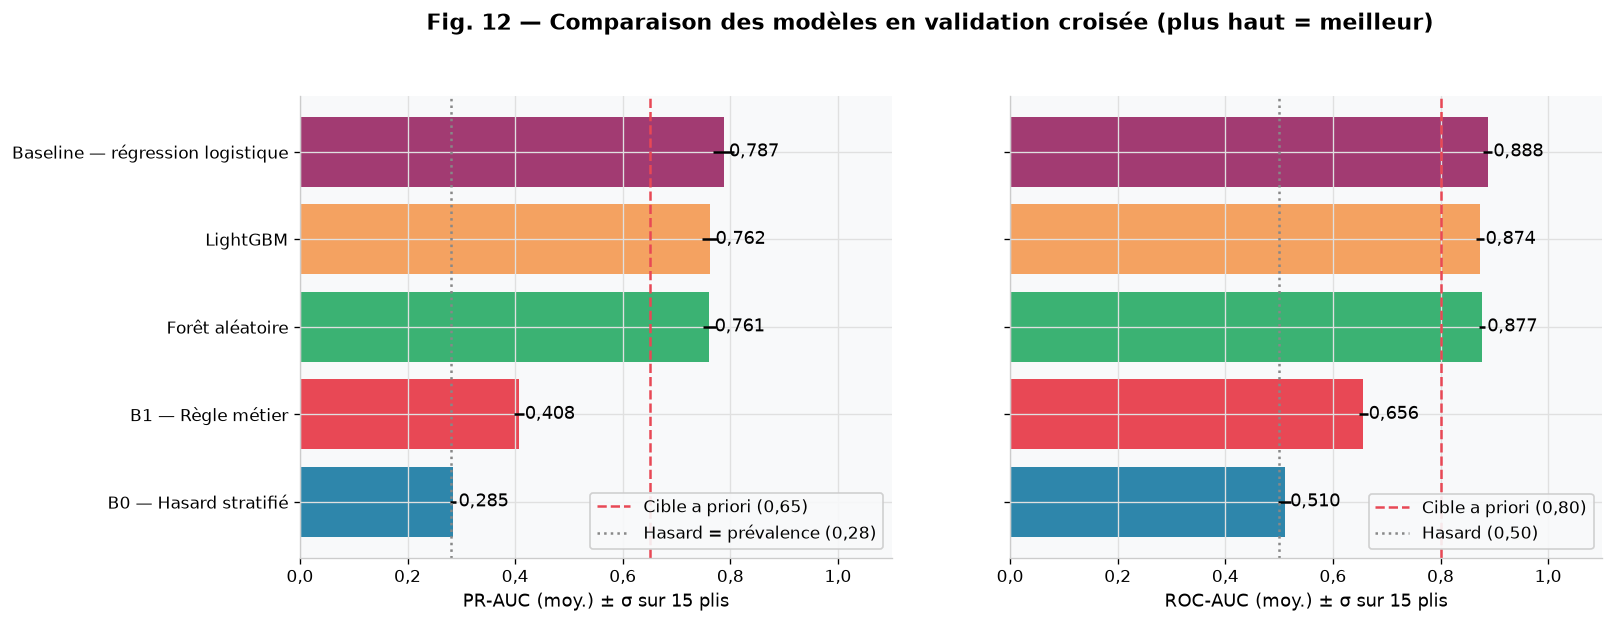

In [91]:
fig, axes = viz.figure_grille(
    "comparaison_modeles",
    "Comparaison des modèles en validation croisée (plus haut = meilleur)",
    taille=(14, 5),
)
_ordre = tableau_modeles.sort_values("pr_auc_mean").index
_couleurs = [viz.PALETTE_PRINCIPALE[i % len(viz.PALETTE_PRINCIPALE)] for i in range(len(_ordre))]
for ax, metrique, cible, hasard, libelle_hasard in [
    (axes[0], "pr_auc", _SEUIL_PR_AUC, y_dev.mean(), "Hasard = prévalence"),
    (axes[1], "roc_auc", _SEUIL_ROC_AUC, 0.5, "Hasard"),
]:
    valeurs = tableau_modeles.loc[_ordre, f"{metrique}_mean"]
    barres = ax.barh(
        _ordre, valeurs, xerr=tableau_modeles.loc[_ordre, f"{metrique}_std"], color=_couleurs
    )
    ax.axvline(
        cible, color=viz.COULEUR_CHURN, linestyle="--", label=f"Cible a priori ({nombre(cible, 2)})"
    )
    ax.axvline(
        hasard, color="#888888", linestyle=":", label=f"{libelle_hasard} ({nombre(hasard, 2)})"
    )
    for barre, val in zip(barres, valeurs, strict=True):
        ax.text(val + 0.01, barre.get_y() + barre.get_height() / 2, nombre(val, 3), va="center")
    ax.set_xlim(0, 1.1)
    ax.set_xlabel(f"{_LIBELLES[f'{metrique}_mean']} ± σ sur {cv_info.get_n_splits()} plis")
    ax.legend(loc="lower right")
axes[1].set_yticklabels([])
viz.sauvegarder(fig)

In [92]:
_ARBRES = [n for n in (train.NOM_FORET, train.NOM_LIGHTGBM) if n in tableau_modeles.index]
_meilleur_arbre = tableau_modeles.loc[_ARBRES, "pr_auc_mean"].idxmax()
_lin, _arb = tableau_modeles.loc[train.NOM_BASELINE_LR], tableau_modeles.loc[_meilleur_arbre]
_ecart_pr = float(_arb["pr_auc_mean"] - _lin["pr_auc_mean"])
_atteint = tableau_modeles[["pr_auc_mean", "roc_auc_mean"]] >= [_SEUIL_PR_AUC, _SEUIL_ROC_AUC]
_n_cibles_ok = int(_atteint.all(axis=1).sum())
display(
    Markdown(
        f"**Ce qu'il faut retenir.** {_n_cibles_ok} modèle(s) sur {len(tableau_modeles)} "
        f"atteignent à la fois les cibles a priori de PR-AUC (≥ {nombre(_SEUIL_PR_AUC, 2)}) et de "
        f"ROC-AUC (≥ {nombre(_SEUIL_ROC_AUC, 2)}). Le hasard (B0) se place bien au niveau de la "
        f"prévalence ({nombre(tableau_modeles.loc['B0 — Hasard stratifié', 'pr_auc_mean'], 3)}) : "
        f"le protocole ne fabrique pas de performance. Écart de PR-AUC de `{_meilleur_arbre}` "
        f"sur la régression logistique : {nombre(_ecart_pr, 3, signe=True)}. "
        + (
            "Les arbres captent des non-linéarités que le modèle linéaire manque."
            if _ecart_pr > 0
            else "Contrairement à l'intuition de §8.6, **la régression logistique devance les "
            "arbres** : les ratios métier de §7 rendent la relation au churn largement monotone, "
            "et sur ~4 000 comptes les arbres paient leur variance."
        )
    )
)

**Ce qu'il faut retenir.** 3 modèle(s) sur 5 atteignent à la fois les cibles a priori de PR-AUC (≥ 0,65) et de ROC-AUC (≥ 0,80). Le hasard (B0) se place bien au niveau de la prévalence (0,285) : le protocole ne fabrique pas de performance. Écart de PR-AUC de `LightGBM` sur la régression logistique : -0,025. Contrairement à l'intuition de §8.6, **la régression logistique devance les arbres** : les ratios métier de §7 rendent la relation au churn largement monotone, et sur ~4 000 comptes les arbres paient leur variance.

#### 9.3.1 L'écart est-il significatif ? — Wilcoxon apparié et correction de Holm

Une moyenne plus haute ne suffit pas : l'écart peut venir d'un découpage favorable. On
applique la règle écrite **avant** les résultats (§8.8) :

1. **Rejet** des modèles dont la PR-AUC moyenne est sous la cible a priori ;
2. **Champion provisoire** : la meilleure PR-AUC moyenne parmi les non-rejetés ;
3. **Test de Wilcoxon apparié** : pour chaque concurrent, on regarde pli par pli qui gagne,
   et de combien ; le test dit si le champion gagne trop souvent pour que ce soit le hasard ;
4. **Correction de Holm** : plusieurs tests multiplient les fausses victoires, Holm resserre
   les seuils pour garder un risque global α ;
5. **Règle de complexité** : un modèle plus simple non rejeté que le champion ne bat pas
   significativement, **ou** de moins de `gain_pr_auc_min_complexite`, est préféré (§8.4).

Ordre de simplicité (`ORDRE_SIMPLICITE`) : B0 < B1 < régression logistique < ensembles
d'arbres (forêt aléatoire et LightGBM au même niveau).

In [93]:
_non_rejetes = tableau_modeles.index[tableau_modeles["pr_auc_mean"] >= _SEUIL_PR_AUC].tolist()
# Si aucun modèle n'atteint la cible, on teste quand même le meilleur, mais aucun n'est déployable
champion_provisoire = _non_rejetes[0] if _non_rejetes else tableau_modeles.index[0]
tests_superiorite = train.comparer_au_champion(tableau_modeles, champion_provisoire)
_non_departages = [
    n
    for n in _non_rejetes
    if n != champion_provisoire
    and (
        not tests_superiorite.loc[n, "significatif"]
        or tests_superiorite.loc[n, "ecart_pr_auc_moyen"] < _GAIN_MIN_COMPLEXITE
    )
]
modele_retenu = min(
    [champion_provisoire, *_non_departages],
    key=lambda n: (train.ORDRE_SIMPLICITE.get(n, 99), -tableau_modeles.loc[n, "pr_auc_mean"]),
)

_LIBELLES_TESTS = {
    "ecart_pr_auc_moyen": "Écart PR-AUC moyen",
    "plis_gagnes": "Plis gagnés par le champion",
    "p_valeur_brute": "p-valeur brute",
    "p_valeur_holm": "p-valeur ajustée (Holm)",
    "significatif": f"Significatif (α = {nombre(train.ALPHA_SIGNIFICATIVITE, 2)})",
}


def _afficher_tests(tests: pd.DataFrame, champion: str) -> None:
    """Affiche les tests de supériorité du champion contre chaque concurrent."""
    vue = tests.assign(significatif=tests["significatif"].map({True: "Oui", False: "Non"}))
    vue = vue.rename(columns=_LIBELLES_TESTS)
    vue.index.name = f"Champion « {champion} » contre…"
    display(
        styler_fr(
            vue,
            {
                "Écart PR-AUC moyen": lambda v: nombre(v, 4, signe=True),
                "p-valeur brute": lambda v: scientifique(v, 2),
                "p-valeur ajustée (Holm)": lambda v: scientifique(v, 2),
            },
        )
    )


_afficher_tests(tests_superiorite, champion_provisoire)

,Écart PR-AUC moyen,Plis gagnés par le champion,p-valeur brute,p-valeur ajustée (Holm),"Significatif (α = 0,05)"
Champion « Baseline — régression logistique » contre…,,,,,
LightGBM,"+0,0250",15/15,"3,05e-05","1,22e-04",Oui
Forêt aléatoire,"+0,0266",14/15,"9,16e-05","1,22e-04",Oui
B1 — Règle métier,"+0,3794",15/15,"3,05e-05","1,22e-04",Oui
B0 — Hasard stratifié,"+0,5026",15/15,"3,05e-05","1,22e-04",Oui


In [94]:
_n_plis = sum(c.startswith(train.PREFIXE_PLI) for c in tableau_modeles.columns)
_verdict = (
    f"**`{modele_retenu}` est retenu** : aucun modèle plus simple ne le concurrence."
    if modele_retenu == champion_provisoire
    else f"Son avance sur `{modele_retenu}`, plus simple, est non significative ou sous "
    f"{nombre(_GAIN_MIN_COMPLEXITE, 2)} : **`{modele_retenu}` est retenu**."
)
display(
    Markdown(
        f"**Ce qu'il faut retenir.** {len(_non_rejetes)} modèle(s) sur {len(tableau_modeles)} "
        f"franchissent la cible de PR-AUC. Le champion provisoire `{champion_provisoire}` bat "
        f"significativement {int(tests_superiorite['significatif'].sum())} concurrent(s) sur "
        f"{len(tests_superiorite)} après correction de Holm. {_verdict} Avec {_n_plis} plis, "
        f"la plus petite p-valeur possible est 1/2^{_n_plis} ≈ {scientifique(0.5**_n_plis, 1)} "
        "(champion meilleur sur tous les plis). Limite assumée : les plis répétés partagent des "
        "données, le test est un garde-fou, pas une preuve absolue."
    )
)

**Ce qu'il faut retenir.** 3 modèle(s) sur 5 franchissent la cible de PR-AUC. Le champion provisoire `Baseline — régression logistique` bat significativement 4 concurrent(s) sur 4 après correction de Holm. **`Baseline — régression logistique` est retenu** : aucun modèle plus simple ne le concurrence. Avec 15 plis, la plus petite p-valeur possible est 1/2^15 ≈ 3,1e-05 (champion meilleur sur tous les plis). Limite assumée : les plis répétés partagent des données, le test est un garde-fou, pas une preuve absolue.

### 9.4 Gain réel sur la règle métier

Le modèle vaut-il un déploiement, face à une règle à deux conditions qu'un filtre du CRM
applique ? Il n'est justifié que si B1 manque la cible a priori, ou s'il le devance d'au
moins `gain_pr_auc_min_complexite` (règle de complexité).

In [95]:
_pr_b1, _pr_retenu = tableau_modeles.loc[["B1 — Règle métier", modele_retenu], "pr_auc_mean"]
_gain_b1 = _pr_retenu - _pr_b1
_b1_rejete = _pr_b1 < _SEUIL_PR_AUC
_ml_justifie = not modele_retenu.startswith("B1") and (
    _b1_rejete or _gain_b1 >= _GAIN_MIN_COMPLEXITE
)
display(
    Markdown(
        f"**Ce qu'il faut retenir.** `{modele_retenu}` atteint une PR-AUC de "
        f"{nombre(_pr_retenu, 3)} contre {nombre(_pr_b1, 3)} pour la règle métier, soit "
        f"{nombre(_gain_b1, 3, signe=True)} ({pourcentage(_gain_b1 / max(_pr_b1, 1e-6), 0, signe=True)}"
        f"). La règle B1 {'manque' if _b1_rejete else 'atteint'} la cible a priori de "
        f"{nombre(_SEUIL_PR_AUC, 2)}. "
        + (
            "**Le modèle est justifié** : pour la même capacité d'appels CS, il trouve nettement "
            "plus de vrais churners."
            if _ml_justifie
            else "**La règle métier reste préférable** : plus simple et plus auditable, pour un "
            "gain insuffisant du modèle."
        )
    )
)

**Ce qu'il faut retenir.** `Baseline — régression logistique` atteint une PR-AUC de 0,787 contre 0,408 pour la règle métier, soit +0,379 (+93 %). La règle B1 manque la cible a priori de 0,65. **Le modèle est justifié** : pour la même capacité d'appels CS, il trouve nettement plus de vrais churners.

### 9.5 Journalisation MLflow

Pour retrouver et rejouer chaque résultat, chaque modèle comparé donne lieu à une exécution
MLflow (paramètres, métriques, modèle au format skops) dans `mlruns/mlflow.db`.

In [96]:
_params_communs = {
    "random_seed": config.RANDOM_SEED,
    "cv_n_splits": N_PLIS_CV,
    "cv_n_repeats": N_REPETITIONS_CV,
    "pr_auc_min_cible": _SEUIL_PR_AUC,
}
_run_ids = {}
for _nom, _modele in modeles.items():
    # Scores par pli exclus : MLflow reçoit les agrégats, le détail reste dans le cache parquet
    _metriques = {
        k: v
        for k, v in tableau_modeles.loc[_nom].items()
        if isinstance(v, float) and not k.startswith(train.PREFIXE_PLI)
    }
    _run_ids[_nom] = train.journaliser_mlflow(
        _nom, _modele, _metriques, _params_communs | {"modele": _nom}
    )

display(
    Markdown(
        f"**Ce qu'il faut retenir.** {len(_run_ids)} exécutions MLflow enregistrées "
        "(`mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db`) : chaque chiffre de §9.3 a "
        "une trace datée, base du registry (registre de modèles) de §10.4."
    )
)

**Ce qu'il faut retenir.** 5 exécutions MLflow enregistrées (`mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db`) : chaque chiffre de §9.3 a une trace datée, base du registry (registre de modèles) de §10.4.

### 9.6 Gestion du déséquilibre — class_weight, correction d'intercept, SMOTE

Les churners sont minoritaires : sans précaution, un modèle apprend surtout à reconnaître
les clients fidèles. Deux remèdes classiques existent, mais tous deux faussent les
probabilités, alors que §12 les multiplie par des euros. Il faut donc des probabilités
**calibrées** : 30 % annoncé doit correspondre à 30 % de churners observés.

| Technique | Mécanisme | Effet sur les probabilités |
|---|---|---|
| `class_weight='balanced'` | Les erreurs sur les churners pèsent plus lourd | Décalage **connu** : + log((1 − π)/π) sur le logit |
| Pondération + correction d'intercept (`RegressionLogistiqueRecalibree`) | On retire ce décalage connu de l'intercept (constante) | Corrigé exactement, sans paramètre appris |
| SMOTE | On fabrique des churners synthétiques | Décalage **sans forme connue** |

Évaluation sur la régression logistique, dans le pipeline, sur les mêmes plis. La correction
exacte est propre au modèle linéaire : la calibration des arbres n'est pas garantie (§9.12).

In [97]:
def _calcul_desequilibre() -> dict:
    tableau_deseq, cal_data = train.comparer_desequilibre(X_dev, y_dev, df_ref=X_dev)
    return {"tableau": tableau_deseq.reset_index().to_dict(orient="list"), "calibration": cal_data}


_resultat_deseq, _ = charger_ou_calculer("comparaison_desequilibre.json", _calcul_desequilibre)
_tableau_deseq = pd.DataFrame(_resultat_deseq["tableau"]).set_index("approche")
_cal_data = _resultat_deseq["calibration"]
display(styler_fr(_tableau_deseq, precision=4))

,pr_auc,roc_auc,brier_score
approche,,,
class_weight='balanced',"0,7837","0,8869","0,1353"
class_weight='balanced' + correction d'intercept,"0,7837","0,8869","0,1161"
SMOTE,"0,7767","0,8833","0,1367"


PosixPath('~/churn_saas/reports/figures/13_calibration_desequilibre.png')

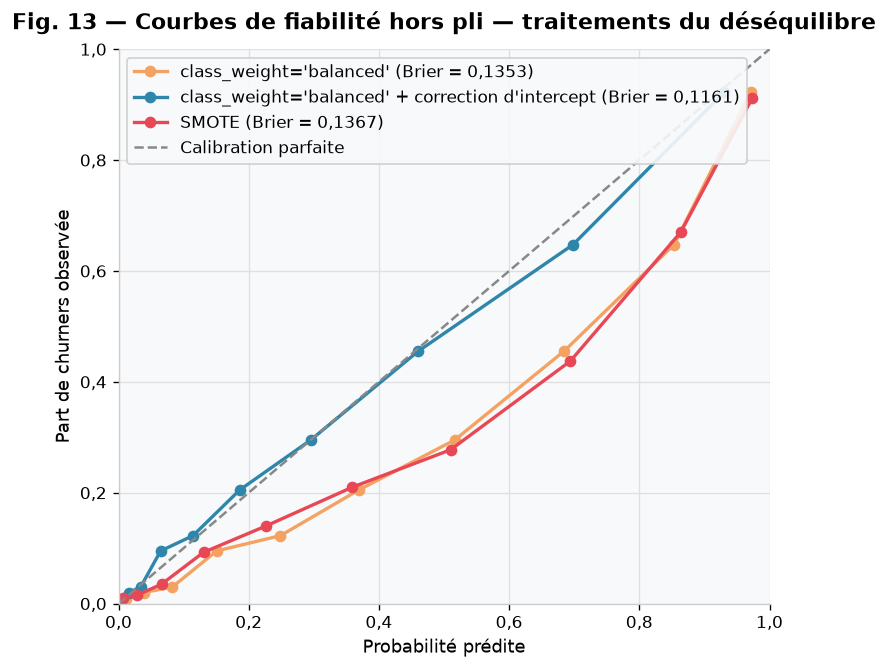

In [98]:
fig, ax = viz.figure(
    "calibration_desequilibre",
    "Courbes de fiabilité hors pli — traitements du déséquilibre",
    taille=(7, 6),
)
for (nom_approche, cal), couleur in zip(
    _cal_data.items(),
    [viz.PALETTE_PRINCIPALE[3], viz.COULEUR_NON_CHURN, viz.COULEUR_CHURN],
    strict=True,
):
    brier_val = _tableau_deseq.loc[nom_approche, "brier_score"]
    ax.plot(
        cal["prob_pred"],
        cal["prob_true"],
        marker="o",
        color=couleur,
        linewidth=2,
        label=f"{nom_approche} (Brier = {nombre(brier_val, 4)})",
    )
ax.plot([0, 1], [0, 1], linestyle="--", color="#888888", label="Calibration parfaite")
ax.set_xlabel("Probabilité prédite")
ax.set_ylabel("Part de churners observée")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
viz.sauvegarder(fig)

In [99]:
_brier = _tableau_deseq["brier_score"]
_prauc = _tableau_deseq["pr_auc"]
_CW, _CORR, _SMOTE = (
    "class_weight='balanced'",
    "class_weight='balanced' + correction d'intercept",
    "SMOTE",
)
# Écart moyen à la diagonale : > 0 = risque surestimé
_ecart_diag = {
    nom: float(np.mean(np.asarray(cal["prob_pred"]) - np.asarray(cal["prob_true"])))
    for nom, cal in _cal_data.items()
}
display(
    Markdown(
        f"**Ce qu'il faut retenir.** La pondération seule (Brier {nombre(_brier[_CW], 4)}) et "
        f"SMOTE ({nombre(_brier[_SMOTE], 4)}) dégradent la calibration ; en moyenne sur les "
        "tranches, elles "
        + " et ".join(
            f"{'surestiment' if _ecart_diag[n] > 0 else 'sous-estiment'} le risque de "
            f"{nombre(100 * abs(_ecart_diag[n]), 1)} points"
            for n in (_CW, _SMOTE)
        )
        + f". La correction d'intercept ramène le Brier à **{nombre(_brier[_CORR], 4)}** (écart "
        f"moyen de {nombre(100 * _ecart_diag[_CORR], 1, signe=True)} point) sans changer le "
        f"classement (PR-AUC {nombre(_prauc[_CW], 4)} contre {nombre(_prauc[_CORR], 4)}). "
        "Avantage décisif sur SMOTE : son décalage est connu, donc exactement corrigeable ; "
        "c'est la version utilisée dans tout le notebook."
    )
)

**Ce qu'il faut retenir.** La pondération seule (Brier 0,1353) et SMOTE (0,1367) dégradent la calibration ; en moyenne sur les tranches, elles surestiment le risque de 11,3 points et surestiment le risque de 10,6 points. La correction d'intercept ramène le Brier à **0,1161** (écart moyen de +0,0 point) sans changer le classement (PR-AUC 0,7837 contre 0,7837). Avantage décisif sur SMOTE : son décalage est connu, donc exactement corrigeable ; c'est la version utilisée dans tout le notebook.

### 9.7 Optimisation des hyperparamètres (Optuna)

Un hyperparameter (hyperparamètre) est un réglage fixé avant l'apprentissage : force de la
régularisation, nombre et taille des arbres. Le tuning (optimisation des hyperparamètres)
cherche les meilleurs réglages ; Optuna le fait intelligemment, en concentrant ses essais
près des réglages déjà prometteurs (échantillonneur TPE) et en abandonnant tôt les essais
mal partis (élagage `MedianPruner`).

**Deux modèles optimisés, à budget égal** (30 essais, 5 plis chacun) : la régression
logistique et LightGBM. Opposer un modèle réglé à un modèle par défaut serait inéquitable.
La forêt aléatoire, même famille et même complexité que LightGBM, n'est pas optimisée :
cela doublerait le coût du calcul pour un candidat que §9.3 place derrière.

**Limite assumée.** Le meilleur de 30 essais notés sur les mêmes 5 plis est optimiste : il
sert à **choisir** les réglages, pas à **juger** le modèle, réévalué sur 15 plis en §9.12.

| Modèle | Hyperparamètre | Espace de recherche | Rôle attendu |
|---|---|---|---|
| Régression logistique | `C` | [0,001 ; 100], échelle log | Inverse de la régularisation : plus grand = coefficients plus libres |
| Régression logistique | `max_iter` | {500, 1000, 2000} | Itérations du solveur, pour garantir la convergence |
| LightGBM | `num_leaves` | [8, 64], échelle log | Taille de chaque arbre : la capacité principale du modèle |
| LightGBM | `learning_rate` | [0,01 ; 0,3], échelle log | Taux d'apprentissage : part de correction apportée par chaque arbre |
| LightGBM | `n_estimators` | [100, 500], pas de 50 | Nombre d'arbres, à équilibrer avec le taux d'apprentissage |
| LightGBM | `min_child_samples` | [5, 100], échelle log | Comptes minimum par feuille : contre le surapprentissage |
| LightGBM | `reg_lambda` | [0,001 ; 10], échelle log | Pénalité L2 sur les feuilles |
| LightGBM | `subsample` | [0,6 ; 1] | Part des comptes tirés pour chaque arbre : décorrèle les arbres |
| LightGBM | `colsample_bytree` | [0,5 ; 1] | Part des variables tirées pour chaque arbre |

In [100]:
MODELES_OPTIMISES = [train.NOM_BASELINE_LR, train.NOM_LIGHTGBM]
N_ESSAIS_OPTUNA = 30

resultats_optuna = {}
for _nom in MODELES_OPTIMISES:
    resultats_optuna[_nom], _ = charger_ou_calculer(
        f"optuna_{train.identifiant_modele(_nom)}_meilleurs_params.json",
        lambda nom=_nom: train.optimiser(nom, X_dev, y_dev, n_essais=N_ESSAIS_OPTUNA),
    )

_synthese_optuna = pd.DataFrame.from_dict(
    {
        nom: {
            "PR-AUC par défaut (5 plis)": r["pr_auc_defaut"],
            "PR-AUC du meilleur essai (optimiste)": r["best_value"],
            "Gain d'Optuna (borne haute)": r["gain_pr_auc"],
            "Essais complétés": r["n_essais_completes"],
        }
        for nom, r in resultats_optuna.items()
    },
    orient="index",
)
display(styler_fr(_synthese_optuna, precision=4))
_gains = {nom: r["gain_pr_auc"] for nom, r in resultats_optuna.items()}
_marginaux = [n for n, g in _gains.items() if abs(g) <= _GAIN_MIN_COMPLEXITE]
display(
    Markdown(
        "".join(
            f"**Réglages retenus pour `{nom}`** : "
            + ", ".join(
                f"`{hp}` = {nombre(v, 4) if isinstance(v, float) else v}" for hp, v in p.items()
            )
            + ".  \n"
            for nom, p in ((n, r["best_params"]) for n, r in resultats_optuna.items())
        )
        + "\n**Ce qu'il faut retenir.** "
        + " ; ".join(f"`{n}` gagne {nombre(g, 4, signe=True)} de PR-AUC" for n, g in _gains.items())
        + ". "
        + (
            f"Sous {nombre(_GAIN_MIN_COMPLEXITE, 2)} pour {', '.join(f'`{n}`' for n in _marginaux)}"
            " : les réglages par défaut étaient déjà bien placés. "
            if _marginaux
            else ""
        )
        + "Chaque gain est une borne haute (meilleur essai choisi sur les plis qui le notent) ; "
        "§9.12 dira si l'optimisation change le classement des deux modèles."
    )
)

,PR-AUC par défaut (5 plis),PR-AUC du meilleur essai (optimiste),Gain d'Optuna (borne haute),Essais complétés
Baseline — régression logistique,"0,7846","0,7858","0,0012",30
LightGBM,"0,7587","0,7758","0,0171",30


**Réglages retenus pour `Baseline — régression logistique`** : `C` = 0,0746, `max_iter` = 500.  
**Réglages retenus pour `LightGBM`** : `num_leaves` = 10, `learning_rate` = 0,0270, `n_estimators` = 250, `min_child_samples` = 19, `reg_lambda` = 1,3826, `subsample` = 0,6799, `colsample_bytree` = 0,7571.  

**Ce qu'il faut retenir.** `Baseline — régression logistique` gagne +0,0012 de PR-AUC ; `LightGBM` gagne +0,0171 de PR-AUC. Sous 0,02 pour `Baseline — régression logistique`, `LightGBM` : les réglages par défaut étaient déjà bien placés. Chaque gain est une borne haute (meilleur essai choisi sur les plis qui le notent) ; §9.12 dira si l'optimisation change le classement des deux modèles.

### 9.8 Empreinte carbone du tuning

Optimiser consomme de l'énergie : on la mesure, pour vérifier qu'elle reste proportionnée au
gain. Sous WSL2, CodeCarbon n'accède pas aux compteurs RAPL du processeur : il **estime**
alors la consommation depuis sa puissance nominale (TDP) et le facteur d'émission du réseau.

In [101]:
_carbone = pd.DataFrame.from_dict(
    {
        nom: {
            "Durée (s)": r["duree_s"],
            "Énergie (kWh)": r["energy_kwh"],
            "Émissions (g CO₂)": 1000 * r["emissions_kg_co2"],
            "Coût électrique (€)": r["energy_kwh"] * config.TARIF_ELECTRICITE_EUR_KWH,
            # En deçà d'un centième de point de PR-AUC, le ratio n'a plus de sens
            "kWh par point de PR-AUC gagné": (
                r["energy_kwh"] / (100 * r["gain_pr_auc"]) if r["gain_pr_auc"] > 1e-4 else np.nan
            ),
        }
        for nom, r in resultats_optuna.items()
    },
    orient="index",
)
display(styler_fr(_carbone, precision=6))
_modes = {
    f"{'estimation' if r['is_estimation'] else 'mesure'} ({r['mode_mesure_carbone']})"
    for r in resultats_optuna.values()
}
_facteurs = {r["facteur_emission_kg_kwh"] for r in resultats_optuna.values()}
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Les deux recherches ont émis au total "
        f"{nombre(_carbone['Émissions (g CO₂)'].sum(), 3)} g CO₂ en "
        f"{nombre(_carbone['Durée (s)'].sum() / 60, 1)} min, pour "
        f"{euros(_carbone['Coût électrique (€)'].sum(), 4)} d'électricité, très loin du budget "
        f"a priori de {entier(CIBLES['co2_entrainement_max_g'])} g (§8.2, bilan en §12.13). "
        f"Collecte : {', '.join(sorted(_modes))}, facteur "
        f"{', '.join(nombre(v, 4) for v in sorted(_facteurs))} kg CO₂/kWh : un ordre de grandeur. "
        "Un ratio vide signale un gain sous 0,01 point, sans rien à rapporter au coût."
    )
)

,Durée (s),Énergie (kWh),Émissions (g CO₂),Coût électrique (€),kWh par point de PR-AUC gagné
Baseline — régression logistique,"81,044519","0,000439","0,024615","0,000079","0,003604"
LightGBM,"101,085712","0,000322","0,018047","0,000058","0,000189"


**Ce qu'il faut retenir.** Les deux recherches ont émis au total 0,043 g CO₂ en 3,0 min, pour 0,0001 € d'électricité, très loin du budget a priori de 50 g (§8.2, bilan en §12.13). Collecte : estimation (estimation TDP), facteur 0,0560 kg CO₂/kWh : un ordre de grandeur. Un ratio vide signale un gain sous 0,01 point, sans rien à rapporter au coût.

### 9.9 Note d'arbitrage performance / temps / carbone

Le coût de l'optimisation est négligeable, en euros comme en carbone : la vraie question est
celle du **gain**. Sous le seuil de la règle de complexité, la recherche n'est pas relancée à
chaque cycle : le flow réutilise les réglages trouvés ici (§9.11), jusqu'à un changement des
données ou des variables. Le budget de 30 essais n'est pas élargi : sur ~4 000 comptes, le
bruit de la validation croisée est du même ordre que le gain d'un espace plus large.

### 9.10 Contraintes d'éco-conception portées au commanditaire

Engagements repris dans la fiche modèle (`docs/MODEL_CARD.md`), conditions de service.

| Poste | Mesure retenue | Pourquoi |
|---|---|---|
| Scoring (calcul des scores) | Batch (traitement par lot) nocturne ; API seulement à la demande d'un CSM | Les sources se rafraîchissent une fois par jour : un calcul continu ne verrait rien de neuf |
| Réentraînement | Trimestriel ou sur dérive détectée (§13) | Pas de réentraînement superflu |
| Tuning | Réglages réutilisés d'un cycle à l'autre (§9.11) | Une recherche n'est relancée que si les données changent |
| Matériel | CPU du poste, sans GPU ni instance cloud | Les modèles comparés n'exploitent pas de GPU |
| Suivi | CodeCarbon à chaque tuning (`reports/tables/codecarbon_emissions.csv`) | Évolution de l'empreinte traçable dans le temps |

### 9.11 Transfert de connaissances

On ne repart pas de zéro à chaque modèle. Réutiliser les couches d'un réseau de neurones ne
s'applique pas à ~5 000 lignes tabulaires, sans texte ni image : ce qui se transmet, c'est le
**savoir acquis sur le modèle** :

| Ce qui est transmis | Comment | Où |
|---|---|---|
| Famille et hyperparamètres du champion | Repris par `famille_et_hyperparametres_champion()` (méta du champion promu, à défaut l'étude Optuna retenue en §9.12) : pas de nouveau tuning à chaque cycle | `flows/retraining.py`, §13.8 |
| Schéma de préparation | Mêmes colonnes et mêmes transformations, réapprises sur les données du cycle | Tous les cycles |
| Données cumulées | Anciens et nouveaux comptes étiquetés réunis dans le jeu gold reconstruit | §13.8 |
| Gate (règle de promotion) | Le challenger n'est promu que s'il atteint la cible et ne régresse pas face au champion | §10.4, §13.8 |

**Ce qu'il faut retenir.** Ce sont les réglages et le schéma qui passent d'un cycle à
l'autre, pas des poids : ne pas relancer de recherche est aussi un gain d'éco-conception.

### 9.12 Sélection finale du modèle

Le meilleur essai d'Optuna était optimiste (§9.7) : les deux modèles optimisés sont donc
réévalués sur les **15 plis du protocole**, ceux de §9.3, puis départagés par la même règle
(Wilcoxon, Holm, règle de complexité). À l'issue de cette sous-section, la **configuration**
du modèle (famille et hyperparamètres) est figée : plus rien ne sera rechoisi.

In [102]:
def _calcul_optimises() -> pd.DataFrame:
    tableau = train.comparer_modeles_optimises(list(resultats_optuna.values()), X_dev, y_dev)
    # Les réglages évalués accompagnent le cache, pour détecter un cache périmé
    return tableau.assign(
        best_params=[str(resultats_optuna[n]["best_params"]) for n in tableau.index]
    )


tableau_optimises, _ = charger_ou_calculer(
    "comparaison_modeles_optimises.parquet", _calcul_optimises
)
if any(
    n not in tableau_optimises.index
    or tableau_optimises.loc[n, "best_params"] != str(r["best_params"])
    for n, r in resultats_optuna.items()
):
    tableau_optimises, _ = charger_ou_calculer(
        "comparaison_modeles_optimises.parquet", _calcul_optimises, forcer=True
    )
_afficher_metriques(tableau_optimises)

nom_final, tests_optimises = train.selectionner_modele_optimise(tableau_optimises)
_champion_optimise = str(tableau_optimises["pr_auc_mean"].idxmax())
_afficher_tests(tests_optimises, _champion_optimise)

,PR-AUC (moy.),PR-AUC (σ),ROC-AUC (moy.),"Recall au seuil 0,5","Precision au seuil 0,5",Brier,Latence unitaire (ms),Durée d'évaluation (s)
modele,,,,,,,,
Baseline — régression logistique,"0,788","0,019","0,889","0,604","0,764","0,115","39,628","16,200"
LightGBM,"0,777","0,014","0,884","0,771","0,625","0,134","32,230","17,200"


,Écart PR-AUC moyen,Plis gagnés par le champion,p-valeur brute,p-valeur ajustée (Holm),"Significatif (α = 0,05)"
Champion « Baseline — régression logistique » contre…,,,,,
LightGBM,"+0,0111",13/15,"7,63e-04","7,63e-04",Oui


In [103]:
_autre = next(n for n in tableau_optimises.index if n != nom_final)
_f, _a = tableau_optimises.loc[nom_final], tableau_optimises.loc[_autre]
_motif = (
    "avec la meilleure moyenne"
    if nom_final == _champion_optimise
    else f"plus simple, `{_champion_optimise}` n'ayant pas d'avance suffisante (règle de complexité)"
)
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Sur les mêmes 15 plis, `{nom_final}` obtient une PR-AUC de "
        f"{nombre(_f['pr_auc_mean'], 3)} (ROC-AUC {nombre(_f['roc_auc_mean'], 3)}), contre "
        f"{nombre(_a['pr_auc_mean'], 3)} ({nombre(_a['roc_auc_mean'], 3)}) pour `{_autre}` : "
        f"**`{nom_final}` est retenu**, {_motif}. L'optimisation "
        + ("confirme" if nom_final == modele_retenu else "renverse")
        + f" le verdict de §9.3.1 (`{modele_retenu}`)."
    )
)

**Ce qu'il faut retenir.** Sur les mêmes 15 plis, `Baseline — régression logistique` obtient une PR-AUC de 0,788 (ROC-AUC 0,889), contre 0,777 (0,884) pour `LightGBM` : **`Baseline — régression logistique` est retenu**, avec la meilleure moyenne. L'optimisation confirme le verdict de §9.3.1 (`Baseline — régression logistique`).

In [104]:
# Noms relus par §10 (déploiement du modèle retenu)
nom_a_optimiser, resultat_optuna = nom_final, resultats_optuna[nom_final]
_id_final = train.identifiant_modele(nom_final)
# Performance de référence du modèle livré, relue par §14 et les annexes
_eval_protocole, _ = charger_ou_calculer(
    f"evaluation_protocole_{_id_final}_optimise.json",
    lambda: tableau_optimises.loc[nom_final].drop("best_params").astype(float).to_dict()
    | {"best_params": resultat_optuna["best_params"]},
    forcer=True,
)
# Réécrit pour être l'étude la plus récente : à défaut de champion promu,
# `famille_et_hyperparametres_champion()` (§9.11) relit la plus récente
charger_ou_calculer(
    f"optuna_{_id_final}_meilleurs_params.json", lambda: resultat_optuna, forcer=True
)

# Configuration figée, apprise une première fois sur le seul développement (§9.13, §9.14)
_pipeline_dev = train.construire_modele_optimise(
    nom_final, resultat_optuna["best_params"], df_ref=X_dev
)
modele_dev = clone(_pipeline_dev).fit(X_dev, y_dev)

In [105]:
_clf_final = modele_dev[-1]
_lr_recalibree = type(_clf_final).__name__ == "RegressionLogistiqueRecalibree"
_calibration_ok = _lr_recalibree and bool(_brier[_CORR] < _brier[_CW])
if hasattr(_clf_final, "feature_importances_"):
    _explainer = "TreeExplainer (arbres)"
elif hasattr(_clf_final, "coef_"):
    _explainer = "LinearExplainer (linéaire)"
else:
    _explainer = None
_criteres = pd.DataFrame.from_dict(
    {
        "Calibration des probabilités": (
            (
                f"Brier {nombre(_brier[_CORR], 4)} avec correction, {nombre(_brier[_CW], 4)} sans"
                if _lr_recalibree
                else f"Brier {nombre(_eval_protocole['brier_mean'], 4)}, sans correction établie"
            ),
            "Probabilités fiables pour les euros (§12)",
            _calibration_ok,
        ),
        "Explication de chaque score (SHAP)": (
            _explainer or "aucun explainer exact",
            "Explainer exact (§12.8)",
            _explainer is not None,
        ),
        "Traçabilité MLflow": (
            f"{len(_run_ids)} exécutions sur {len(tableau_modeles)} modèles",
            "Une exécution par modèle comparé",
            len(_run_ids) == len(tableau_modeles),
        ),
    },
    orient="index",
    columns=["Valeur obtenue", "Cible", "Statut"],
)
_criteres["Statut"] = _criteres["Statut"].map({True: "✅", False: "❌"})
display(styler_fr(_criteres).set_properties(**{"text-align": "left"}))

,Valeur obtenue,Cible,Statut
Calibration des probabilités,"Brier 0,1161 avec correction, 0,1353 sans",Probabilités fiables pour les euros (§12),✅
Explication de chaque score (SHAP),LinearExplainer (linéaire),Explainer exact (§12.8),✅
Traçabilité MLflow,5 exécutions sur 5 modèles,Une exécution par modèle comparé,✅


**Ce qu'il faut retenir.** Au-delà du score, chaque critère de déploiement est vérifié par le
calcul : un ❌ signale un point à traiter avant la mise en service. La configuration est
désormais figée. Elle est apprise une première fois sur le seul jeu de développement
(`modele_dev`) : c'est ce modèle que mesurent la latence (§9.13) et le test (§9.14).

### 9.13 Latence d'inférence — confrontation aux cibles §8

Un CSM qui ouvre une fiche client attend la réponse : on mesure donc le temps de calcul d'un
score isolé (95ᵉ centile, p95 : 95 % des appels sont plus rapides) et celui du batch nocturne,
face aux cibles a priori de §8.2. Ce temps dépend de la configuration (nombre de coefficients
ou d'arbres), pas du nombre de comptes appris : `modele_dev` le mesure pour le modèle livré.

In [106]:
# Lot de 5 000 comptes tiré du seul développement : le test reste fermé jusqu'en §9.14
_lot_latence = X_dev.sample(5_000, replace=True, random_state=config.RANDOM_SEED)
# Mesurée à chaque exécution et écrite sur disque : §12.3 et §14 relisent cette même mesure
rapport_latence, _ = charger_ou_calculer(
    "latence_modele_final.json",
    lambda: train.mesurer_latence(modele_dev, _lot_latence),
    forcer=True,
)
_lat_p95 = rapport_latence["latence_unitaire_ms_p95"]
_lat_batch = rapport_latence["latence_batch_5k_s"]
_ok_unitaire = _lat_p95 <= CIBLES["latence_unitaire_ms"]
_ok_batch = _lat_batch <= CIBLES["latence_batch_5k_s"]
display(
    Markdown(
        "| Mesure | Valeur | Cible | Statut |\n|---|---|---|---|\n"
        f"| Unitaire — médiane | {nombre(rapport_latence['latence_unitaire_ms_mediane'], 2)} ms "
        "| — | — |\n"
        f"| Unitaire — p95 | {nombre(_lat_p95, 2)} ms | ≤ {entier(CIBLES['latence_unitaire_ms'])} "
        f"ms | {'✅' if _ok_unitaire else '❌'} |\n"
        f"| Batch de {entier(rapport_latence['n_batch'])} comptes | {nombre(_lat_batch, 3)} s "
        f"| ≤ {entier(CIBLES['latence_batch_5k_s'])} s | {'✅' if _ok_batch else '❌'} |\n\n"
        "**Ce qu'il faut retenir.** "
        + (
            f"Les deux cibles sont tenues avec une large marge (mesure sur "
            f"{entier(rapport_latence['n_unitaire'])} appels unitaires) : le modèle convient à "
            "l'API synchrone comme au batch nocturne."
            if _ok_unitaire and _ok_batch
            else "⚠️ Au moins une cible de latence est manquée : alléger le préprocesseur ou le "
            "modèle avant déploiement."
        )
    )
)

| Mesure | Valeur | Cible | Statut |
|---|---|---|---|
| Unitaire — médiane | 24,89 ms | — | — |
| Unitaire — p95 | 32,60 ms | ≤ 200 ms | ✅ |
| Batch de 5 000 comptes | 0,058 s | ≤ 300 s | ✅ |

**Ce qu'il faut retenir.** Les deux cibles sont tenues avec une large marge (mesure sur 200 appels unitaires) : le modèle convient à l'API synchrone comme au batch nocturne.

### 9.14 Évaluation finale sur le jeu de test

Toutes les notes précédentes viennent du jeu de développement, celui qui a servi à choisir le
modèle, ses réglages et sa calibration : elles peuvent être un peu optimistes. On ouvre donc,
une seule fois, le test mis de côté en §9.1, dans les conditions de la production :

1. **Le modèle noté** est `modele_dev` : la configuration retenue, apprise sur le seul
   développement ;
2. **Le seuil de vigilance** est fixé sans voir le test, sur les prédictions out-of-fold (hors
   pli : chaque compte du développement est noté par un modèle qui ne l'a pas appris) ;
3. **La note du test** reçoit un intervalle de confiance à 95 % par bootstrap
   (rééchantillonnage avec remise des comptes du test) : sur un échantillon de cette taille,
   une note est bruitée.

**Règle de non-retour.** Aucune décision n'est modifiée après lecture du test. Une cible
manquée ici est documentée et portée au plan d'amélioration (§13), jamais corrigée par un
nouveau réglage : le test deviendrait alors un second jeu de validation, et sa note perdrait
toute valeur.

In [107]:
def _calcul_evaluation_test() -> dict:
    cv = StratifiedKFold(N_PLIS_CV, shuffle=True, random_state=config.RANDOM_SEED)
    oof = cross_val_predict(clone(_pipeline_dev), X_dev, y_dev, cv=cv, method="predict_proba")
    vigilance = economics.seuil_pour_recall(y_dev, oof[:, 1])
    proba = modele_dev.predict_proba(X_test)[:, 1]
    tableau = eval_mod.evaluer_sur_test(y_test, proba, vigilance["seuil"])
    return {"modele": nom_final, "vigilance_dev": vigilance, "test": tableau.to_dict("index")}


# Recalculé à chaque exécution (quelques secondes) : §12 et §14 relisent ce fichier
evaluation_test, _ = charger_ou_calculer(
    "evaluation_test.json", _calcul_evaluation_test, forcer=True
)
_t, _v = evaluation_test["test"], evaluation_test["vigilance_dev"]
_dev = {"pr_auc": _eval_protocole["pr_auc_mean"], "roc_auc": _eval_protocole["roc_auc_mean"]} | _v
_cibles_test = {"pr_auc": _SEUIL_PR_AUC, "roc_auc": _SEUIL_ROC_AUC}
_cibles_test["recall"] = CIBLES["recall_vigilance_min"]
_LIBELLES_TEST = {
    "pr_auc": "PR-AUC",
    "roc_auc": "ROC-AUC",
    "recall": "Recall au seuil de vigilance",
    "precision": "Precision au seuil de vigilance",
    "part_signalee": "Part des comptes signalés",
}
_vue_test = pd.DataFrame(_t).T.loc[list(_LIBELLES_TEST)]
_vue_test.columns = ["Test", "IC 95 % bas", "IC 95 % haut"]
_vue_test.insert(0, "Développement (hors pli)", pd.Series(_dev))
_vue_test["Cible"] = pd.Series(_cibles_test)
_atteinte = np.where(_vue_test["Test"] >= _vue_test["Cible"], "✅", "❌")
_vue_test["Statut"] = np.where(_vue_test["Cible"].isna(), "—", _atteinte)
display(styler_fr(_vue_test.rename(index=_LIBELLES_TEST), precision=3))
_ecart = _t["pr_auc"]["valeur"] - _dev["pr_auc"]
_dans_ic = _t["pr_auc"]["ic_bas"] <= _dev["pr_auc"] <= _t["pr_auc"]["ic_haut"]
_n_ok_test = sum(_t[c]["valeur"] >= v for c, v in _cibles_test.items())
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Seuil de vigilance fixé sur le développement : "
        f"{nombre(_v['seuil'], 3)}. Sur {entier(len(y_test))} comptes jamais vus, `{nom_final}` "
        f"obtient une PR-AUC de {nombre(_t['pr_auc']['valeur'], 3)}, "
        f"{nombre(_ecart, 3, signe=True)} face à la validation croisée : "
        + (
            "l'écart tient dans l'intervalle de confiance du test, la sélection n'a pas rendu "
            "la validation croisée mesurablement optimiste. "
            if _dans_ic
            else "l'écart sort de l'intervalle de confiance du test, la validation croisée "
            "était optimiste et c'est la note du test qui fait foi. "
        )
        + f"{_n_ok_test} cible(s) a priori sur {len(_cibles_test)} sont tenues sur le test. "
        f"Le recall de {pourcentage(_t['recall']['valeur'], 1)} au seuil appris hors pli dit "
        "si le premier niveau de la règle de décision (§12) généralise à de nouveaux comptes. "
        "Ces notes sont les **notes de référence** du modèle, reprises en §12 et §14."
    )
)

,Développement (hors pli),Test,IC 95 % bas,IC 95 % haut,Cible,Statut
PR-AUC,"0,788","0,760","0,710","0,804","0,650",✅
ROC-AUC,"0,889","0,881","0,857","0,903","0,800",✅
Recall au seuil de vigilance,"0,800","0,818","0,774","0,863","0,750",✅
Precision au seuil de vigilance,"0,617","0,617","0,567","0,663",nan,—
Part des comptes signalés,"0,363","0,371","0,340","0,403",nan,—


**Ce qu'il faut retenir.** Seuil de vigilance fixé sur le développement : 0,270. Sur 1 000 comptes jamais vus, `Baseline — régression logistique` obtient une PR-AUC de 0,760, -0,029 face à la validation croisée : l'écart tient dans l'intervalle de confiance du test, la sélection n'a pas rendu la validation croisée mesurablement optimiste. 3 cible(s) a priori sur 3 sont tenues sur le test. Le recall de 81,8 % au seuil appris hors pli dit si le premier niveau de la règle de décision (§12) généralise à de nouveaux comptes. Ces notes sont les **notes de référence** du modèle, reprises en §12 et §14.

### 9.15 Modèle de production — réapprentissage sur toutes les données

Le test a rempli son rôle : il a jugé la configuration retenue. Le tenir encore à l'écart
priverait le modèle livré d'une part des exemples, sans rien gagner en rigueur, puisqu'il ne
reste plus aucun choix à faire. La configuration figée en §9.12 est donc réapprise, telle
quelle, sur tous les comptes étiquetés.

| | Modèle noté (§9.14) | Modèle livré (ici) |
|---|---|---|
| Configuration | Famille et hyperparamètres figés en §9.12 | Identique |
| Comptes appris | Jeu de développement | Développement et test, soit tous les comptes étiquetés |
| Note propre | Jeu de test, avec intervalle de confiance | Aucune : il ne reste aucun compte étiqueté qu'il n'ait pas vu |

**Contrepartie assumée.** Le modèle livré n'a pas de note propre : on lui attribue celle du
test, une estimation plutôt prudente, car à configuration égale, plus d'exemples améliorent
ou stabilisent un modèle, rarement l'inverse. Sa performance réelle est ensuite suivie en
production (§13.7).

In [108]:
_pipeline_final = train.construire_modele_optimise(
    nom_final, resultat_optuna["best_params"], df_ref=X
)


def _meme_configuration(modele_a, modele_b) -> bool:
    """Même famille et mêmes hyperparamètres pour le dernier étage des deux pipelines."""
    return modele_a[-1].__class__ is modele_b[-1].__class__ and (
        modele_a[-1].get_params() == modele_b[-1].get_params()
    )


modele_final, _date_modele = charger_ou_calculer(
    "modele_final.joblib", lambda: clone(_pipeline_final).fit(X, y)
)
# Le nom du cache ne dépend pas du modèle : un cache d'un autre champion serait relu sans erreur
if not _meme_configuration(modele_final, _pipeline_final):
    modele_final, _date_modele = charger_ou_calculer(
        "modele_final.joblib", lambda: clone(_pipeline_final).fit(X, y), forcer=True
    )
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Le modèle de production, `{nom_final}` optimisé, est appris "
        f"sur les {entier(len(X))} comptes étiquetés ({entier(len(X_dev))} de développement et "
        f"{entier(len(X_test))} de test) et sérialisé dans `reports/tables/modele_final.joblib` "
        f"(produit le {_date_modele:%Y-%m-%d %H:%M}). C'est le seul modèle relu par la suite "
        "(§10 à §13) ; ses notes de référence restent celles du test (§9.14)."
    )
)

**Ce qu'il faut retenir.** Le modèle de production, `Baseline — régression logistique` optimisé, est appris sur les 5 000 comptes étiquetés (4 000 de développement et 1 000 de test) et sérialisé dans `reports/tables/modele_final.joblib` (produit le 2026-10-04 21:24). C'est le seul modèle relu par la suite (§10 à §13) ; ses notes de référence restent celles du test (§9.14).

> ### 📋 Journal de bord — Entraînement et validation
>
> **Décisions retenues** — Un seul protocole `RepeatedStratifiedKFold(5, 3)` pour les cinq
> modèles ; PR-AUC pour la sélection, ROC-AUC et recall en co-principales ; test de Wilcoxon
> apparié, correction de Holm et règle de complexité. Optuna sur la régression logistique
> **et** LightGBM, à budget égal, puis sélection finale sur les 15 plis du protocole.
> Probabilités calibrées par correction d'intercept. Trois usages des données : le
> développement pour **choisir** (§9.2 à §9.13), le test de 20 % pour **juger**, une seule
> fois et sans retour possible, le modèle appris sur le développement (§9.14), toutes les
> données pour **produire** la configuration figée, sans rien rechoisir (§9.15).
>
> **Alternatives écartées** — Optimiser un seul modèle (comparaison inéquitable) ; optimiser
> aussi la forêt (même famille que LightGBM, coût doublé) ; SMOTE (décalage non corrigeable) ;
> calibration de Platt (superflue, le décalage est connu) ; transfert de réseaux profonds
> (inadapté à 5 000 lignes tabulaires) ; recall au seuil 0,5 comme critère (dépend de
> l'échelle des probabilités) ; validation croisée seule, sans test (aucune mesure sur des
> données que la sélection n'a pas vues) ; livrer le modèle appris sur le seul développement
> (20 % d'exemples en moins, sans gain de rigueur une fois tous les choix figés).
>
> **Difficultés rencontrées** — La régression logistique l'a emporté sur LightGBM, contre
> l'attente : les textes écrits pour un champion à arbres ont été reformulés pour ne dépendre
> que du résultat calculé. Le test de Wilcoxon était d'abord impossible (scores par pli non
> conservés). Sans cache, l'exécution complète dépasse la cible de 10 minutes.
>
> **Impact sur la suite** — `evaluation_test.json` porte la note finale, relue par §12 et §14.
> `modele_final.joblib` (§9.15) alimente §10 (API, registre), §12 (seuil de vigilance,
> priorisation économique, SHAP), §13 (surveillance, réentraînement) et la fiche modèle. Les
> réglages retenus sont réutilisés par `flows/retraining.py` (§9.11).

## 10. Mise en exploitation

Un modèle n'aide l'équipe Customer Success que si son score arrive dans l'outil qu'elle
utilise déjà. Cette section met le champion du §9 en service : contrat d'API vérifié par de
vrais appels, versioning, intégration et déploiement continus, conteneur, contrat d'échange
avec le CRM et démonstration du scoring (calcul des scores) nocturne.

### 10.1 Stratégie de déploiement

À quelle fréquence recalculer le score ? Le churn (résiliation) SaaS est lent : un compte
montre des signaux pendant des semaines avant de partir. Et les sources (CRM, support) ne se
mettent à jour qu'une fois par jour : un traitement en flux continu (Kafka) ajouterait des
composants à exploiter sans rien voir de neuf. Deux modes couvrent les cas d'usage du §2 :

| Mode | Déclencheur | Cas d'usage |
|---|---|---|
| **Batch (traitement par lot) nocturne** | Planification à 02 h 00 (`prefect.yaml`), fenêtre 00 h – 05 h | CU1 (revue du lundi), CU2 (alertes de franchissement de seuil) |
| **API à la demande** | `POST /predict`, 95 % des réponses en moins de 200 ms | CU3 (ouverture d'une fiche client) |

In [109]:
import hashlib
import json
import os
import re
import subprocess
import sys
import time

import joblib
import mlflow
import numpy as np
import pandas as pd
from fastapi.testclient import TestClient
from IPython.display import Markdown, display
from mlflow.tracking import MlflowClient
from sklearn.model_selection import StratifiedKFold, cross_val_score

from churn_saas import config
from churn_saas.api import security as _sec
from churn_saas.api.main import app
from churn_saas.api.schemas import (
    CHAMPS_RECALCULES_EXACTEMENT,
    DemandePrediction,
    ResultatPrediction,
    champs_nullables,
)
from churn_saas.cache import charger, charger_ou_calculer
from churn_saas.economie import ARTEFACT_SEUIL_VIGILANCE
from churn_saas.format_fr import entier, euros, nombre, pourcentage, styler_fr
from churn_saas.models.train import (
    NOM_LIGHTGBM,
    construire_modele_optimise,
    decision_promotion,
    enregistrer_au_registre,
    journaliser_mlflow,
)

### 10.2 Contrat d'API — schémas Pydantic

Le contrat (`src/churn_saas/api/schemas.py`) fixe ce que le CRM envoie et reçoit. L'entrée ne
contient que des variables *observables avant la décision* ; la réponse (`ResultatPrediction`)
porte la probabilité, la décision (ALERTE_ROUGE / SURVEILLANCE / OK), la valeur à risque en
euros, les trois variables qui poussent le plus le score (`facteurs_shap`, valeurs SHAP — de
Shapley — exactes) et des signaux métier de l'analyse exploratoire (`facteurs_principaux`).

**Obligatoire ou facultatif ?** Exiger tous les champs rejetterait les comptes incomplets ;
inventer des valeurs « plausibles » (50 % d'adoption) fausserait le score sans trace. La règle
vient donc des données : un champ **jamais manquant** dans le gold est **obligatoire** (son
absence est un défaut d'intégration, code 422) ; un champ **porteur de manquance** est
**nullable**, reconstruit par le pipeline (chaîne de traitement) appris.

In [110]:
_gold_contrat = pd.read_parquet(config.DONNEES_GOLD / "gold_dataset.parquet")
_champs_api = list(DemandePrediction.model_fields)
_statut = dict.fromkeys(champs_nullables(), "nullable")
_statut |= dict.fromkeys(CHAMPS_RECALCULES_EXACTEMENT, "recalculé exactement")
_contrat_df = pd.DataFrame(
    {
        "manquants (gold)": _gold_contrat[_champs_api].isna().sum(),
        "taux": _gold_contrat[_champs_api].isna().mean(),
        "contrat API": [_statut.get(c, "obligatoire") for c in _champs_api],
        "défaut fabriqué": [
            not (f.is_required() or f.default is None)
            for f in DemandePrediction.model_fields.values()
        ],
    }
).sort_values("manquants (gold)", ascending=False)
display(styler_fr(_contrat_df, {"manquants (gold)": entier, "taux": pourcentage}))

# Cohérent si nullable ⟺ manquance observée (un champ recalculé exactement est complet dans le
# gold par construction, mais peut manquer dans une demande).
_incoherents = _contrat_df.query("`contrat API` != 'recalculé exactement'").pipe(
    lambda d: d[(d["manquants (gold)"] > 0) != (d["contrat API"] == "nullable")].index.tolist()
)
assert not _incoherents, f"Contrat incohérent avec la manquance du gold : {_incoherents}"
assert not _contrat_df["défaut fabriqué"].any(), "Aucun champ ne doit porter de défaut"
assert not set(_champs_api) & set(config.COLONNES_INTERDITES)
_part_incomplets = 1 - float(_gold_contrat[_champs_api].notna().all(axis=1).mean())
display(
    Markdown(
        "**Ce qu'il faut retenir.** Le contrôle passe : chaque champ nullable porte de la "
        "manquance, chaque champ obligatoire est complet, aucun n'a de valeur par défaut ni "
        f"n'est une colonne interdite. **{pourcentage(_part_incomplets, 1)} des comptes** ont au "
        "moins un champ manquant : un schéma strict les aurait rejetés. Ils sont scorés, et la "
        "réponse le dit (`champs_imputes`) ; sans MRR, `valeur_a_risque_eur` vaut `null` (un euro "
        "imputé serait un chiffre faux). `tests/test_api_model_contract.py` rejoue cette règle."
    )
)

,manquants (gold),taux,contrat API,défaut fabriqué
delai_reponse_support_h,500,"10,0 %",nullable,False
csat,400,"8,0 %",nullable,False
heures_usage_30j,300,"6,0 %",nullable,False
secteur,250,"5,0 %",nullable,False
retards_paiement_12m,250,"5,0 %",nullable,False
pays,200,"4,0 %",nullable,False
nb_integrations,200,"4,0 %",nullable,False
revenu_mensuel_recurrent_eur,150,"3,0 %",nullable,False
utilisateurs_actifs,0,"0,0 %",obligatoire,False
anciennete_mois,0,"0,0 %",obligatoire,False


**Ce qu'il faut retenir.** Le contrôle passe : chaque champ nullable porte de la manquance, chaque champ obligatoire est complet, aucun n'a de valeur par défaut ni n'est une colonne interdite. **37,1 % des comptes** ont au moins un champ manquant : un schéma strict les aurait rejetés. Ils sont scorés, et la réponse le dit (`champs_imputes`) ; sans MRR, `valeur_a_risque_eur` vaut `null` (un euro imputé serait un chiffre faux). `tests/test_api_model_contract.py` rejoue cette règle.

### 10.3 Modèle déployé et appels réels à l'API

#### 10.3.1 Modèle déployé : le champion du §9, sans les leurres

Le champion a été entraîné avec les trois leurres suspectés, pour que leur inutilité soit
*prouvée* (§12.9) plutôt que supposée. Le modèle servi n'en a pas besoin : ils n'ont aucun
sens pour le CRM. On réentraîne donc **la même famille, avec les mêmes hyperparamètres
Optuna**, sans les leurres, et on vérifie sur des plis identiques que rien n'est perdu. Le
modèle est réécrit dans `artifacts/models/best_model.pkl` à **chaque** exécution : l'API et le
batch ne tournent jamais sur un artefact plus ancien que le notebook.

In [111]:
_LEURRES_RETIRES = [c for c in config.COLONNES_LEURRES_SUSPECTES if c in X.columns]
X_production = X.drop(columns=_LEURRES_RETIRES)


def _pipeline_champion(X_ref: pd.DataFrame):
    return construire_modele_optimise(nom_a_optimiser, resultat_optuna["best_params"], df_ref=X_ref)


def _calcul_modele_production():
    return _pipeline_champion(X_production).fit(X_production, y)


modele_production, _date_production = charger_ou_calculer(
    "modele_production.joblib", _calcul_modele_production
)
# Le nom du cache ne dépend pas du champion : même contrôle qu'en §9.15, plus les variables.
if not (
    _meme_configuration(modele_production, _pipeline_champion(X_production))
    and list(modele_production.feature_names_in_) == list(X_production.columns)
):
    modele_production, _date_production = charger_ou_calculer(
        "modele_production.joblib", _calcul_modele_production, forcer=True
    )

_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=config.RANDOM_SEED)
_pr_auc_plis = {
    nom: cross_val_score(_pipeline_champion(X_r), X_r, y, cv=_cv, scoring="average_precision")
    for nom, X_r in [("Champion §9 (avec leurres)", X), ("Modèle déployé", X_production)]
}
_ecart_plis = _pr_auc_plis["Modèle déployé"] - _pr_auc_plis["Champion §9 (avec leurres)"]
_CHEMIN_API = config.ARTIFACTS / "models" / "best_model.pkl"
_CHEMIN_API.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(modele_production, _CHEMIN_API)

_leurres_df = pd.DataFrame(
    {
        "variables": [X.shape[1], X_production.shape[1]],
        "PR-AUC moyenne (5 plis)": [v.mean() for v in _pr_auc_plis.values()],
        "écart-type": [v.std() for v in _pr_auc_plis.values()],
    },
    index=pd.Index(list(_pr_auc_plis), name=nom_a_optimiser),
)
display(styler_fr(_leurres_df, {"variables": entier}, precision=4))
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Le modèle servi est un **{nom_a_optimiser}**, la famille "
        f"retenue au §9. Retirer les {len(_LEURRES_RETIRES)} leurres fait varier la PR-AUC (aire "
        f"sous la courbe précision-rappel) de {nombre(float(_ecart_plis.mean()), 4, signe=True)} "
        f"en moyenne, pour un écart-type entre plis de "
        f"{nombre(float(_pr_auc_plis['Champion §9 (avec leurres)'].std()), 4)} : la différence "
        "se confond avec le bruit, et le contrat d'entrée se limite aux variables qui ont un sens "
        f"métier. Artefact : `{_CHEMIN_API.relative_to(config.RACINE)}`, chargé par l'API et le "
        "batch."
    )
)

,variables,PR-AUC moyenne (5 plis),écart-type
Baseline — régression logistique,,,
Champion §9 (avec leurres),52,"0,7850","0,0212"
Modèle déployé,49,"0,7862","0,0213"


**Ce qu'il faut retenir.** Le modèle servi est un **Baseline — régression logistique**, la famille retenue au §9. Retirer les 3 leurres fait varier la PR-AUC (aire sous la courbe précision-rappel) de +0,0012 en moyenne, pour un écart-type entre plis de 0,0212 : la différence se confond avec le bruit, et le contrat d'entrée se limite aux variables qui ont un sens métier. Artefact : `artifacts/models/best_model.pkl`, chargé par l'API et le batch.

#### 10.3.2 Appels réels via `TestClient` — aucun serveur lancé

On veut vérifier l'API telle qu'elle tournera, sans lancer de serveur. `TestClient` l'appelle
**dans le processus**, comme en production, sur le modèle déployé. Le compte de démonstration
est un compte réel du gold, complet, qui a résilié (le plus longtemps inactif).

In [112]:
_churners_complets = _gold_contrat.loc[_gold_contrat["churn"] == 1, _champs_api].dropna()
_COMPTE = json.loads(_churners_complets.sort_values("derniere_connexion_jours").iloc[-1].to_json())
_INCOMPLET = {**_COMPTE, "csat": None, "secteur": None, "revenu_mensuel_recurrent_eur": None}
_SANS_PLAN = {k: v for k, v in _COMPTE.items() if k != "plan"}
# (scénario, corps — None pour /health, environnement, appels préalables, code attendu)
_SCENARIOS = [
    ("Sonde de vie `GET /health`", None, {}, 0, 200),
    ("Compte complet", _COMPTE, {}, 0, 200),
    ("Compte sans CSAT, secteur ni MRR", _INCOMPLET, {}, 0, 200),
    ("Adoption à 150 % (borne : 100)", {**_COMPTE, "taux_adoption_pct": 150.0}, {}, 0, 422),
    ("Champ obligatoire `plan` absent", _SANS_PLAN, {}, 0, 422),
    ("Sans en-tête `X-API-Key`", _COMPTE, {"CHURN_API_KEY": "cle-de-test"}, 0, 401),
    ("3ᵉ appel, quota de 2 par minute", _COMPTE, {"CHURN_RATE_LIMIT": "2"}, 2, 429),
]


def _appeler(corps, env, n_prealables):
    """Appel en processus ; limiteur de débit et environnement restaurés ensuite."""
    _sec._historique.clear()
    os.environ.update(env)
    try:
        with TestClient(app, raise_server_exceptions=False) as client:
            for _ in range(n_prealables):
                client.post("/predict", json=corps)
            return client.get("/health") if corps is None else client.post("/predict", json=corps)
    finally:
        for cle in env:
            os.environ.pop(cle, None)
        _sec._historique.clear()


def _resumer(corps: dict) -> str:
    if "probabilite_churn" not in corps:
        detail = corps.get("detail", corps)
        return detail[0]["msg"] if isinstance(detail, list) else str(detail)
    raison = corps["facteurs_shap"][0]["libelle"] if corps["facteurs_shap"] else "aucune"
    return (
        f"P(churn) = {nombre(corps['probabilite_churn'], 3)}, {corps['decision']}, valeur à "
        f"risque {euros(corps['valeur_a_risque_eur'])}, 1ʳᵉ raison : {raison}, imputés : "
        f"{', '.join(corps['champs_imputes']) or 'aucun'}"
    )


_reponses = [_appeler(c, e, n) for _, c, e, n, _ in _SCENARIOS]
_appels_df = pd.DataFrame(
    {
        "attendu": [s[-1] for s in _SCENARIOS],
        "obtenu": [r.status_code for r in _reponses],
        "réponse (extrait)": [_resumer(r.json()) for r in _reponses],
    },
    index=pd.Index([s[0] for s in _SCENARIOS], name="scénario"),
)
display(styler_fr(_appels_df))
assert (_appels_df["attendu"] == _appels_df["obtenu"]).all()
_nominal = ResultatPrediction.model_validate(_reponses[1].json())
assert _nominal.valeur_a_risque_eur is not None and _nominal.facteurs_shap, "Montant et raisons"
assert _reponses[2].json()["champs_imputes"] == ["csat", "revenu_mensuel_recurrent_eur", "secteur"]
assert _reponses[2].json()["valeur_a_risque_eur"] is None, "Sans MRR, aucun montant affiché"

,attendu,obtenu,réponse (extrait)
scénario,,,
Sonde de vie `GET /health`,200,200,"{'statut': 'ok', 'version': '0.1.0'}"
Compte complet,200,200,"P(churn) = 1,000, ALERTE_ROUGE, valeur à risque 18 479 €, 1ʳᵉ raison : Jours depuis la dernière connexion : 200, imputés : aucun"
"Compte sans CSAT, secteur ni MRR",200,200,"P(churn) = 0,999, ALERTE_ROUGE, valeur à risque n.d., 1ʳᵉ raison : Jours depuis la dernière connexion : 200, imputés : csat, revenu_mensuel_recurrent_eur, secteur"
Adoption à 150 % (borne : 100),422,422,Input should be less than or equal to 100
Champ obligatoire `plan` absent,422,422,Field required
Sans en-tête `X-API-Key`,401,401,Clé d'API manquante ou invalide.
"3ᵉ appel, quota de 2 par minute",429,429,Quota dépassé : 2 requêtes/minute maximum par IP.


**Ce qu'il faut retenir.** Les sept codes obtenus sont ceux attendus ; la réponse nominale est
conforme au schéma `ResultatPrediction`, raisons du score comprises. Le contrat distingue une
*donnée manquante* (acceptée, scorée, tracée dans `champs_imputes`) d'un *appel mal formé*
(refusé en 422, sans valeur inventée). Authentification (401) et quota (429) fonctionnent.

#### 10.3.3 Latence de bout en bout de la fiche client

Le §9.13 chronomètre le modèle seul ; le CSM attend toute la chaîne (validation, variables
métier, score, trois raisons SHAP, mise en forme). On chronomètre donc `POST /predict` en
entier, dans le processus (sans réseau), sur le compte de démonstration.

In [113]:
_N_APPELS = 200
_sec._historique.clear()
os.environ["CHURN_RATE_LIMIT"] = str(_N_APPELS + 1)  # le quota n'est pas l'objet de la mesure
try:
    with TestClient(app) as _client:
        _client.post("/predict", json=_COMPTE)  # premier appel : chargements paresseux
        _latences_api: list[float] = []
        for _ in range(_N_APPELS):
            _t0 = time.perf_counter()
            _rep = _client.post("/predict", json=_COMPTE)
            _latences_api.append((time.perf_counter() - _t0) * 1_000)
            assert _rep.status_code == 200 and _rep.json()["facteurs_shap"]
finally:
    os.environ.pop("CHURN_RATE_LIMIT", None)
    _sec._historique.clear()

_cible_ms = config.CIBLES_PERFORMANCE["latence_unitaire_ms"]
_lat_modele = charger("latence_modele_final.json")
_p95_api, _p95_modele = np.percentile(_latences_api, 95), _lat_modele["latence_unitaire_ms_p95"]
_lat_df = pd.DataFrame(
    [
        [_lat_modele["latence_unitaire_ms_mediane"], _p95_modele],
        [np.median(_latences_api), _p95_api],
    ],
    index=pd.Index(["Modèle seul (§9.13)", "`POST /predict` complet"], name="mesure"),
    columns=["médiane (ms)", "p95 (ms)"],
)
display(styler_fr(_lat_df, dict.fromkeys(_lat_df.columns, lambda v: nombre(v, 0))))
_verdict = "**tenue**" if _p95_api <= _cible_ms else "**dépassée**, à optimiser avant service"
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Sur {entier(_N_APPELS)} appels, 95 % des fiches reçoivent "
        f"score et raisons en moins de **{nombre(_p95_api, 0)} ms** : la cible de "
        f"{nombre(_cible_ms, 0)} ms est {_verdict}. Le modèle seul en représente "
        f"{pourcentage(_p95_modele / _p95_api, 0)} ; le reste va au recalcul des variables "
        "métier, aux raisons SHAP et à la mise en forme. Le réseau CRM–API s'y ajoute (§11)."
    )
)

,médiane (ms),p95 (ms)
mesure,,
Modèle seul (§9.13),25,33
`POST /predict` complet,61,82


**Ce qu'il faut retenir.** Sur 200 appels, 95 % des fiches reçoivent score et raisons en moins de **82 ms** : la cible de 200 ms est **tenue**. Le modèle seul en représente 40 % ; le reste va au recalcul des variables métier, aux raisons SHAP et à la mise en forme. Le réseau CRM–API s'y ajoute (§11).

### 10.4 MLflow — suivi des exécutions, registre et gate de promotion

On veut retrouver, des mois plus tard, quel modèle a produit quel score. Chaque modèle comparé
au §9 est journalisé dans MLflow (base SQLite `mlruns/mlflow.db`), qui garde l'historique de
**toutes** les exécutions. Seules celles de cette exécution (§9.5) sont comparées au §9.

In [114]:
mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)
_client_mlflow = MlflowClient()
_id_exp = _client_mlflow.get_experiment_by_name("churn_saas_classification").experiment_id
_n_runs_historique = len(_client_mlflow.search_runs([_id_exp], max_results=50_000))
_pr_mlflow = pd.Series(
    {n: _client_mlflow.get_run(r).data.metrics.get("pr_auc_mean") for n, r in _run_ids.items()}
)
_ecart_mlflow = _pr_mlflow - tableau_modeles.loc[_pr_mlflow.index, "pr_auc_mean"]
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Les {len(_pr_mlflow)} exécutions relues dans MLflow "
        f"reproduisent le tableau du §9 (écart maximal de PR-AUC : "
        f"{nombre(float(_ecart_mlflow.abs().max()), 4)}). La base en conserve **{entier(_n_runs_historique)}** "
        "au total : un historique voulu, jamais une référence sans filtrer sur l'exécution."
    )
)

**Ce qu'il faut retenir.** Les 5 exécutions relues dans MLflow reproduisent le tableau du §9 (écart maximal de PR-AUC : 0,0000). La base en conserve **1 364** au total : un historique voulu, jamais une référence sans filtrer sur l'exécution.

#### Gate de promotion — une seule règle, celle du flow de réentraînement

Une gate (règle de promotion) décide si un modèle réentraîné remplace le champion (modèle en
place) : il doit atteindre `pr_auc_min` (§8) **et** ne pas régresser de plus que la tolérance.
La règle, codée une fois (`decision_promotion`), sert aussi à `flows/retraining.py` (§13.8). Une
tolérance plutôt qu'un gain exigé : exiger que le même algorithme réentraîné gagne bloquerait
toute mise à jour tant que le bruit domine. Le modèle déployé (§10.3.1) est lui-même un
challenger du champion du §9 : la gate s'applique à lui.

In [115]:
_promu, _motif = decision_promotion(
    float(_pr_auc_plis["Modèle déployé"].mean()),
    float(_pr_auc_plis["Champion §9 (avec leurres)"].mean()),
)
assert _promu, f"Le modèle déployé ne passe pas la gate : {_motif}"
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Le modèle déployé passe la gate ({_motif}). La règle est "
        "exécutable et personne ne la contourne ; les rôles sont séparés (§2) : un comité décide "
        "de **lancer** un réentraînement, la gate décide de la **promotion**."
    )
)

**Ce qu'il faut retenir.** Le modèle déployé passe la gate (PR-AUC 0,7862 au moins égale au seuil 0,65, sans régression au-delà de la tolérance 0,01). La règle est exécutable et personne ne la contourne ; les rôles sont séparés (§2) : un comité décide de **lancer** un réentraînement, la gate décide de la **promotion**.

#### Enregistrement au registre — le modèle déployé, alias `@production`

Le registry (registre de modèles) est le catalogue versionné des modèles. Le modèle servi y
est enregistré sous l'alias `@production`, que le flow déplace à chaque promotion ; les
versions précédentes restent pour le retour arrière. Une version n'est créée que si le modèle
a changé : chacune porte une **empreinte** (famille, hyperparamètres, variables, date).

In [116]:
_signature = [nom_a_optimiser, resultat_optuna["best_params"], list(X_production.columns)]
_signature.append(_date_production.isoformat())
_empreinte = hashlib.sha256(json.dumps(_signature, default=str).encode()).hexdigest()[:16]
_versions = _client_mlflow.search_model_versions(f"name='{config.NOM_REGISTRE_MLFLOW}'")
_existante = next((v for v in _versions if v.tags.get("empreinte") == _empreinte), None)
if _existante is None:
    _run_production = journaliser_mlflow(
        f"Modèle déployé — {nom_a_optimiser}",
        modele_production,
        {"pr_auc_mean_5_plis": float(_pr_auc_plis["Modèle déployé"].mean())},
        {"modele": nom_a_optimiser, **resultat_optuna["best_params"]},
        tags={"stage": "production", "source": "notebook"},
    )
    _version_production = enregistrer_au_registre(_run_production, alias="production")
    _client_mlflow.set_model_version_tag(
        config.NOM_REGISTRE_MLFLOW, _version_production, "empreinte", _empreinte
    )
else:
    _version_production = str(_existante.version)
    _client_mlflow.set_registered_model_alias(
        config.NOM_REGISTRE_MLFLOW, "production", _version_production
    )
_alias = _client_mlflow.get_model_version_by_alias(config.NOM_REGISTRE_MLFLOW, "production")
assert str(_alias.version) == _version_production
_n_versions = len(_versions) + (_existante is None)

**Ce qu'il faut retenir.** L'alias `@production` pointe sur le modèle que sert l'API ; version
et empreinte sont relevées au §10.5. Une exécution qui ne change pas le modèle n'en crée pas.

### 10.5 Versioning sur quatre axes

Reproduire un résultat six mois plus tard exige de retrouver **en même temps** le code, les
données, le modèle et la configuration : un seul axe manquant suffit à l'empêcher.

| Axe | Outil | Procédure |
|---|---|---|
| Code | git + étiquettes SemVer `vX.Y.Z` | Une étiquette par release ; elle déclenche le déploiement continu (§10.6) |
| Données | DVC : pointeur `data/gold/gold_dataset.parquet.dvc` commité (hash MD5, §7) | `uv run dvc add …` puis commit du pointeur ; `git checkout <étiquette>` + `dvc checkout` pour revenir en arrière |
| Modèle | Registre MLflow, alias `@production` (§10.4) | Retour arrière : recopier l'archive voulue (`docs/RUNBOOK.md`) et replacer l'alias |
| Configuration | `src/churn_saas/config.py`, versionné avec le code | Aucun paramètre hors de ce fichier ; hyperparamètres journalisés dans MLflow |

In [117]:
def _git(*args: str) -> str:
    res = subprocess.run(["git", *args], capture_output=True, text=True, cwd=str(config.RACINE))
    return res.stdout.strip() if res.returncode == 0 else "indisponible"


_chemin_gold = config.DONNEES_GOLD / "gold_dataset.parquet"
_pointeur = _chemin_gold.with_name(_chemin_gold.name + ".dvc").read_text(encoding="utf-8")
_md5_pointeur = re.search(r"md5:\s*([0-9a-f]{32})", _pointeur)
_md5_fichier = hashlib.md5(_chemin_gold.read_bytes()).hexdigest()
_dvc_a_jour = _md5_pointeur is not None and _md5_pointeur.group(1) == _md5_fichier
_etiquettes = _git("tag", "--list", "v*").splitlines() or ["aucune (pas encore de release)"]
_axes = {
    "Code": f"commit `{_git('rev-parse', '--short', 'HEAD')}`, étiquette : {_etiquettes[-1]}",
    "Données": f"MD5 `{_md5_fichier[:12]}…`, "
    + ("✅ pointeur à jour" if _dvc_a_jour else "⚠️ pointeur périmé : rejouer `dvc add`"),
    "Modèle": f"version {_version_production} (`@production`, empreinte `{_empreinte}`), "
    f"{entier(_n_versions)} version(s) au registre",
    "Configuration": f"`RANDOM_SEED` = {config.RANDOM_SEED}, `pr_auc_min` = "
    f"{nombre(config.CIBLES_PERFORMANCE['pr_auc_min'], 2)}",
}
display(pd.Series(_axes, name="état relevé").rename_axis("axe").to_frame())

,état relevé
axe,
Code,"commit `2d39374`, étiquette : aucune (pas enco..."
Données,"MD5 `0c731737325b…`, ✅ pointeur à jour"
Modèle,"version 12 (`@production`, empreinte `48406921..."
Configuration,"`RANDOM_SEED` = 42, `pr_auc_min` = 0,65"


**Ce qu'il faut retenir.** Le quadruplet (commit, hash DVC, version au registre, graine)
identifie tout résultat et recrée l'état exact du système ; un pointeur DVC périmé est signalé.

### 10.6 Intégration et déploiement continus — `.github/workflows/ci.yml`

Aucune modification ne doit atteindre la production sans contrôles. L'intégration continue
(CI) les relance à chaque modification ; le déploiement continu (CD) publie l'image du service,
seulement sur une release intentionnelle.

| Job | Déclencheur | Étapes | Rôle |
|---|---|---|---|
| `qualite` (CI) | Chaque push sur `main` et chaque pull request | `make lint` (ruff, black, mypy), `make test`, `make test-slow` | Bloque toute régression, dont une fuite de données (`tests/test_no_leakage.py`) |
| `cd` (CD) | Étiquette `v*`, après `qualite` vert (`needs: qualite`) | Construction et publication de l'image sur `ghcr.io` (`docker/build-push-action`) | Une release = une image versionnée, sans intervention humaine |

In [118]:
_ci = (config.RACINE / ".github" / "workflows" / "ci.yml").read_text(encoding="utf-8")
_verifs_ci = {
    "jobs `qualite` et `cd`": "  qualite:" in _ci and "  cd:" in _ci,
    "CD conditionné à une étiquette `v*`": "startsWith(github.ref, 'refs/tags/v')" in _ci,
    "CD bloqué tant que la CI n'est pas verte": "needs: qualite" in _ci,
    "construction et publication de l'image": "docker/build-push-action" in _ci,
    "lint et tests exécutés": "make lint" in _ci and "make test" in _ci,
}
display(pd.Series(_verifs_ci, name="présent").map({True: "✅", False: "❌"}).to_frame())
assert all(_verifs_ci.values()), "Structure CI/CD incomplète"

,présent
jobs `qualite` et `cd`,✅
CD conditionné à une étiquette `v*`,✅
CD bloqué tant que la CI n'est pas verte,✅
construction et publication de l'image,✅
lint et tests exécutés,✅


**Ce qu'il faut retenir.** Le workflow réel contient tous les éléments annoncés. Une release
est créée intentionnellement (l'étiquette), validée automatiquement (CI verte en prérequis),
puis construite et publiée sans intervention (historique : onglet « Actions » du dépôt).

### 10.7 Docker et Docker Compose

Pour que l'API tourne à l'identique partout, on la livre dans un conteneur (`Dockerfile`) ;
`docker-compose.yml` l'assemble avec sa surveillance (Prometheus, Grafana).

| Choix | Justification |
|---|---|
| Construction en deux étapes (`builder`, `final`) | L'image finale ne contient que l'environnement compilé : plus légère, sans outils de compilation |
| Utilisateur non-root | Une faille de l'API ne donne pas les droits root (CIS Docker Benchmark, niveau 1) |
| Sonde `HEALTHCHECK` sur `/health` | L'orchestrateur redémarre un conteneur qui ne répond plus |
| Modèle monté en lecture seule (`./artifacts:/app/artifacts:ro`) | Changer de modèle sans reconstruire l'image |
| `libgomp1` si le champion est LightGBM | LightGBM requiert la bibliothèque système OpenMP, absente de `python:3.12-slim` |

In [119]:
_dockerfile = (config.RACINE / "Dockerfile").read_text(encoding="utf-8")
_compose = (config.RACINE / "docker-compose.yml").read_text(encoding="utf-8")
_lightgbm_requis = nom_a_optimiser == NOM_LIGHTGBM
_verifs_docker = {
    "construction en deux étapes": len(re.findall(r"^FROM ", _dockerfile, re.M)) >= 2,
    "utilisateur non-root": bool(re.search(r"^USER (?!root)", _dockerfile, re.M)),
    "sonde HEALTHCHECK": "HEALTHCHECK" in _dockerfile,
    "modèle en lecture seule": "artifacts:ro" in _compose,
    f"`libgomp1` pour le champion {nom_a_optimiser}": not _lightgbm_requis
    or "libgomp1" in _dockerfile,
}
display(pd.Series(_verifs_docker, name="état").map({True: "✅", False: "⚠️ à corriger"}).to_frame())

,état
construction en deux étapes,✅
utilisateur non-root,✅
sonde HEALTHCHECK,✅
modèle en lecture seule,✅
`libgomp1` pour le champion Baseline — régression logistique,✅


**Ce qu'il faut retenir.** Les choix sont vérifiés sur les fichiers réels. La dernière ligne lie
l'image au champion courant : une bibliothèque système requise par la famille retenue au §9 et
absente du `Dockerfile` est signalée, au lieu d'un conteneur qui échoue au démarrage.

### 10.8 Besoins d'intégration — contrat d'échange avec le CRM

L'équipe CRM doit savoir qui appelle qui, quand, dans quel format et comment les erreurs sont
traitées. Ces deux tableaux sont le contrat à lui remettre.

**Flux principal — batch nocturne** (`flows/scoring_batch.py`)

| Paramètre | Valeur |
|---|---|
| Qui appelle qui, quand | Le flow Prefect extrait les comptes du CRM à 02 h 00, les score et réécrit les résultats ; environ 5 000 comptes, 10 Mo par lot |
| Entrée CRM → IA | Parquet ou JSON Lines, une ligne par compte, champs de `DemandePrediction` |
| Retour IA → CRM | Parquet `{client_id, probabilite_churn, decision, seuil_applique, valeur_a_risque_eur, mrr_disponible, valeur_attendue_geste_eur, rang_priorite, action_cs, facteur_shap_1, facteur_shap_2, facteur_shap_3}` (raisons du score, libellées pour la notification du matin) + JSON de synthèse |
| Règle de décision | Deux niveaux (§12) : SURVEILLANCE au-delà du seuil de vigilance (recall cible du §2) ; appels = `action_cs == "Contacter"`, triés par `rang_priorite` (valeur attendue sous capacité CSM) |
| Comptes sans MRR | Scorés, `mrr_disponible = false`, valeur à risque vide ; la synthèse déclare `nb_comptes_valorises` |
| Erreurs | Ingestion : 3 tentatives, puis échec journalisé et score de la veille conservé ; fichier au schéma invalide : lot entier en échec |
| Délai et rétention | Scores disponibles avant 06 h 00 (latence mesurée au §9) ; conservés 24 mois (§4) |

**Flux secondaire — API à la demande** (`src/churn_saas/api/`)

| Paramètre | Valeur |
|---|---|
| Qui appelle qui | La fiche client du CRM appelle `POST /predict` à l'ouverture |
| Fréquence | Pic estimé à 60 appels par heure (4 personnes × 15 fiches), sous la limite de 60 par minute (`CHURN_RATE_LIMIT`) |
| Authentification | En-tête `X-API-Key` (`CHURN_API_KEY`), clé renouvelée tous les 90 jours |
| Erreurs | 503 : « score indisponible » ; 429 : nouvel essai après `Retry-After` ; 422 : journalisé côté CRM |
| Jamais envoyé | `client_id` et toute colonne de `config.COLONNES_INTERDITES` |

### 10.9 Contraintes opérationnelles et hypothèses d'exploitation

| Contrainte | Valeur retenue | Justification |
|---|---|---|
| Réentraînement | Trimestriel, sur décision du comité (ou d'un comité ad hoc si la dérive du §13 franchit un seuil) | Le churn suit les cycles contractuels ; le rapport de dérive alerte, il ne réentraîne pas seul |
| Split (découpage) de contrôle du flow | 20 % stratifié, tiré à chaque réentraînement | Contrôle de **non-régression**, pas estimation non biaisée : sur le gold initial, ces comptes ont servi au §9 |
| Compétences | Un data scientist à mi-temps ; exploitation par l'équipe Ops de la DSI | Aucun recrutement requis |
| Sécurité | `client_id` jamais transmis ; API accessible depuis le réseau interne ou le VPN | Minimisation des données (§4) |
| Reprise sur incident | API indisponible : le CRM garde le score de la veille ; lot manqué : `uv run python flows/scoring_batch.py --forcer` | Procédures dans `docs/RUNBOOK.md` |
| Monitoring (surveillance) | `/metrics` (Prometheus), dashboard (tableau de bord) Grafana, alertes `monitoring/alerts.yml` | Architecture cible au §11 |

### 10.10 Démonstration du batch nocturne Prefect

On vérifie que le flow s'exécute de bout en bout, en local (Prefect démarre un serveur
temporaire) avec son orchestration : nouvelles tentatives, journaux, traçabilité. En production
s'ajoute `prefect deploy --all`. `forcer=True` : le modèle vient d'être réécrit.

In [120]:
sys.path.insert(0, str(config.RACINE))  # rend `flows/` importable
from flows.scoring_batch import batch_scoring_nocturne  # noqa: E402

synthese = batch_scoring_nocturne(forcer=True)
scores_df = pd.read_parquet(config.TABLES / f"scores_batch_{synthese['date']}.parquet")
assert len(scores_df) == synthese["n_comptes"], "Le Parquet relu doit correspondre à la synthèse"
display(pd.Series(synthese, name="valeur").to_frame(), scores_df.head(5))

22:27:18.949 | INFO    | prefect - Starting temporary server on http://127.0.0.1:8784
See https://docs.prefect.io/v3/concepts/server#how-to-guides for more information on running a dedicated Prefect server.

22:27:24.090 | INFO    | Flow run 'refined-buzzard' - Beginning flow run 'refined-buzzard' for flow 'batch-scoring-nocturne'

22:27:24.142 | INFO    | Task run 'ingest-gold-ac8' - Finished in state Completed()

2026-10-04 22:27:29.796 | WARNING  | flows.scoring_batch:scorer_comptes:198 - 150 compte(s) sans MRR — scorés mais non valorisés (valeur_a_risque_eur = NaN, mrr_disponible = False).


22:27:29.801 | INFO    | Task run 'scorer-comptes-879' - Finished in state Completed()

22:27:29.831 | INFO    | Task run 'publier-scores-ccf' - Finished in state Completed()

22:27:30.123 | INFO    | Flow run 'refined-buzzard' - Finished in state Completed()

,valeur
date,2026-10-04
n_comptes,5000
nb_alertes_rouges,910
nb_surveillances,911
nb_ok,3179
nb_a_contacter,45
nb_actions_automatisees,2920
valeur_totale_a_risque_eur,"33 998 416,04"
nb_comptes_valorises,4850
nb_comptes_sans_mrr,150


,client_id,probabilite_churn,decision,valeur_a_risque_eur,mrr_disponible,seuil_applique,valeur_attendue_geste_eur,rang_priorite,action_cs,facteur_shap_1,facteur_shap_2,facteur_shap_3
0,CLI-002447,"0,7087",ALERTE_ROUGE,"244,94",True,"0,2774","-36,52",NaN,Veille,Jours depuis la dernière connexion : 34,Intégrations actives : 0,Compte dormant : oui
1,CLI-004125,"0,4902",SURVEILLANCE,"131,89",True,"0,2774","-70,43",NaN,Veille,Tickets support sur 90 jours : 5,"Délai de réponse du support (h) : 27,9",Intégrations actives : 1
2,CLI-000087,"0,9509",ALERTE_ROUGE,"1 405,02",True,"0,2774","311,51",NaN,Action automatisée,"Satisfaction client (CSAT, sur 5) : 1",Ancienneté (mois) : 1,Jours depuis la dernière connexion : 25
3,CLI-004628,"0,2402",OK,"1 601,96",True,"0,2774","370,59",NaN,Action automatisée,Ancienneté (mois) : 6,Retards de paiement sur 12 mois : 2,Zone réglementaire : autre
4,CLI-001671,"0,9737",ALERTE_ROUGE,"420,71",True,"0,2774","16,21",NaN,Action automatisée,Retards de paiement sur 12 mois : 4,Ancienneté (mois) : 1,Tickets support sur 90 jours : 7


In [121]:
_seuil_batch = float(scores_df["seuil_applique"].iloc[0])
_vigilance = charger(ARTEFACT_SEUIL_VIGILANCE)
_seuil_vigilance = float(_vigilance["seuil"]) if isinstance(_vigilance, dict) else None
_etat_seuil = (
    "aucun seuil de vigilance n'est encore persisté (§12)."
    if _seuil_vigilance is None
    else f"seuil de vigilance persisté au §12 : {nombre(_seuil_vigilance, 3)}, "
    + (
        "identique."
        if abs(_seuil_batch - _seuil_vigilance) < 1e-9
        else "**différent** : le seuil embarqué par le modèle servi prime et doit être réaligné "
        "pour que le CRM applique la règle à deux niveaux."
    )
)
display(
    Markdown(
        f"**Ce qu'il faut retenir.** Le flow a scoré **{entier(synthese['n_comptes'])} comptes** "
        f"avec le modèle servi ({nom_a_optimiser}) : {entier(synthese['nb_alertes_rouges'])} en "
        f"alerte rouge, {entier(synthese['nb_surveillances'])} en surveillance, "
        f"{entier(synthese['nb_a_contacter'])} à contacter. "
        f"{entier(synthese['nb_comptes_sans_mrr'])} comptes sans MRR sont scorés mais non "
        "valorisés, et la synthèse le déclare. Seuil de surveillance appliqué : "
        f"{nombre(_seuil_batch, 3)} ; {_etat_seuil}"
    )
)

**Ce qu'il faut retenir.** Le flow a scoré **5 000 comptes** avec le modèle servi (Baseline — régression logistique) : 910 en alerte rouge, 911 en surveillance, 45 à contacter. 150 comptes sans MRR sont scorés mais non valorisés, et la synthèse le déclare. Seuil de surveillance appliqué : 0,277 ; seuil de vigilance persisté au §12 : 0,277, identique.

> ### 📋 Journal de bord — Mise en exploitation
>
> **Décisions retenues** — Batch nocturne et API à la demande, sans flux continu (sources
> journalières). Modèle servi = famille et hyperparamètres du champion du §9, sans les leurres,
> réécrit à chaque exécution et enregistré sous `@production`. Une seule gate
> (`decision_promotion`), commune au notebook et au flow. Contrat d'entrée aligné sur la
> manquance mesurée, sans valeur par défaut ; montant refusé plutôt qu'imputé sans MRR. Valeur à
> risque calculée par un module unique (`churn_saas.economie`). Trois raisons SHAP exactes par
> score, servies par l'API et publiées par le batch ; latence jugée de bout en bout (§10.3.3).
>
> **Alternatives écartées** — Flux continu (Kafka) : coût bien supérieur pour un gain nul.
> Schéma exigeant tous les champs : rejetterait une part importante des comptes (§10.2). Valeurs
> par défaut « plausibles » : elles fausseraient le score sans trace. Image Docker en une étape :
> plus lourde, avec les outils de compilation.
>
> **Difficultés rencontrées** — Le pipeline de l'API a réellement divergé de l'entraînement après
> un réentraînement (erreur 500 en démonstration, invisible aux tests sur faux modèle) :
> `test_api_model_contract.py` rejoue des lignes gold sur l'artefact réel. Build Docker non
> abouti (disque du poste saturé) ; le compose ne monte ni le catalogue ni
> `seuil_vigilance.json` (`/ready` en 503, seuil de repli).
>
> **Impact sur la suite** — §11 s'appuie sur le conteneur ; §12 persiste le seuil de vigilance
> que le batch doit appliquer ; §13 hérite de la gate, du suivi MLflow et du compteur de
> manquance.

## 11. Architecture cible

Un modèle n'a de valeur que s'il tourne chaque nuit, fiable, sécurisé et à coût acceptable.
Cette section décrit le flux de données, compare trois architectures et leur coût, rend compte
des contraintes de la DSI, du RSSI, du DPO et du Customer Success, puis fixe les SLO.

### 11.1 Pipeline de données — vue d'ensemble

Des quatre sources au CRM : ingestion de nuit, pipeline de scoring, puis exposition.

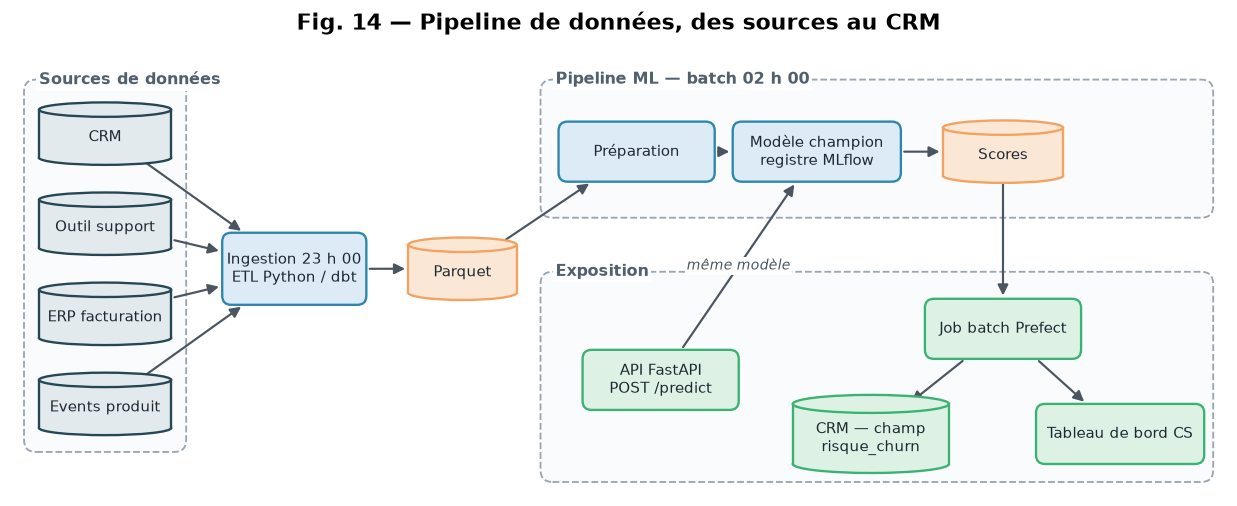

In [122]:
from IPython.display import Markdown, display

from churn_saas import config, schemas, viz
from churn_saas.format_fr import nombre, pourcentage

_ = viz.sauvegarder(schemas.schema_pipeline_donnees())

**Ce qu'il faut retenir.** Le batch (traitement par lot) de scoring (calcul des scores) part à
02 h 00 (§10) pour que les alertes soient dans le CRM avant 06 h 00 (§2). L'API sert le
**même** modèle champion : les vues batch et temps réel ne peuvent pas se contredire.

### 11.2 Architecture cible — scénario B retenu

Qui parle à qui en production : chaque cadre est une zone de responsabilité distincte.

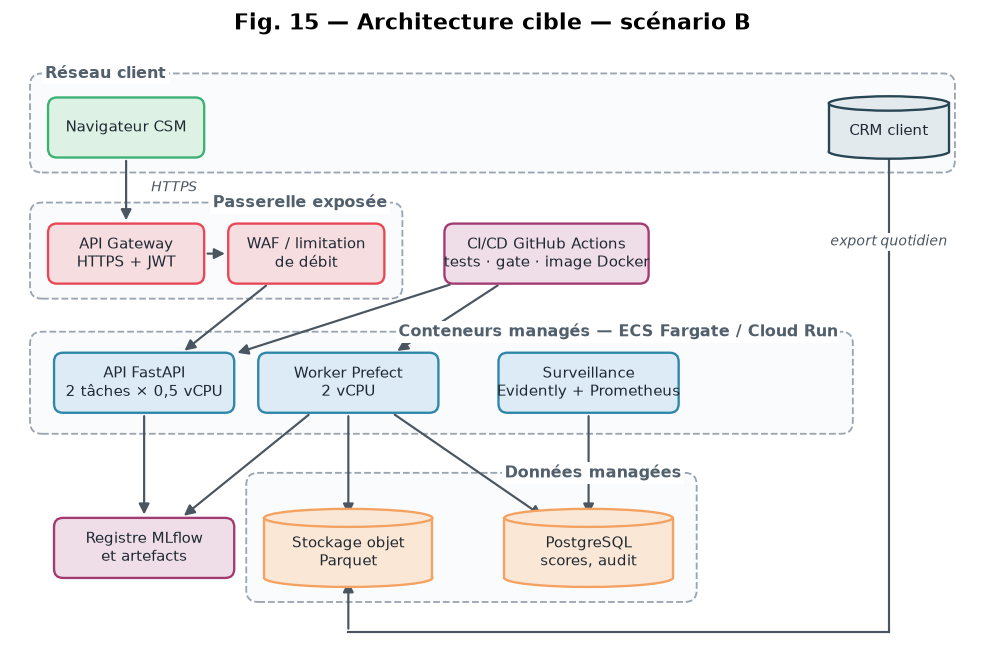

In [123]:
_ = viz.sauvegarder(schemas.schema_architecture_cible())

**Ce qu'il faut retenir.** Passerelle exposée, calcul conteneurisé sans serveur à administrer,
données managées et registre (registry) de modèles alimenté **uniquement** par la CI/CD. Aucune
brique ne demande Kubernetes et chacune a un équivalent standard ailleurs (Docker, Parquet,
PostgreSQL) : c'est la réversibilité exigée par le RSSI.

### 11.3 Diagramme de séquence — score à la demande (CSM → API → CRM)

Cas d'usage 3 du §2 : un CSM ouvre une fiche compte ; le CRM interroge l'API et affiche le
score pendant le chargement de la fiche.

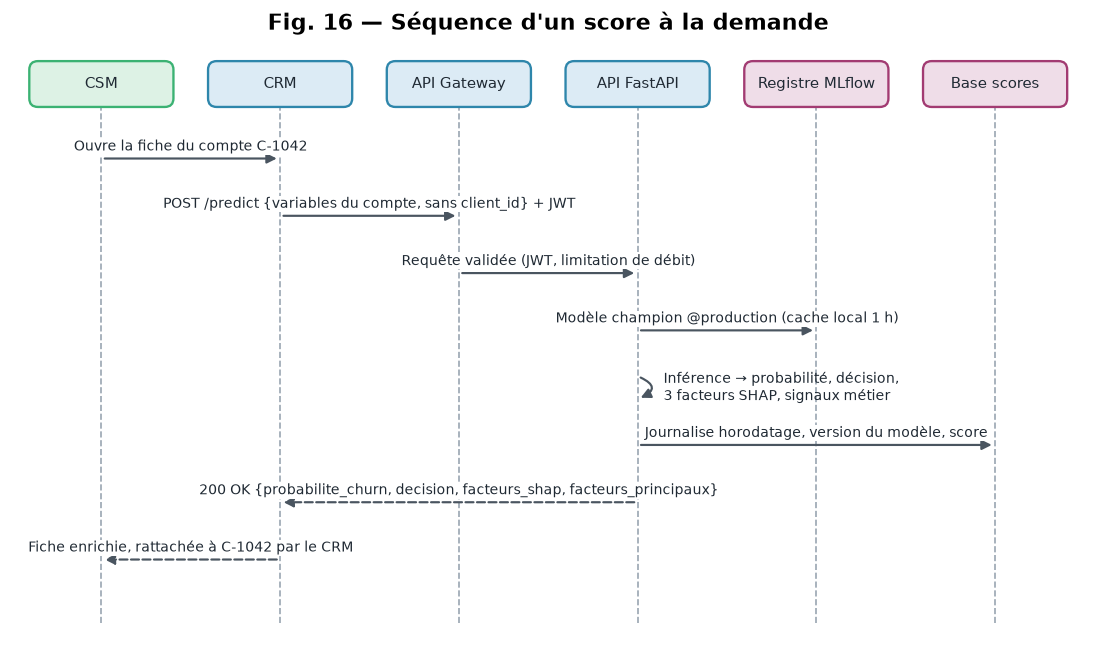

In [124]:
_ = viz.sauvegarder(schemas.schema_sequence_score())

**Ce qu'il faut retenir.** L'inférence pèse peu dans le budget de 200 ms (mesure au §9.13,
rappelée au §12.3) ; l'explication SHAP réutilise le même passage du prétraitement. Le budget
va surtout au réseau et à la persistance. Le `client_id` ne quitte jamais le CRM (§10.8). La
cible fait **évoluer par ajout** l'API du §10 (même route, même contrat d'entrée) :

| Élément | API livrée (§10) | Architecture cible |
|---|---|---|
| Authentification | Clé `X-API-Key`, 60 requêtes/min par IP | JWT validé par l'API Gateway |
| Raisons du score | 3 variables SHAP exactes (`facteurs_shap`) et 3 signaux métier issus de l'EDA (§6) | Inchangé |
| Explication détaillée | Absente (3 raisons du risque seulement) | `POST /explain` : toutes les variables, facteurs protecteurs compris |
| Journal d'audit | Absent (l'API ne persiste rien) | Chaque appel journalisé dans PostgreSQL, 12 mois |

### 11.4 Compte-rendu d'entretien avec les acteurs

*Trace reconstituée à partir des contraintes typiques d'un éditeur SaaS B2B français de taille
intermédiaire ; elle est à remplacer par le compte-rendu archivé des entretiens.*

| Acteur | Contraintes remontées | Conséquence sur l'architecture |
|---|---|---|
| **DSI** | Budget pilote ≤ 600 €/mois.<br>Équipe ops sans compétence Kubernetes.<br>API REST standard, sans SDK propriétaire.<br>Disponibilité ≥ 99,5 % de 06 h à 20 h. | Services entièrement managés (ECS Fargate ou Cloud Run).<br>Scénario A écarté (pas de haute disponibilité), scénario C écarté (budget, dépendance fournisseur). |
| **RSSI** | Hébergement UE, fournisseur certifié ISO 27001.<br>Chiffrement en transit (TLS 1.2+) et au repos (AES-256).<br>Journalisation des appels conservée 12 mois. | Région Paris imposée (`eu-west-3` ou `europe-west9`), jamais la région par défaut d'un SDK.<br>Une région UE fixe le lieu, pas le droit applicable : un fournisseur américain reste soumis au Cloud Act. Accepté pour des indicateurs d'entreprise (R10, §4) ; un cloud qualifié SecNumCloud s'imposerait si des données personnelles entraient dans le périmètre.<br>WAF obligatoire, journal d'audit en base exporté vers le SIEM. |
| **DPO** | Scoring de personnes morales : article 22 du RGPD hors champ (§4), mais les contacts CRM restent des données personnelles.<br>Minimisation ; conservation des scores 24 mois (§4.1). | Base scores limitée à `client_id`, sans nom ni e-mail.<br>Purge hebdomadaire des scores de plus de 24 mois.<br>Explication de chaque score maintenue **par choix de gouvernance** (humain dans la boucle, §4). |
| **Responsable Customer Success** | Score visible dans Salesforce, avec 3 signaux explicatifs.<br>Alertes disponibles avant 06 h 00.<br>Indicateur d'incertitude pour les comptes de moins de 3 mois. | Champ Salesforce alimenté par le batch et par `POST /predict` à l'ouverture de la fiche.<br>Batch à 02 h 00 (§10).<br>Champ `incertitude_score` prévu en cible. |

La **généralisation** est la capacité du système à fonctionner au-delà du pilote (5 000
comptes, un produit, un data scientist à mi-temps). Les entretiens en ont fixé les limites :

| Axe | Contrainte | Réponse architecturale |
|---|---|---|
| Volume (5 k → 50 k comptes) | Monter en charge sans refonte | Mise à l'échelle automatique des conteneurs ; scénario C réévalué au-delà de 50 k (§11.7) |
| Portabilité | Pas de dépendance à un fournisseur | Images Docker, Parquet et PostgreSQL standards |
| Réplicabilité (autres produits) | Séparer configuration et code | Un `config.py` par produit, pipeline réutilisé tel quel |
| Robustesse temporelle | Détecter la dérive avant la dégradation | PSI hebdomadaire et SLO de qualité par cohorte (§11.8, §13.8) |
| Compétences | Pas de spécialiste MLOps | Services managés et runbook d'incident (`docs/RUNBOOK.md`) |

**Ce qu'il faut retenir.** Les quatre acteurs convergent vers le même scénario : conteneurs
managés, région Paris, intégration native dans Salesforce. L'explication de chaque score reste
un choix de gouvernance, mis en œuvre au §12.8.

### 11.5 Contraintes techniques, réglementaires et organisationnelles

En résumé, chaque contrainte devient une décision vérifiable. **Techniques** : p95 < 200 ms
(pipeline en mémoire, cache d'une heure), alertes avant 06 h 00 (batch à 02 h 00, alerte à
04 h 00), reproductibilité (`config.RANDOM_SEED`, DVC, MLflow). **Réglementaires** : région
Paris explicite, base scores réduite au `client_id`, purge à 24 mois, journaux 12 mois.
**Organisationnelles** : orchestration managée et budget ≤ 600 €/mois, qui départage les
trois scénarios ci-dessous.

### 11.6 Trois scénarios comparatifs

| Critère | A — VM unique + cron | **B — Conteneurs managés ★** | C — Plateforme ML managée |
|---|---|---|---|
| Description | Une VM Linux, scoring par cron, API simple | ECS Fargate ou Cloud Run, PostgreSQL managé, MLflow, CI/CD GitHub Actions | SageMaker, Vertex AI ou Azure ML : inférence, registre et A/B test intégrés |
| Coût mensuel (pilote 5 k comptes) | 30 – 60 € | **90 – 110 €** | 800 – 2 500 € |
| Compétences requises | Linux, Python, cron | Docker, cloud de base, CI/CD | SDK propriétaire du fournisseur |
| Hébergement UE | Oui | Oui, région Paris imposée | Partiel : services annexes hors UE par défaut |
| Haute disponibilité, retour arrière du modèle | ❌ | ✅ | ✅ |
| Réversibilité | Maximale | Haute (Docker, Parquet) | Faible (pipelines propriétaires) |
| Limite critique | Point unique de défaillance, inadapté au-delà de 20 k comptes | MLflow à maintenir (2 – 4 h/mois) | Budget au moins 7 fois celui de B, dépendance fournisseur |

**Ce qu'il faut retenir.** A suffit pour une preuve de concept, pas pour la production ; C
dépasse le budget et crée la dépendance que refuse le RSSI. **B** apporte haute disponibilité,
retour arrière du modèle et CI/CD pour quelques dizaines d'euros de plus que A.

### 11.7 Recommandation argumentée

**Scénario retenu : B**, seul à respecter budget, compétences, hébergement UE et réversibilité
tout en offrant haute disponibilité et gate (règle de promotion) automatisée.

**Coûts du scénario B** (AWS `eu-west-3`, pilote 5 000 comptes, tarifs publics 2025) :

| Poste | Coût mensuel estimé |
|---|---|
| Calcul — API 24 h/24 (≈ 30 €) et batch de moins de 5 min par nuit (≈ 1 €) | ≈ 31 € |
| PostgreSQL managé (≈ 25 €), stockage objet (≈ 10 €), MLflow (5 – 15 €) | ≈ 40 – 50 € |
| API Gateway, WAF et journaux | ≈ 20 – 30 € |
| **Total** (CI/CD incluse dans l'offre gratuite de GitHub Actions) | **≈ 90 – 110 €** |

À 20 k comptes avec redondance multi-zones, prévoir 300 – 450 €/mois ; une réservation d'un an
réduit la facture de calcul de 30 à 40 %. Ces montants sont à confirmer par un devis.
**Trajectoire** : local (`Makefile`) → ECS Fargate à T+2 mois → Evidently et test champion /
challenger à T+6 mois → scénario C réévalué à T+12 mois au-delà de 50 k comptes.

> 📧 **Arbitrage — comité du 22 septembre 2026 (DSI, direction générale, RSSI).** Scénario B
> validé ; ~100 €/mois, faible face au gain de la cohorte mensuelle (§12.12). Le RSSI ajoute
> 15 – 20 €/mois (chiffrement au repos, journaux 12 mois). *Trace reconstituée.*

### 11.8 SLO / SLI et procédures de remédiation

On veut savoir chaque jour si le service tient ses promesses. Un **SLO** (objectif de niveau
de service) fixe le niveau visé ; le **SLI** (indicateur) le mesure. Les seuils du modèle
viennent de `config.CIBLES_PERFORMANCE`. Le PSI (indice de stabilité de population) mesure
l'écart de distribution d'une variable entre production et entraînement.

In [125]:
_c = config.CIBLES_PERFORMANCE
_pr_auc_min, _pr_auc_critique = nombre(_c["pr_auc_min"], 2), nombre(_c["pr_auc_critique"], 2)
_recall_min = pourcentage(_c["recall_vigilance_min"], 0)

display(Markdown(f"""
| SLI | SLO | Alerte | Critique | Remédiation |
|---|---|---|---|---|
| **Fraîcheur des scores** | Âge ≤ 26 h | Batch du jour absent à 04 h 00 | Absent à 06 h 00 : incident P1, alertes non livrées | Logs Prefect, relance manuelle ; source indisponible → CSM prévenus |
| **Latence API p95** | < 200 ms (fenêtre 1 h) | > 150 ms | > 200 ms | Charge CPU, rechargement du cache, tâche supplémentaire |
| **Disponibilité API** | 99,5 % de 06 h à 20 h | < 99,8 % sur 1 h | < 99,0 % sur 30 min : P1 | Relance automatique ; sinon scores de la veille servis en mode dégradé |
| **Dérive (PSI)** | < 0,20 sur chaque variable | 0,10 à 0,20 : comité trimestriel | ≥ 0,20 : comité ad hoc (§2.6) | Erreur de collecte → corriger la source ; changement réel → réentraînement (§13.8) |
| **Qualité (PR-AUC)** | ≥ {_pr_auc_min} par cohorte de renouvellements (§13.7) | < {_pr_auc_min} : comité ad hoc | < {_pr_auc_critique} : comparaison au champion précédent | Retour arrière s'il fait mieux ; challenger promu seulement via la gate (§13.8) |
| **Recall au seuil de vigilance** | ≥ {_recall_min} des churners signalés (§12.6) | < {_recall_min} : comité ad hoc | — | Recalcul du seuil de vigilance sur la cohorte récente |
"""))


| SLI | SLO | Alerte | Critique | Remédiation |
|---|---|---|---|---|
| **Fraîcheur des scores** | Âge ≤ 26 h | Batch du jour absent à 04 h 00 | Absent à 06 h 00 : incident P1, alertes non livrées | Logs Prefect, relance manuelle ; source indisponible → CSM prévenus |
| **Latence API p95** | < 200 ms (fenêtre 1 h) | > 150 ms | > 200 ms | Charge CPU, rechargement du cache, tâche supplémentaire |
| **Disponibilité API** | 99,5 % de 06 h à 20 h | < 99,8 % sur 1 h | < 99,0 % sur 30 min : P1 | Relance automatique ; sinon scores de la veille servis en mode dégradé |
| **Dérive (PSI)** | < 0,20 sur chaque variable | 0,10 à 0,20 : comité trimestriel | ≥ 0,20 : comité ad hoc (§2.6) | Erreur de collecte → corriger la source ; changement réel → réentraînement (§13.8) |
| **Qualité (PR-AUC)** | ≥ 0,65 par cohorte de renouvellements (§13.7) | < 0,65 : comité ad hoc | < 0,60 : comparaison au champion précédent | Retour arrière s'il fait mieux ; challenger promu seulement via la gate (§13.8) |
| **Recall au seuil de vigilance** | ≥ 75 % des churners signalés (§12.6) | < 75 % : comité ad hoc | — | Recalcul du seuil de vigilance sur la cohorte récente |


**Ce qu'il faut retenir.** Six indicateurs couvrent l'infrastructure et le modèle, chacun avec
une remédiation graduée pour ne jamais décider en silence en mode dégradé. Le recall (rappel)
au seuil de vigilance surveille directement les faux négatifs que la règle à deux niveaux veut
minimiser. Un signal sur le modèle convoque un comité plutôt qu'un réentraînement seul (§2.6,
table d'actions du §12.15).

### 11.9 Acteurs impliqués dans le fonctionnement continu (run)

| Acteur | Rôle | Interface | Formation |
|---|---|---|---|
| CSM | Consulte les scores, mène les actions de rétention | Salesforce, tableau de bord | 1 h : lire le score et ses 3 facteurs |
| Responsable CS | Valide les seuils, participe au comité trimestriel | Liste priorisée, KPI métier | 2 h : arbitrage des seuils |
| Équipe Data / ML | Maintient le pipeline, surveille les SLI, déploie via la CI/CD | MLflow, Prefect, Evidently | Aucune |
| Ops / SRE | Infrastructure, correctifs, incidents P1 | Console cloud, `docs/RUNBOOK.md` | 2 h : runbook |
| DPO | Registre des traitements, audit de la purge | Journaux d'audit, rapport de purge | 1 h |
| RSSI | Conformité sécurité, revue annuelle | SIEM, scan des images Docker (à ajouter à la CI) | Aucune |

**Ce qu'il faut retenir.** Seule l'équipe Data / ML touche au pipeline ; les autres acteurs
lisent, sans compétence ML requise : c'est le principe du moindre privilège.

> ### 📋 Journal de bord — Architecture cible
>
> **Décisions retenues** — Scénario B (conteneurs managés, région Paris, ≈ 90 – 110 €/mois) ;
> six SLO gradués, dont le recall au seuil de vigilance ; écarts API livrée / cible au §11.3.
>
> **Alternatives écartées** — Scénario A : point unique de défaillance, pas de retour arrière.
> Scénario C : au moins 800 €/mois et dépendance fournisseur contraire à la réversibilité.
>
> **Difficultés rencontrées** — Chiffrage sur tarifs publics, non devisé ; entretiens
> reconstitués. L'API livrée reste en deçà de la cible : ni authentification JWT, ni route
> `/explain`, ni journal d'audit (§11.3).
>
> **Impact sur la suite** — Les SLO (alertes avant 06 h 00, p95 < 200 ms, PR-AUC et recall
> minimaux) alimentent le monitoring (surveillance) et le plan de réentraînement du §13.

## 12. Mesure de performance et impacts

On veut savoir si le modèle tient ses promesses, et ce qu'il rapporte. Cette section mesure sa
qualité technique (classement, calibration, latence), en tire une **règle de décision à deux
niveaux** (surveiller large pour manquer peu de partants, appeler là où un geste rapporte le
plus), explique ses prédictions, puis chiffre son impact en euros et ses limites. Toutes les
mesures sont confrontées aux cibles fixées *a priori* en §8.

In [126]:
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from IPython.display import Markdown, display
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, log_loss
from sklearn.model_selection import StratifiedKFold, cross_val_predict

from churn_saas import config, economie, viz
from churn_saas.cache import charger, charger_ou_calculer
from churn_saas.features.build import ajouter_features_metier
from churn_saas.format_fr import entier, euros, nombre, pourcentage, styler_fr
from churn_saas.fuite import cribler_leurres
from churn_saas.models import economics
from churn_saas.models import evaluate as eval_mod
from churn_saas.models import explain as xpl
from churn_saas.models import regression as reg

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)


def _ok(condition: bool) -> str:
    return "✅" if condition else "❌"


def _liste(colonnes: list[str]) -> str:
    return ", ".join(f"`{c}`" for c in colonnes)

### 12.1 Chargement des artefacts et jeu d'évaluation

Le modèle final a été entraîné sur **toutes** les données (§9.15) : le noter sur ces mêmes
données le flatterait (overfitting, surapprentissage). On le juge donc sur des prédictions
**out-of-fold** (hors pli) : chaque compte est prédit par une copie du modèle entraînée sans
lui (`cross_val_predict`, 5 plis). Elles couvrent tout le portefeuille, ce qu'exigent le bilan
en euros et l'explicabilité. La note de référence reste celle du **jeu de test** (§9.14) :
20 % des comptes, mis de côté avant tout choix, notés une seule fois. On confronte les deux :
la validation croisée de §9 a servi à choisir, ces prédictions servent à analyser, le test
seul juge.

In [127]:
gold = pd.read_parquet(config.DONNEES_GOLD / "gold_dataset.parquet")
CIBLE = "churn"
X_brut = gold.drop(columns=config.COLONNES_INTERDITES, errors="ignore")
y = gold[CIBLE].astype(int)
X = ajouter_features_metier(X_brut).drop(columns=[CIBLE], errors="ignore")
mrr_brut = pd.to_numeric(gold["revenu_mensuel_recurrent_eur"], errors="coerce")
# Bilan économique sur tout le portefeuille : MRR manquant imputé par la médiane. Le batch de
# production, lui, n'impute pas (`mrr_disponible`, §10) ; l'écart est contrôlé en §12.6
_mrr_manquant = mrr_brut.isna().to_numpy()
MRR = mrr_brut.fillna(float(mrr_brut.median()))

modele_final = joblib.load(config.TABLES / "modele_final.joblib")
_classe_finale = type(modele_final[-1]).__name__
# §9 choisit la famille par calcul ; cette section en interprète une : correction d'intercept
# (§12.2.3), coefficients (§12.8.1), LinearExplainer (§12.8.3). Si un réentraînement retenait
# une autre famille, on s'arrête plutôt que d'afficher une interprétation fausse.
assert _classe_finale == "RegressionLogistiqueRecalibree", f"adapter §12 : {_classe_finale}"
nom_modele_final = "Régression logistique (recalibrée)"
_CV_EVAL = StratifiedKFold(n_splits=5, shuffle=True, random_state=config.RANDOM_SEED)


def _calcul_probas_oof() -> np.ndarray:
    return cross_val_predict(
        clone(modele_final), X, y, cv=_CV_EVAL, method="predict_proba", n_jobs=-1
    )[:, 1]


proba_oof = np.asarray(charger_ou_calculer("probas_oof.joblib", _calcul_probas_oof)[0])
# Note du jeu de test, écrite par §9.14 : un modèle appris sur le seul jeu de développement
evaluation_test = charger("evaluation_test.json")
_test = evaluation_test["test"]
display(Markdown(f"""
**Ce qu'il faut retenir.** {entier(len(proba_oof))} comptes × {X.shape[1]} variables, prévalence
du churn **{pourcentage(y.mean(), 1)}** ({entier(y.sum())} partants), modèle final
`{_classe_finale}` retenu par calcul en §9. Le MRR manque pour {entier(_mrr_manquant.sum())}
comptes, imputé par la médiane ({euros(float(mrr_brut.median()))}/mois) dans le seul bilan
économique.
"""))


**Ce qu'il faut retenir.** 5 000 comptes × 52 variables, prévalence
du churn **28,0 %** (1 400 partants), modèle final
`RegressionLogistiqueRecalibree` retenu par calcul en §9. Le MRR manque pour 150
comptes, imputé par la médiane (682 €/mois) dans le seul bilan
économique.


### 12.2 Métriques techniques de classification

Trois questions : le modèle **classe**-t-il bien les comptes (ROC-AUC) ? Sa liste de comptes
signalés est-elle **fiable** malgré la rareté des partants (PR-AUC) ? Ses probabilités
disent-elles **vrai** (calibration) ? Les métriques à seuil (recall, precision) sont traitées
avec la règle de décision (§12.6).

#### 12.2.1 Courbe ROC et AUC

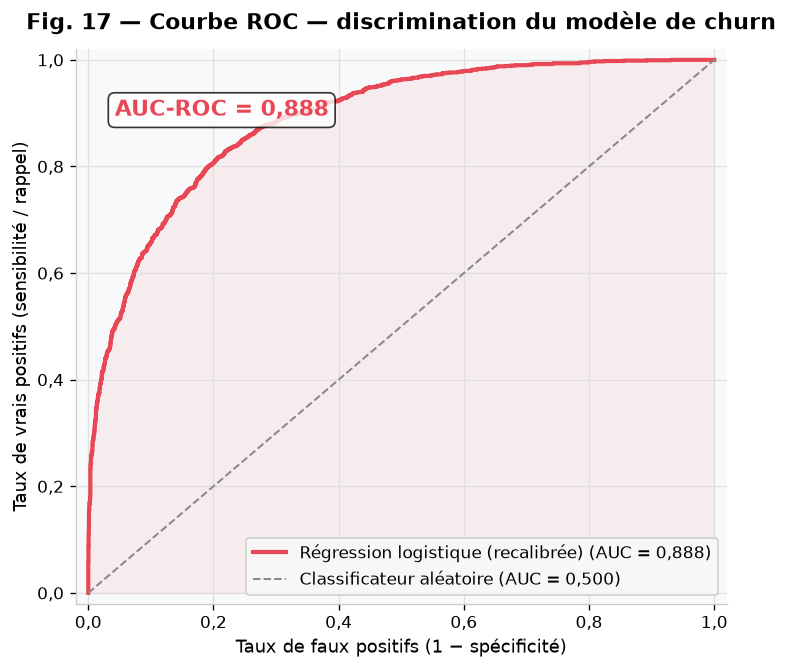


**Ce qu'il faut retenir.** ROC-AUC = **0,888** : un partant tiré au hasard reçoit
un score plus élevé qu'un fidèle tiré au hasard dans 89 % des cas (50 % pour
un tirage au sort, la diagonale). Limite : l'axe horizontal rapporte les fausses alertes aux
3 600 fidèles, 2,6 fois plus
nombreux que les partants : un faible taux de faux positifs peut encore faire beaucoup d'appels
inutiles.


In [128]:
fig_roc, auc_roc = eval_mod.courbe_roc(y, proba_oof, nom_modele=nom_modele_final)
plt.show()
display(Markdown(f"""
**Ce qu'il faut retenir.** ROC-AUC = **{nombre(auc_roc, 3)}** : un partant tiré au hasard reçoit
un score plus élevé qu'un fidèle tiré au hasard dans {pourcentage(auc_roc, 0)} des cas (50 % pour
un tirage au sort, la diagonale). Limite : l'axe horizontal rapporte les fausses alertes aux
{entier(int((y == 0).sum()))} fidèles, {nombre(float((y == 0).sum() / y.sum()), 1)} fois plus
nombreux que les partants : un faible taux de faux positifs peut encore faire beaucoup d'appels
inutiles.
"""))

#### 12.2.2 Courbe précision-rappel et PR-AUC (métrique de sélection)

Quand les partants sont rares (class imbalance, déséquilibre de classes), on regarde la liste
signalée : quelle part sont de vrais partants (precision, précision), quelle part des partants
elle contient (recall, rappel). La PR-AUC résume ce compromis sur tous les seuils.

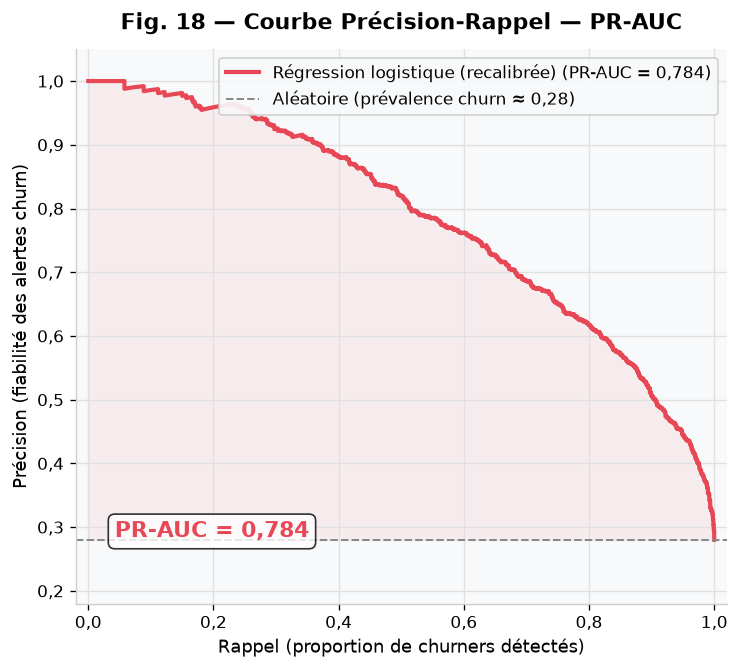


**Ce qu'il faut retenir.** PR-AUC = **0,784**, contre 0,28
pour un tirage au hasard (la prévalence, ligne horizontale) : le modèle multiplie par
2,8 la qualité de la liste. C'est la métrique de sélection du
§9, car elle pénalise à la fois fausses alertes et partants manqués.


In [129]:
fig_pr, pr_auc = eval_mod.courbe_precision_rappel(y, proba_oof, nom_modele=nom_modele_final)
plt.show()
display(Markdown(f"""
**Ce qu'il faut retenir.** PR-AUC = **{nombre(pr_auc, 3)}**, contre {nombre(float(y.mean()), 2)}
pour un tirage au hasard (la prévalence, ligne horizontale) : le modèle multiplie par
{nombre(pr_auc / float(y.mean()), 1)} la qualité de la liste. C'est la métrique de sélection du
§9, car elle pénalise à la fois fausses alertes et partants manqués.
"""))

#### 12.2.3 Calibration probabiliste (score de Brier)

Une probabilité de 30 % doit correspondre à 30 % de partants observés, car la valeur attendue
d'un geste (§12.6) et la valeur à risque (§12.11) multiplient des probabilités par des euros.
Le modèle est pondéré (`class_weight='balanced'`), ce qui gonfle ses probabilités ; son
intercept (constante) est corrigé de ce décalage (§9.6). On mesure l'effet de la correction
en recalculant les prédictions hors pli du **même** modèle sans elle.

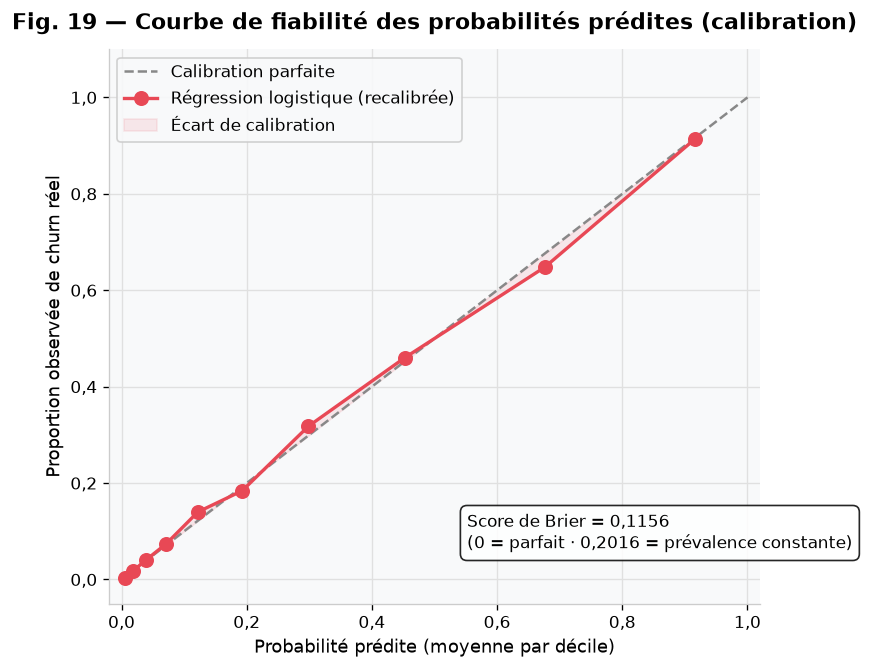


**Ce qu'il faut retenir.** Sans correction, le modèle annonce en moyenne
39,6 % de risque pour 28,0 % de partants réels : toute valeur
en euros serait surestimée de 42 %. Corrigé, il retrouve la
prévalence (27,9 %) ; son score de Brier passe de
0,1351 à **0,1156** et sa log loss (pénalité des
probabilités trop sûres d'elles) de 0,4159 à
0,3629. La bonne référence n'est pas 0,25 mais un modèle qui
annoncerait toujours la prévalence, p(1 − p) = 0,2016 : le modèle fait
43 % mieux. La PR-AUC varie de
+0,0000 : la correction déplace les probabilités sans changer
l'ordre des comptes. Limite : elle suppose une prévalence stable en production, d'où le suivi de
la probabilité moyenne prédite face au churn observé (§12.15).


In [130]:
fig_cal, brier = eval_mod.courbe_calibration(y, proba_oof, nom_modele=nom_modele_final)
plt.show()


def _calcul_probas_oof_non_corrigees() -> np.ndarray:
    # Même pipeline et mêmes hyperparamètres, sans la correction d'intercept
    modele_non_corrige = clone(modele_final)
    nom_etape, estimateur = modele_non_corrige.steps[-1]
    modele_non_corrige.steps[-1] = (nom_etape, LogisticRegression(**estimateur.get_params()))
    return cross_val_predict(
        modele_non_corrige, X, y, cv=_CV_EVAL, method="predict_proba", n_jobs=-1
    )[:, 1]


_brut, _ = charger_ou_calculer("probas_oof_non_corrigees.joblib", _calcul_probas_oof_non_corrigees)
_moy_brute = float(np.mean(_brut))
_brier_constant = float(y.mean() * (1 - y.mean()))
_ecart_pr_auc = average_precision_score(y, proba_oof) - average_precision_score(y, _brut)
display(Markdown(f"""
**Ce qu'il faut retenir.** Sans correction, le modèle annonce en moyenne
{pourcentage(_moy_brute)} de risque pour {pourcentage(y.mean())} de partants réels : toute valeur
en euros serait surestimée de {pourcentage(_moy_brute / y.mean() - 1, 0)}. Corrigé, il retrouve la
prévalence ({pourcentage(proba_oof.mean())}) ; son score de Brier passe de
{nombre(brier_score_loss(y, _brut), 4)} à **{nombre(brier, 4)}** et sa log loss (pénalité des
probabilités trop sûres d'elles) de {nombre(log_loss(y, _brut), 4)} à
{nombre(log_loss(y, proba_oof), 4)}. La bonne référence n'est pas 0,25 mais un modèle qui
annoncerait toujours la prévalence, p(1 − p) = {nombre(_brier_constant, 4)} : le modèle fait
{pourcentage(1 - brier / _brier_constant, 0)} mieux. La PR-AUC varie de
{nombre(_ecart_pr_auc, 4, signe=True)} : la correction déplace les probabilités sans changer
l'ordre des comptes. Limite : elle suppose une prévalence stable en production, d'où le suivi de
la probabilité moyenne prédite face au churn observé (§12.15).
"""))

#### 12.2.4 Confrontation aux cibles fixées a priori

Les cibles de §8 ont été posées avant tout résultat (`config.CIBLES_PERFORMANCE`). Le statut se
lit sur le **test** (§9.14), seule mesure sur des comptes qu'aucun choix n'a vus ; la colonne hors
pli montre l'écart. Le recall au seuil de vigilance est confronté à sa cible en §12.6.

In [131]:
_c = config.CIBLES_PERFORMANCE
_atteintes = [
    _test["pr_auc"]["valeur"] >= _c["pr_auc_min"],
    _test["roc_auc"]["valeur"] >= _c["roc_auc_min"],
    _test["brier"]["valeur"] < _brier_constant,
]


def _test_ic(cle: str, decimales: int = 3) -> str:
    t = _test[cle]
    return (
        f"**{nombre(t['valeur'], decimales)}** [{nombre(t['ic_bas'], decimales)} ; "
        f"{nombre(t['ic_haut'], decimales)}]"
    )


_ecart_pr_test = _test["pr_auc"]["valeur"] - pr_auc
display(Markdown(f"""
| Métrique | Hors pli ({entier(len(y))} comptes) | Test (§9.14) [IC 95 %] | Cible ou référence | Statut (test) |
|---|---|---|---|---|
| PR-AUC (sélection) | {nombre(pr_auc, 3)} | {_test_ic('pr_auc')} | ≥ {nombre(_c['pr_auc_min'], 2)} | {_ok(_atteintes[0])} |
| ROC-AUC (co-principale) | {nombre(auc_roc, 3)} | {_test_ic('roc_auc')} | ≥ {nombre(_c['roc_auc_min'], 2)} | {_ok(_atteintes[1])} |
| Score de Brier (calibration) | {nombre(brier, 4)} | {_test_ic('brier', 4)} | < {nombre(_brier_constant, 4)} (modèle constant) | {_ok(_atteintes[2])} |

**Ce qu'il faut retenir.** {sum(_atteintes)} critère(s) sur 3 atteint(s) sur le test. La PR-AUC
du test s'écarte de {nombre(_ecart_pr_test, 3, signe=True)} de la mesure hors pli
{"et reste dans le même intervalle de confiance : la mesure hors pli, utilisée pour les euros, n'est pas sensiblement optimiste" if _test["pr_auc"]["ic_bas"] <= pr_auc <= _test["pr_auc"]["ic_haut"] else "et sort de l'intervalle de confiance du test : les euros calculés hors pli sont à lire comme une borne haute"}.
Le modèle classe bien et ses probabilités sont exploitables en euros ; reste à transformer un
score en décision (§12.4 à §12.6).
"""))
# Tableau standard des métriques au seuil de rentabilité (§12.5), réutilisé par le §13
courbe_gain, seuil_opt = economics.gain_par_seuil(y, proba_oof, MRR)
df_metriques = eval_mod.tableau_metriques(y, proba_oof, seuil_opt)


| Métrique | Hors pli (5 000 comptes) | Test (§9.14) [IC 95 %] | Cible ou référence | Statut (test) |
|---|---|---|---|---|
| PR-AUC (sélection) | 0,784 | **0,760** [0,710 ; 0,804] | ≥ 0,65 | ✅ |
| ROC-AUC (co-principale) | 0,888 | **0,881** [0,857 ; 0,903] | ≥ 0,80 | ✅ |
| Score de Brier (calibration) | 0,1156 | **0,1215** [0,1087 ; 0,1339] | < 0,2016 (modèle constant) | ✅ |

**Ce qu'il faut retenir.** 3 critère(s) sur 3 atteint(s) sur le test. La PR-AUC
du test s'écarte de -0,025 de la mesure hors pli
et reste dans le même intervalle de confiance : la mesure hors pli, utilisée pour les euros, n'est pas sensiblement optimiste.
Le modèle classe bien et ses probabilités sont exploitables en euros ; reste à transformer un
score en décision (§12.4 à §12.6).


### 12.3 Latence d'inférence — rappel de la mesure du §9.13

La latence a été mesurée une seule fois, au §9.13, sur la même configuration : on relit son
résultat (`reports/tables/latence_modele_final.json`) sans relancer la mesure.

In [132]:
rapport_latence = charger("latence_modele_final.json")
_lat_p95, _lat_batch = (
    rapport_latence["latence_unitaire_ms_p95"],
    rapport_latence["latence_batch_5k_s"],
)
_cible_unit, _cible_batch = _c["latence_unitaire_ms"], _c["latence_batch_5k_s"]
display(Markdown(f"""
**Ce qu'il faut retenir.** p95 unitaire **{nombre(_lat_p95, 1)} ms** (cible ≤ {_cible_unit} ms,
{_ok(_lat_p95 <= _cible_unit)}) ; batch (traitement par lot) de
{entier(rapport_latence['n_batch'])} comptes en **{nombre(_lat_batch, 1)} s** (cible ≤
{_cible_batch} s, {_ok(_lat_batch <= _cible_batch)}). L'inférence d'une régression logistique se
réduit au prétraitement et à un produit scalaire : le budget de l'API est surtout consommé par le
réseau et la persistance (§11.3).
"""))


**Ce qu'il faut retenir.** p95 unitaire **32,6 ms** (cible ≤ 200 ms,
✅) ; batch (traitement par lot) de
5 000 comptes en **0,1 s** (cible ≤
300 s, ✅). L'inférence d'une régression logistique se
réduit au prétraitement et à un produit scalaire : le budget de l'API est surtout consommé par le
réseau et la persistance (§11.3).


### 12.4 Matrice de coûts et hypothèses économiques

Pour passer d'un score à une décision, il faut savoir ce que coûte chaque erreur. Tous les
gains sont mesurés **par rapport à « ne rien faire »** (ne contacter personne vaut 0 €).

In [133]:
mat = economics.matrice_couts()
_hyp = config.HYPOTHESES_ECONOMIQUES
_cap = int(_hyp["capacite_gestes_mois"])
_marge, _horizon = pourcentage(_hyp["marge_brute_pct"], 0), _hyp["horizon_mois"]
_ts_ref = float(_hyp["taux_succes_retention"])
_mrr_median = float(MRR.median())
_sauvetage_median = _mrr_median * _horizon * _hyp["marge_brute_pct"] * _ts_ref
display(Markdown(f"""
| Paramètre | Valeur | Source |
|---|---|---|
| Marge brute | {_marge} | OpenView Partners SaaS Benchmarks 2023 |
| Coût d'un geste CSM | {euros(mat['cout_intervention_eur'])} | {euros(_hyp['cout_horaire_csm_eur'])}/h × {entier(_hyp['duree_geste_retention_h'])} h |
| Taux de succès d'un geste | {pourcentage(_ts_ref, 0)} | Gainsight 2023 Customer Success Industry Report |
| Horizon | {_horizon} mois | Durée contractuelle typique |
| Capacité CS | {_cap} gestes/mois | Cadrage : 3 CSM × 15 gestes (~20 % de leur temps, §2.3) |

| Issue | Valeur par rapport à « ne rien faire » |
|---|---|
| **VP** — partant contacté | MRR × {_horizon} × {_marge} × {pourcentage(_ts_ref, 0)} − {euros(mat['cout_intervention_eur'])} |
| **FP** — fidèle contacté | − {euros(mat['cout_fp_eur'])} (temps CSM perdu) |
| **FN** — partant manqué | 0 € : la perte (MRR × {_horizon} × {_marge}) est subie avec ou sans modèle |
| **VN** — fidèle laissé tranquille | 0 € |

**Ce qu'il faut retenir.** Un geste devient rentable dès {euros(mat['seuil_mrr_rentable_eur'])} de
MRR mensuel. Au MRR médian ({euros(_mrr_median)}/mois), un geste sur un partant rapporte en
espérance {euros(_sauvetage_median)} pour {euros(mat['cout_intervention_eur'])} de coût, soit
**{nombre(_sauvetage_median / mat['cout_intervention_eur'], 0)} pour 1** : un partant manqué coûte
bien plus cher qu'une fausse alerte, il faut **manquer peu de partants**. Mais la vraie contrainte
est le temps des CSM ({_cap} gestes/mois) : il faut aussi choisir *qui* appeler.
"""))


| Paramètre | Valeur | Source |
|---|---|---|
| Marge brute | 72 % | OpenView Partners SaaS Benchmarks 2023 |
| Coût d'un geste CSM | 110 € | 55 €/h × 2 h |
| Taux de succès d'un geste | 30 % | Gainsight 2023 Customer Success Industry Report |
| Horizon | 12 mois | Durée contractuelle typique |
| Capacité CS | 45 gestes/mois | Cadrage : 3 CSM × 15 gestes (~20 % de leur temps, §2.3) |

| Issue | Valeur par rapport à « ne rien faire » |
|---|---|
| **VP** — partant contacté | MRR × 12 × 72 % × 30 % − 110 € |
| **FP** — fidèle contacté | − 110 € (temps CSM perdu) |
| **FN** — partant manqué | 0 € : la perte (MRR × 12 × 72 %) est subie avec ou sans modèle |
| **VN** — fidèle laissé tranquille | 0 € |

**Ce qu'il faut retenir.** Un geste devient rentable dès 42 € de
MRR mensuel. Au MRR médian (682 €/mois), un geste sur un partant rapporte en
espérance 1 768 € pour 110 € de coût, soit
**16 pour 1** : un partant manqué coûte
bien plus cher qu'une fausse alerte, il faut **manquer peu de partants**. Mais la vraie contrainte
est le temps des CSM (45 gestes/mois) : il faut aussi choisir *qui* appeler.


### 12.5 Seuil de rentabilité hors contrainte de capacité et courbe de gain

Première question : **si l'équipe n'avait pas de limite de temps**, à partir de quelle
probabilité un geste serait-il rentable ? On contacte tout compte au-dessus d'un threshold
(seuil) τ et on calcule le gain net ; τ\* maximise ce gain.

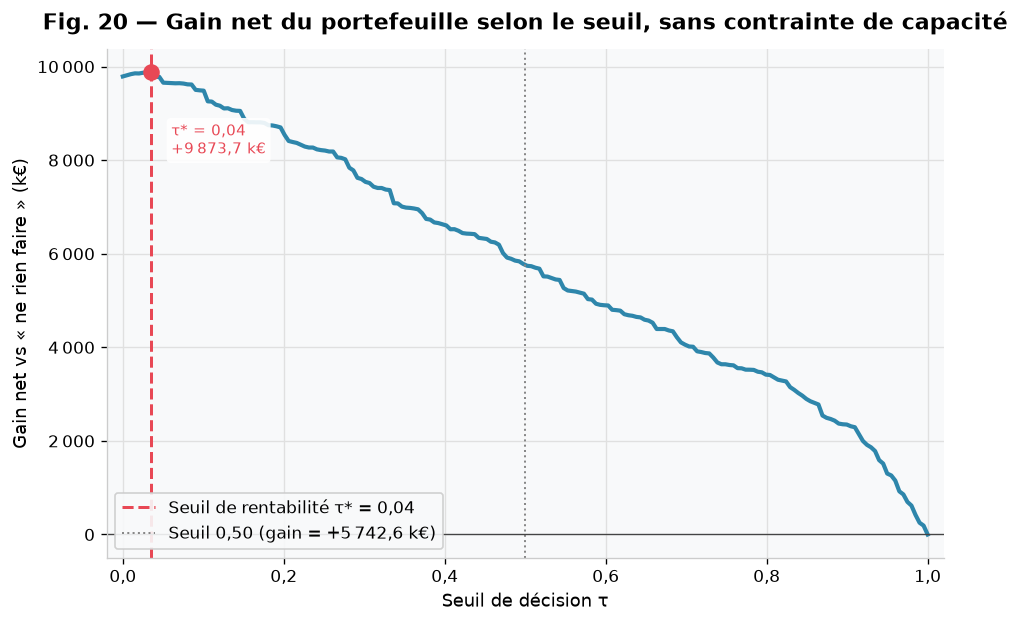


**Ce qu'il faut retenir.** τ\* = **0,04** est bas parce qu'un geste coûte peu
face à ce qu'il sauve : il faudrait contacter 3 818 comptes (precision
36 %, recall 99 %) pour un
gain de +9 873 671 €, soit
**85 fois** la capacité mensuelle. τ\* n'est donc pas une règle
applicable : c'est un argument de dimensionnement (3 059 comptes justifieraient
un geste rentable, l'équipe en traite 45).


In [134]:
fig_gain = economics.tracer_gain_par_seuil(courbe_gain, seuil_opt)
plt.show()
_opt = courbe_gain.loc[courbe_gain["gain_net_eur"].idxmax()]
valeur_attendue_oof = economie.valeur_attendue_intervention(proba_oof, MRR.to_numpy())
_n_rentables = int((valeur_attendue_oof > 0).sum())
display(Markdown(f"""
**Ce qu'il faut retenir.** τ\\* = **{nombre(seuil_opt, 2)}** est bas parce qu'un geste coûte peu
face à ce qu'il sauve : il faudrait contacter {entier(_opt['n_alertes'])} comptes (precision
{pourcentage(float(_opt['precision']), 0)}, recall {pourcentage(float(_opt['rappel']), 0)}) pour un
gain de {euros(float(_opt['gain_net_eur']), signe=True)}, soit
**{nombre(_opt['n_alertes'] / _cap, 0)} fois** la capacité mensuelle. τ\\* n'est donc pas une règle
applicable : c'est un argument de dimensionnement ({entier(_n_rentables)} comptes justifieraient
un geste rentable, l'équipe en traite {_cap}).
"""))

### 12.6 Règle de décision à deux niveaux — vigilance et priorisation sous capacité

Un seul seuil ne peut pas servir deux objectifs opposés : ne laisser filer presque aucun partant,
et ne mobiliser les CSM que là où un appel rapporte le plus. On les sépare :

1. **Vigilance** — le seuil le plus exigeant qui détecte au moins
   `config.RECALL_CIBLE_VIGILANCE` des partants hors pli (`economics.seuil_pour_recall`). Les
   comptes au-dessus passent en palier `SURVEILLANCE` (API, batch) : actions automatisées à coût
   quasi nul, fiche signalée au CSM. Ce niveau vise les **faux négatifs**.
2. **Appels** — parmi les comptes en vigilance, les `capacite` comptes de plus forte **valeur
   attendue** positive : P(churn) × MRR × horizon × marge × taux de succès − coût du geste.

Le seuil de vigilance est **appris** : fixé sur les prédictions hors pli, persisté dans
`reports/tables/seuil_vigilance.json` (réécrit dès qu'il ne correspond plus aux prédictions
courantes), relu par `economie.niveau_risque`. Deux contrôles disent s'il généralise : le
**jeu de test** (§9.14), où un seuil fixé sur le seul développement est appliqué à des comptes
jamais vus, et une mesure pli par pli (fixé sur 4 plis, mesuré sur le 5ᵉ), qui donne le bruit.

In [135]:
_vigilance_fraiche = {
    **economics.seuil_pour_recall(y, proba_oof),
    "recall_cible": float(config.RECALL_CIBLE_VIGILANCE),
}
vigilance, _ = charger_ou_calculer(
    economie.ARTEFACT_SEUIL_VIGILANCE,
    lambda: _vigilance_fraiche,
    forcer=charger(economie.ARTEFACT_SEUIL_VIGILANCE) != _vigilance_fraiche,
)
seuil_vigilance = float(vigilance["seuil"])
_recall_hors_choix = []
for _idx_choix, _idx_mesure in _CV_EVAL.split(X, y):
    _s = economics.seuil_pour_recall(y.iloc[_idx_choix], proba_oof[_idx_choix])["seuil"]
    _partants = y.iloc[_idx_mesure].to_numpy() == 1
    _recall_hors_choix.append(float((proba_oof[_idx_mesure][_partants] >= _s).mean()))
_recall_min, _recall_moyen = float(_c["recall_vigilance_min"]), float(np.mean(_recall_hors_choix))
_recall_test = float(_test["recall"]["valeur"])
display(Markdown(f"""
Seuil de vigilance **{nombre(seuil_vigilance, 3)}** : {entier(vigilance['n_signales'])} comptes
signalés ({pourcentage(vigilance['part_signalee'], 0)} du portefeuille), recall
{pourcentage(vigilance['recall'], 1)}, precision {pourcentage(vigilance['precision'], 1)},
{entier(vigilance['n_faux_negatifs'])} partants sous le seuil. **Recall sur le jeu de test**
(§9.14) : **{pourcentage(_recall_test, 1)}** [{pourcentage(_test['recall']['ic_bas'], 1)} ;
{pourcentage(_test['recall']['ic_haut'], 1)}], cible a priori ≥ {pourcentage(_recall_min, 0)} :
{_ok(_recall_test >= _recall_min)}. Recall sur le pli qui n'a pas fixé le seuil : de
{pourcentage(min(_recall_hors_choix), 1)} à {pourcentage(max(_recall_hors_choix), 1)}, moyenne
{pourcentage(_recall_moyen, 1)}.

**Ce qu'il faut retenir.** Par construction, le seuil atteint sa cible sur les données qui l'ont
fixé. Le test dit s'il la tient sur des comptes qu'aucun choix n'a vus : c'est lui qui est
confronté à la cible de §8 ; l'écart entre plis donne le bruit à attendre en production.
"""))


Seuil de vigilance **0,277** : 1 813 comptes
signalés (36 % du portefeuille), recall
80,0 %, precision 61,8 %,
280 partants sous le seuil. **Recall sur le jeu de test**
(§9.14) : **81,8 %** [77,4 % ;
86,3 %], cible a priori ≥ 75 % :
✅. Recall sur le pli qui n'a pas fixé le seuil : de
76,1 % à 85,7 %, moyenne
79,7 %.

**Ce qu'il faut retenir.** Par construction, le seuil atteint sa cible sur les données qui l'ont
fixé. Le test dit s'il la tient sur des comptes qu'aucun choix n'a vus : c'est lui qui est
confronté à la cible de §8 ; l'écart entre plis donne le bruit à attendre en production.


**Matrices de confusion aux deux seuils** — rentabilité τ\* (§12.5) et vigilance : partants
détectés (VP) ou manqués (FN), fidèles signalés à tort (FP) ou laissés tranquilles (VN).

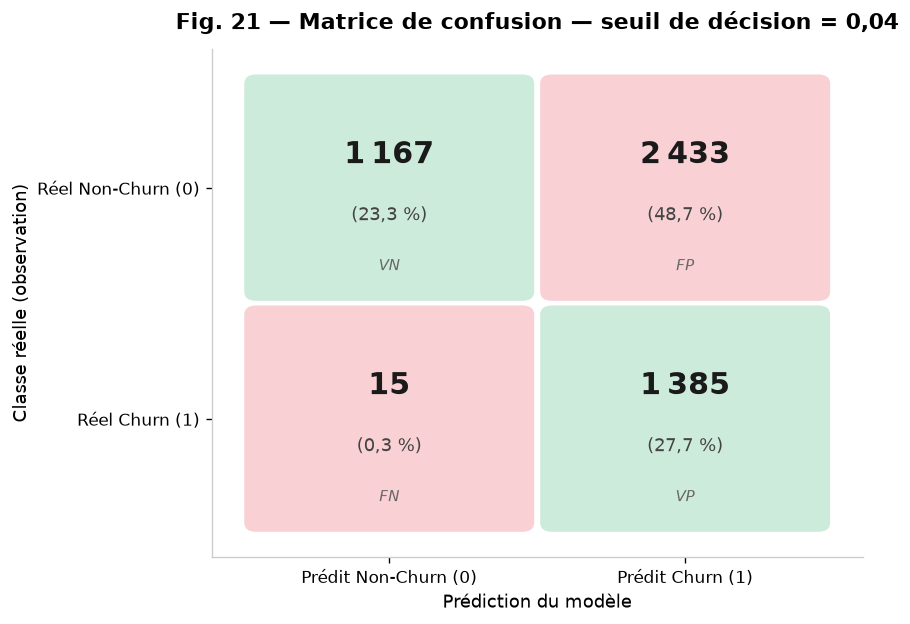

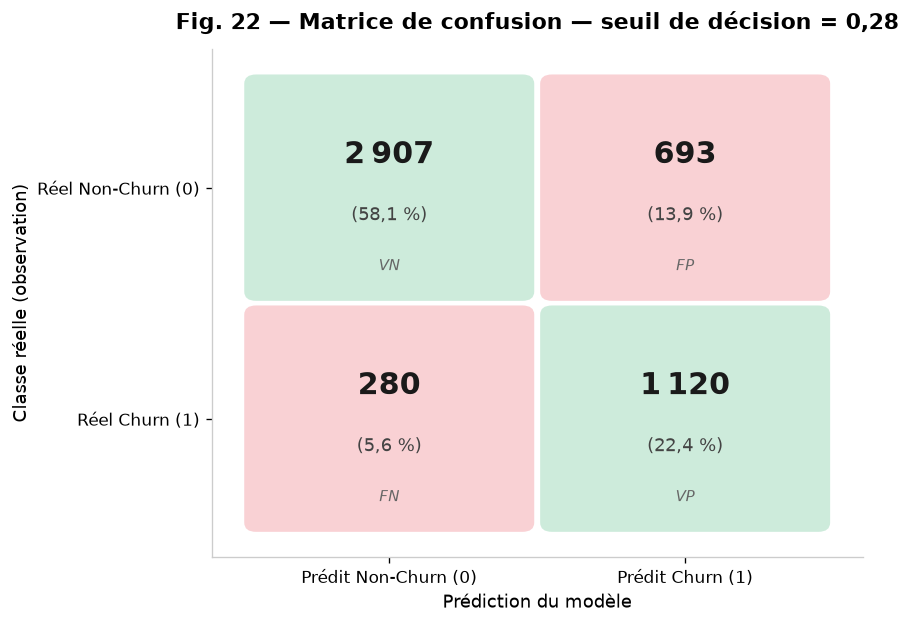


**Ce qu'il faut retenir.** Au seuil τ\* = 0,04, on ne manque que
15 partants, au prix de 2 433 fausses alertes. Le seuil de
vigilance (0,28) signale 1 813 comptes pour
280 partants manqués : 265 manqués de plus
pour 1 740 fausses alertes de moins. Le compromis est acceptable
car la vigilance ne mobilise pas de temps CSM : une fausse alerte n'y coûte presque rien, alors
qu'un partant hors vigilance ne reçoit aucune attention.


In [136]:
_matrices = {}
for _nom_seuil, _seuil in (("τ*", seuil_opt), ("vigilance", seuil_vigilance)):
    _, _cm = eval_mod.matrice_confusion(y, (proba_oof >= _seuil).astype(int), _seuil)
    plt.show()
    _matrices[_nom_seuil] = dict(zip(("VN", "FP", "FN", "VP"), _cm.ravel().tolist(), strict=True))
_m_opt, _m_vig = _matrices["τ*"], _matrices["vigilance"]
display(Markdown(f"""
**Ce qu'il faut retenir.** Au seuil τ\\* = {nombre(seuil_opt, 2)}, on ne manque que
{entier(_m_opt['FN'])} partants, au prix de {entier(_m_opt['FP'])} fausses alertes. Le seuil de
vigilance ({nombre(seuil_vigilance, 2)}) signale {entier(_m_vig['VP'] + _m_vig['FP'])} comptes pour
{entier(_m_vig['FN'])} partants manqués : {entier(_m_vig['FN'] - _m_opt['FN'])} manqués de plus
pour {entier(_m_opt['FP'] - _m_vig['FP'])} fausses alertes de moins. Le compromis est acceptable
car la vigilance ne mobilise pas de temps CSM : une fausse alerte n'y coûte presque rien, alors
qu'un partant hors vigilance ne reçoit aucune attention.
"""))

**Ordre des appels (niveau 2).** À budget de gestes identique, trois manières de remplir
l'agenda : par **probabilité**, par **valeur attendue**, et une **référence sans modèle**, les
plus gros comptes par MRR, ce que ferait une équipe sans score. C'est la bonne baseline (référence
de base) pour mesurer l'apport du modèle : « ne rien faire » le flatterait.

In [137]:
bilan_valeur = economics.gain_sous_capacite(y, proba_oof, MRR, capacite=_cap)
bilan_proba = economics.gain_sous_capacite(y, proba_oof, MRR, capacite=_cap, classement="proba")
bilan_sans_modele = economics.gain_sous_capacite(y, proba_oof, MRR, capacite=_cap, classement="mrr")
# Le batch n'impute pas le MRR : combien des comptes retenus ici ont un MRR imputé ?
_selection_valeur = economie.selection_sous_capacite(valeur_attendue_oof, _cap)
_n_imputes = int(_mrr_manquant[_selection_valeur].sum())
tableau_classements = pd.DataFrame(
    [bilan_sans_modele, bilan_proba, bilan_valeur],
    index=pd.Index(["sans modèle : plus gros MRR", "par probabilité", "par valeur attendue"]),
)[["n_contactes", "n_churners", "precision", "mrr_churners_couverts", "cout_gestes", "gain_net"]]
display(
    styler_fr(
        tableau_classements,
        {"n_contactes": entier, "n_churners": entier, "precision": pourcentage}
        | {c: euros for c in ("mrr_churners_couverts", "cout_gestes", "gain_net")},
    )
)
display(Markdown(f"""
**Ce qu'il faut retenir.** Classer par valeur attendue rapporte
**{euros(bilan_valeur['gain_net'])}** contre {euros(bilan_proba['gain_net'])} par probabilité :
moins de partants ({entier(bilan_valeur['n_churners'])} contre
{entier(bilan_proba['n_churners'])}) mais bien plus de MRR
({euros(bilan_valeur['mrr_churners_couverts'])}/mois contre
{euros(bilan_proba['mrr_churners_couverts'])}/mois), car le classement par probabilité remplit
l'agenda de petits comptes presque perdus. Sans modèle, appeler les {_cap} plus gros comptes
rapporterait déjà {euros(bilan_sans_modele['gain_net'])} : une large part du gain vient de la
taille des comptes. La part due au modèle est l'écart,
**{euros(bilan_valeur['gain_net'] - bilan_sans_modele['gain_net'], signe=True)}** par mois de
gestes (fourchette en §12.12).
{"Aucun compte retenu n'a de MRR imputé : la sélection est celle du batch." if _n_imputes == 0 else f"⚠️ {entier(_n_imputes)} comptes retenus ont un MRR imputé : le batch, qui les écarte, en sélectionnerait d'autres."}
"""))

,n_contactes,n_churners,precision,mrr_churners_couverts,cout_gestes,gain_net
sans modèle : plus gros MRR,45,12,"26,7 %",702 753 €,4 950 €,1 816 586 €
par probabilité,45,45,"100,0 %",98 993 €,4 950 €,251 640 €
par valeur attendue,45,31,"68,9 %",1 199 987 €,4 950 €,3 105 415 €



**Ce qu'il faut retenir.** Classer par valeur attendue rapporte
**3 105 415 €** contre 251 640 € par probabilité :
moins de partants (31 contre
45) mais bien plus de MRR
(1 199 987 €/mois contre
98 993 €/mois), car le classement par probabilité remplit
l'agenda de petits comptes presque perdus. Sans modèle, appeler les 45 plus gros comptes
rapporterait déjà 1 816 586 € : une large part du gain vient de la
taille des comptes. La part due au modèle est l'écart,
**+1 288 829 €** par mois de
gestes (fourchette en §12.12).
Aucun compte retenu n'a de MRR imputé : la sélection est celle du batch.


**Bilan de la règle à deux niveaux** (`economics.table_deux_niveaux`) : comptes et partants
couverts à chaque niveau, et partants restés hors du niveau (faux négatifs résiduels, valorisés
à leur perte sèche MRR × horizon × marge).

In [138]:
deux_niveaux = economics.table_deux_niveaux(y, proba_oof, MRR, capacite=_cap).set_index("niveau")
display(
    styler_fr(
        deux_niveaux.drop(columns="seuil"),
        {c: entier for c in ("n_comptes", "n_churners", "n_faux_negatifs")}
        | {c: pourcentage for c in ("part_portefeuille", "recall", "precision")}
        | {c: euros for c in ("valeur_faux_negatifs_eur", "gain_net_eur")},
    )
)
_n1, _n2 = deux_niveaux.iloc[0], deux_niveaux.iloc[1]
# Les comptes retenus par valeur attendue sur tout le portefeuille sont-ils tous en vigilance ?
_hors_vigilance = int((proba_oof[_selection_valeur] < seuil_vigilance).sum())
display(Markdown(f"""
**Ce qu'il faut retenir.** La vigilance couvre {pourcentage(_n1['recall'], 0)} des partants en
signalant {pourcentage(_n1['part_portefeuille'], 0)} du portefeuille ;
{entier(_n1['n_faux_negatifs'])} restent hors de toute attention, soit
{euros(_n1['valeur_faux_negatifs_eur'])} de marge perdue sur {_horizon} mois. Les appels n'en
touchent que {entier(_n2['n_churners'])} (recall {pourcentage(_n2['recall'], 0)}) : c'est la
capacité CS, pas le modèle, qui limite la détection par appel, d'où l'intérêt du premier niveau.
{"Les comptes de plus forte valeur attendue sont tous en vigilance : le niveau 2 retient exactement la liste ci-dessus." if _hors_vigilance == 0 else f"⚠️ {entier(_hors_vigilance)} comptes de plus forte valeur attendue sont sous le seuil de vigilance : le niveau 2 les remplace par des comptes signalés."}
**Règle retenue** : chaque nuit, le batch classe les comptes (colonnes `rang_priorite`,
`action_cs`, §10) ; chaque mois, les CSM appellent les premiers.
"""))

,n_comptes,part_portefeuille,n_churners,recall,precision,n_faux_negatifs,valeur_faux_negatifs_eur,gain_net_eur
niveau,,,,,,,,
1 — vigilance (seuil de recall),1 813,"36,3 %",1 120,"80,0 %","61,8 %",280,7 072 313 €,n.d.
2 — appels (capacité 45),45,"0,9 %",31,"2,2 %","68,9 %",1 369,24 096 956 €,3 105 415 €



**Ce qu'il faut retenir.** La vigilance couvre 80 % des partants en
signalant 36 % du portefeuille ;
280 restent hors de toute attention, soit
7 072 313 € de marge perdue sur 12 mois. Les appels n'en
touchent que 31 (recall 2 %) : c'est la
capacité CS, pas le modèle, qui limite la détection par appel, d'où l'intérêt du premier niveau.
Les comptes de plus forte valeur attendue sont tous en vigilance : le niveau 2 retient exactement la liste ci-dessus.
**Règle retenue** : chaque nuit, le batch classe les comptes (colonnes `rang_priorite`,
`action_cs`, §10) ; chaque mois, les CSM appellent les premiers.


### 12.7 Analyse de sensibilité — taux de succès et capacité CS

Deux hypothèses pèsent sur le gain : le taux de succès d'un geste (source externe, non mesuré
ici) et la capacité de l'équipe (hypothèse de cadrage). On recalcule le gain pour chaque couple.

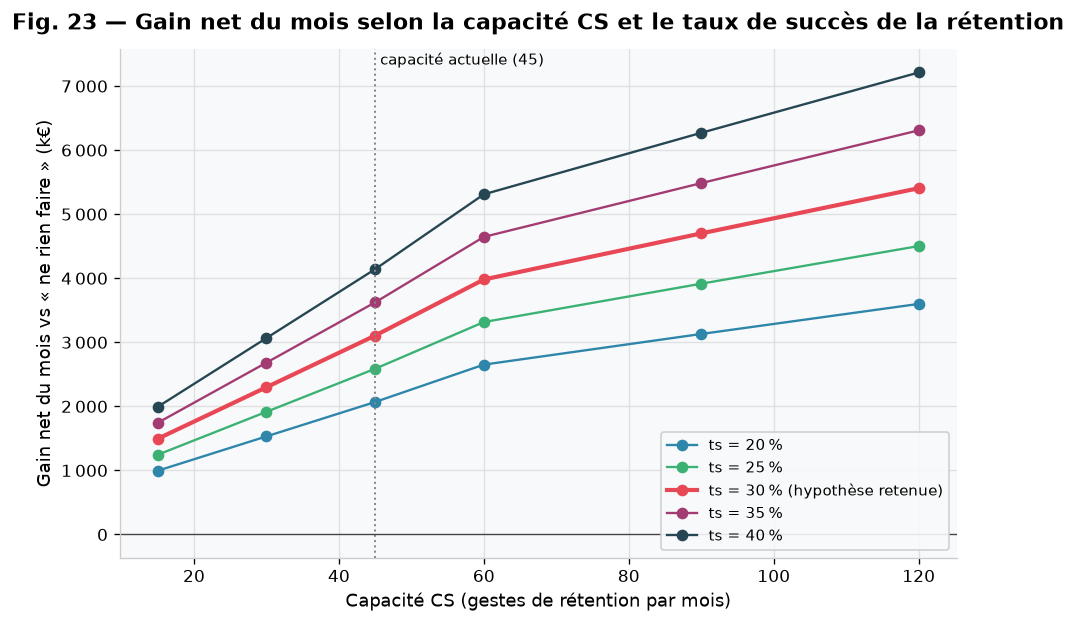


**Ce qu'il faut retenir.** Au taux de succès le plus prudent (20 %), la
règle reste rentable (+2 068 627 €
par mois de gestes) : la recommandation ne dépend pas d'une hypothèse optimiste. Le gain croît
avec la capacité, de moins en moins vite : entre 45 et 60 gestes, un geste de plus
rapporte 58 373 €, à comparer au coût d'un CSM supplémentaire. Le taux de succès
reste à **mesurer** dès le déploiement (§12.15).


In [139]:
fig_sensib, df_sensib = economics.sensibilite_capacite(y, proba_oof, MRR)
plt.show()
_ts_min = float(df_sensib["taux_succes_retention"].min())
_gains = df_sensib.set_index(["taux_succes_retention", "capacite"])["gain_net_eur"]
_gain_pire = float(_gains[(_ts_min, _cap)])
_cap_sup = next(c for c in sorted(df_sensib["capacite"].unique()) if c > _cap)
_gain_marginal = (_gains[(_ts_ref, _cap_sup)] - _gains[(_ts_ref, _cap)]) / (_cap_sup - _cap)
display(Markdown(f"""
**Ce qu'il faut retenir.** Au taux de succès le plus prudent ({pourcentage(_ts_min, 0)}), la
règle reste {"rentable" if _gain_pire > 0 else "**déficitaire**"} ({euros(_gain_pire, signe=True)}
par mois de gestes) : la recommandation ne dépend pas d'une hypothèse optimiste. Le gain croît
avec la capacité, de moins en moins vite : entre {_cap} et {_cap_sup} gestes, un geste de plus
rapporte {euros(_gain_marginal)}, à comparer au coût d'un CSM supplémentaire. Le taux de succès
reste à **mesurer** dès le déploiement (§12.15).
"""))

### 12.8 Explicabilité — importance, permutation et SHAP

Sur quoi le modèle s'appuie-t-il ? Trois mesures de feature importance (importance des
variables), de la plus rapide à la plus rigoureuse : les coefficients, l'importance de
permutation avec son intervalle de confiance à 95 % (IC₉₅), et SHAP (valeurs de Shapley), qui
répartit le score de chaque compte entre ses variables.

#### 12.8.1 Importance native du modèle — coefficients

Pour une régression logistique, c'est la valeur absolue des coefficients, calculés après
prétraitement (numériques standardisées, catégorielles en one-hot encoding, encodage
disjonctif). Limites : un coefficient de modalité (passage 0 → 1) ne se compare pas à celui
d'une variable standardisée (un écart-type), et deux variables corrélées se partagent leur
effet de façon instable.

2026-10-04 22:27:35.066 | WARNING  | churn_saas.models.explain:importance_native:190 - importance_native — ⚠️  Importance approximée via |coef_| (modèle linéaire). Sensible à l'échelle des features et à la régularisation — valide uniquement si les features sont standardisées. À compléter impérativement par la permutation importance.


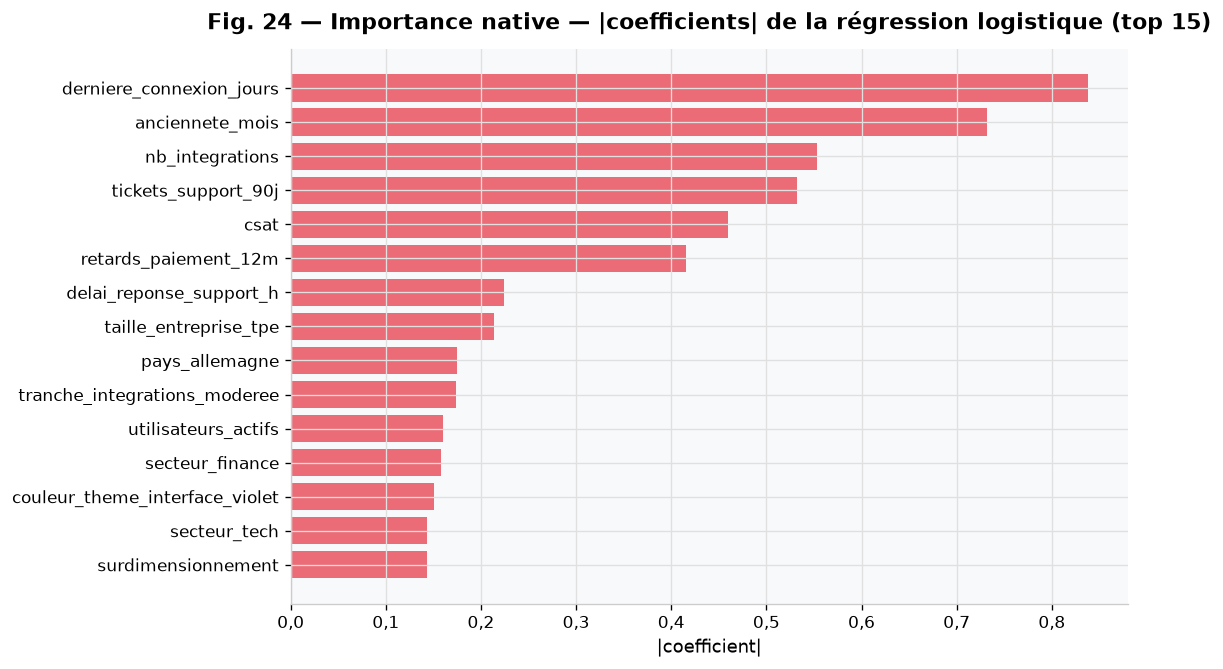

In [140]:
df_imp_native = xpl.importance_native(modele_final)
fig_imp_native, ax_imp_native = viz.figure(
    "importance_native",  # nom stable : figure réutilisée hors du notebook
    "Importance native — |coefficients| de la régression logistique (top 15)",
    taille=(9.0, 6.0),
)
_top15 = df_imp_native.head(15).iloc[::-1]
ax_imp_native.barh(_top15["feature"], _top15["importance"], color=viz.COULEUR_CHURN, alpha=0.8)
ax_imp_native.set_xlabel("|coefficient|")
viz.sauvegarder(fig_imp_native)
plt.show()

**Ce qu'il faut retenir.** Les coefficients donnent un premier classement, lisible dans le
modèle, mais ils mélangent des unités et éclatent une variable catégorielle en autant de lignes
que de modalités : on ne conclut pas sur eux seuls.

#### 12.8.2 Importance de permutation

Si l'on mélange au hasard les valeurs d'une variable et que la PR-AUC chute, le modèle s'en
sert. Le mélange est répété 20 fois pour obtenir un IC₉₅. La mesure, faite sur les données
d'entraînement du modèle final, dit ce qu'il **utilise**, pas ce qui généralise (d'où le
drop-column du §12.9).

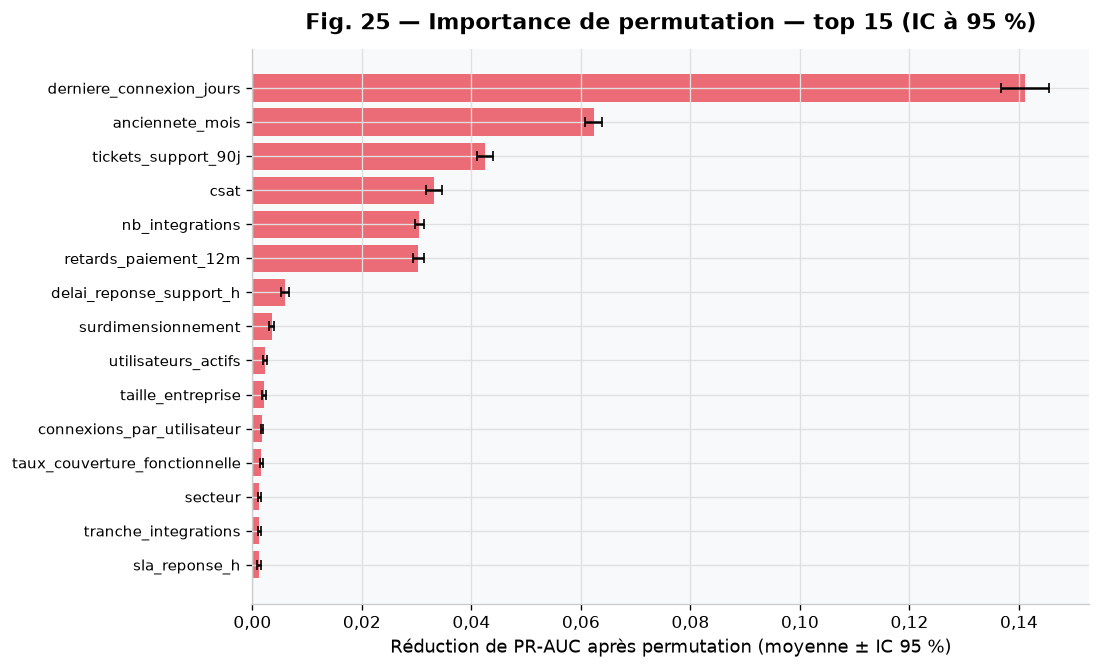


**Ce qu'il faut retenir.** 44 variables sur 52 ont
un effet démontré (IC₉₅ entièrement au-dessus de 0). Parmi les 8 autres, 5
n'apportent rien (IC₉₅ ≤ 0) et 3 ont un effet possible mais non démontré.
Une variable sans effet peut être un leurre **ou** la jumelle redondante d'une autre : le §12.9
tranche.


In [141]:
def _calcul_perm_imp() -> pd.DataFrame:
    return xpl.importance_permutation(modele_final, X, y, n_repeats=20, n_jobs=-1)


# Le drapeau « significatif » (IC₉₅ > 0) est recalculé pour qu'un cache suive la règle en vigueur
df_perm_imp = xpl.marquer_significativite(
    charger_ou_calculer("permutation_importance.parquet", _calcul_perm_imp)[0]
)
fig_perm, ax_perm = viz.figure(
    "importance_permutation", "Importance de permutation — top 15 (IC à 95 %)", taille=(9.0, 6.0)
)
_p = df_perm_imp.head(15).iloc[::-1]
_moy = _p["importance_moyenne"]
ax_perm.barh(
    _p["feature"],
    _moy,
    xerr=[_moy - _p["ic95_bas"], _p["ic95_haut"] - _moy],
    color=viz.COULEUR_CHURN,
    alpha=0.8,
    capsize=3,
)
ax_perm.tick_params(axis="y", labelsize=9)
ax_perm.axvline(0, color="#888888", linewidth=1.2, linestyle="--")
ax_perm.set_xlabel("Réduction de PR-AUC après permutation (moyenne ± IC 95 %)")
viz.sauvegarder(fig_perm)
plt.show()
_n_non_sig = int((~df_perm_imp["significatif"]).sum())
_n_nulles = int((df_perm_imp["ic95_haut"] <= 0).sum())
display(Markdown(f"""
**Ce qu'il faut retenir.** {len(df_perm_imp) - _n_non_sig} variables sur {len(df_perm_imp)} ont
un effet démontré (IC₉₅ entièrement au-dessus de 0). Parmi les {_n_non_sig} autres, {_n_nulles}
n'apportent rien (IC₉₅ ≤ 0) et {_n_non_sig - _n_nulles} ont un effet possible mais non démontré.
Une variable sans effet peut être un leurre **ou** la jumelle redondante d'une autre : le §12.9
tranche.
"""))

#### 12.8.3 SHAP — attributions additives (global et local)

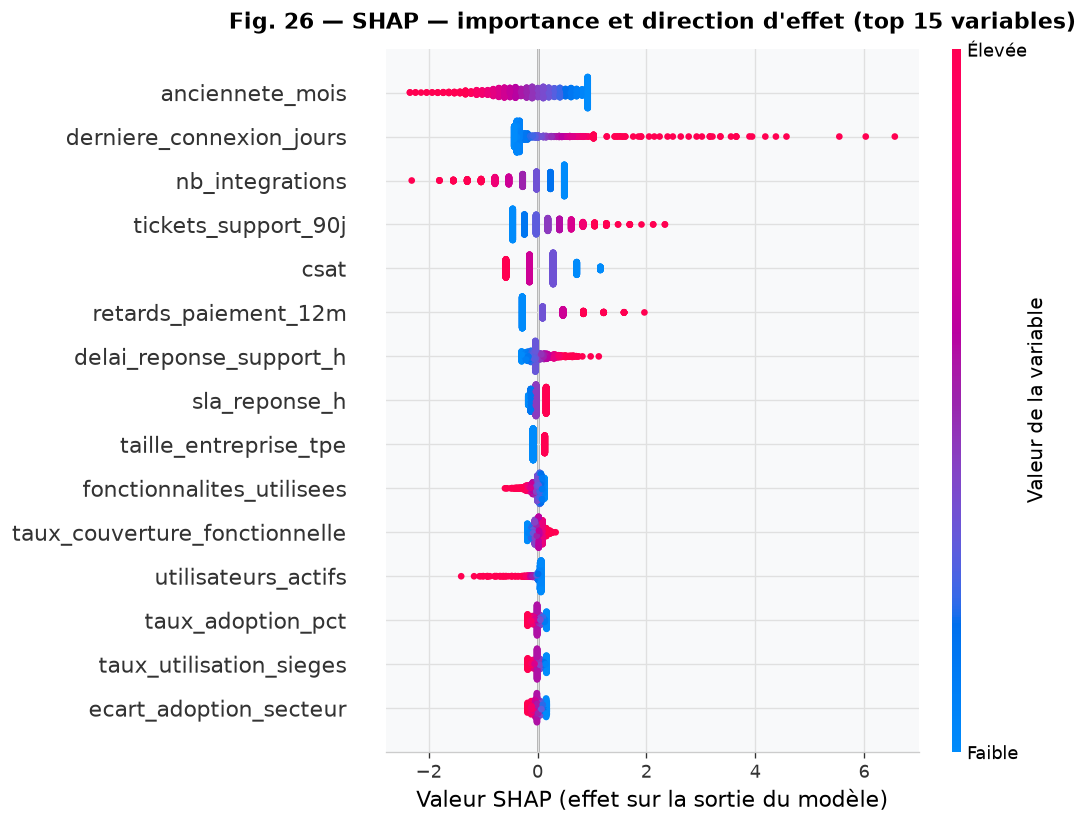

In [142]:
_idx_shap = np.random.default_rng(config.RANDOM_SEED + 1).choice(len(X), 1000, replace=False)
X_shap = X.iloc[_idx_shap]
explainer_shap, shap_values = xpl.valeurs_shap(
    modele_final, X_shap, nom_cache="shap_values_12.joblib"
)
# Les valeurs SHAP sont calculées après le ColumnTransformer : le graphique reçoit ce même espace
_sous_pipeline = modele_final[:-1]
_noms_trans = [str(n) for n in _sous_pipeline.get_feature_names_out()]
X_shap_trans = pd.DataFrame(_sous_pipeline.transform(X_shap), columns=_noms_trans)
fig_shap_summary, ax_shap = viz.figure(
    "shap_summary", "SHAP — importance et direction d'effet (top 15 variables)", taille=(9.0, 7.0)
)
shap.summary_plot(shap_values, X_shap_trans, max_display=15, plot_size=None, show=False)
ax_shap.set_xlabel("Valeur SHAP (effet sur la sortie du modèle)")
fig_shap_summary.axes[-1].set_ylabel("Valeur de la variable")
fig_shap_summary.axes[-1].set_yticklabels(["Faible", "Élevée"])
fig_shap_summary.tight_layout()
viz.sauvegarder(fig_shap_summary)
plt.show()

**Ce qu'il faut retenir.** Chaque point est un compte : sa position est ce que la variable
ajoute ou retire à son score (en log-odds, logarithme de la cote de churn), sa couleur la valeur
de la variable (rouge = élevée). Un nuage rouge à droite signifie qu'une valeur élevée pousse
vers le churn. Pour un modèle linéaire, le `LinearExplainer` est exact : coefficient × écart de
la valeur à la moyenne. Contrairement aux coefficients bruts, SHAP tient compte de la dispersion
réelle des valeurs et s'explique compte par compte (fiches du §12.11).

### 12.9 Verdict sur les leurres — 3 preuves convergentes

Le cahier des charges signale des leurres suspectés (`config.COLONNES_LEURRES_SUSPECTES`).
`commentaire_csm`, classé en data leakage (fuite de données) possible au §6.6, est exclu du
modèle : son importance serait nulle par construction et ne prouverait rien. Une importance
faible ne suffit pas non plus (une variable redondante avec une jumelle en a une aussi) : trois
preuves doivent converger.

1. **Association marginale** avec la cible : V de Cramér, p-value corrigée par
   Benjamini-Hochberg (comme en §6.10).
2. **Permutation** (§12.8.2) : la borne haute de l'IC₉₅ reste sous 1 point de PR-AUC (0,01).
3. **Drop-column** (retrait de colonne) : variable retirée, modèle réentraîné, PR-AUC mesurée sur
   un jeu tenu à l'écart : perte inférieure à 1 point.

On juge l'**ampleur** de l'effet, pas sa seule significativité : sur les données d'entraînement,
une variable de pur bruit dégrade toujours un peu le score quand on la mélange.

In [143]:
_leurres_presents = [c for c in config.COLONNES_LEURRES_SUSPECTES if c in X.columns]
_leurres_exclus = [c for c in config.COLONNES_LEURRES_SUSPECTES if c not in X.columns]


def _calcul_criblage() -> pd.DataFrame:
    return cribler_leurres(gold, cible="churn", colonnes=_leurres_presents)


def _calcul_drop_col() -> pd.DataFrame:
    return xpl.importance_drop_column(modele_final, X, y, colonnes=_leurres_presents, forcer=True)


tableau_criblage = charger_ou_calculer("criblage_leurres_12.parquet", _calcul_criblage)[0]
# Un artefact en cache peut couvrir un périmètre plus large : on s'aligne sur les leurres testables
tableau_criblage = tableau_criblage.loc[tableau_criblage.index.isin(_leurres_presents)]
df_drop_col = charger_ou_calculer("drop_column_12.parquet", _calcul_drop_col)[0]
df_verdict = xpl.verdict_leurres(tableau_criblage, df_perm_imp, df_drop_col)
_preuves = ["association_significative", "permutation_negligeable", "drop_negligeable"]
display(styler_fr(df_verdict[[*_preuves, "verdict", "raisonnement"]]))
_rang_perm = {c: r + 1 for r, c in enumerate(df_perm_imp["feature"]) if c in _leurres_presents}
_confirmes = df_verdict.index[df_verdict["verdict"] == "LEURRE CONFIRMÉ"].tolist()
_non_confirmes = df_verdict.index[df_verdict["verdict"] != "LEURRE CONFIRMÉ"].tolist()
# Les importances sont en unités de PR-AUC ; ×100 pour les exprimer en points
_ic_haut_max = 100 * float(
    df_perm_imp.set_index("feature").loc[_leurres_presents, "ic95_haut"].max()
)
_delta_drop = 100 * df_drop_col.loc[_leurres_presents, "delta_pr_auc"]
display(Markdown(f"""
**Ce qu'il faut retenir.** Sur {len(_leurres_presents)} leurres testables,
**{len(_confirmes)} confirmé(s)** par les trois preuves ({_liste(_confirmes) or "aucun"}) ; non
confirmé(s) : {_liste(_non_confirmes) or "aucun"}.

- **Association** : {entier(int(tableau_criblage['significatif_BH'].sum()))} sur
  {entier(len(tableau_criblage))} significative(s) après correction ; redondance maximale
  {nombre(float(tableau_criblage['max_redondance'].max()), 3)} (jumelle probable au-delà de
  {nombre(config.SEUIL_REDONDANCE, 2)}) : aucune jumelle ne masque leur effet.
- **Permutation** : borne haute de l'IC₉₅ au plus {nombre(_ic_haut_max, 2)} point (seuil : 1),
  rangs {", ".join(f"{entier(r)} (`{c}`)" for c, r in _rang_perm.items())} sur
  {entier(len(df_perm_imp))}.
- **Drop-column** : Δ PR-AUC de {nombre(float(_delta_drop.min()), 2, signe=True)} à
  {nombre(float(_delta_drop.max()), 2, signe=True)} point (seuil : 1) ; un Δ négatif signifie que
  le modèle est meilleur sans la variable.

{"Le retrait anticipé au §10.3 est confirmé : le modèle déployé, réentraîné sans ces variables, est le bon ; elles restent dans le gold pour que la preuve reste reproductible." if not _non_confirmes else "⚠️ Le modèle déployé au §10.3 a retiré des variables non confirmées ici : il doit être réentraîné en les réintégrant."}
Exclue(s) en amont (§6.6) : {_liste(_leurres_exclus) or "aucune"}.
"""))

,association_significative,permutation_negligeable,drop_negligeable,verdict,raisonnement
colonne,,,,,
couleur_theme_interface,False,True,True,LEURRE CONFIRMÉ,"Association non significative (p_BH ≥ 0,05) ; IC₉₅ haut de permutation = 0,0007 (< 0,01) ; drop-column Δ = -0,0032 (< 0,01). Les trois preuves convergent : variable inutile au modèle."
code_datacenter,False,True,True,LEURRE CONFIRMÉ,"Association non significative (p_BH ≥ 0,05) ; IC₉₅ haut de permutation = 0,0004 (< 0,01) ; drop-column Δ = +0,0004 (< 0,01). Les trois preuves convergent : variable inutile au modèle."
groupe_experimentation,False,True,True,LEURRE CONFIRMÉ,"Association non significative (p_BH ≥ 0,05) ; IC₉₅ haut de permutation = 0,0003 (< 0,01) ; drop-column Δ = +0,0009 (< 0,01). Les trois preuves convergent : variable inutile au modèle."



**Ce qu'il faut retenir.** Sur 3 leurres testables,
**3 confirmé(s)** par les trois preuves (`couleur_theme_interface`, `code_datacenter`, `groupe_experimentation`) ; non
confirmé(s) : aucun.

- **Association** : 0 sur
  3 significative(s) après correction ; redondance maximale
  0,084 (jumelle probable au-delà de
  0,70) : aucune jumelle ne masque leur effet.
- **Permutation** : borne haute de l'IC₉₅ au plus 0,07 point (seuil : 1),
  rangs 28 (`couleur_theme_interface`), 35 (`code_datacenter`), 39 (`groupe_experimentation`) sur
  52.
- **Drop-column** : Δ PR-AUC de -0,32 à
  +0,09 point (seuil : 1) ; un Δ négatif signifie que
  le modèle est meilleur sans la variable.

Le retrait anticipé au §10.3 est confirmé : le modèle déployé, réentraîné sans ces variables, est le bon ; elles restent dans le gold pour que la preuve reste reproductible.
Exclue(s) en amont (§6.6) : `commentaire_csm`.


### 12.10 Régression CLV — confrontation aux cibles §8, RMSE, MAE, R² et résidus

Cible secondaire : `valeur_vie_client_eur`, évaluée en euros sur un jeu de test de 20 % contre
les cibles de §8.2 (R² minimal, gain de MAE sur la baseline médiane, alerte de fuite). Règle
posée avant le tableau : parmi les modèles qui atteignent toutes les cibles, le R² le plus élevé.

**Contrôle ajouté après observation, et signalé comme tel.** Une première version retenait un
modèle qui prédisait des CLV négatives. Or §8.1 pose la CLV comme strictement positive : une
prédiction ≤ 0 est une valeur impossible. D'où le critère « aucune prédiction ≤ 0 », qui ne porte
sur aucune métrique de performance. La règle est codée une seule fois
(`reg.selectionner_champion_clv`), partagée avec §14.

In [144]:
X_reg = reg.features_regression(gold)  # sans churn ni sante_compte_fin_periode (fuites)
y_reg = pd.to_numeric(gold["valeur_vie_client_eur"], errors="coerce").dropna()
X_reg = X_reg.loc[y_reg.index]


def _calcul_regression() -> dict:
    return reg.entrainer_modeles_clv(X_reg, y_reg)


resultats_reg = charger_ou_calculer("regression_clv.joblib", _calcul_regression)[0]
tableau_reg, _champion_reg = reg.selectionner_champion_clv(resultats_reg)
_coche = {True: "✅", False: "❌"}
display(
    pd.DataFrame(
        {
            "RMSE (€)": tableau_reg["rmse"].map(entier),
            "MAE (€)": tableau_reg["mae"].map(entier),
            "R²": tableau_reg["r2"].map(lambda v: nombre(v, 3)),
            "Gain MAE": tableau_reg["gain_mae"].map(lambda v: pourcentage(v, 0)),
            "Prédictions ≤ 0": tableau_reg["n_pred_non_positives"].map(entier),
            f"R² ≥ {nombre(_c['clv_r2_min'], 2)}": tableau_reg["ok_r2"].map(_coche),
            f"Gain MAE ≥ {pourcentage(_c['clv_gain_mae_min'], 0)}": tableau_reg["ok_mae"].map(
                _coche
            ),
            f"R² ≤ {nombre(_c['clv_r2_alerte_fuite'], 2)}": tableau_reg["ok_fuite"].map(_coche),
            "CLV > 0": tableau_reg["ok_domaine"].map(_coche),
            "Conforme": tableau_reg["conforme"].map(_coche),
        }
    ).style.set_properties(**{"text-align": "left"})
)
_conformes_reg = tableau_reg.index[tableau_reg["conforme"]].tolist()
# Aucun modèle conforme : on le dit, et le meilleur R² n'est montré qu'à titre de diagnostic
_nom_best_reg = _champion_reg if _champion_reg is not None else str(tableau_reg["r2"].idxmax())
_m_best = tableau_reg.loc[_nom_best_reg]
_hors_domaine = tableau_reg.index[
    tableau_reg[["ok_r2", "ok_mae", "ok_fuite"]].all(axis=1) & ~tableau_reg["ok_domaine"]
].tolist()
_mae_conforme = str(tableau_reg.loc[_conformes_reg, "mae"].idxmin()) if _conformes_reg else None
# Structure de la cible : CLV additive ou multiplicative en MRR ?
_mrr_reg = pd.to_numeric(gold.loc[y_reg.index, "revenu_mensuel_recurrent_eur"], errors="coerce")
_dispo = _mrr_reg.notna() & (_mrr_reg > 0)
_corr_euros = float(np.corrcoef(y_reg[_dispo], _mrr_reg[_dispo])[0, 1])
_corr_log = float(np.corrcoef(np.log(y_reg[_dispo]), np.log(_mrr_reg[_dispo]))[0, 1])
_verdict_reg = (
    f"{len(_conformes_reg)} modèle(s) sur {len(tableau_reg)} satisfont toutes les cibles ; "
    f"champion (R² maximal parmi eux) : **`{_nom_best_reg}`**, R² = {nombre(_m_best['r2'], 3)}, "
    f"MAE = {euros(_m_best['mae'])} (gain de {pourcentage(_m_best['gain_mae'], 0)} sur la "
    "baseline médiane)."
    if _champion_reg is not None
    else "❌ **Aucun modèle ne satisfait toutes les cibles** : la régression CLV n'est pas "
    f"déployable en l'état ; `{_nom_best_reg}` n'est montré qu'en diagnostic."
)
display(Markdown(f"""
**Ce qu'il faut retenir.** {_verdict_reg} Écartés par le seul contrôle de domaine :
{_liste(_hors_domaine) or "aucun"}. La corrélation CLV–MRR passe de {nombre(_corr_euros, 2)} en
euros à **{nombre(_corr_log, 2)} en log** : la CLV est **multiplicative** (CLV ≈ MRR × durée). Un
modèle additif en euros, dominé par les très gros comptes, s'ajuste sur eux avec des corrections
négatives qui font passer de petits comptes sous zéro ; les modèles sur log(CLV) restent positifs
par construction. Les spécifications log-log, Poisson ou Gamma sont posées comme hypothèses du
prochain cycle (§13.1), et non ajoutées après lecture des résultats.
{"" if _mae_conforme in (None, _nom_best_reg) else f"La plus faible MAE revient à `{_mae_conforme}` : le R² est dominé par les gros comptes, la MAE reflète le compte typique ; la règle n'est pas changée après coup."}
Ces écarts reposent sur un seul découpage 80/20, non testé (§14.2).
"""))

,RMSE (€),MAE (€),R²,Gain MAE,Prédictions ≤ 0,"R² ≥ 0,50",Gain MAE ≥ 30 %,"R² ≤ 0,99",CLV > 0,Conforme
modele,,,,,,,,,,
ridge,108 001,49 351,"0,737",32 %,283,✅,✅,✅,❌,❌
lgbm,112 694,37 223,"0,713",49 %,41,✅,✅,✅,❌,❌
ridge_log,156 490,39 441,"0,447",46 %,0,❌,✅,✅,✅,❌
lgbm_log,112 348,33 973,"0,715",53 %,0,✅,✅,✅,✅,✅



**Ce qu'il faut retenir.** 1 modèle(s) sur 4 satisfont toutes les cibles ; champion (R² maximal parmi eux) : **`lgbm_log`**, R² = 0,715, MAE = 33 973 € (gain de 53 % sur la baseline médiane). Écartés par le seul contrôle de domaine :
`ridge`, `lgbm`. La corrélation CLV–MRR passe de 0,84 en
euros à **0,94 en log** : la CLV est **multiplicative** (CLV ≈ MRR × durée). Un
modèle additif en euros, dominé par les très gros comptes, s'ajuste sur eux avec des corrections
négatives qui font passer de petits comptes sous zéro ; les modèles sur log(CLV) restent positifs
par construction. Les spécifications log-log, Poisson ou Gamma sont posées comme hypothèses du
prochain cycle (§13.1), et non ajoutées après lecture des résultats.

Ces écarts reposent sur un seul découpage 80/20, non testé (§14.2).


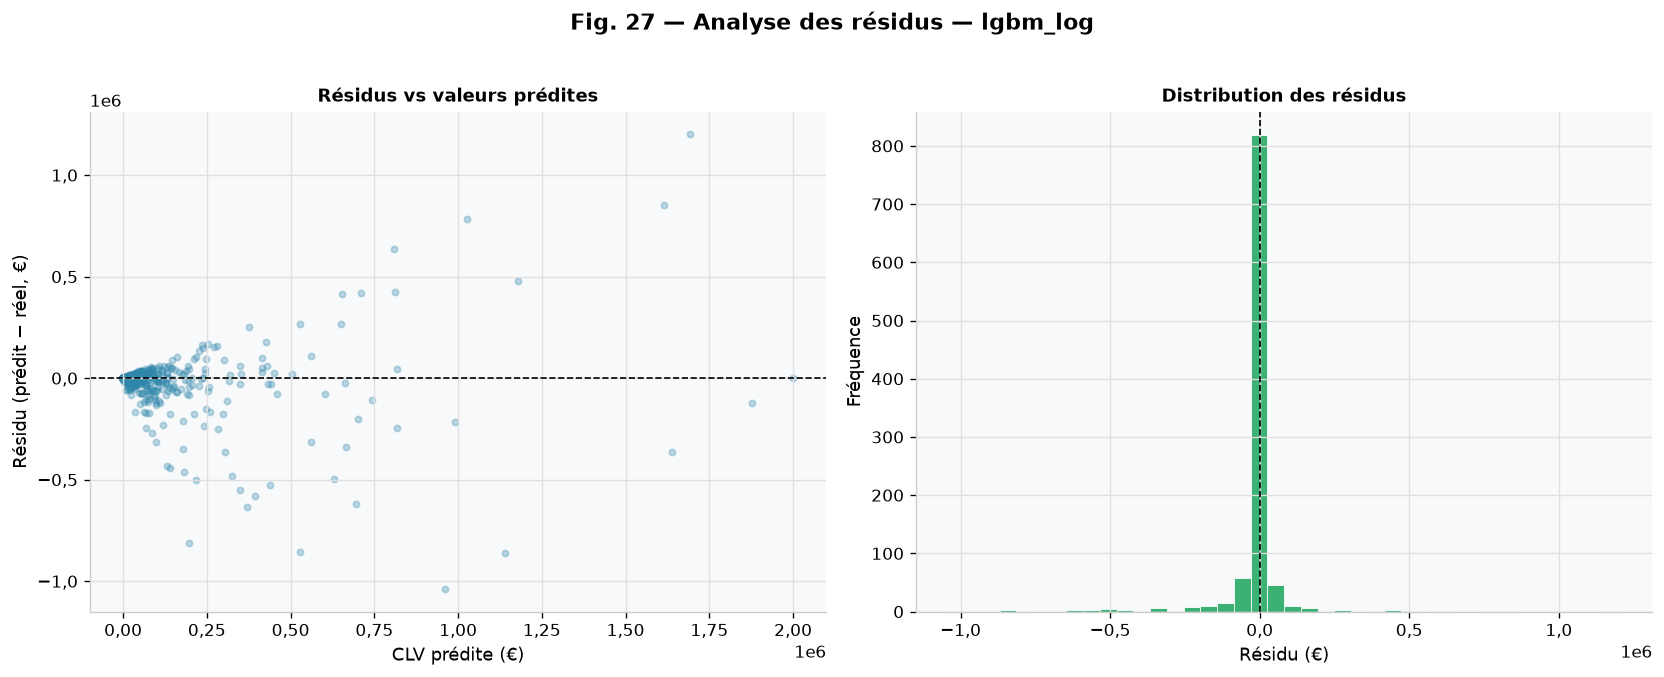


**Ce qu'il faut retenir.** Le champion se trompe en moyenne de
**231 716 €** sur les 10 % de comptes à plus forte CLV
(≥ 187 773 €), contre 12 001 € sur les autres :
l'erreur croît avec la valeur du compte, d'où l'éventail du nuage de résidus.

Entraîné sur log(CLV), il prédit plutôt la médiane que la moyenne et tend à sous-estimer les euros, biais corrigeable au prochain cycle.
La CLV prédite est un ordre de grandeur pour le CSM, pas une valeur comptable.


In [145]:
_y_test_reg = np.asarray(resultats_reg[_nom_best_reg]["y_test"], dtype=float)
_y_pred_reg = np.asarray(resultats_reg[_nom_best_reg]["y_pred"], dtype=float)
fig_res = reg.figure_residus(_y_test_reg, _y_pred_reg, _nom_best_reg)
plt.show()
_erreurs_abs = np.abs(_y_pred_reg - _y_test_reg)
_q90_reel = float(np.quantile(_y_test_reg, 0.90))
_gros = _y_test_reg >= _q90_reel
_n_pred_non_pos = int((_y_pred_reg <= 0).sum())
display(Markdown(f"""
**Ce qu'il faut retenir.** Le champion se trompe en moyenne de
**{euros(float(_erreurs_abs[_gros].mean()))}** sur les 10 % de comptes à plus forte CLV
(≥ {euros(_q90_reel)}), contre {euros(float(_erreurs_abs[~_gros].mean()))} sur les autres :
l'erreur croît avec la valeur du compte, d'où l'éventail du nuage de résidus.
{f"⚠️ {entier(_n_pred_non_pos)} prédiction(s) ≤ 0 : diagnostic seulement." if _n_pred_non_pos else ""}
{"Entraîné sur log(CLV), il prédit plutôt la médiane que la moyenne et tend à sous-estimer les euros, biais corrigeable au prochain cycle." if "log" in _nom_best_reg else ""}
La CLV prédite est un ordre de grandeur pour le CSM, pas une valeur comptable.
"""))

### 12.11 Valeur à risque et fiches comptes

Combien un compte peut-il faire perdre s'il part ? Formule unique du projet
(`churn_saas.economie`) :

$$\text{valeur\_à\_risque}(i) = P(\text{churn}_i) \times \text{MRR}_i \times H \times M$$

avec $H$ l'horizon (12 mois) et $M$ la marge brute. **Et non** P(churn) × CLV : §6.7 a montré
que la CLV, prospective, intègre déjà le risque de départ ; la multiplier par P(churn)
compterait ce risque deux fois.

In [146]:
valeurs_risque = reg.valeur_a_risque(proba_oof, MRR.values)
display(Markdown(f"""
**Ce qu'il faut retenir.** Le portefeuille expose **{euros(valeurs_risque.sum())}** sur
{_horizon} mois, dont {euros(valeurs_risque[_selection_valeur].sum())} pour les {_cap} comptes
appelés (§12.6). La valeur à risque combine le signal du modèle et le poids du compte : à 40 % de
probabilité et 5 000 €/mois, un compte expose {euros(economie.valeur_a_risque(0.40, 5_000.0))},
contre {euros(economie.valeur_a_risque(0.80, 100.0))} à 80 % et 100 €/mois. C'est le premier
qu'il faut appeler.
"""))


**Ce qu'il faut retenir.** Le portefeuille expose **34 217 615 €** sur
12 mois, dont 11 051 991 € pour les 45 comptes
appelés (§12.6). La valeur à risque combine le signal du modèle et le poids du compte : à 40 % de
probabilité et 5 000 €/mois, un compte expose 17 280 €,
contre 691 € à 80 % et 100 €/mois. C'est le premier
qu'il faut appeler.


**Fiches comptes — deux clients réels à risque élevé** (plus forte valeur à risque parmi les
comptes à P(churn) ≥ 50 %). La probabilité est la prédiction hors pli ; les facteurs SHAP
expliquent le modèle final, celui qu'appellerait la production. Les facteurs sont présentés sous
leur libellé métier, la contribution entre parenthèses en log-odds. Le palier vient de la même
fonction que l'API et le batch, avec le seuil de vigilance du §12.6 : notebook et production
parlent le même langage.

In [147]:
def _facteurs(indices: list[int], contributions: np.ndarray, compte: pd.Series) -> str:
    lignes = [
        f"- {xpl.libelle_facteur(_noms_trans[i], compte)} "
        f"({nombre(float(contributions[i]), 2, signe=True)})"
        for i in indices
    ]
    return "\n".join(lignes) or "— aucun"


_, shap_values_all = xpl.valeurs_shap(modele_final, X, nom_cache="shap_values_all.joblib")
_candidats = np.flatnonzero(proba_oof >= 0.50)
for _rang, _pos in enumerate(_candidats[np.argsort(-valeurs_risque[_candidats])][:2], start=1):
    _proba, _sv, _compte = float(proba_oof[_pos]), shap_values_all[_pos], X.iloc[_pos]
    _hausse = [int(i) for i in np.argsort(_sv)[::-1][:3] if _sv[i] > 0]
    _baisse = [int(i) for i in np.argsort(_sv)[:2] if _sv[i] < 0]
    display(Markdown(f"""
---
**🗂️ Fiche compte #{_rang} — `{gold['client_id'].iloc[_pos]}`**

| Indicateur | Valeur |
|---|---|
| Probabilité de churn | **{pourcentage(_proba, 1)}** |
| Palier (seuil de vigilance §12.6) | **{economie.niveau_risque(_proba)}** |
| MRR | {euros(float(MRR.iloc[_pos]))}/mois |
| **Valeur à risque ({_horizon} mois)** | **{euros(float(valeurs_risque[_pos]))}** |

**Ce qui augmente le risque :**
{_facteurs(_hausse, _sv, _compte)}

**Ce qui le réduit :**
{_facteurs(_baisse, _sv, _compte)}

**Action préventive suggérée** (facteur dominant) :
> {xpl.action_preventive(_noms_trans[_hausse[0] if _hausse else int(np.argmax(_sv))])}
"""))


---
**🗂️ Fiche compte #1 — `CLI-003693`**

| Indicateur | Valeur |
|---|---|
| Probabilité de churn | **96,4 %** |
| Palier (seuil de vigilance §12.6) | **ALERTE_ROUGE** |
| MRR | 70 941 €/mois |
| **Valeur à risque (12 mois)** | **591 073 €** |

**Ce qui augmente le risque :**
- Jours depuis la dernière connexion : 56 (+2,35)
- Sièges payés mais inutilisés : 870 (+1,39)
- Revenu mensuel récurrent (€) : 70 941 (+0,65)

**Ce qui le réduit :**
- Délai de réponse du support (h) : 2,1 (-0,30)
- Part des fonctionnalités utilisées : 0 (-0,19)

**Action préventive suggérée** (facteur dominant) :
> Planifier un appel de reprise d'usage sous 5 jours ouvrés ; partager une synthèse des nouvelles fonctionnalités activées depuis la dernière connexion.



---
**🗂️ Fiche compte #2 — `CLI-002891`**

| Indicateur | Valeur |
|---|---|
| Probabilité de churn | **97,2 %** |
| Palier (seuil de vigilance §12.6) | **ALERTE_ROUGE** |
| MRR | 58 331 €/mois |
| **Valeur à risque (12 mois)** | **489 753 €** |

**Ce qui augmente le risque :**
- Jours depuis la dernière connexion : 40 (+1,58)
- Sièges payés mais inutilisés : 646 (+1,02)
- Satisfaction client (CSAT, sur 5) : 2 (+0,59)

**Ce qui le réduit :**
- Délai de réponse du support (h) : 3,3 (-0,27)
- Part des fonctionnalités utilisées : 0 (-0,19)

**Action préventive suggérée** (facteur dominant) :
> Planifier un appel de reprise d'usage sous 5 jours ouvrés ; partager une synthèse des nouvelles fonctionnalités activées depuis la dernière connexion.


### 12.12 KPI métier et ROI

On évalue le système en euros : combien de marge il permet de sauver chaque mois, à quel coût,
et surtout **combien de plus qu'une équipe sans modèle**. Les KPI (indicateurs clés) sont ceux
de la règle retenue (§12.6). Le ROI (retour sur investissement) de la cohorte compte la marge
sauvée sur tout l'horizon par les gestes d'un mois, comme en §2.4.

In [148]:
_n_churners_detectes = int(bilan_valeur["n_churners"])
_precision_top_n = bilan_valeur["precision"]
_roi = bilan_valeur["roi"]
# Part du gain due au modèle : écart à la référence « plus gros MRR », sur la plage de taux de
# succès du §12.7
attribution = economics.gain_attribuable_au_modele(y, proba_oof, MRR, capacite=_cap)
_gain_modele = attribution["gain_attribuable"]
_fourchette = (
    f"{euros(attribution['gain_attribuable_min'])} à {euros(attribution['gain_attribuable_max'])}"
)
display(Markdown(f"""
| KPI | Valeur | Lecture |
|---|---|---|
| Partants sous surveillance | {pourcentage(vigilance['recall'], 0)} ({entier(vigilance['n_signales'])} comptes) | niveau 1 : recall au seuil de vigilance |
| Comptes appelés par mois | {_cap} | capacité CS (§2.3) |
| Precision des appels | {pourcentage(_precision_top_n, 1)} ({_n_churners_detectes} partants) | niveau 2 ; hasard : {pourcentage(y.mean(), 0)} |
| Fausses alertes parmi les appels | {pourcentage(1.0 - _precision_top_n, 1)} | fatigue d'alerte ; hasard : {pourcentage(1 - y.mean(), 0)} |
| Valeur sauvée par la cohorte | {euros(bilan_valeur['valeur_sauvee'])} | marge sur {_horizon} mois, pour {euros(bilan_valeur['cout_gestes'])} de gestes |
| Gain net sans modèle | {euros(attribution['reference']['gain_net'])} | les {_cap} plus gros MRR |
| **Gain attribuable au modèle** | **{euros(_gain_modele)}** | {_fourchette} (taux de succès {pourcentage(attribution['taux_succes_min'], 0)} à {pourcentage(attribution['taux_succes_max'], 0)}) |
| ROI de la cohorte | {nombre(_roi, 1)}× | (valeur sauvée − coût) / coût, contre « ne rien faire » |

**Ce qu'il faut retenir.** Le KPI qui mesure la valeur du modèle est le **gain attribuable** : ce
que la règle rapporte de plus qu'une équipe qui appellerait ses plus gros comptes sans score, à
budget identique. Le ROI de la cohorte ne compte que le temps CSM (ni remises, ni coût du projet,
chiffré plus bas) : sa valeur très élevée tient à l'asymétrie de la matrice (§12.4) et au poids de quelques gros comptes.
Il sert à détecter un effondrement, avec des seuils posés sur des repères économiques : alerte
sous 1× (le gain ne couvre plus une erreur d'un facteur 2 sur le taux de succès), critique sous 0
(perte nette). Le niveau acceptable de fatigue d'alerte sera fixé avec l'équipe CS au pilote.
"""))


| KPI | Valeur | Lecture |
|---|---|---|
| Partants sous surveillance | 80 % (1 813 comptes) | niveau 1 : recall au seuil de vigilance |
| Comptes appelés par mois | 45 | capacité CS (§2.3) |
| Precision des appels | 68,9 % (31 partants) | niveau 2 ; hasard : 28 % |
| Fausses alertes parmi les appels | 31,1 % | fatigue d'alerte ; hasard : 72 % |
| Valeur sauvée par la cohorte | 3 110 365 € | marge sur 12 mois, pour 4 950 € de gestes |
| Gain net sans modèle | 1 816 586 € | les 45 plus gros MRR |
| **Gain attribuable au modèle** | **1 288 829 €** | 859 219 € à 1 718 439 € (taux de succès 20 % à 40 %) |
| ROI de la cohorte | 627,4× | (valeur sauvée − coût) / coût, contre « ne rien faire » |

**Ce qu'il faut retenir.** Le KPI qui mesure la valeur du modèle est le **gain attribuable** : ce
que la règle rapporte de plus qu'une équipe qui appellerait ses plus gros comptes sans score, à
budget identique. Le ROI de la cohorte ne compte que le temps CSM (ni remises, ni coût du projet,
chiffré plus bas) : sa valeur très élevée tient à l'asymétrie de la matrice (§12.4) et au poids de quelques gros comptes.
Il sert à détecter un effondrement, avec des seuils posés sur des repères économiques : alerte
sous 1× (le gain ne couvre plus une erreur d'un facteur 2 sur le taux de succès), critique sous 0
(perte nette). Le niveau acceptable de fatigue d'alerte sera fixé avec l'équipe CS au pilote.


**Le gain d'un mois ne se répète pas.** Le mois suivant, les meilleurs comptes ont déjà été
contactés : multiplier le premier mois par 12 serait faux. On simule un an : chaque mois, les
meilleurs comptes **non encore contactés**, avec et sans modèle, à portefeuille et scores figés
(faute d'une seconde extraction, §6.11). La date des départs étant inconnue, deux scénarios : un
partant contacté est encore client (retenu, prudent), ou les départs s'étalent sur l'année.

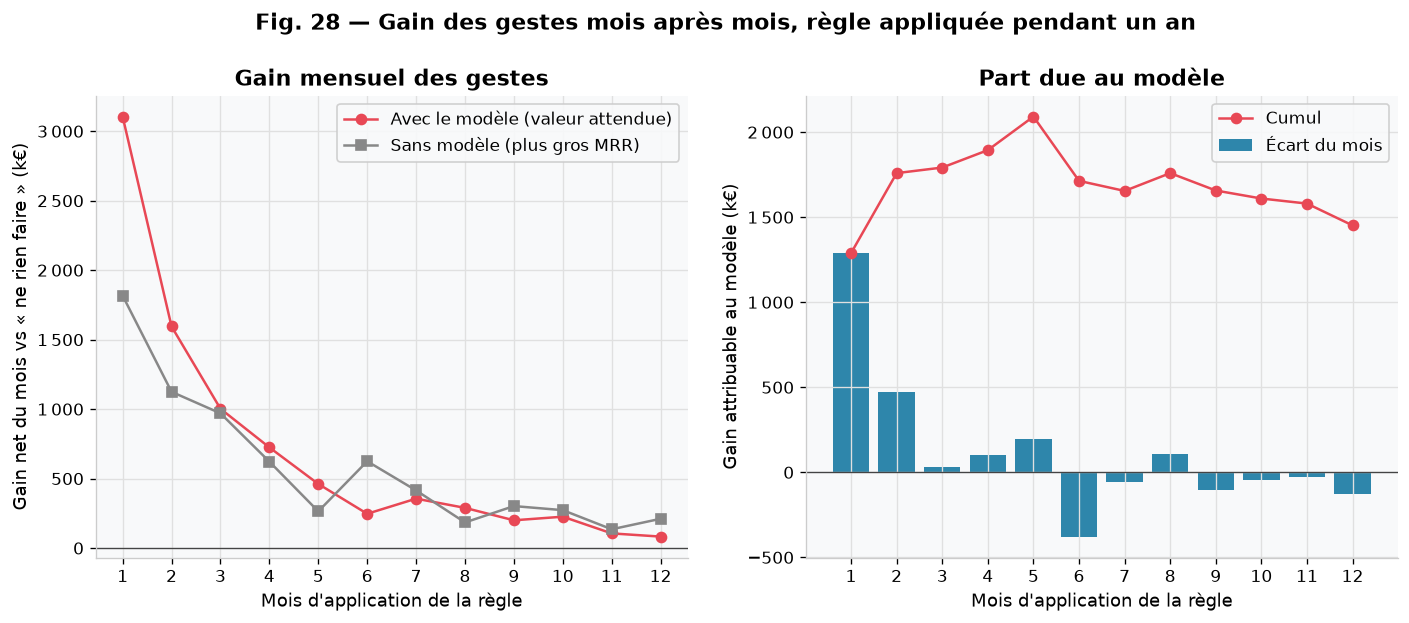


**Ce qu'il faut retenir.** Sur un an, le gain dû au modèle cumule
**1 451 797 €** (de 967 865 € à
1 935 730 € selon le taux de succès), soit
1,1 fois le premier mois, et non 12.
Le modèle trouve 281 partants dans l'année contre
116 sans lui, mais l'équipe sans modèle finit
par appeler les mêmes gros comptes. Une barre négative n'est donc pas une perte (à gauche, les deux
stratégies restent gagnantes) : ce mois-là, l'équipe sans modèle atteint des gros partants que le
modèle a appelés plus tôt. Ce rattrapage fait culminer le cumul au mois
5 : l'apport du modèle tient surtout à ce qu'il
**atteint les gros partants plus tôt**. Avec des départs étalés, le gain dû au modèle vaut
1 687 654 € : le chiffre retenu
est prudent. La date de départ ne se déduit pas de
l'anniversaire de souscription : taux de départ 20 %
à 2 mois ou moins de cette date, 38 % à 9 mois ou
plus.


In [149]:
gain_annuel = economics.gain_annuel_attribuable(y, proba_oof, MRR, capacite=_cap)
_mensuel = gain_annuel["mensuel"]
fig_gain_annuel = economics.tracer_gain_sur_annee(_mensuel)
plt.show()
# Si les départs survenaient à la date anniversaire, leur taux croîtrait à son approche
_avant_anniv = (12 - pd.to_numeric(gold["anciennete_mois"], errors="coerce") % 12) % 12
_prudent = gain_annuel["annuel_departs_etales"] >= gain_annuel["annuel"]
display(Markdown(f"""
**Ce qu'il faut retenir.** Sur un an, le gain dû au modèle cumule
**{euros(gain_annuel['annuel'])}** (de {euros(gain_annuel['annuel_min'])} à
{euros(gain_annuel['annuel_max'])} selon le taux de succès), soit
{nombre(gain_annuel['annuel'] / gain_annuel['premier_mois'], 1)} fois le premier mois, et non 12.
Le modèle trouve {entier(int(_mensuel['n_churners_modele'].sum()))} partants dans l'année contre
{entier(int(_mensuel['n_churners_reference'].sum()))} sans lui, mais l'équipe sans modèle finit
par appeler les mêmes gros comptes. Une barre négative n'est donc pas une perte (à gauche, les deux
stratégies restent gagnantes) : ce mois-là, l'équipe sans modèle atteint des gros partants que le
modèle a appelés plus tôt. Ce rattrapage fait culminer le cumul au mois
{int(_mensuel['gain_attribuable_cumule'].idxmax())} : l'apport du modèle tient surtout à ce qu'il
**atteint les gros partants plus tôt**. Avec des départs étalés, le gain dû au modèle vaut
{euros(gain_annuel['annuel_departs_etales'])} : le chiffre retenu
{"est prudent" if _prudent else "est une borne haute (⚠️)"}. La date de départ ne se déduit pas de
l'anniversaire de souscription : taux de départ {pourcentage(float(y[_avant_anniv <= 2].mean()), 0)}
à 2 mois ou moins de cette date, {pourcentage(float(y[_avant_anniv >= 9].mean()), 0)} à 9 mois ou
plus.
"""))

**Le projet couvre-t-il son propre coût ?** Le ROI de la cohorte ne compte que le temps des CSM.
Un investissement se juge sur son coût complet : développement amorti, infrastructure du
scénario B (§11.7) et maintenance (`config.COUTS_PROJET`). On l'oppose au seul gain attribuable
sur un an : sans modèle, l'équipe appellerait quand même ses plus gros comptes.

In [150]:
projet = economics.bilan_projet(gain_annuel)
_cp = config.COUTS_PROJET
_jours_build = projet["cout_build"] / float(_cp["cout_journalier_eur"])
_retour = projet["mois_retour"]
_ts_eq = projet["taux_succes_equilibre"]
display(Markdown(f"""
| Poste | Montant | Hypothèse |
|---|---|---|
| Développement | {euros(projet['cout_build'])} | {entier(_jours_build)} jours à {euros(_cp['cout_journalier_eur'])}, amortis sur {entier(_cp['duree_amortissement_ans'])} ans |
| Exploitation | {euros(projet['cout_run_annuel'])} par an | infrastructure {euros(_cp['infra_mensuel_eur'])}/mois, maintenance {entier(_cp['jours_maintenance_mois'])} jours/mois |
| **Coût annuel complet** | **{euros(projet['cout_annuel'])}** | amortissement + exploitation |
| Gain attribuable sur un an | {euros(gain_annuel['annuel'])} | simulation ci-dessus |
| **ROI du projet** | **{nombre(projet['roi_projet'], 1)}×** | (gain attribuable − coût complet) / coût complet |
| Délai de retour | {f"mois {_retour}" if _retour else "au-delà de 12 mois"} | gain cumulé ≥ développement + exploitation engagée |
| Taux de succès d'équilibre | {pourcentage(_ts_eq, 1)} | contre {pourcentage(_ts_ref, 0)} retenu |

**Ce qu'il faut retenir.** Coût complet compris, le projet rapporte
{nombre(projet['roi_projet'], 1)} fois sa dépense annuelle et se rembourse
{f"dès le mois {_retour}" if _retour else "au-delà de la première année (⚠️)"}. L'indicateur le plus
robuste est le taux de succès d'équilibre : le projet ne couvrirait plus son coût que si moins de
{pourcentage(_ts_eq, 1)} des gestes réussissaient, contre {pourcentage(_ts_ref, 0)} supposés.
{"Une erreur d'un facteur 10 sur les coûts, à confirmer par le contrôle de gestion, ne changerait pas la décision." if projet['roi_projet'] > 9 else "⚠️ La rentabilité dépend des hypothèses de coût, à confirmer par le contrôle de gestion."}
Le risque principal reste la valeur des plus gros comptes, contrôlée ci-dessous.
"""))


| Poste | Montant | Hypothèse |
|---|---|---|
| Développement | 45 000 € | 75 jours à 600 €, amortis sur 3 ans |
| Exploitation | 15 720 € par an | infrastructure 110 €/mois, maintenance 2 jours/mois |
| **Coût annuel complet** | **30 720 €** | amortissement + exploitation |
| Gain attribuable sur un an | 1 451 797 € | simulation ci-dessus |
| **ROI du projet** | **46,3×** | (gain attribuable − coût complet) / coût complet |
| Délai de retour | mois 1 | gain cumulé ≥ développement + exploitation engagée |
| Taux de succès d'équilibre | 0,6 % | contre 30 % retenu |

**Ce qu'il faut retenir.** Coût complet compris, le projet rapporte
46,3 fois sa dépense annuelle et se rembourse
dès le mois 1. L'indicateur le plus
robuste est le taux de succès d'équilibre : le projet ne couvrirait plus son coût que si moins de
0,6 % des gestes réussissaient, contre 30 % supposés.
Une erreur d'un facteur 10 sur les coûts, à confirmer par le contrôle de gestion, ne changerait pas la décision.
Le risque principal reste la valeur des plus gros comptes, contrôlée ci-dessous.


**Dépendance aux très gros comptes, puis confrontation au cadrage.** Le bilan pourrait ne reposer
que sur quelques gros comptes, ou sur des MRR erronés : part du gain des cinq premiers comptes,
gain sans le 1 % de plus gros MRR, cohérence du MRR avec sièges × prix catalogue (§7.6). Puis
la formule du §2.4, chaque paramètre estimé avant les données remplacé par sa valeur mesurée.

In [151]:
concentration = economics.concentration_du_gain(y, proba_oof, MRR, capacite=_cap)
_ratio_catalogue = mrr_brut / (gold["sieges_souscrits"] * gold["prix_mensuel_par_siege_eur"])
_ratio_retenus = _ratio_catalogue.to_numpy()[_selection_valeur]
_robuste = concentration["gain_attribuable_sans_gros"] >= 0.5 * _gain_modele


def _gain_cadrage(precision: float, prevalence: float, mrr_median: float) -> float:
    """Formule du §2.4 : gain annuel dû au ciblage par rapport à des gestes faits au hasard."""
    gain_par_geste = mrr_median * _horizon * _hyp["marge_brute_pct"] * _ts_ref
    return (precision - prevalence) * _cap * 12 * gain_par_geste


_cadrage = config.PORTEFEUILLE_CADRAGE
_t0, _m0 = float(_cadrage["taux_churn"]), float(_cadrage["mrr_median_eur"])
_p0 = float(_c["pr_auc_min"])  # précision attendue au cadrage
_t1, _m1, _p1 = float(y.mean()), float(mrr_brut.median()), float(_precision_top_n)
_g0, _g1 = _gain_cadrage(_p0, _t0, _m0), _gain_cadrage(_p1, _t1, _m1)
display(Markdown(f"""
| Contrôle | Résultat |
|---|---|
| Part du gain du 1ᵉʳ mois apportée par les {entier(concentration['n_top'])} premiers comptes | {pourcentage(concentration['part_top'], 0)} |
| Gain dû au modèle (1ᵉʳ mois) : tous comptes / sans les {entier(concentration['n_exclus'])} au-delà de {euros(concentration['seuil_mrr'])}/mois | {euros(_gain_modele)} / {euros(concentration['gain_attribuable_sans_gros'])} |
| MRR / (sièges × prix catalogue) : comptes retenus / portefeuille (1ᵉʳ–99ᵉ centile) | {nombre(np.nanmin(_ratio_retenus), 2)} à {nombre(np.nanmax(_ratio_retenus), 2)} / {nombre(_ratio_catalogue.quantile(0.01), 2)} à {nombre(_ratio_catalogue.quantile(0.99), 2)} |

| Formule du §2.4 | Taux de churn | MRR médian | Precision des contactés | Gain annuel |
|---|---|---|---|---|
| Cadrage | {pourcentage(_t0, 1)} | {euros(_m0)} | {pourcentage(_p0, 1)} | {euros(_g0)} |
| Mesuré | {pourcentage(_t1, 1)} | {euros(_m1)} | {pourcentage(_p1, 1)} | **{euros(_g1)}** |

**Ce qu'il faut retenir.** Le gain est concentré, mais
{"il ne repose pas sur les seuls comptes géants : sans eux, les comptes suivants prennent leur place." if _robuste else "⚠️ il repose sur quelques comptes géants."}
Le MRR des comptes retenus est cohérent avec leurs sièges et le prix catalogue : ce ne sont pas
des erreurs de saisie, mais ces montants restent à valider par la Finance (§14.3). Mesuré, le gain
du cadrage vaut {nombre(_g1 / _g0, 2)} fois l'estimation (MRR médian : facteur
{nombre(_m1 / _m0, 2)} ; ciblage : facteur {nombre((_p1 - _t1) / (_p0 - _t0), 2)}). Cette formule
valorise chaque compte au MRR médian contre des appels au hasard ; la simulation, au MRR réel et
contre les plus gros comptes, donne {euros(gain_annuel['annuel'])} sur un an.
"""))


| Contrôle | Résultat |
|---|---|
| Part du gain du 1ᵉʳ mois apportée par les 5 premiers comptes | 26 % |
| Gain dû au modèle (1ᵉʳ mois) : tous comptes / sans les 50 au-delà de 50 916 €/mois | 1 288 829 € / 1 399 777 € |
| MRR / (sièges × prix catalogue) : comptes retenus / portefeuille (1ᵉʳ–99ᵉ centile) | 0,75 à 1,23 / 0,68 à 1,30 |

| Formule du §2.4 | Taux de churn | MRR médian | Precision des contactés | Gain annuel |
|---|---|---|---|---|
| Cadrage | 28,0 % | 450 € | 65,0 % | 233 047 € |
| Mesuré | 28,0 % | 682 € | 68,9 % | **390 335 €** |

**Ce qu'il faut retenir.** Le gain est concentré, mais
il ne repose pas sur les seuls comptes géants : sans eux, les comptes suivants prennent leur place.
Le MRR des comptes retenus est cohérent avec leurs sièges et le prix catalogue : ce ne sont pas
des erreurs de saisie, mais ces montants restent à valider par la Finance (§14.3). Mesuré, le gain
du cadrage vaut 1,67 fois l'estimation (MRR médian : facteur
1,52 ; ciblage : facteur 1,11). Cette formule
valorise chaque compte au MRR médian contre des appels au hasard ; la simulation, au MRR réel et
contre les plus gros comptes, donne 1 451 797 € sur un an.


### 12.13 Empreinte carbone (ESTIMATION)

Sous WSL2, CodeCarbon n'accède pas aux compteurs de consommation du processeur : il **estime**
l'énergie par la puissance nominale (TDP) et le mix électrique du pays. Le fichier
`codecarbon_emissions.csv` reçoit une ligne par optimisation Optuna (§9) ; le budget de §8.2
porte sur **une** session, à laquelle on confronte la dernière.

In [152]:
df_carbon = pd.read_csv(config.TABLES / "codecarbon_emissions.csv", parse_dates=["timestamp"])
_dernier = df_carbon.sort_values("timestamp").iloc[-1]
_co2_session_g = float(_dernier["emissions"]) * 1000
_co2_cumul_g = float(df_carbon["emissions"].sum()) * 1000
_budget_co2_g = _c["co2_entrainement_max_g"]
_G_CO2_PAR_KM_VOITURE = 210  # ordre de grandeur, voiture thermique moyenne
display(Markdown(f"""
| Indicateur | Valeur estimée |
|---|---|
| Dernière optimisation ({_dernier['timestamp']:%d/%m/%Y}) | **{nombre(_co2_session_g, 3)} g CO₂e** en {nombre(float(_dernier['duration']), 0)} s |
| Cumul des {entier(len(df_carbon))} optimisations du projet | {nombre(_co2_cumul_g, 3)} g CO₂e, soit {nombre(_co2_cumul_g / _G_CO2_PAR_KM_VOITURE * 1000, 1)} m en voiture |
| Facteur d'émission appliqué ({_dernier['country_name']}) | {nombre(_co2_cumul_g / float(df_carbon['energy_consumed'].sum()), 0)} g CO₂e/kWh |
| Budget a priori (§8.2) | ≤ {entier(_budget_co2_g)} g CO₂e par session |
| Statut | {_ok(_co2_session_g <= _budget_co2_g)} ({pourcentage(_co2_session_g / _budget_co2_g, 2)} du budget) |

**Ce qu'il faut retenir.** L'empreinte est **estimée**, pas mesurée, et se présente comme telle.
Le verdict reste robuste : même le cumul de toutes les relances n'atteint qu'une infime part du
budget. Réserve : la comparaison des modèles (§9.3) n'est pas instrumentée. Le cache contribue à
la sobriété : seul `make notebook-full` relance l'optimisation.
"""))


| Indicateur | Valeur estimée |
|---|---|
| Dernière optimisation (04/10/2026) | **0,018 g CO₂e** en 101 s |
| Cumul des 24 optimisations du projet | 0,513 g CO₂e, soit 2,4 m en voiture |
| Facteur d'émission appliqué (France) | 61 g CO₂e/kWh |
| Budget a priori (§8.2) | ≤ 50 g CO₂e par session |
| Statut | ✅ (0,04 % du budget) |

**Ce qu'il faut retenir.** L'empreinte est **estimée**, pas mesurée, et se présente comme telle.
Le verdict reste robuste : même le cumul de toutes les relances n'atteint qu'une infime part du
budget. Réserve : la comparaison des modèles (§9.3) n'est pas instrumentée. Le cache contribue à
la sobriété : seul `make notebook-full` relance l'optimisation.


### 12.14 Analyse d'erreurs, équité par sous-groupe et limites assumées

Savoir où le modèle se trompe dit au commanditaire où ne pas se fier au score. On regarde
d'abord les partants que la vigilance laisse passer (faux négatifs à son seuil), sur les 8
variables qui les distinguent le plus des partants détectés, en écarts-types du portefeuille
pour comparer des unités différentes.

In [153]:
df_erreurs = eval_mod.analyse_erreurs(X, y, proba_oof, seuil_vigilance)
_FN, _VP, _VN = "Faux Négatifs (FN)", "Vrais Positifs (VP)", "Vrais Négatifs (VN)"
_cols_num = [c for c in df_erreurs.columns if c not in ["n_observations", "proba_pred_moyenne"]]
_ecart_type = X[_cols_num].std().replace(0, np.nan)


def _ecart_standardise(segment: str) -> pd.Series:
    ecart = df_erreurs.loc[_FN, _cols_num] - df_erreurs.loc[segment, _cols_num]
    return (ecart / _ecart_type).dropna()


ecart_fn_vp = _ecart_standardise(_VP)
_top_ecarts = ecart_fn_vp.abs().sort_values(ascending=False).head(8).index.tolist()
tableau_erreurs = df_erreurs[["n_observations", "proba_pred_moyenne"] + _top_ecarts].T
tableau_erreurs["écart FN − VP (en écarts-types)"] = ecart_fn_vp.reindex(tableau_erreurs.index)
display(styler_fr(tableau_erreurs, precision=2))
_n_fn = int(df_erreurs.loc[_FN, "n_observations"])
_ecart_moyen_vp = float(ecart_fn_vp[_top_ecarts].abs().mean())
_ecart_moyen_vn = float(_ecart_standardise(_VN)[_top_ecarts].abs().mean())
_traits = ", ".join(
    f"`{c}` ({'plus élevé' if ecart_fn_vp[c] > 0 else 'plus faible'}, "
    f"{nombre(abs(ecart_fn_vp[c]), 1)} écart-type)"
    for c in _top_ecarts[:3]
)
display(Markdown(f"""
**Ce qu'il faut retenir.** Au seuil de vigilance, {entier(_n_fn)} partants échappent à la
surveillance, avec une probabilité moyenne de
{pourcentage(float(df_erreurs.loc[_FN, 'proba_pred_moyenne']), 0)} contre
{pourcentage(float(df_erreurs.loc[_VP, 'proba_pred_moyenne']), 0)} pour les détectés. Ce qui les
distingue le plus : {_traits}. Ils s'écartent en moyenne de {nombre(_ecart_moyen_vp, 2)}
écart-type des partants détectés, contre {nombre(_ecart_moyen_vn, 2)} des fidèles.
{"Ils ressemblent donc aux fidèles et partent sans trace dans les variables disponibles : baisser le seuil ne les rattraperait qu'au prix de nombreuses fausses alertes ; seule une information nouvelle (motif de départ, signaux commerciaux, §13) le pourrait." if _ecart_moyen_vn < _ecart_moyen_vp else "Ils restent plus proches des partants détectés : un seuil plus bas en rattraperait une partie, au prix de fausses alertes."}
"""))

segment,Faux Négatifs (FN),Faux Positifs (FP),Vrais Positifs (VP),Vrais Négatifs (VN),écart FN − VP (en écarts-types)
n_observations,"280,00","693,00","1 120,00","2 907,00",nan
proba_pred_moyenne,"0,16","0,49","0,70","0,08",nan
derniere_connexion_jours,"3,38","7,54","20,84","2,89","-1,01"
intensite_support,"0,31","0,96","1,56","0,19","-0,99"
recence_normalisee,"0,02","0,07","0,17","0,01","-0,97"
taux_adoption_pct,"53,28","43,58","32,47","56,67","0,81"
taux_utilisation_sieges,"0,53","0,44","0,33","0,57","0,81"
ecart_adoption_secteur,"-40,48","-50,18","-61,30","-37,05","0,81"
retards_paiement_12m,"0,67","1,23","1,44","0,36","-0,69"
nb_integrations,"1,99","0,96","0,57","3,08","0,64"



**Ce qu'il faut retenir.** Au seuil de vigilance, 280 partants échappent à la
surveillance, avec une probabilité moyenne de
16 % contre
70 % pour les détectés. Ce qui les
distingue le plus : `derniere_connexion_jours` (plus faible, 1,0 écart-type), `intensite_support` (plus faible, 1,0 écart-type), `recence_normalisee` (plus faible, 1,0 écart-type). Ils s'écartent en moyenne de 0,84
écart-type des partants détectés, contre 0,17 des fidèles.
Ils ressemblent donc aux fidèles et partent sans trace dans les variables disponibles : baisser le seuil ne les rattraperait qu'au prix de nombreuses fausses alertes ; seule une information nouvelle (motif de départ, signaux commerciaux, §13) le pourrait.


#### Mesure des biais par sous-groupe

Protocole fixé en §4.4 avant l'entraînement : prédictions hors pli, modalités normalisées comme
dans le pipeline. Le taux de vrais positifs (TPR, part des partants signalés) et l'écart de
calibration sont mesurés au seuil qui signale autant de comptes qu'il y a de partants, fixé par
§4.4 pour que la comparaison entre segments ne dépende pas d'un réglage métier ; la ROC-AUC par
modalité complète la mesure sans aucun seuil.

In [154]:
_SEUILS_EQUITE = config.EQUITE
seuil_equite = float(np.quantile(proba_oof, 1 - y.mean()))
equite = eval_mod.equite_par_sous_groupe(
    gold[["pays", "taille_entreprise", "secteur"]],
    y,
    proba_oof,
    seuil_equite,
    positifs_min=int(_SEUILS_EQUITE["churners_min"]),
)
_lignes_synthese = []
for _attribut, _bloc in equite[equite["interpretable"]].groupby(level="attribut"):
    _ecart_tpr = float(_bloc["tpr"].max() - _bloc["tpr"].min())
    _calib_max = float(_bloc["ecart_calibration"].abs().max())
    _lignes_synthese.append(
        {
            "attribut": _attribut,
            "écart de TPR max − min": _ecart_tpr,
            "modalité la moins détectée": _bloc["tpr"].idxmin()[1],
            "ROC-AUC min": float(_bloc["roc_auc"].min()),
            "écart de calibration max": _calib_max,
            "revue requise": _ecart_tpr > _SEUILS_EQUITE["ecart_tpr_max"]
            or _calib_max > _SEUILS_EQUITE["ecart_calibration_max"],
        }
    )
synthese_equite = pd.DataFrame(_lignes_synthese).set_index("attribut")


def _points(v: float) -> str:
    return nombre(100 * v, 1) + " pts"


display(
    styler_fr(
        synthese_equite,
        {"écart de TPR max − min": _points, "écart de calibration max": _points}
        | {
            "ROC-AUC min": lambda v: nombre(v, 3),
            "revue requise": lambda v: "⚠️ oui" if v else "non",
        },
    )
)
_attributs_revue = synthese_equite.index[synthese_equite["revue requise"]].tolist()
_n_non_interpretables = int((~equite["interpretable"]).sum())
_pire = synthese_equite["écart de TPR max − min"].idxmax()
_attr_auc_min = synthese_equite["ROC-AUC min"].idxmin()
display(Markdown(f"""
**Ce qu'il faut retenir.** Seuil de l'audit : {nombre(seuil_equite, 3)}.
{"Sur les trois attributs, les écarts restent sous les seuils de §4.4 : à churn égal, chaque pays, taille et secteur est détecté avec une fiabilité comparable." if not _attributs_revue else f"⚠️ Les écarts dépassent les seuils de §4.4 pour {_liste(_attributs_revue)} : revue requise avant déploiement, écart consigné au registre des risques (R01)."}
Plus grand écart de TPR : `{_pire}` ({_points(synthese_equite.loc[_pire, 'écart de TPR max − min'])},
modalité la moins détectée : {synthese_equite.loc[_pire, 'modalité la moins détectée']}). ROC-AUC
la plus basse d'une modalité : {nombre(synthese_equite.loc[_attr_auc_min, 'ROC-AUC min'], 3)}
(`{_attr_auc_min}`), contre {nombre(auc_roc, 3)} au global. {entier(_n_non_interpretables)}
modalité(s) ont moins de {entier(int(_SEUILS_EQUITE['churners_min']))} partants : non
interprétées, leur intervalle de confiance étant aussi large que l'écart recherché.
"""))

,écart de TPR max − min,modalité la moins détectée,ROC-AUC min,écart de calibration max,revue requise
attribut,,,,,
pays,"11,0 pts",Belgique,"0,868","1,0 pts",non
secteur,"12,4 pts",Finance,"0,854","0,5 pts",non
taille_entreprise,"10,4 pts",ETI,"0,875","0,2 pts",non



**Ce qu'il faut retenir.** Seuil de l'audit : 0,399.
Sur les trois attributs, les écarts restent sous les seuils de §4.4 : à churn égal, chaque pays, taille et secteur est détecté avec une fiabilité comparable.
Plus grand écart de TPR : `secteur` (12,4 pts,
modalité la moins détectée : Finance). ROC-AUC
la plus basse d'une modalité : 0,854
(`secteur`), contre 0,888 au global. 0
modalité(s) ont moins de 30 partants : non
interprétées, leur intervalle de confiance étant aussi large que l'écart recherché.


#### Limites assumées du système

| Limite | Nature | Mitigation |
|---|---|---|
| Un seul jeu de test, de taille modeste | Note finale bruitée ; le modèle livré, appris sur toutes les données, n'est pas celui qui a été noté | Intervalle de confiance par bootstrap (rééchantillonnage, §9.14) ; écart test / hors pli mesuré (§12.2.4) ; même famille et mêmes réglages, seul l'échantillon d'apprentissage grandit |
| Seuil de vigilance appris sur un portefeuille figé | Le recall tenu dépend de la distribution des scores | Recall suivi à chaque vague de renouvellements ; seuil recalculé et persisté à chaque réentraînement |
| Partants sans signal | Les faux négatifs résiduels ressemblent aux fidèles | Nouvelles sources (motif de départ, signaux commerciaux, §13) |
| Taux de succès (30 %) et capacité CS (45 gestes) | Hypothèses externes ou de cadrage | Sensibilité §12.7 ; mesure dès le déploiement |
| Gain concentré sur quelques gros comptes | MRR très asymétrique | Contrôles §12.12 ; validation du MRR par la Finance |
| MRR manquant | Imputé par la médiane dans ce bilan | Le batch n'impute pas (`mrr_disponible`, §10) ; §12.6 vérifie que la liste d'appels n'en dépend pas |
| Correction de calibration | Suppose une prévalence stable | Probabilité moyenne prédite vs churn observé à chaque vague ; réestimation au réentraînement |
| CLV de méthode non documentée | Prospective, intègre déjà le risque (§6.7) | Valeur à risque = MRR × horizon (§12.11) ; calcul à documenter avec la Finance |
| `commentaire_csm` exclu | Date de rédaction inconnue : fuite non exclue (§6.6) | Réintégrable si le CRM horodate chaque commentaire |

**Ce qu'il faut retenir.** Aucune limite n'invalide le modèle, mais trois conditionnent les
euros (taux de succès, capacité CS, MRR des gros comptes) et une conditionne la promesse de
détection (le recall au seuil de vigilance) : le suivi post-déploiement les mesure en premier.

### 12.15 Note de restitution au commanditaire

Ce que le commanditaire doit lire pour décider du déploiement, puis la table de décision du CSM
et la table des actions de pilotage en production. Chiffres recalculés à chaque exécution.

In [155]:
_n_auto = int(vigilance["n_signales"]) - int(_n2["n_comptes"])
display(Markdown(f"""
---

## 📋 Note de restitution au commanditaire

**Destinataires :** CS Lead · Direction commerciale · DSI
**Objet :** système de détection du churn — décision de déploiement demandée

### Ce qui marche

- **Surveillance large** : chaque nuit, {entier(vigilance['n_signales'])} comptes
  ({pourcentage(vigilance['part_signalee'], 0)} du portefeuille) passent en vigilance ; ils
  regroupent {pourcentage(_recall_test, 0)} des partants d'un jeu de test que ni le modèle ni le
  seuil n'avaient vu (§9.14, §12.6). {entier(_n_auto)} d'entre eux relèvent d'actions automatisées.
- **Appels ciblés** : chaque mois, les {_cap} comptes où un geste rapporte le plus ; sur
  l'historique, {_n_churners_detectes} partants réels parmi eux (precision
  {pourcentage(_precision_top_n, 0)}).
- **Valeur** : face à une équipe qui appellerait ses {_cap} plus gros comptes sans score, le modèle
  apporte **{euros(_gain_modele)}** de marge espérée par mois de gestes ({_fourchette} selon le taux
  de succès), **{euros(gain_annuel['annuel'])}** sur un an.
- **Performance vérifiée sur des comptes jamais vus** : PR-AUC {nombre(_test['pr_auc']['valeur'], 2)},
  ROC-AUC {nombre(_test['roc_auc']['valeur'], 2)} sur le jeu de test (cibles {nombre(_c['pr_auc_min'], 2)}
  et {nombre(_c['roc_auc_min'], 2)}).
- **Exploitation** : latence conforme aux cibles de §8 ; équité :
  {"aucun écart au-delà des seuils de §4.4" if not _attributs_revue else "revue requise pour " + _liste(_attributs_revue)} ;
  {len(_confirmes)} leurre(s) sur {len(_leurres_presents)} confirmé(s) (§12.9).

### Ce qui ne marche pas (encore)

- {entier(_n1['n_faux_negatifs'])} partants restent hors surveillance, sans signal exploitable
  dans les données actuelles (§12.14).
- Le taux de succès d'un geste ({pourcentage(_ts_ref, 0)}) est une **hypothèse** : le déploiement
  doit le mesurer.
- La CLV n'a pas de méthode documentée ; `commentaire_csm` reste exclu faute d'horodatage.

### Les décisions demandées

1. **Déployer** le scoring nocturne (batch Prefect, §10) avec la règle à deux niveaux.
2. **Réviser chaque trimestre** les hypothèses économiques (comité CS Lead + Direction commerciale).

*Le modèle classe, le CSM décide* : la boucle humaine est un choix de conception, pas une
obligation légale (les clients sont des entreprises, §4.1).
"""))
_td = economics.table_de_decision(capacite=_cap, seuil_rentabilite=seuil_opt)
display(
    _td[["zone", "action", "description", "responsable", "periodicite"]].style.set_properties(
        **{"text-align": "left"}
    )
)
display(Markdown(f"""
| Indicateur surveillé | Seuil d'alerte | Seuil critique | Action | Action critique | Responsable |
|---|---|---|---|---|---|
| **PR-AUC** (à chaque vague de renouvellements, §13.7) | < {nombre(_c['pr_auc_min'], 2)} | < {nombre(_c['pr_auc_critique'], 2)} | Comité ad hoc sous 72 h | Comparaison au champion précédent sur la même cohorte ; retour arrière s'il fait mieux | Data Scientist + CS Lead |
| **Recall au seuil de vigilance** (à chaque vague) | < {pourcentage(_recall_min, 0)} | — | Recalcul du seuil sur les dernières prédictions | — | Data Scientist |
| **Dérive des entrées** (PSI hebdomadaire, §13.3) | 0,10 ≤ PSI < 0,20 | PSI ≥ 0,20 | Noté pour le comité trimestriel | Corriger la source si panne, sinon réentraîner | Data Scientist + CS Lead |
| **Part d'`ALERTE_ROUGE`** (batch nocturne, §13.8) | — | Écart > {entier(_c['ecart_alerte_rouge_rollback_pts'])} points | — | Retour au champion précédent après une promotion récente | Data Scientist |
| **ROI de la cohorte** (mensuel, §12.12) | < 1× | < 0 (perte nette) | Réviser les hypothèses économiques | Revoir la stratégie CS | CS Lead + Data Scientist |
| **Fatigue d'alerte** (precision des {_cap} appels) | < 30 % | < 20 % | Réviser la priorisation | Réévaluer le modèle | CS Lead + Data Scientist |

**Ce qu'il faut retenir.** La table de décision dit au CSM quoi faire de chaque compte ; la table
des actions dit à l'équipe quoi faire quand un indicateur se dégrade. Un signal convoque un
comité, il ne réentraîne jamais seul (§2.6) : une dérive peut venir d'une panne de données qu'un
réentraînement apprendrait au lieu de la corriger. Seul le retour au champion précédent après une
promotion récente est immédiat ; tout réentraînement passe par la gate (règle de promotion, §10.4,
§13.8). Rythmes : `ALERTE_ROUGE` chaque nuit, PSI chaque semaine, ROI chaque mois ; PR-AUC, recall
et precision à chaque vague de renouvellements, quand le churn devient observable.
"""))


---

## 📋 Note de restitution au commanditaire

**Destinataires :** CS Lead · Direction commerciale · DSI
**Objet :** système de détection du churn — décision de déploiement demandée

### Ce qui marche

- **Surveillance large** : chaque nuit, 1 813 comptes
  (36 % du portefeuille) passent en vigilance ; ils
  regroupent 82 % des partants d'un jeu de test que ni le modèle ni le
  seuil n'avaient vu (§9.14, §12.6). 1 768 d'entre eux relèvent d'actions automatisées.
- **Appels ciblés** : chaque mois, les 45 comptes où un geste rapporte le plus ; sur
  l'historique, 31 partants réels parmi eux (precision
  69 %).
- **Valeur** : face à une équipe qui appellerait ses 45 plus gros comptes sans score, le modèle
  apporte **1 288 829 €** de marge espérée par mois de gestes (859 219 € à 1 718 439 € selon le taux
  de succès), **1 451 797 €** sur un an.
- **Performance vérifiée sur des comptes jamais vus** : PR-AUC 0,76,
  ROC-AUC 0,88 sur le jeu de test (cibles 0,65
  et 0,80).
- **Exploitation** : latence conforme aux cibles de §8 ; équité :
  aucun écart au-delà des seuils de §4.4 ;
  3 leurre(s) sur 3 confirmé(s) (§12.9).

### Ce qui ne marche pas (encore)

- 280 partants restent hors surveillance, sans signal exploitable
  dans les données actuelles (§12.14).
- Le taux de succès d'un geste (30 %) est une **hypothèse** : le déploiement
  doit le mesurer.
- La CLV n'a pas de méthode documentée ; `commentaire_csm` reste exclu faute d'horodatage.

### Les décisions demandées

1. **Déployer** le scoring nocturne (batch Prefect, §10) avec la règle à deux niveaux.
2. **Réviser chaque trimestre** les hypothèses économiques (comité CS Lead + Direction commerciale).

*Le modèle classe, le CSM décide* : la boucle humaine est un choix de conception, pas une
obligation légale (les clients sont des entreprises, §4.1).


,zone,action,description,responsable,periodicite
0,Priorité (rang ≤ 45 par valeur attendue),Contacter,"Geste de rétention par le CSM : appel, revue d'usage, plan d'action. Escalade à la direction commerciale pour les plus fortes valeurs à risque.",CSM assigné · CS Lead pour l'escalade,Mensuelle (liste du batch)
1,"Rentable hors capacité (valeur attendue > 0, rang > 45)",Action automatisée,"Parcours d'adoption, e-mail ciblé ou message in-app, sans temps CSM. Le compte remonte dans la liste si sa valeur attendue augmente.",Système (batch) · Marketing produit,Mensuelle
2,Non rentable (valeur attendue ≤ 0),Veille,"Aucun geste : son coût dépasse le gain espéré. Score recalculé à chaque batch (repère : τ* = 0,04 pour un compte au MRR type).",Système (batch),À chaque batch



| Indicateur surveillé | Seuil d'alerte | Seuil critique | Action | Action critique | Responsable |
|---|---|---|---|---|---|
| **PR-AUC** (à chaque vague de renouvellements, §13.7) | < 0,65 | < 0,60 | Comité ad hoc sous 72 h | Comparaison au champion précédent sur la même cohorte ; retour arrière s'il fait mieux | Data Scientist + CS Lead |
| **Recall au seuil de vigilance** (à chaque vague) | < 75 % | — | Recalcul du seuil sur les dernières prédictions | — | Data Scientist |
| **Dérive des entrées** (PSI hebdomadaire, §13.3) | 0,10 ≤ PSI < 0,20 | PSI ≥ 0,20 | Noté pour le comité trimestriel | Corriger la source si panne, sinon réentraîner | Data Scientist + CS Lead |
| **Part d'`ALERTE_ROUGE`** (batch nocturne, §13.8) | — | Écart > 10 points | — | Retour au champion précédent après une promotion récente | Data Scientist |
| **ROI de la cohorte** (mensuel, §12.12) | < 1× | < 0 (perte nette) | Réviser les hypothèses économiques | Revoir la stratégie CS | CS Lead + Data Scientist |
| **Fatigue d'alerte** (precision des 45 appels) | < 30 % | < 20 % | Réviser la priorisation | Réévaluer le modèle | CS Lead + Data Scientist |

**Ce qu'il faut retenir.** La table de décision dit au CSM quoi faire de chaque compte ; la table
des actions dit à l'équipe quoi faire quand un indicateur se dégrade. Un signal convoque un
comité, il ne réentraîne jamais seul (§2.6) : une dérive peut venir d'une panne de données qu'un
réentraînement apprendrait au lieu de la corriger. Seul le retour au champion précédent après une
promotion récente est immédiat ; tout réentraînement passe par la gate (règle de promotion, §10.4,
§13.8). Rythmes : `ALERTE_ROUGE` chaque nuit, PSI chaque semaine, ROI chaque mois ; PR-AUC, recall
et precision à chaque vague de renouvellements, quand le churn devient observable.


> ### 📋 Journal de bord — Performance et impacts
>
> **Décisions retenues** — Cibles confrontées au jeu de test de §9.14 (note de référence) ;
> évaluation hors pli (5 plis) pour les euros et l'explicabilité, le modèle final ayant vu
> toutes les données. Règle à deux niveaux : vigilance au seuil qui tient un recall de 80 %
> hors pli (persisté dans `seuil_vigilance.json`, relu par l'API et le batch), puis appels aux
> comptes de plus forte valeur attendue dans la capacité CS. Recall du seuil contrôlé sur le
> jeu de test et sur le pli qui ne l'a pas fixé. Calibration mesurée avant/après correction
> d'intercept. Gain mesuré contre une référence sans modèle, simulé sur un an, avec contrôle de
> concentration. Valeur à risque = P(churn) × MRR × horizon × marge. Régression CLV jugée
> contre les cibles a priori et un contrôle de domaine signalé comme amendement.
>
> **Alternatives écartées** — Un seuil de capacité seul (laisse filer la plupart des partants).
> Classement par probabilité seule (agenda rempli de petits comptes). Gain annuel = 12 × premier mois. CLV
> comme valeur exposée (double compte du risque). Tableau des niveaux de service, redondant avec
> §12.2.4, §12.3 et la table des actions.
>
> **Difficultés rencontrées** — Un seuil économique unique (τ\*) a d'abord été retenu : il
> signalait bien plus de comptes que l'équipe n'en traite, d'où la règle à deux niveaux. Le
> premier modèle CLV (meilleur R²) prédisait des valeurs négatives : contrôle de domaine ajouté
> en amendement. Jeu de test modeste : intervalles de confiance par bootstrap.
>
> **Impact sur la suite** — Seuil de vigilance et priorisation appliqués par le batch (§10) ;
> recall à chaque vague, probabilité moyenne prédite et ROI de la cohorte rejoignent le
> monitoring (§13).

## 13. Amélioration continue

Un modèle mis en production se dégrade sans bruit : les clients changent, les données aussi.
Cette section outille sa surveillance dans la durée : contrôles automatiques avant toute mise
en production, indicateurs de dérive, de robustesse et d'âge, plan de réentraînement et
rythme de revue fixé dès le cadrage (§2.6). Elle traite deux contraintes propres au churn
(résiliation) B2B : les étiquettes n'arrivent qu'à l'échéance du contrat, et des alertes trop
fréquentes finissent ignorées.

In [156]:
from __future__ import annotations

import ast
import datetime
import re
import sys
import warnings

import joblib
import pandas as pd
import yaml
from IPython.display import Markdown, display
from loguru import logger
from sklearn.base import clone
from sklearn.model_selection import train_test_split

from churn_saas import config
from churn_saas.cache import charger_ou_calculer
from churn_saas.features.build import ajouter_features_metier
from churn_saas.format_fr import entier, nombre, pourcentage, scientifique, styler_fr
from churn_saas.monitoring import (
    indicateur_obsolescence,
    ks_test,
    psi,
    rapport_evidently,
    simuler_derive,
    tester_robustesse,
)

sys.path.insert(0, str(config.RACINE))  # rend `monitoring/` importable
from monitoring.simulation_grafana import (  # noqa: E402
    simuler_metriques,
    tracer_tableau_de_bord,
)

# Mêmes variables qu'en §9 : jeu gold (§7) et modèle final (§9)
gold = pd.read_parquet(config.DONNEES_GOLD / "gold_dataset.parquet")
y_complet = gold["churn"].astype(int)
X_complet = ajouter_features_metier(gold.drop(columns=config.COLONNES_INTERDITES, errors="ignore"))
X_complet = X_complet.drop(columns=["churn"], errors="ignore")

chemin_modele_final = config.TABLES / "modele_final.joblib"
modele_final = joblib.load(chemin_modele_final)

# Référence (80 %) = période d'apprentissage ; courant (20 %) = production récente simulée
X_ref, X_courant, y_ref, y_courant = train_test_split(
    X_complet, y_complet, test_size=0.20, stratify=y_complet, random_state=config.RANDOM_SEED
)
logger.info("Référence : {} lignes, courant : {} lignes.", len(X_ref), len(X_courant))

---
### 13.1 Pistes d'amélioration — analyse coût/bénéfice

On veut savoir où investir le prochain effort. Les gains de PR-AUC (aire sous la courbe
précision-rappel) ci-dessous sont des **ordres de grandeur supposés**, à confirmer par
expérience : ils servent à arbitrer les priorités en comité (§13.11), pas à promettre.

| Priorité | Piste | Description | Gain de PR-AUC supposé | Effort (mois-ingé) | Prérequis |
|---|---|---|---|---|---|
| 1 | Données d'usage granulaires | Événements par fonctionnalité (clics, exports, appels d'API) plutôt qu'agrégats 30 j | +0,04 à +0,08 | 2 | Instrumentation produit, chargement dans le batch (traitement par lot) nocturne |
| 2 | Historique sur 3 ans | Le jeu couvre 2 ans ; l'étendre à la durée de conservation de 3 ans (§4.1) capte mieux les cycles de renouvellement | +0,03 à +0,06 | 1 | Archivage ; au-delà de 3 ans, accord du DPO |
| 3 | Modèle de survie | Prédire **quand** le client résilie, pas seulement **si** : priorise les renouvellements imminents | Sans objet (autre métrique : C-index) | 3 | Dates exactes de résiliation, accord du DPO |
| 4 | Analyse du texte des tickets | Signaux faibles dans le texte des tickets de support. Les commentaires CSM n'y entrent qu'une fois horodatés : sans date de rédaction, la fuite n'est pas exclue (§6.6) | +0,02 à +0,05 | 4 | GPU, horodatage CRM, base légale RGPD, DPO |
| 5 | Données externes sur les entreprises clientes | Santé financière et effectif (base Sirene) : un client en difficulté résilie plus souvent | +0,01 à +0,03 | 1 | Numéro SIREN dans le CRM, licence de la source |

**Ce qu'il faut retenir.** La piste au meilleur rapport impact/effort est l'**instrumentation
fine du produit** : des événements datés montreraient une baisse d'engagement dès qu'elle
commence, avant que les agrégats sur 30 jours ne la reflètent. Le modèle de survie répond à
une autre question (*quand* plutôt que *si*) et demande un outillage distinct.

**Cible secondaire (CLV).** Le §12.10 a montré qu'un modèle additif en euros peut prédire des
CLV négatives, car la CLV est multiplicative (≈ MRR × durée de vie). Le prochain cycle
comparera, avec une règle posée *avant* les résultats : régression log-log, gradient boosting
à perte Gamma (moyenne positive par construction), et modélisation de la durée puis
CLV = MRR × durée prédite, le tout en validation croisée répétée. « Aucune CLV prédite ≤ 0 »
devient une cible *a priori*.

---
### 13.2 Évaluation automatisée dans la chaîne d'intégration continue

On veut qu'aucune régression du modèle n'atteigne la production sans être vue. Deux verrous
s'enchaînent :

1. **Test de non-régression** — `tests/test_model_quality_gate.py` entraîne une régression
   logistique en cross-validation (validation croisée) sur un jeu synthétique et exige
   PR-AUC ≥ `pr_auc_min`. L'étape « Gate qualité modèle » de `.github/workflows/ci.yml`
   le lance à chaque push et pull request : s'il échoue, la fusion est bloquée.
2. **Gate (règle de promotion) du réentraînement** — `stage_gate()` dans
   `flows/retraining.py` compare le modèle candidat au champion (modèle en place). Il n'est
   promu que s'il atteint `pr_auc_min` **et** ne perd pas plus de
   `tolerance_regression_promotion` face au champion ; sinon le champion reste en place.

In [157]:
_ci = (config.RACINE / ".github" / "workflows" / "ci.yml").read_text(encoding="utf-8")
_test_gate = (config.RACINE / "tests" / "test_model_quality_gate.py").read_text(encoding="utf-8")
_flow = (config.RACINE / "flows" / "retraining.py").read_text(encoding="utf-8")
controles_ci = {
    "La CI lance les tests lents (`make test-slow`)": "make test-slow" in _ci,
    "Le test de non-régression est marqué `slow`": "pytest.mark.slow" in _test_gate,
    "Le test lit le seuil `pr_auc_min` dans la config": "pr_auc_min" in _test_gate,
    "Le réentraînement passe par `stage_gate`": "def stage_gate" in _flow,
    "Le réentraînement est orchestré par Prefect (`@flow`)": "@flow(" in _flow,
}
display(Markdown("\n".join(f"- {'✅' if ok else '❌'} {c}" for c, ok in controles_ci.items())))

- ✅ La CI lance les tests lents (`make test-slow`)
- ✅ Le test de non-régression est marqué `slow`
- ✅ Le test lit le seuil `pr_auc_min` dans la config
- ✅ Le réentraînement passe par `stage_gate`
- ✅ Le réentraînement est orchestré par Prefect (`@flow`)

**Ce qu'il faut retenir.** Les deux verrous sont en place et lisent leurs seuils (§13.8) dans
la même configuration. Le premier protège le **code** (préparation, variables) à chaque modification ;
le second protège la **production**, sur le vrai modèle réentraîné avec les hyperparamètres
du champion.

---
### 13.3 Dérive des entrées — PSI et test de Kolmogorov-Smirnov

On veut savoir si les clients d'aujourd'hui ressemblent encore à ceux de l'apprentissage :
c'est le data drift (dérive des données). Il se mesure **sans attendre les étiquettes**, ce
qui en fait le signal précoce de la surveillance. Deux mesures complémentaires :

- le **PSI** (indice de stabilité de population) compare la répartition d'une variable par
  tranches : < 0,10 stable, 0,10 à 0,20 à surveiller, ≥ 0,20 dérive significative
  (conventions du risque crédit, Siddiqi 2006) ;
- le **test de Kolmogorov-Smirnov** mesure l'écart maximal entre deux distributions et dit
  s'il peut être dû au hasard (p < 0,05 : dérive confirmée).

`simuler_derive()` propose quatre scénarios ; on présente `adoption_chute`, le plus réaliste
pour un SaaS : −20 points d'adoption en moyenne, connexions réduites de 30 à 60 %.

In [158]:
features_surveillees = [
    f
    for f in ["taux_adoption_pct", "connexions_30j", "anciennete_mois", "tickets_support_90j"]
    if f in X_ref.columns
]
X_derive = simuler_derive(X_courant, "adoption_chute", intensite=1.0)

lignes_psi = []
for col in features_surveillees:
    res_psi, res_ks = psi(X_ref[col], X_derive[col]), ks_test(X_ref[col], X_derive[col])
    lignes_psi.append(
        {
            "Variable": col,
            "PSI": res_psi["psi"],
            "Interprétation PSI": res_psi["interpretation"],
            "KS D": res_ks["statistique"],
            "KS p": res_ks["p_value"],
            "Dérive KS": "Oui" if res_ks["derive_detectee"] else "Non",
        }
    )
df_psi = pd.DataFrame(lignes_psi)
display(
    styler_fr(
        df_psi,
        {"PSI": lambda v: nombre(v, 4), "KS D": lambda v: nombre(v, 4), "KS p": scientifique},
    ).hide(axis="index")
)


def _liste(variables: pd.Series) -> str:
    return ", ".join(f"`{v}`" for v in variables) if len(variables) else "aucune"


_interp = df_psi.set_index("Variable")["Interprétation PSI"]
display(
    Markdown(
        f"- PSI ≥ 0,20 : {_liste(_interp[_interp == 'derive_significative'].index.to_series())}\n"
        f"- 0,10 ≤ PSI < 0,20 : {_liste(_interp[_interp == 'attention'].index.to_series())}\n"
        f"- Dérive confirmée par KS : {_liste(df_psi.loc[df_psi['Dérive KS'] == 'Oui', 'Variable'])}"
    )
)

Variable,PSI,Interprétation PSI,KS D,KS p,Dérive KS
taux_adoption_pct,"0,6261",derive_significative,"0,3028","2,76e-65",Oui
connexions_30j,"0,4243",derive_significative,"0,1867","7,61e-25",Oui
anciennete_mois,"0,0068",stable,"0,0142","9,96e-01",Non
tickets_support_90j,"0,0054",stable,"0,0330","3,44e-01",Non


- PSI ≥ 0,20 : `taux_adoption_pct`, `connexions_30j`
- 0,10 ≤ PSI < 0,20 : aucune
- Dérive confirmée par KS : `taux_adoption_pct`, `connexions_30j`

**Ce qu'il faut retenir.** Le scénario ne touche que `taux_adoption_pct` et `connexions_30j` ;
les deux autres variables sont des témoins. La liste ci-dessus dit lesquelles franchissent
les seuils : c'est ce signal qui convoque le comité *avant* que la performance ne soit
mesurable (§13.7). Les seuils PSI sont des conventions, révisables si le métier le justifie.

---
### 13.4 Rapport Evidently — dérive sur toutes les variables

Le PSI suit quatre variables choisies ; on veut aussi une vue d'ensemble. Evidently teste
chaque variable numérique et écrit un rapport HTML autonome (`reports/drift_report_demo.html`)
: dérive par variable et résumé de qualité (manquants, types). `rapport_evidently()` ne le
recalcule que s'il est absent. En exploitation, la chaîne Prefect `monitoring/drift_report.py`
le produit chaque lundi sur la fenêtre écoulée (déploiement planifié, §13.8).

In [159]:
cols_communes = [
    c
    for c in X_ref.columns
    if c in X_derive.columns
    and pd.api.types.is_numeric_dtype(X_ref[c])
    and not pd.api.types.is_bool_dtype(X_ref[c])
]
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    chemin_html = rapport_evidently(
        X_ref[cols_communes].astype(float),
        X_derive[cols_communes].astype(float),
        chemin_sortie=config.RACINE / "reports" / "drift_report_demo.html",
    )
display(
    Markdown(
        f"Rapport écrit : `{chemin_html.relative_to(config.RACINE)}` "
        f"({entier(len(cols_communes))} variables testées)."
    )
)

Rapport écrit : `reports/drift_report_demo.html` (32 variables testées).

**Ce qu'il faut retenir.** Au-delà de 1 000 lignes de référence, Evidently retient la
distance de Wasserstein normalisée pour les variables continues et la divergence de
Jensen-Shannon pour celles à peu de valeurs ; il conclut à une dérive globale si plus de la
moitié des variables dérivent. Les rapports hebdomadaires du trimestre sont les pièces
jointes du comité de revue (§13.11).

---
### 13.5 Robustesse — dégradation sous perturbation

On veut savoir si le modèle tient quand les données arrivent abîmées : erreurs de saisie,
cellules vides lors de la synchronisation CRM. Deux perturbations croissantes : un **bruit
gaussien** (σ × écart-type de chaque variable) et des **valeurs manquantes** injectées.

**Protocole.** Le modèle final a été fitté (appris) sur tout le jeu : l'évaluer sur
`X_courant` mesurerait sa mémoire. On évalue donc un **clone** (même famille, mêmes
hyperparamètres) réentraîné sur `X_ref` seul, sur les 20 % qu'il n'a jamais vus. Une perte
relative de PR-AUC de plus de 10 % est jugée significative.

In [160]:
def _calculer_robustesse() -> pd.DataFrame:
    modele_clone = clone(modele_final).fit(X_ref, y_ref)
    return tester_robustesse(
        modele_clone,
        X_courant,
        y_courant,
        niveaux_bruit=[0.0, 0.1, 0.25, 0.5, 1.0],
        taux_manquants=[0.0, 0.05, 0.10, 0.20, 0.30],
    )


df_robustesse, _ = charger_ou_calculer("robustesse_13_holdout.joblib", _calculer_robustesse)
SEUIL_DEGRADATION_PCT = 10

tableau_rob = df_robustesse.pivot(
    index="niveau", columns="type_perturbation", values="degradation_relative_pct"
).rename(columns={"bruit_gaussien": "Bruit gaussien (%)", "valeurs_manquantes": "Manquants (%)"})
tableau_rob.index.name = "Niveau (σ ou taux de NaN)"
display(styler_fr(tableau_rob, precision=1))

lignes_conclusion = []
for type_pert, libelle in [("bruit_gaussien", "Bruit"), ("valeurs_manquantes", "Manquants")]:
    sous = df_robustesse[df_robustesse["type_perturbation"] == type_pert]
    depasse = sous[sous["degradation_relative_pct"] > SEUIL_DEGRADATION_PCT]
    franchi = (
        f"seuil franchi dès le niveau {nombre(depasse['niveau'].iloc[0], 2)}"
        if len(depasse)
        else "seuil jamais franchi"
    )
    lignes_conclusion.append(
        f"- {libelle} : perte maximale {nombre(sous['degradation_relative_pct'].max(), 1)} %, "
        f"{franchi}."
    )
pr_auc_clone = df_robustesse.loc[df_robustesse["niveau"] == 0.0, "pr_auc"].iloc[0]
display(
    Markdown(
        f"PR-AUC du clone sans perturbation : **{nombre(pr_auc_clone, 4)}** "
        f"(cible *a priori* : {nombre(config.CIBLES_PERFORMANCE['pr_auc_min'], 2)}).\n\n"
        + "\n".join(lignes_conclusion)
    )
)

type_perturbation,Bruit gaussien (%),Manquants (%)
Niveau (σ ou taux de NaN),,
0.000000,"0,0","0,0"
0.050000,nan,"0,2"
0.100000,"-0,1","3,5"
0.200000,nan,"4,9"
0.250000,"0,9",nan
0.300000,nan,"5,8"
0.500000,"5,3",nan
1.000000,"15,9",nan


PR-AUC du clone sans perturbation : **0,7596** (cible *a priori* : 0,65).

- Bruit : perte maximale 15,9 %, seuil franchi dès le niveau 1,00.
- Manquants : perte maximale 5,8 %, seuil jamais franchi.

**Ce qu'il faut retenir.** Le tableau donne la perte relative de PR-AUC par niveau de
perturbation. Grâce à l'imputation (remplacement des manquants) intégrée au pipeline (chaîne
de traitement), le modèle répond toujours ; la conclusion chiffre ce que cela coûte. Elle
fixe un engagement de qualité des données en amont : le taux de manquants toléré est le plus
haut niveau testé qui reste sous 10 % de perte.

---
### 13.6 Indicateur d'obsolescence

Même sans dérive visible, un modèle vieillit. Le seuil de 180 jours vaut un demi-cycle de
renouvellement annuel : au-delà, le modèle n'a pas vu une partie des comportements récents.

In [161]:
# Date d'entraînement = date de production de `modele_final.joblib` (celle affichée en §9)
date_train = datetime.datetime.fromtimestamp(chemin_modele_final.stat().st_mtime)
obs = indicateur_obsolescence(date_train, date_courante=datetime.date.today())
display(
    Markdown(
        f"Entraîné le {date_train.date().isoformat()} : **{entier(obs['age_jours'])} jours** "
        f"(seuil {entier(obs['seuil_jours'])}), statut `{obs['statut']}`, revue recommandée le "
        f"{obs['date_revue_recommandee'].isoformat()}.\n\n> {obs['message']}"
    )
)

Entraîné le 2026-10-04 : **0 jours** (seuil 180), statut `ok`, revue recommandée le 2027-04-02.

> Modèle âgé de 0 jours. Revue recommandée à partir du 2027-04-02.

**Ce qu'il faut retenir.** L'âge du modèle est un filet de sécurité qui complète le PSI : il
déclenche une revue même quand aucune dérive n'est mesurée. Le seuil est documenté dans
`monitoring/drift.py` et révisable en comité trimestriel.

---
### 13.7 Le délai d'obtention des étiquettes

Un client résilie à l'échéance de son contrat, et les contrats sont annuels (§2.1).
L'étiquette `churn = 1` n'est donc connue que de quelques jours à 12 mois après la
prédiction. On ne peut pas mesurer la performance en temps réel : le modèle prédit
aujourd'hui, on saura plus tard s'il avait raison.

| Signal | Disponibilité | Usage |
|---|---|---|
| Qualité des entrées reçues (champs absents) | Immédiate | Détecter une rupture d'intégration |
| Dérive des entrées (PSI, KS) | Immédiate | Alerte précoce, sans étiquette |
| Dérive de sortie (part `ALERTE_ROUGE`) | Immédiate | Alerte précoce, sans étiquette |
| Performance réelle (PR-AUC sur étiquettes) | Décalée de 1 à 12 mois | Évaluation définitive |

**Parades.**

1. **Signaux sans étiquette** (§13.3, §13.9) : ils ne mesurent pas la performance, mais
   signalent qu'elle *risque* de baisser et déclenchent une revue anticipée.
2. **Évaluation par cohortes** : à chaque vague de renouvellements, on compare le taux de
   départ réel des comptes signalés et non signalés. C'est la mesure de vérité.
3. **Groupe témoin non traité (~10 %, §4.5)** : une action réussie fait passer un vrai
   churner pour une fausse alerte. Seuls les comptes tirés au sort et laissés sans action
   donnent des étiquettes non biaisées ; la comparaison témoin/contactés mesure en plus
   l'effet des actions.

**Limite.** La cible fournie n'a pas d'horizon défini. Le prochain cycle le fixera (par
exemple « résiliation au renouvellement dans les 90 jours », la fenêtre d'action de §2), ce
qui bornera aussi le délai des étiquettes.

---
### 13.8 Plan de réentraînement — déclencheurs et retour arrière

On veut savoir, pour chaque signal, qui fait quoi et quand. Les seuils sont ceux du cadrage
(§2.6) et de `config.CIBLES_PERFORMANCE`.

| Indicateur | Vérification | Action | Responsable |
|---|---|---|---|
| Part `ALERTE_ROUGE` écartée de plus de 10 points de la référence (`ecart_alerte_rouge_rollback_pts`, RUNBOOK §4.3) | Chaque nuit (synthèse du batch, dashboard) | Après une promotion récente : **retour au champion précédent** ; sinon comité ad hoc | Data Scientist |
| 0,10 ≤ PSI < 0,20 sur une variable surveillée | Hebdomadaire (déploiement Prefect du lundi) | Noté pour le comité trimestriel | Data Scientist |
| PSI ≥ 0,20 sur au moins une variable surveillée | Hebdomadaire | Comité ad hoc : analyse causale et décision sous 72 h (réentraîner, maintenir ou geler) | Data Scientist + CS Lead |
| PR-AUC < `pr_auc_min` sur une cohorte de renouvellements | À chaque vague observée (§13.7) | Comité ad hoc : réentraînement et audit des données | Data Scientist + CS Lead |
| PR-AUC < `pr_auc_critique` sur une cohorte | Idem | Comité ad hoc et comparaison au champion précédent sur la même cohorte : retour arrière s'il fait mieux | Data Scientist + CS Lead |
| Âge du modèle ≥ 180 jours (§13.6) | À chaque comité trimestriel (échéance connue dès l'entraînement) | Réentraîner, maintenir ou geler | Comité |
| Calendrier trimestriel | Après le comité de mars, juin, septembre, décembre | Réentraînement (déploiement Prefect lancé à la main) | Data Scientist, sur décision du comité |
| Gate de promotion (`stage_gate`) | Après chaque réentraînement | Promotion si elle passe ; sinon candidat rejeté | Automatique |

In [162]:
_seuils = {
    k: config.CIBLES_PERFORMANCE[k]
    for k in [
        "pr_auc_min",
        "pr_auc_critique",
        "tolerance_regression_promotion",
        "ecart_alerte_rouge_rollback_pts",
    ]
}
_deploiements = yaml.safe_load((config.RACINE / "prefect.yaml").read_text(encoding="utf-8"))
_arbre = ast.parse(_flow)
etapes = [
    f"`{n.name}` — {(ast.get_docstring(n) or 'voir code').splitlines()[0]}"
    for n in _arbre.body
    if isinstance(n, ast.FunctionDef) and n.name.startswith("stage_")
]
display(
    Markdown(
        "Seuils en vigueur : "
        + ", ".join(f"`{k}` = {nombre(v, 2)}" for k, v in _seuils.items())
        + ".\n\nÉtapes de `flows/retraining.py`, lues dans le code :\n\n"
        + "\n".join(f"{i}. {e}" for i, e in enumerate(etapes, 1))
        + "\n\nDéploiements Prefect déclarés dans `prefect.yaml` :\n\n"
        + "\n".join(
            f"- `{d['name']}` → `{d['entrypoint']}`, "
            + (f"cron `{d['schedule']['cron']}`" if d.get("schedule") else "**sans planification**")
            for d in _deploiements["deployments"]
        )
    )
)

Seuils en vigueur : `pr_auc_min` = 0,65, `pr_auc_critique` = 0,60, `tolerance_regression_promotion` = 0,01, `ecart_alerte_rouge_rollback_pts` = 10,00.

Étapes de `flows/retraining.py`, lues dans le code :

1. `stage_ingest` — Vérifie l'existence et la lisibilité des sources brutes.
2. `stage_features` — Construit le gold dataset (idempotent).
3. `stage_train` — Entraîne le challenger et retourne (pipeline, métriques).
4. `stage_evaluate` — Logue les métriques du challenger — renvoie le dictionnaire inchangé.
5. `stage_gate` — Gate de promotion binaire — règle unique ``decision_promotion`` (§10.4, §13.8).
6. `stage_promote` — Promeut le challenger : rotation des artefacts + enregistrement MLflow.

Déploiements Prefect déclarés dans `prefect.yaml` :

- `nocturne` → `flows/scoring_batch.py:batch_scoring_nocturne`, cron `0 2 * * *`
- `derive-hebdomadaire` → `monitoring/drift_report.py:main`, cron `0 5 * * 1`
- `sur-decision-comite` → `flows/retraining.py:flow_retrainement`, **sans planification**

**Ce qu'il faut retenir.** Aucun signal ne réentraîne le modèle seul : une dérive peut venir
d'une panne de données, qu'un réentraînement apprendrait au lieu de la corriger. Les rôles
sont séparés : le comité décide de **lancer** un réentraînement, la gate décide de la
**promotion**, et personne ne la contourne. Seul le retour au champion précédent est
immédiat, car il restaure un état déjà validé : chaque promotion archive l'ancien modèle
(`archive_<horodatage>_best_model.pkl`), qu'il suffit de recopier avant de redémarrer l'API
(`docs/RUNBOOK.md` §4.1).

**Orchestration.** Prefect 3, l'orchestrateur du scoring (calcul des scores) nocturne (§10),
pilote aussi la surveillance et le réentraînement : chaque étape est une tâche Prefect
(`@task`), relancée automatiquement en cas d'échec passager (lecture des sources,
entraînement) avec une attente croissante ; la promotion, elle, n'est jamais relancée seule.
Les trois déploiements traduisent la séparation des rôles : le scoring et le rapport de
dérive sont planifiés, le réentraînement ne l'est **pas**. Le comité le lance à la main
depuis l'interface Prefect, qui garde l'état de chaque étape et l'historique des exécutions.
Une étape déjà faite le jour même n'est pas refaite (marqueur daté, sauf `--forcer`).

---
### 13.9 Surveillance du service — alertes, compteurs et fatigue d'alerte

Le monitoring (surveillance) en production repose sur trois services de
`docker-compose.yml` : l'API expose ses métriques sur `/metrics`, Prometheus les collecte
toutes les 30 s et évalue les règles d'alerte de `monitoring/alerts.yml`, Grafana les
affiche (`monitoring/grafana/dashboard.json` : disponibilité, latence, sorties du modèle,
qualité des entrées).

**Fatigue d'alerte.** Une alerte qui sonne trop souvent finit ignorée. Les deux règles sont
donc filtrées deux fois : une fenêtre de calcul qui lisse les pics, puis un délai de
persistance (`for`).

| Règle | Condition | Justification |
|---|---|---|
| `APIIndisponible` | API muette (`up == 0`) | Critique : délai court, l'astreinte doit agir tout de suite |
| `LatenceElevee` | Latence **moyenne** de `/predict` sur 5 min > 200 ms | Garde-fou de l'objectif de latence de §8 ; la moyenne est stable, le p95 et le p99 restent suivis sur le dashboard (tableau de bord) |

Contrepartie assumée : une moyenne sous 200 ms ne garantit pas le p95, qui se lit en revue
hebdomadaire sans alerte automatique.

In [163]:
_alertes = (config.RACINE / "monitoring" / "alerts.yml").read_text(encoding="utf-8")
regles = re.findall(r"- alert: (\w+).*?\n\s+for: (\w+)", _alertes, flags=re.DOTALL)
_api = (config.RACINE / "src" / "churn_saas" / "api" / "main.py").read_text(encoding="utf-8")
compteurs = re.findall(r'Counter\(\s*"(\w+)"', _api)
display(
    Markdown(
        "Règles d'alerte et délai de persistance : "
        + ", ".join(f"`{nom}` ({delai})" for nom, delai in regles)
        + ".\n\nCompteurs métier exposés sur `/metrics` : "
        + ", ".join(f"`{c}`" for c in compteurs)
        + "."
    )
)

Règles d'alerte et délai de persistance : `APIIndisponible` (1m), `LatenceElevee` (5m).

Compteurs métier exposés sur `/metrics` : `churn_predictions_total`, `churn_champs_imputes_total`.

**Ce qu'il faut retenir.** Les deux compteurs métier surveillent le modèle, pas seulement le
service :

- `churn_predictions_total{decision}` suit la part de chaque décision : si `ALERTE_ROUGE`
  s'envole, les **sorties** dérivent, même sans dérive visible des entrées ;
- `churn_champs_imputes_total{champ}` compte les champs absents des demandes : un champ que
  le CRM cesse de transmettre se voit ici **avant** que les scores ne bougent.

Avec le PSI (§13.3) et les cohortes (§13.7), la surveillance a **quatre niveaux**, du plus
précoce au plus tardif : qualité des entrées reçues, dérive des entrées, dérive des sorties,
performance réelle. L'ordre compte : une donnée manquante fausse les variables avant de
déplacer les scores.

**Tableau de bord simulé.** Sans stack Prometheus en marche, `monitoring/simulation_grafana.py`
génère deux heures de métriques synthétiques (pas de 30 s) aux unités du dashboard, avec un
incident par niveau : une panne, un pic de latence, une dérive de la part `ALERTE_ROUGE`
partie du dernier batch réel (§10), et un champ `secteur` qui cesse d'être transmis.

Part `ALERTE_ROUGE` : 18 % → 30 % (tolérance du runbook : ±10 points).

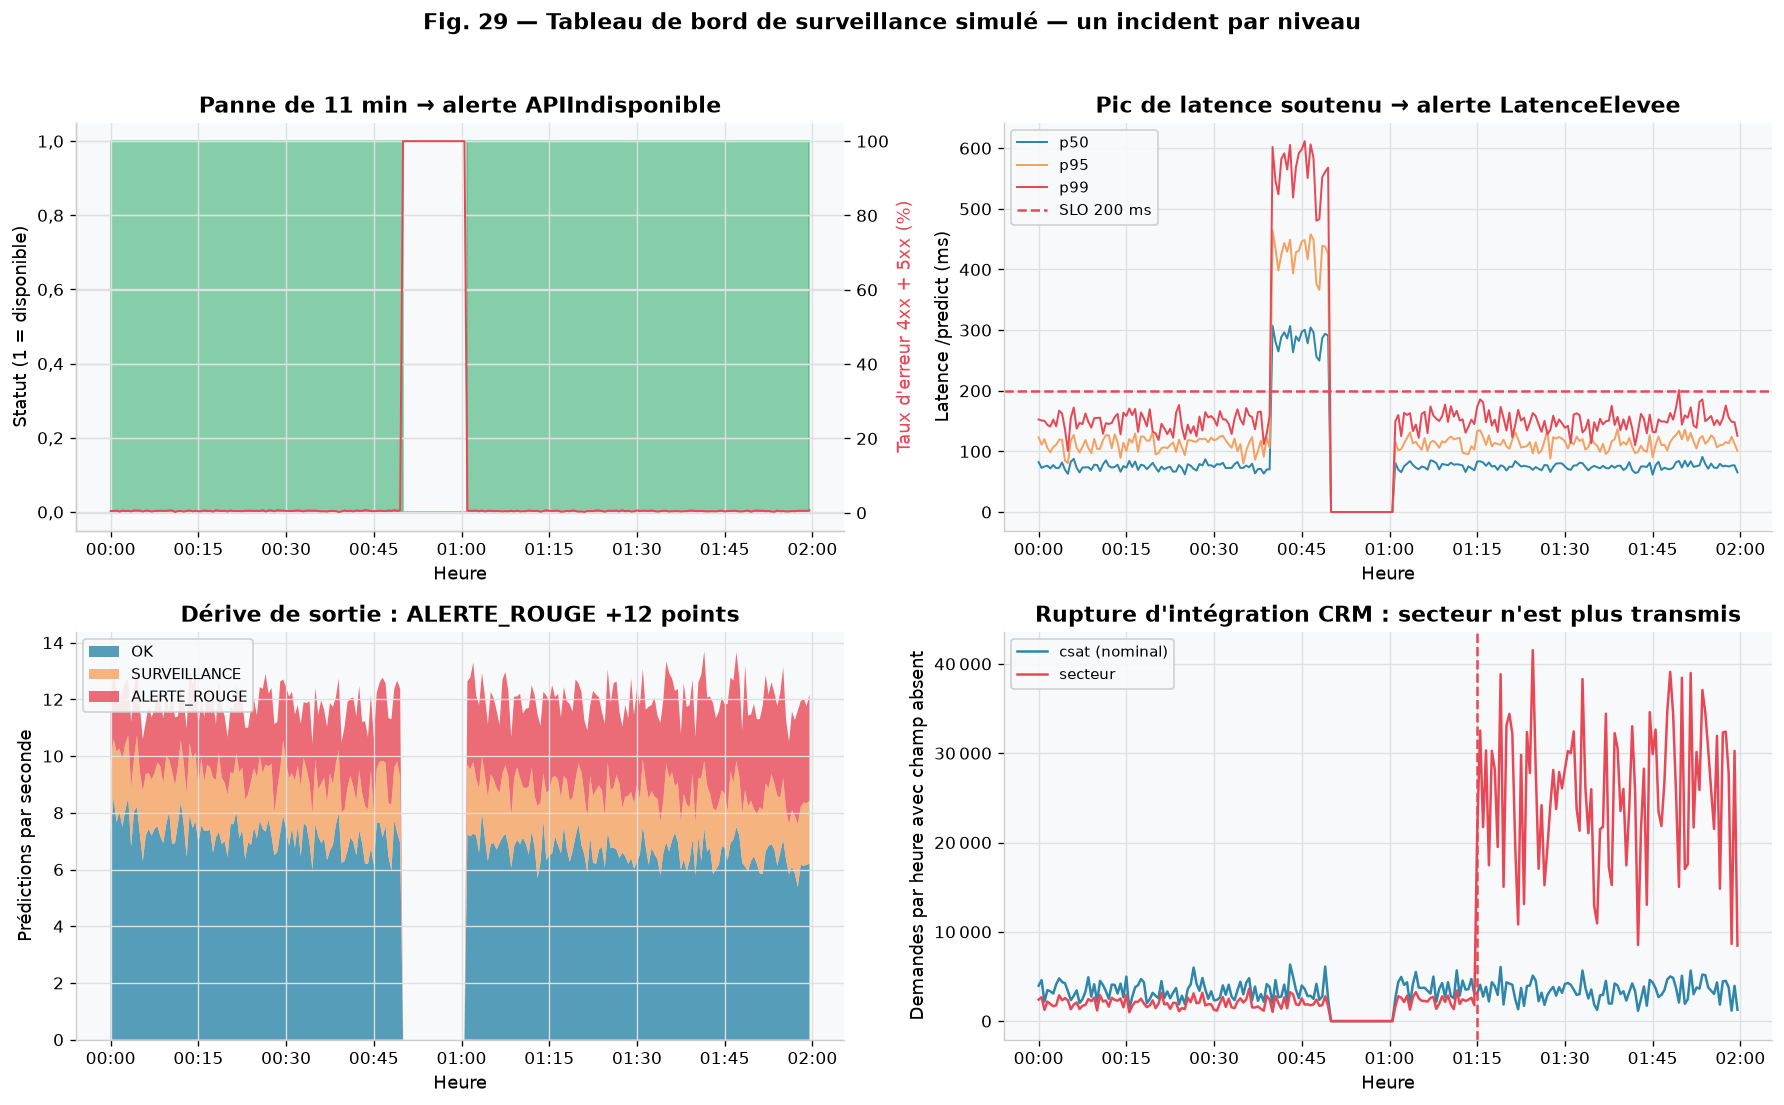

In [164]:
df_metriques = simuler_metriques()
fig = tracer_tableau_de_bord(df_metriques)
display(
    Markdown(
        f"Part `ALERTE_ROUGE` : {pourcentage(df_metriques.attrs['taux_alerte_ref'], 0)} → "
        f"{pourcentage(df_metriques.attrs['taux_alerte_fin'], 0)} (tolérance du runbook : "
        f"±{entier(df_metriques.attrs['tolerance_pts'])} points)."
    )
)

**Ce qu'il faut retenir.** Chaque incident n'est visible que sur son panel. La panne et le pic
de latence, plus longs que leur délai `for`, déclenchent leur alerte, alors qu'un pic de
quelques secondes ne le ferait pas. La dérive de sortie dépasse la tolérance du runbook et
déclenche le retour arrière (§13.8). La rupture CRM ne produit **aucune erreur** (le champ
est facultatif, la réponse reste un succès) et ne déplace pas tout de suite les scores, car
le pipeline impute : seul le compteur de champs absents la révèle à temps.

---
### 13.10 Versioning et gouvernance — les quatre dimensions

Pour expliquer une prédiction après coup, il faut retrouver le code, les données, le modèle
et la configuration qui l'ont produite.

| Dimension | Outil | Commande | Responsable | Rétention |
|---|---|---|---|---|
| Code | Git + tags `vMAJEUR.MINEUR.CORRECTIF` | `git tag v1.2.0 && git push --tags` | Data Scientist | Illimitée |
| Données | DVC (`data/gold/gold_dataset.parquet.dvc`), stockage objet cible | `dvc add … && dvc push` | Data Scientist | 3 ans, puis suppression (§4.1) |
| Modèle | Registry (registre de modèles) MLflow : une version par promotion, alias `@production` | `stage_promote` | Data Scientist, validation CS Lead | Toutes les versions et archives, sans purge |
| Configuration | `src/churn_saas/config.py`, seule source de vérité | Pull request revue | Data Scientist, revue par un pair | Historique git |

**Ce qu'il faut retenir.** À partir du `run_id` MLflow, on retrouve la version du code, celle
des données (empreinte DVC) et les hyperparamètres. Le registre utilise des **alias** plutôt
que les anciens statuts `Staging`/`Production`, dépréciés : revenir en arrière revient à
replacer `@production` sur une version antérieure. Le comité décide de lancer un
réentraînement ; seule la gate déplace l'alias. On évite ainsi un réentraînement sans
discussion comme une mise en production d'un modèle qui régresse.

---
### 13.11 Périodicité de revue — comité trimestriel

Un rythme de revue fixé après coup s'adapterait aux résultats : il a donc été décidé au
cadrage (§2.6) et il est repris ici à l'identique. Revue trimestrielle (mars, juin,
septembre, décembre), plus un comité ad hoc dès qu'un seuil de §13.8 est franchi, avec
décision sous 72 h. Membres : CS Lead (cohérence avec le terrain), Data Scientist
(métriques), DPO (conformité RGPD du trimestre) ; l'équipe Ops est invitée pour
l'exploitation, le commanditaire quand un investissement est à arbitrer.

**Ordre du jour (60 min).** Alertes du trimestre (10) ; rapports de dérive hebdomadaires
(10) ; performance sur les cohortes de renouvellement (15) ; **valeur réalisée** (10) ; âge
du modèle et décision réentraîner, maintenir ou geler (10) ; pistes de §13.1 (5).

**Valeur réalisée.** Le gain annoncé en §12.12 est une **simulation** (portefeuille figé,
taux de succès des actions repris d'un rapport sectoriel). Le comité le remplace peu à peu
par une mesure :

| Élément | Définition |
|---|---|
| Mesure | Par vague de renouvellements : taux de départ des comptes **contactés** contre celui du **groupe témoin** (§4.5). L'écart, valorisé en MRR × marge × horizon, moins le coût des actions, donne le gain réel |
| Taux de succès mesuré | (départs témoin − départs contactés) / départs témoin : remplace l'hypothèse de `config.HYPOTHESES_ECONOMIQUES` |
| Première lecture | À la première vague dont les résiliations sont observées (1 à 12 mois, §13.7) |
| Règle de décision | Sous la borne basse de la fourchette de §12.12 deux comités de suite : mise à jour du taux de succès, recalcul du bilan, revue de la règle d'action avec le CS Lead. Au-dessus de la borne haute : vérifier d'abord le tirage du groupe témoin |

Tant que cette mesure n'existe pas, les montants en euros restent des ordres de grandeur.

> ### 📋 Journal de bord — Amélioration continue
>
> **Décisions retenues** — Deux verrous : test de non-régression dans la CI et gate de
> promotion du réentraînement, sur les mêmes seuils de configuration. Prefect, déjà en place
> pour le scoring, orchestre le rapport de dérive (planifié chaque lundi) et le réentraînement
> (déclenché à la main par le comité). Robustesse mesurée sur un clone réentraîné sur 80 % des
> données, le modèle final ayant tout vu. Surveillance à quatre niveaux, dont la qualité des
> entrées reçues : un champ que le CRM ne transmet plus ne produit ni erreur ni dérive
> immédiate du score. Deux alertes filtrées contre la fatigue d'alerte. Délai des étiquettes
> traité par signaux sans étiquette, cohortes et groupe témoin. Valeur réalisée mesurée en
> comité contre le gain simulé.
>
> **Alternatives écartées** — Réentraînement automatique sur alerte PSI ou planifié sans
> comité : une panne de données se corrige, elle ne s'apprend pas. Airflow ou Prefect Cloud :
> infrastructure non justifiée pour un pilote, le serveur Prefect auto-hébergé suffit. Alerte
> sur le p99 : trop instable à faible volume. Alerte sur les champs absents : pas encore de
> référence de production, seuil arbitraire. Quatre figures de monitoring simulé, réduites à
> une seule, le code allant dans `monitoring/simulation_grafana.py`.
>
> **Difficultés rencontrées** — Le réentraînement à relances codées à la main a cédé la place à
> Prefect, dont le cache, incapable d'identifier de façon fiable un pipeline scikit-learn, est
> désactivé au profit d'un marqueur daté (`--forcer`). Surveillance et dérive démontrées sur
> données simulées : seuils d'alerte jamais confrontés à un trafic réel.
>
> **Impact sur la suite** — Le dispositif de suivi est complet ; la conclusion (§14) s'appuie
> dessus pour juger l'exploitabilité du projet.

## 14. Conclusion

On veut répondre à trois questions du commanditaire : que sait faire la solution, comment
l'utiliser chaque mois, et où ne pas s'y fier. Tous les chiffres viennent de
`charger_synthese()`, la même fonction que le résumé exécutif (§1) : début et fin du notebook
affichent donc les mêmes valeurs, relues depuis les artefacts des §9 et §12.

In [165]:
from IPython.display import Markdown, display

from churn_saas import config
from churn_saas.format_fr import entier, euros, nombre, pourcentage, styler_fr
from churn_saas.models.economics import table_deux_niveaux
from churn_saas.synthese import charger_synthese

synthese = charger_synthese()
y = synthese.y
cibles = config.CIBLES_PERFORMANCE
bilan = synthese.bilan
reference = synthese.reference
attribution = synthese.attribution
annuel = synthese.gain_annuel
concentration = synthese.concentration
latence = synthese.latence
protocole = synthese.protocole
# Note de référence : le jeu de test de §9.14, mis de côté avant tout choix
test = synthese.test

# Baselines non optimisées comparées sur les mêmes plis (§9.3)
comparaison = synthese.comparaison_modeles["pr_auc_mean"]
pr_auc_lr = comparaison["Baseline — régression logistique"]
pr_auc_lgbm = comparaison["LightGBM"]

# Cible secondaire : même règle de sélection qu'en §12.10
tableau_clv = synthese.tableau_clv
champion_clv = synthese.champion_clv
metriques_clv = tableau_clv.loc[champion_clv]
clv_conforme = synthese.champion_clv_conforme is not None

fourchette_annuelle = (
    f"{euros(annuel['annuel_min'])} à {euros(annuel['annuel_max'])} pour un taux de succès "
    f"des gestes de {pourcentage(annuel['taux_succes_min'], 0)} à "
    f"{pourcentage(annuel['taux_succes_max'], 0)}"
)


def _verdict(atteint: bool) -> str:
    return "✅" if atteint else "❌"


def _avec_ic(cle: str, format_valeur=lambda v: nombre(v, 3)) -> str:
    t = test[cle]
    return (
        f"**{format_valeur(t['valeur'])}** "
        f"[{format_valeur(t['ic_bas'])} ; {format_valeur(t['ic_haut'])}]"
    )

### 14.1 Synthèse des résultats

In [166]:
display(Markdown(f"""
**Le modèle livré** est une **{synthese.nom_modele_final}** (choisie en §9.12, réapprise sur
toutes les données en §9.15). À protocole identique
(§9.3), LightGBM obtenait une PR-AUC moyenne de {nombre(pr_auc_lgbm, 3)} contre
{nombre(pr_auc_lr, 3)} pour la régression logistique : l'écart ne justifiait pas un modèle plus
complexe et moins lisible (règle de complexité, §9.7).

| Indicateur | Valeur [IC 95 %] | Cible fixée *a priori* (§8.2) | Atteinte |
|---|---|---|---|
| PR-AUC (aire sous la courbe précision-rappel), jeu de test | {_avec_ic('pr_auc')} | ≥ {nombre(cibles['pr_auc_min'], 2)} | {_verdict(test['pr_auc']['valeur'] >= cibles['pr_auc_min'])} |
| ROC-AUC (aire sous la courbe ROC), jeu de test | {_avec_ic('roc_auc')} | ≥ {nombre(cibles['roc_auc_min'], 2)} | {_verdict(test['roc_auc']['valeur'] >= cibles['roc_auc_min'])} |
| Recall (rappel) au seuil de vigilance, jeu de test | {_avec_ic('recall', lambda v: pourcentage(v, 1))} | ≥ {pourcentage(cibles['recall_vigilance_min'], 0)} | {_verdict(test['recall']['valeur'] >= cibles['recall_vigilance_min'])} |
| PR-AUC en validation croisée : 15 plis (moyenne ± écart-type) ; hors pli, tout le portefeuille | {nombre(protocole['pr_auc_mean'], 3)} ± {nombre(protocole['pr_auc_std'], 3)} ; {nombre(synthese.pr_auc_oof, 3)} | — | — |
| Latence unitaire, 95e centile (§9.13) | {nombre(latence['latence_unitaire_ms_p95'], 1)} ms | ≤ {entier(cibles['latence_unitaire_ms'])} ms | {_verdict(latence['latence_unitaire_ms_p95'] <= cibles['latence_unitaire_ms'])} |
| Lot de {entier(latence['n_batch'])} comptes (§9.13) | {nombre(latence['latence_batch_5k_s'], 1)} s | ≤ {entier(cibles['latence_batch_5k_s'])} s | {_verdict(latence['latence_batch_5k_s'] <= cibles['latence_batch_5k_s'])} |
| Équité par pays, taille et secteur (§12.14) | {"écarts sous les seuils du §4.4" if not synthese.attributs_equite_a_revoir else "revue requise : " + ", ".join(synthese.attributs_equite_a_revoir)} | seuils du §4.4 | {_verdict(not synthese.attributs_equite_a_revoir)} |

Le **jeu de test** (§9.14) regroupe {pourcentage(config.PART_TEST, 0)} des comptes, mis de côté avant tout choix et notés une
seule fois : c'est la note de référence, avec son intervalle de confiance (bootstrap,
rééchantillonnage des comptes du test). « Hors pli » (out-of-fold) : chaque compte est noté par
un modèle qui ne l'a pas vu ; ces prédictions couvrent tout le portefeuille et servent aux euros.
Un tri au hasard obtiendrait une PR-AUC égale à la part de churners, soit
{pourcentage(y.mean(), 0)}.

**La valeur apportée** se mesure contre ce que ferait l'équipe sans modèle, à budget égal :
appeler ses {entier(synthese.capacite)} plus gros comptes du mois (§12.12).

- Liste du modèle : **{entier(bilan['n_churners'])} churners sur {entier(bilan['n_contactes'])}
  comptes appelés**, contre {entier(reference['n_churners'])} pour la liste sans modèle.
- Marge espérée en plus : **{euros(attribution['gain_attribuable'])} le premier mois** et
  **{euros(annuel['annuel'])} sur un an** ({fourchette_annuelle}), soit
  {nombre(annuel['annuel'] / annuel['premier_mois'], 1)} fois le premier mois et non 12 fois :
  les gros comptes à risque ne se découvrent qu'une fois, le modèle les atteint surtout plus tôt.
- Gain concentré : {entier(concentration['n_top'])} comptes font
  {pourcentage(concentration['part_top'], 0)} du gain du premier mois.

**La cible secondaire**, la valeur vie client (CLV, régression, §12.10) : `{champion_clv}`
explique {pourcentage(metriques_clv['r2'], 0)} de sa variabilité (R²) et réduit l'erreur moyenne
de {pourcentage(metriques_clv['gain_mae'], 0)} par rapport à la baseline (référence de base)
médiane — {"cibles du §8.2 atteintes" if clv_conforme else "⚠️ cibles du §8.2 non atteintes, modèle non déployable"}.
Elle sert à prioriser, jamais de feature (variable explicative) du churn.
"""))


**Le modèle livré** est une **régression logistique optimisée et recalibrée** (choisie en §9.12, réapprise sur
toutes les données en §9.15). À protocole identique
(§9.3), LightGBM obtenait une PR-AUC moyenne de 0,762 contre
0,787 pour la régression logistique : l'écart ne justifiait pas un modèle plus
complexe et moins lisible (règle de complexité, §9.7).

| Indicateur | Valeur [IC 95 %] | Cible fixée *a priori* (§8.2) | Atteinte |
|---|---|---|---|
| PR-AUC (aire sous la courbe précision-rappel), jeu de test | **0,760** [0,710 ; 0,804] | ≥ 0,65 | ✅ |
| ROC-AUC (aire sous la courbe ROC), jeu de test | **0,881** [0,857 ; 0,903] | ≥ 0,80 | ✅ |
| Recall (rappel) au seuil de vigilance, jeu de test | **81,8 %** [77,4 % ; 86,3 %] | ≥ 75 % | ✅ |
| PR-AUC en validation croisée : 15 plis (moyenne ± écart-type) ; hors pli, tout le portefeuille | 0,788 ± 0,019 ; 0,784 | — | — |
| Latence unitaire, 95e centile (§9.13) | 32,6 ms | ≤ 200 ms | ✅ |
| Lot de 5 000 comptes (§9.13) | 0,1 s | ≤ 300 s | ✅ |
| Équité par pays, taille et secteur (§12.14) | écarts sous les seuils du §4.4 | seuils du §4.4 | ✅ |

Le **jeu de test** (§9.14) regroupe 20 % des comptes, mis de côté avant tout choix et notés une
seule fois : c'est la note de référence, avec son intervalle de confiance (bootstrap,
rééchantillonnage des comptes du test). « Hors pli » (out-of-fold) : chaque compte est noté par
un modèle qui ne l'a pas vu ; ces prédictions couvrent tout le portefeuille et servent aux euros.
Un tri au hasard obtiendrait une PR-AUC égale à la part de churners, soit
28 %.

**La valeur apportée** se mesure contre ce que ferait l'équipe sans modèle, à budget égal :
appeler ses 45 plus gros comptes du mois (§12.12).

- Liste du modèle : **31 churners sur 45
  comptes appelés**, contre 12 pour la liste sans modèle.
- Marge espérée en plus : **1 288 829 € le premier mois** et
  **1 451 797 € sur un an** (967 865 € à 1 935 730 € pour un taux de succès des gestes de 20 % à 40 %), soit
  1,1 fois le premier mois et non 12 fois :
  les gros comptes à risque ne se découvrent qu'une fois, le modèle les atteint surtout plus tôt.
- Gain concentré : 5 comptes font
  26 % du gain du premier mois.

**La cible secondaire**, la valeur vie client (CLV, régression, §12.10) : `lgbm_log`
explique 71 % de sa variabilité (R²) et réduit l'erreur moyenne
de 53 % par rapport à la baseline (référence de base)
médiane — cibles du §8.2 atteintes.
Elle sert à prioriser, jamais de feature (variable explicative) du churn.


**Ce qu'il faut retenir.** Le modèle tient ses cibles fixées avant l'entraînement, en
performance, mesurée sur des comptes jamais vus, comme en latence. Sa valeur ne vient pas d'un « ROI contre l'inaction » mais de
l'écart avec la pratique actuelle : à budget d'appels égal, il trouve plus de partants parmi
les comptes à fort enjeu, et plus tôt. Les montants en euros dépendent d'hypothèses
économiques encore à mesurer (§14.3).

### 14.2 Règle de décision à deux niveaux

Un seul seuil devait arbitrer entre deux objectifs contraires : ne manquer aucun partant, et
ne pas noyer une équipe qui ne peut passer qu'un nombre limité d'appels. On les sépare donc
(§12.6). Le **niveau 1, vigilance**, fixe le threshold (seuil) au plus haut score qui détecte
encore la part visée des churners : le recall (rappel) cible, mesuré hors pli. Ces comptes
reçoivent une surveillance peu coûteuse (actions automatisées, revue hebdomadaire). Le
**niveau 2, appels**, retient parmi eux les comptes où un geste CSM rapporte le plus en
espérance, dans la limite de la capacité de l'équipe.

In [167]:
deux_niveaux = table_deux_niveaux(y, synthese.proba_oof, synthese.mrr)
colonnes = {
    "niveau": "Niveau",
    "n_comptes": "Comptes",
    "part_portefeuille": "Part du portefeuille",
    "n_churners": "Churners détectés",
    "recall": "Recall",
    "precision": "Precision",
    "n_faux_negatifs": "Churners manqués",
    "valeur_faux_negatifs_eur": "Marge des manqués",
}
display(
    Markdown(
        f"Seuil de vigilance : **{nombre(deux_niveaux.loc[0, 'seuil'], 3)}** pour un recall cible "
        f"de {pourcentage(config.RECALL_CIBLE_VIGILANCE, 0)}."
    )
)
display(
    styler_fr(
        deux_niveaux[list(colonnes)].rename(columns=colonnes).set_index("Niveau"),
        {
            "Comptes": entier,
            "Part du portefeuille": pourcentage,
            "Churners détectés": entier,
            "Recall": pourcentage,
            "Precision": pourcentage,
            "Churners manqués": entier,
            "Marge des manqués": euros,
        },
    )
)
vigilance, appels = deux_niveaux.iloc[0], deux_niveaux.iloc[1]

Seuil de vigilance : **0,277** pour un recall cible de 80 %.

,Comptes,Part du portefeuille,Churners détectés,Recall,Precision,Churners manqués,Marge des manqués
Niveau,,,,,,,
1 — vigilance (seuil de recall),1 813,"36,3 %",1 120,"80,0 %","61,8 %",280,7 072 313 €
2 — appels (capacité 45),45,"0,9 %",31,"2,2 %","68,9 %",1 369,24 096 956 €


In [168]:
display(Markdown(f"""
**Ce qu'il faut retenir.** Le niveau 1 signale {entier(vigilance['n_comptes'])} comptes
({pourcentage(vigilance['part_portefeuille'], 0)} du portefeuille) et n'en laisse échapper que
{entier(vigilance['n_faux_negatifs'])} churners : c'est lui qui limite les faux négatifs. Sur le
jeu de test, un seuil appris sans lui détecte {pourcentage(test['recall']['valeur'], 0)} des
partants : la promesse tient sur de nouveaux comptes. Le
niveau 2 n'appelle que {entier(appels['n_comptes'])} comptes, avec une precision (précision) de
{pourcentage(appels['precision'], 0)} : son rôle n'est pas de couvrir tous les partants mais de
placer les heures CSM là où elles rapportent le plus. Le seuil appris est persisté dans
`seuil_vigilance.json` et relu par l'API et le batch (traitement par lot) nocturne.
"""))


**Ce qu'il faut retenir.** Le niveau 1 signale 1 813 comptes
(36 % du portefeuille) et n'en laisse échapper que
280 churners : c'est lui qui limite les faux négatifs. Sur le
jeu de test, un seuil appris sans lui détecte 82 % des
partants : la promesse tient sur de nouveaux comptes. Le
niveau 2 n'appelle que 45 comptes, avec une precision (précision) de
69 % : son rôle n'est pas de couvrir tous les partants mais de
placer les heures CSM là où elles rapportent le plus. Le seuil appris est persisté dans
`seuil_vigilance.json` et relu par l'API et le batch (traitement par lot) nocturne.


### 14.3 Limites assumées

Connaître les limites d'un modèle, c'est savoir où ne pas s'y fier.

| Famille | Limite | Conséquence | Mitigation |
|---|---|---|---|
| Données | Une seule extraction, tous les comptes photographiés à la même date | Aucune validation temporelle possible (§6.11) | Cross-validation (validation croisée) stratifiée répétée (§8.8) et jeu de test stratifié (§9.14) ; validation temporelle sur extractions successives (§13.7) |
| Données | `commentaire_csm` exclu | Date de rédaction inconnue : data leakage (fuite de données) non exclu (§6.6) | Réintégrable si le CRM horodate chaque commentaire |
| Données | `valeur_vie_client_eur` de méthode non documentée | CLV qui intègre déjà le risque de départ (§6.7) | Valeur à risque = MRR × horizon (§12.11) ; méthode à documenter avec la Finance |
| Économie | Taux de succès d'un geste issu d'un rapport sectoriel | Gain en euros conditionnel, pas mesuré | Sensibilité (§12.7) ; mesure par groupe témoin |
| Économie | Gain concentré sur quelques gros comptes | Une erreur sur leur MRR fausse le bilan (§12.12) | Validation du MRR par la Finance |
| Économie | Coût d'un geste limité au temps CSM ; coût du projet estimé, non devisé | Remises non comptées ; ROI du projet conditionnel | Valeur mesurée contre une liste sans modèle, à coût égal ; taux de succès d'équilibre (§12.12) ; coûts à confirmer par le contrôle de gestion |
| Modèle | Cible sans horizon défini | Suivi en production difficile (§13.7) | Horizon à fixer avec le métier avant le réentraînement |
| Modèle | Étiquettes connues 1 à 12 mois après la prédiction | Performance non mesurable en temps réel | Dérive des entrées suivie immédiatement (PSI/KS, §13.3) ; évaluation par cohorte de renouvellements (§13.7) |
| Modèle | Calibration (accord score / fréquence observée) liée à la part de churners actuelle | Si elle change, scores et euros se décalent | Contrôle à chaque vague de renouvellements ; réestimation au réentraînement |
| Modèle | Un seul jeu de test, de taille modeste | Note de référence bruitée | Intervalle de confiance par bootstrap (§9.14) ; évaluation par cohorte en production (§13.7) |
| Modèle | Régression CLV évaluée sur un seul découpage (test de 20 %) | Pas d'intervalle de confiance sur R² et MAE | Validation croisée répétée au prochain cycle (§13.1) |
| Technique | Monitoring (surveillance) démontré sur données simulées (§13.9) | Seuils d'alerte non confrontés au trafic réel | Calage sur les premiers mois de production |
| Technique | CodeCarbon sous WSL2 | Empreinte carbone estimée, non mesurée (§9.8) | Déclaration explicite, facteur d'émission France |

**Ce qu'il faut retenir.** Aucune limite n'invalide le modèle, mais deux familles pèsent plus
que les autres : les hypothèses économiques conditionnent les montants annoncés, le délai des
étiquettes et l'horizon de la cible conditionnent la mesure de la performance réelle. La
feuille de route vise d'abord ces deux familles.

### 14.4 Recommandations et feuille de route

**Avant le déploiement**

1. **Déployer le scoring (calcul des scores) nocturne** (`flows/scoring_batch.py`) : les
   scores et le niveau de chaque compte alimentent le CRM chaque nuit ; le passage du dimanche
   nourrit la revue CS du lundi.
2. **Mettre en place un groupe témoin** (environ 10 % des comptes signalés, tirés au sort et
   laissés sans geste, §4.5). Les gestes changent l'issue des comptes traités : seul ce groupe
   fournit des étiquettes non biaisées et mesure l'effet net des gestes.
3. **Mesurer les hypothèses économiques** dans le CRM : durée et nombre de gestes dès le
   premier mois, taux de succès au fil des renouvellements, par comparaison au groupe témoin.

**Chantiers de données en parallèle** : faire valider par la Finance le MRR des gros comptes ;
fixer avec le CS Lead l'horizon de la cible (3, 6 ou 12 mois) ; horodater `commentaire_csm`.

**En production** : un signal de dérive convoque le comité trimestriel (§13.11), il ne
réentraîne jamais seul. Un nouveau modèle n'est promu que s'il passe la gate (règle de
promotion) du §10.4 et si son recall au seuil de vigilance reste au-dessus du minimum du §8.2.

**Feuille de route** — pistes classées par rapport impact / effort (§13.1) ; les gains de
PR-AUC sont des ordres de grandeur à confirmer par expérimentation.

| Priorité | Piste | Gain supposé | Effort |
|---|---|---|---|
| 1 | Données d'usage fines (événements par fonctionnalité au lieu d'agrégats sur 30 jours) : voir la baisse d'engagement dès son apparition | +0,04 à +0,08 de PR-AUC | 2 mois-ingénieur |
| 2 | Historique sur 3 ans (durée de conservation du §4.1) : mieux capter les cycles de renouvellement longs | +0,03 à +0,06 de PR-AUC | 1 mois-ingénieur |
| 3 | Modèle de survie : prédire *quand* le client part, pour prioriser les échéances proches | autre métrique (C-index) | 3 mois-ingénieur |

Écartés à court terme : un modèle de langage sur `commentaire_csm`, qui n'est qu'un jeu de
libellés normalisés et dont l'exclusion tient à la fuite, pas à la technique (§6.6) ;
l'inférence en flux continu, inutile pour un phénomène qui évolue sur des semaines avec des
sources rafraîchies une fois par jour.

In [169]:
display(Markdown(f"""
**Ce qu'il faut retenir.** Le modèle place les futurs partants en tête de liste : PR-AUC de
{nombre(test['pr_auc']['valeur'], 3)} sur des comptes jamais vus, contre {nombre(y.mean(), 2)} au
hasard. La règle à deux
niveaux surveille {entier(vigilance['n_comptes'])} comptes pour ne manquer que
{pourcentage(1 - vigilance['recall'], 0)} des churners, et concentre les
{entier(appels['n_comptes'])} appels mensuels là où ils rapportent le plus : environ
{euros(annuel['annuel'])} de marge espérée sur un an de plus qu'une équipe sans modèle, sous
réserve des hypothèses économiques. *Le modèle classe, le CSM décide* : aucune action n'est
déclenchée sans intervention humaine. **Décision attendue** : lancer le scoring nocturne avec
groupe témoin, puis réviser les hypothèses à chaque comité trimestriel.
"""))


**Ce qu'il faut retenir.** Le modèle place les futurs partants en tête de liste : PR-AUC de
0,760 sur des comptes jamais vus, contre 0,28 au
hasard. La règle à deux
niveaux surveille 1 813 comptes pour ne manquer que
20 % des churners, et concentre les
45 appels mensuels là où ils rapportent le plus : environ
1 451 797 € de marge espérée sur un an de plus qu'une équipe sans modèle, sous
réserve des hypothèses économiques. *Le modèle classe, le CSM décide* : aucune action n'est
déclenchée sans intervention humaine. **Décision attendue** : lancer le scoring nocturne avec
groupe témoin, puis réviser les hypothèses à chaque comité trimestriel.


## 15. Annexes

Cette section rassemble ce qui sert à **reproduire**, **auditer** et **comprendre** le projet,
sans alourdir le corps du notebook : environnement et bibliothèques, hyperparamètres des
modèles optimisés, carte du code, traçabilité des compétences du référentiel item par item,
glossaire et références.

In [170]:
import importlib
import importlib.metadata
import inspect
import pkgutil
import re
import sys
import warnings

import pandas as pd
from IPython.display import Markdown, display
from packaging.requirements import Requirement

import churn_saas
from churn_saas import config
from churn_saas.cache import charger
from churn_saas.format_fr import entier, nombre, nombre_tableau, styler_fr
from churn_saas.referentiel import (
    COMPETENCES,
    localiser_items,
    numero_sous_section,
    relever_titres,
    titre_sans_numero,
)
from churn_saas.synthese import artefact_du_modele

### 15.1 Environnement de reproduction

Pour refaire le calcul à l'identique, il faut les mêmes bibliothèques aux mêmes versions. On
liste donc **toutes** les dépendances déclarées dans `pyproject.toml` (lues dans les
métadonnées du paquet installé, pas recopiées), avec la version réellement installée.

In [171]:
_lignes_versions = []
for _exigence in importlib.metadata.requires("churn-saas") or []:
    _req = Requirement(_exigence)
    _extra = re.search(r"extra == ['\"](\w+)['\"]", str(_req.marker or ""))
    try:
        _installee = importlib.metadata.version(_req.name)
    except importlib.metadata.PackageNotFoundError:
        _installee = "non installée"
    _lignes_versions.append(
        {
            "Bibliothèque": _req.name,
            "Groupe (extra)": _extra.group(1) if _extra else "socle",
            "Contrainte déclarée": str(_req.specifier) or "—",
            "Version installée": _installee,
        }
    )
_df_versions = pd.DataFrame(_lignes_versions).sort_values(["Groupe (extra)", "Bibliothèque"])
_non_installees = _df_versions.loc[_df_versions["Version installée"] == "non installée"]
display(
    Markdown(
        f"**Python** `{sys.version.split()[0]}` sur `{sys.platform}` · graine unique "
        f"`config.RANDOM_SEED` = `{config.RANDOM_SEED}` · {entier(len(_df_versions))} "
        f"dépendances déclarées, {entier(len(_non_installees))} non installée(s)"
    )
)
display(styler_fr(_df_versions).hide(axis="index"))

**Python** `3.12.13` sur `linux` · graine unique `config.RANDOM_SEED` = `42` · 44 dépendances déclarées, 0 non installée(s)

Bibliothèque,Groupe (extra),Contrainte déclarée,Version installée
fastapi,api,>=0.116.2,0.141.1
httpx2,api,>=2.13.1,2.13.1
lightgbm,api,>=4.7.0,4.7.0
prometheus-fastapi-instrumentator,api,>=7,8.1.0
starlette,api,>=0.48,1.6.0
uvicorn,api,>=0.30,0.53.0
httpx,demo,>=0.27,0.28.1
streamlit,demo,>=1.35,1.64.0
black,dev,>=24.4,26.5.1
mypy,dev,>=1.10,2.3.1


**Ce qu'il faut retenir.** Le tableau donne la contrainte de version acceptée par le projet et
la version utilisée pour produire ce notebook. Les versions exactes de toutes les dépendances,
y compris indirectes, sont figées dans `uv.lock` : c'est ce fichier qui garantit la
reproduction. Pour tout relancer :

```bash
git clone https://github.com/laurent-git-dev/churn_saas_release churn_saas && cd churn_saas
uv sync --frozen --all-extras   # Python 3.12 et dépendances aux versions exactes de uv.lock
# copier les données brutes (exclues de git, fournies dans l'archive) dans data/raw/
make notebook                   # réutilise les étapes lourdes déjà calculées (reports/tables/)
make notebook-full              # recalcule tout depuis les données brutes (Optuna, SHAP…)
make check                      # lint, tests, puis exécution complète du notebook
```

Le tableau précédent dit **quelles versions** ; celui-ci dit **à quoi sert** chacune des
bibliothèques citées en page de garde, et où le notebook l'emploie. Comme en §15.4, les renvois
sont retrouvés à partir des titres réels des sous-sections.

In [172]:
# Numéro de chaque sous-section, retrouvé depuis son titre
_numeros = {titre_sans_numero(t): numero_sous_section(t) for t in relever_titres()["titre"]}
_GOLD = "Jeu de données gold — schéma, volumétrie et versioning"
_OPTUNA = "Optimisation des hyperparamètres (Optuna)"
_MLFLOW = "Journalisation MLflow"
_CONTRAT_API = "Contrat d'API — schémas Pydantic"
# fmt: off
_BIBLIOTHEQUES = [
    ("pandas", "Tableaux de données en mémoire : lecture, filtres, jointures, agrégats", "Toute la chaîne : chargement, nettoyage, tableaux de résultats", ["Nettoyage", _GOLD]),
    ("numpy", "Calcul vectorisé sur des tableaux de nombres", "Socle de pandas, scikit-learn et LightGBM ; calculs de métriques", []),
    ("pyarrow", "Lecture et écriture du format colonnaire Parquet", "Stockage du jeu gold et des tables intermédiaires", ["Choix du modèle de stockage — note d'arbitrage", _GOLD]),
    ("dvc", "Versionnement des gros fichiers de données à côté de git, par empreinte", "Version du jeu gold reliée au code qui l'a produit", ["Versioning DVC", "Versioning sur quatre axes"]),
    ("scipy", "Tests statistiques et lois de probabilité", "Hypothèses métier, comparaison des modèles, dérive", ["Test des hypothèses métier H1 à H14", "L'écart est-il significatif ? — Wilcoxon apparié et correction de Holm", "Dérive des entrées — PSI et test de Kolmogorov-Smirnov"]),
    ("matplotlib", "Tracé de figures", "Toutes les figures, au style unique de `churn_saas.viz`", []),
    ("scikit-learn", "Pipelines de transformation, modèles classiques, validation croisée, métriques", "Préparation anti-fuite, régression logistique, forêt aléatoire, évaluation", ["Stratégie anti-fuite — explication avant le code", "Familles candidates pour des données tabulaires", "Métriques techniques de classification"]),
    ("imbalanced-learn", "Rééchantillonnage des classes rares (dont SMOTE), compatible avec les pipelines", "Variante SMOTE, comparée à la pondération des classes", ["Gestion du déséquilibre — class_weight, correction d'intercept, SMOTE"]),
    ("lightgbm", "Boosting de gradient sur arbres de décision, rapide sur données tabulaires", "Famille d'arbres optimisée, concurrente de la régression logistique", ["Familles candidates pour des données tabulaires", _OPTUNA]),
    ("optuna", "Recherche des meilleurs hyperparamètres, chaque essai guidé par les précédents", "Optimisation de la régression logistique et de LightGBM", [_OPTUNA]),
    ("mlflow", "Journal des expériences (réglages, scores, modèles) et registre de modèles versionné", "Traçabilité des entraînements, alias `@production`, règle de promotion", [_MLFLOW, "MLflow — suivi des exécutions, registre et gate de promotion"]),
    ("skops", "Sauvegarde de modèles scikit-learn sans exécuter de code arbitraire au chargement, contrairement à pickle", "Format du modèle archivé dans MLflow", [_MLFLOW]),
    ("shap", "Valeurs de Shapley : part de chaque variable dans le score d'un compte", "Explication globale et compte par compte", ["SHAP — attributions additives (global et local)"]),
    ("codecarbon", "Estimation de l'énergie consommée et des émissions de CO₂ d'un calcul", "Empreinte du tuning et du modèle livré", ["Empreinte carbone du tuning", "Empreinte carbone (ESTIMATION)"]),
    ("fastapi", "Construction d'API web, avec documentation interactive générée", "API de prédiction appelée par le CRM", [_CONTRAT_API, "Modèle déployé et appels réels à l'API"]),
    ("pydantic", "Validation des données par types déclarés", "Rejet d'une requête mal formée avant qu'elle n'atteigne le modèle", [_CONTRAT_API]),
    ("uvicorn", "Serveur web qui fait tourner l'application FastAPI", "Lancement de l'API (`make api`, conteneur Docker)", ["Docker et Docker Compose"]),
    ("prefect", "Orchestration de tâches planifiées : enchaînement, reprises, historique", "Scoring nocturne et réentraînement", ["Démonstration du batch nocturne Prefect", "Plan de réentraînement — déclencheurs et retour arrière"]),
    ("evidently", "Rapports de dérive des données, variable par variable", "Contrôle de dérive sur toutes les variables", ["Rapport Evidently — dérive sur toutes les variables"]),
    ("prometheus-fastapi-instrumentator", "Exposition des compteurs de l'API (requêtes, erreurs, latence) au format Prometheus", "Surveillance du service en production", ["Surveillance du service — alertes, compteurs et fatigue d'alerte"]),
    ("jupytext", "Conversion entre scripts Python et notebooks Jupyter", "Génération de ce notebook depuis `notebooks/sections/`", []),
]
# fmt: on

_lignes_biblio = [
    f"| `{nom}` {importlib.metadata.version(nom)} | {role} | {usage} | "
    f"{', '.join(_numeros.get(c, '⚠️ introuvable') for c in cles) or '—'} |"
    for nom, role, usage, cles in _BIBLIOTHEQUES
]
display(
    Markdown(
        "| Bibliothèque | Ce qu'elle fait | Usage dans le projet | Voir |\n|---|---|---|---|\n"
        + "\n".join(_lignes_biblio)
        + f"\n\n{entier(len(_lignes_biblio))} bibliothèques · renvois introuvables : "
        f"{entier(sum(ligne.count('⚠️') for ligne in _lignes_biblio))}"
    )
)

| Bibliothèque | Ce qu'elle fait | Usage dans le projet | Voir |
|---|---|---|---|
| `pandas` 3.0.6 | Tableaux de données en mémoire : lecture, filtres, jointures, agrégats | Toute la chaîne : chargement, nettoyage, tableaux de résultats | §7.3, §7.8 |
| `numpy` 2.5.3 | Calcul vectorisé sur des tableaux de nombres | Socle de pandas, scikit-learn et LightGBM ; calculs de métriques | — |
| `pyarrow` 25.0.1 | Lecture et écriture du format colonnaire Parquet | Stockage du jeu gold et des tables intermédiaires | §3.3, §7.8 |
| `dvc` 3.67.1 | Versionnement des gros fichiers de données à côté de git, par empreinte | Version du jeu gold reliée au code qui l'a produit | §7.8.2, §10.5 |
| `scipy` 1.18.1 | Tests statistiques et lois de probabilité | Hypothèses métier, comparaison des modèles, dérive | §6.2, §9.3.1, §13.3 |
| `matplotlib` 3.11.2 | Tracé de figures | Toutes les figures, au style unique de `churn_saas.viz` | — |
| `scikit-learn` 1.9.1 | Pipelines de transformation, modèles classiques, validation croisée, métriques | Préparation anti-fuite, régression logistique, forêt aléatoire, évaluation | §7.2, §8.6, §12.2 |
| `imbalanced-learn` 0.14.2 | Rééchantillonnage des classes rares (dont SMOTE), compatible avec les pipelines | Variante SMOTE, comparée à la pondération des classes | §9.6 |
| `lightgbm` 4.7.0 | Boosting de gradient sur arbres de décision, rapide sur données tabulaires | Famille d'arbres optimisée, concurrente de la régression logistique | §8.6, §9.7 |
| `optuna` 5.0.0 | Recherche des meilleurs hyperparamètres, chaque essai guidé par les précédents | Optimisation de la régression logistique et de LightGBM | §9.7 |
| `mlflow` 3.16.1 | Journal des expériences (réglages, scores, modèles) et registre de modèles versionné | Traçabilité des entraînements, alias `@production`, règle de promotion | §9.5, §10.4 |
| `skops` 0.15.0 | Sauvegarde de modèles scikit-learn sans exécuter de code arbitraire au chargement, contrairement à pickle | Format du modèle archivé dans MLflow | §9.5 |
| `shap` 0.52.0 | Valeurs de Shapley : part de chaque variable dans le score d'un compte | Explication globale et compte par compte | §12.8.3 |
| `codecarbon` 3.3.1 | Estimation de l'énergie consommée et des émissions de CO₂ d'un calcul | Empreinte du tuning et du modèle livré | §9.8, §12.13 |
| `fastapi` 0.141.1 | Construction d'API web, avec documentation interactive générée | API de prédiction appelée par le CRM | §10.2, §10.3 |
| `pydantic` 2.13.5 | Validation des données par types déclarés | Rejet d'une requête mal formée avant qu'elle n'atteigne le modèle | §10.2 |
| `uvicorn` 0.53.0 | Serveur web qui fait tourner l'application FastAPI | Lancement de l'API (`make api`, conteneur Docker) | §10.7 |
| `prefect` 3.8.7 | Orchestration de tâches planifiées : enchaînement, reprises, historique | Scoring nocturne et réentraînement | §10.10, §13.8 |
| `evidently` 0.7.23 | Rapports de dérive des données, variable par variable | Contrôle de dérive sur toutes les variables | §13.4 |
| `prometheus-fastapi-instrumentator` 8.1.0 | Exposition des compteurs de l'API (requêtes, erreurs, latence) au format Prometheus | Surveillance du service en production | §13.9 |
| `jupytext` 1.19.5 | Conversion entre scripts Python et notebooks Jupyter | Génération de ce notebook depuis `notebooks/sections/` | — |

21 bibliothèques · renvois introuvables : 0

**Ce qu'il faut retenir.** Chaque bibliothèque couvre une étape précise du cycle de vie, et
aucune n'est là « au cas où ». Toutes sont libres et largement adoptées : aucune ne lie le
projet à un fournisseur, conformément à la contrainte posée par la DSI (§11.4). À zéro renvoi
introuvable, chaque usage annoncé pointe vers une sous-section qui existe.

### 15.2 Hyperparamètres retenus

Un hyperparamètre est un réglage choisi **avant** l'apprentissage (force de la pénalité,
nombre d'arbres…), à la différence des coefficients, appris sur les données. Optuna a cherché
les meilleurs réglages de deux familles (§9.7), la régression logistique et LightGBM : on
relit leurs résultats, puis les réglages du modèle livré, lus dans `modele_final.joblib`.

In [173]:
# fmt: off
_ROLES_HP = {
    "C": "Inverse de la force de pénalité : petit C = coefficients ramenés vers zéro",
    "max_iter": "Nombre maximal d'itérations accordées au solveur pour converger",
    "class_weight": "Pondère les erreurs selon la rareté de la classe, pour ne pas négliger les churners",
    "l1_ratio": "Part de pénalité L1 dans la pénalité totale : 0 = pénalité L2 pure",
    "solver": "Algorithme d'optimisation des coefficients",
    "random_state": "Graine unique du projet",
    "num_leaves": "Nombre maximal de feuilles par arbre : borne la complexité de chaque arbre",
    "learning_rate": "Poids de chaque nouvel arbre : petit = apprentissage lent mais prudent",
    "n_estimators": "Nombre d'arbres construits l'un après l'autre",
    "min_child_samples": "Nombre minimal de comptes par feuille : évite d'apprendre des cas isolés",
    "reg_lambda": "Pénalité L2 sur les valeurs des feuilles",
    "subsample": "Part des comptes tirée au hasard pour construire chaque arbre",
    "colsample_bytree": "Part des variables tirée au hasard pour construire chaque arbre",
}
# fmt: on


def _tableau_hp(params: dict, optimises: dict) -> pd.DataFrame:
    """Réglages optimisés puis réglages fixés par conception, avec leur rôle."""
    return pd.DataFrame(
        {
            "Hyperparamètre": cle,
            "Valeur": nombre_tableau(v) if isinstance(v := params[cle], float) else str(v),
            "Origine": "Optuna (§9.7)" if cle in optimises else "fixé",
            "Rôle": _ROLES_HP.get(cle, "—"),
        }
        for cle in dict.fromkeys([*optimises, *_ROLES_HP])
        if cle in params
    )


_runs_optuna = [
    charger(f.name) for f in sorted(config.TABLES.glob("optuna_*_meilleurs_params.json"))
]
_tableau_optuna = pd.DataFrame(
    {
        "Modèle": run["modele_nom"],
        "Essais": entier(run["n_essais_completes"]),
        "Durée (s)": nombre(run.get("duree_s"), 0),
        "PR-AUC par défaut": nombre(run["pr_auc_defaut"], 4),
        "PR-AUC optimisée": nombre(run["best_value"], 4),
        "Gain": nombre(float(run["best_value"]) - float(run["pr_auc_defaut"]), 4, signe=True),
    }
    for run in _runs_optuna
)
display(styler_fr(_tableau_optuna).hide(axis="index"))

# Le modèle livré est reconnu à ses hyperparamètres, ceux d'une des deux recherches Optuna
_clf = charger("modele_final.joblib")[-1]
_nom_livre = artefact_du_modele("optuna_*_meilleurs_params.json", _clf.get_params())["modele_nom"]
for _run in _runs_optuna:
    _livre = _run["modele_nom"] == _nom_livre
    _hp = _tableau_hp(_clf.get_params() if _livre else _run["best_params"], _run["best_params"])
    _statut = "Modèle livré" if _livre else "Concurrent optimisé"
    display(Markdown(f"**{_statut}** : {_run['modele_nom']}"))
    display(styler_fr(_hp).hide(axis="index"))

Modèle,Essais,Durée (s),PR-AUC par défaut,PR-AUC optimisée,Gain
Baseline — régression logistique,30,81,"0,7846","0,7858","+0,0012"
LightGBM,30,101,"0,7587","0,7758","+0,0171"


**Modèle livré** : Baseline — régression logistique

Hyperparamètre,Valeur,Origine,Rôle
C,"0,0746",Optuna (§9.7),Inverse de la force de pénalité : petit C = coefficients ramenés vers zéro
max_iter,500,Optuna (§9.7),Nombre maximal d'itérations accordées au solveur pour converger
class_weight,balanced,fixé,"Pondère les erreurs selon la rareté de la classe, pour ne pas négliger les churners"
l1_ratio,0,fixé,Part de pénalité L1 dans la pénalité totale : 0 = pénalité L2 pure
solver,lbfgs,fixé,Algorithme d'optimisation des coefficients
random_state,42,fixé,Graine unique du projet


**Concurrent optimisé** : LightGBM

Hyperparamètre,Valeur,Origine,Rôle
num_leaves,10,Optuna (§9.7),Nombre maximal de feuilles par arbre : borne la complexité de chaque arbre
learning_rate,"0,027",Optuna (§9.7),Poids de chaque nouvel arbre : petit = apprentissage lent mais prudent
n_estimators,250,Optuna (§9.7),Nombre d'arbres construits l'un après l'autre
min_child_samples,19,Optuna (§9.7),Nombre minimal de comptes par feuille : évite d'apprendre des cas isolés
reg_lambda,"1,3826",Optuna (§9.7),Pénalité L2 sur les valeurs des feuilles
subsample,"0,6799",Optuna (§9.7),Part des comptes tirée au hasard pour construire chaque arbre
colsample_bytree,"0,7571",Optuna (§9.7),Part des variables tirée au hasard pour construire chaque arbre


**Ce qu'il faut retenir.** Les deux recherches Optuna ont disposé du même nombre d'essais,
évalués sur les mêmes plis : la comparaison des modèles optimisés est équitable (§9.7). Un
gain faible signifie que les réglages par défaut étaient déjà proches de l'optimum. Les
tableaux suivants décrivent le modèle livré (réglages optimisés et fixés par conception) et
son concurrent ; la correction d'intercept, apprise et non réglée, est détaillée en §9.6.
Chaque exécution est journalisée dans MLflow (§9.5), où ses réglages et ses scores se relisent.

### 15.3 Carte du code — package `churn_saas`

Tout le code réutilisable vit dans `src/churn_saas/` ; le notebook l'appelle et commente les
résultats. Le rôle de chaque module est rédigé ; ses fonctions et classes publiques sont
**relevées dans le code** à l'exécution, donc toujours à jour.

In [174]:
# fmt: off
_ROLES_MODULES = {
    "config": "Chemins, graine unique, hypothèses, colonnes interdites (seule autorité anti-fuite)",
    "cache": "Mise en cache des étapes lourdes dans `reports/tables/`",
    "format_fr": "Affichage des nombres, pourcentages et montants à la française",
    "viz": "Style graphique unique, numérotation et sauvegarde des figures",
    "data.loaders": "Chargement des fichiers bruts",
    "data.quality": "Contrôles qualité : doublons, types, dates, valeurs impossibles, manquance (§5)",
    "eda": "Analyse exploratoire, dont le test des hypothèses H1 à H14 (§6)",
    "fuite": "Démonstration des fuites, audit de la CLV, criblage des leurres (§6.4 à §6.10)",
    "features.transformers": "Transformeurs appris dans chaque pli : la garantie anti-fuite (§7.2)",
    "features.build": "Préprocesseur, ratios métier, contrôle de cohérence de l'adoption (§7)",
    "features.enrichissement": "Enrichissement externe simulé : secteur et pays (§7.7)",
    "models.train": "Validation, comparaison, tests statistiques, Optuna, MLflow, promotion (§8 à §10)",
    "models.calibration": "Régression logistique pondérée à probabilités calibrées (§9.6)",
    "models.evaluate": "Courbes et métriques, analyse d'erreurs, équité par sous-groupe (§12)",
    "models.explain": "Importances, SHAP, verdict des leurres, fiches comptes (§12.8 à §12.11)",
    "models.economics": "Coûts, seuil de rentabilité, règle à deux niveaux, capacité (§12.4 à §12.7)",
    "models.regression": "Régression de la valeur vie client (§12.10)",
    "economie": "Valeur à risque, valeur attendue d'un geste, niveau de risque : formule unique",
    "monitoring.drift": "Dérive (PSI, Kolmogorov-Smirnov, Evidently), robustesse, obsolescence (§13)",
    "synthese": "Relecture des résultats clés pour le résumé exécutif et la conclusion",
    "referentiel": "Relevé des titres de sous-section, correspondance affichée en page de garde",
    "cli": "Commande `churn-saas` : contrôle, jeu gold, entraînement, prédiction, réentraînement",
    "api.main": "Application FastAPI : `/predict`, `/predict-batch`, `/health`, `/ready`, `/metrics`",
    "api.schemas": "Contrats d'entrée et de sortie de l'API (Pydantic)",
    "api.security": "Clé d'API, limitation de débit, taille maximale des requêtes",
    "api.model_store": "Chargement unique du modèle en mémoire pour l'API",
}
# fmt: on

_lignes_modules = []
# Importer tous les modules déclenche des avertissements de bibliothèques tierces (MLflow,
# Evidently) sans rapport avec le projet : on les tait le temps de l'inventaire seulement
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for _info in pkgutil.walk_packages(churn_saas.__path__, "churn_saas."):
        _module = importlib.import_module(_info.name)
        _publics = [
            f"`{nom}`" if inspect.isclass(objet) else f"`{nom}()`"
            for nom, objet in vars(_module).items()
            if not nom.startswith("_")
            and (inspect.isfunction(objet) or inspect.isclass(objet))
            and objet.__module__ == _module.__name__
        ]
        _nom = _info.name.removeprefix("churn_saas.")
        if _info.ispkg and not _publics and _nom not in _ROLES_MODULES:
            continue  # paquet-conteneur sans code propre (api, data, features, models)
        _role = _ROLES_MODULES.get(_nom, "⚠️ rôle à documenter")
        _lignes_modules.append(f"| `{_nom}` | {_role} | {', '.join(_publics) or '—'} |")

_orphelins = set(_ROLES_MODULES) - {ligne.split("`")[1] for ligne in _lignes_modules}
display(
    Markdown(
        "| Module | Rôle | Fonctions et classes publiques |\n|---|---|---|\n"
        + "\n".join(_lignes_modules)
        + f"\n\n{entier(len(_lignes_modules))} modules relevés · rôle documenté pour un "
        f"module disparu : {', '.join(sorted(_orphelins)) or 'aucun'}"
    )
)

| Module | Rôle | Fonctions et classes publiques |
|---|---|---|
| `api.main` | Application FastAPI : `/predict`, `/predict-batch`, `/health`, `/ready`, `/metrics` | `lifespan()`, `health()`, `ready()`, `predict()`, `predict_batch()` |
| `api.model_store` | Chargement unique du modèle en mémoire pour l'API | `ModelStore`, `get_model_store()` |
| `api.schemas` | Contrats d'entrée et de sortie de l'API (Pydantic) | `DemandePrediction`, `champs_nullables()`, `FacteurExplicatif`, `ResultatPrediction`, `ResultatBatch`, `EtatSante`, `EtatPret` |
| `api.security` | Clé d'API, limitation de débit, taille maximale des requêtes | `verifier_cle_api()`, `verifier_rate_limit()`, `LimiteCorpsMiddleware` |
| `cache` | Mise en cache des étapes lourdes dans `reports/tables/` | `recalcul_force()`, `charger_ou_calculer()`, `charger()` |
| `cli` | Commande `churn-saas` : contrôle, jeu gold, entraînement, prédiction, réentraînement | `construire_gold_dataset()`, `check_data()`, `build_gold()`, `train_cmd()`, `evaluate_cmd()`, `predict_cmd()`, `retrain_cmd()` |
| `config` | Chemins, graine unique, hypothèses, colonnes interdites (seule autorité anti-fuite) | — |
| `data.loaders` | Chargement des fichiers bruts | `charger_brut()` |
| `data.quality` | Contrôles qualité : doublons, types, dates, valeurs impossibles, manquance (§5) | `controler_source()`, `profil_compact()`, `analyser_doublons()`, `coercer_numeriques()`, `parser_dates()`, `estimer_date_reference()`, `detecter_valeurs_impossibles()`, `diagnostiquer_anciennete()`, `analyser_manquance()`, `proposer_renommage()` |
| `economie` | Valeur à risque, valeur attendue d'un geste, niveau de risque : formule unique | `valeur_a_risque()`, `cout_intervention()`, `valeur_attendue_intervention()`, `selection_sous_capacite()`, `seuil_surveillance_par_defaut()`, `niveau_risque()` |
| `eda` | Analyse exploratoire, dont le test des hypothèses H1 à H14 (§6) | `distribution_cible()`, `univarie_numeriques()`, `univarie_categorielles()`, `repartition_modalites()`, `taux_churn_par_modalite()`, `association_categorielles()`, `pouvoir_discriminant()`, `matrice_correlation()`, `tester_hypotheses()` |
| `features.build` | Préprocesseur, ratios métier, contrôle de cohérence de l'adoption (§7) | `colonnes_features()`, `construire_preprocesseur()`, `reconstituer_taux_adoption()`, `controle_coherence_adoption()`, `ajouter_features_metier()`, `joindre_catalogue()` |
| `features.enrichissement` | Enrichissement externe simulé : secteur et pays (§7.7) | `enrichir_par_secteur()`, `enrichir_par_pays()` |
| `features.transformers` | Transformeurs appris dans chaque pli : la garantie anti-fuite (§7.2) | `est_texte()`, `NormalisationCategorielle`, `CoercionNumerique`, `IndicateursManquance`, `AgregatParGroupe`, `EcartAuGroupe`, `PlafonnerValeursImpossibles`, `LogAsymetrique` |
| `format_fr` | Affichage des nombres, pourcentages et montants à la française | `nombre()`, `entier()`, `pourcentage()`, `euros()`, `nombre_tableau()`, `styler_fr()`, `configurer_pandas()`, `scientifique()` |
| `fuite` | Démonstration des fuites, audit de la CLV, criblage des leurres (§6.4 à §6.10) | `ResultatCondition`, `ResultatExperience`, `experience_fuite()`, `diagnostiquer_fuite()`, `caracteriser_clv()`, `cribler_leurres()` |
| `models.calibration` | Régression logistique pondérée à probabilités calibrées (§9.6) | `RegressionLogistiqueRecalibree` |
| `models.economics` | Coûts, seuil de rentabilité, règle à deux niveaux, capacité (§12.4 à §12.7) | `matrice_couts()`, `gain_par_seuil()`, `tracer_gain_par_seuil()`, `courbe_lift()`, `precision_at_k()`, `gain_sous_capacite()`, `gain_attribuable_au_modele()`, `gain_sur_annee()`, `gain_annuel_attribuable()`, `bilan_projet()`, `tracer_gain_sur_annee()`, `concentration_du_gain()`, `sensibilite_capacite()`, `seuil_pour_recall()`, `table_deux_niveaux()`, `table_de_decision()` |
| `models.evaluate` | Courbes et métriques, analyse d'erreurs, équité par sous-groupe (§12) | `courbe_roc()`, `courbe_precision_rappel()`, `matrice_confusion()`, `courbe_calibration()`, `tableau_metriques()`, `evaluer_sur_test()`, `equite_par_sous_groupe()`, `analyse_erreurs()` |
| `models.explain` | Importances, SHAP, verdict des leurres, fiches comptes (§12.8 à §12.11) | `importance_native()`, `importance_permutation()`, `marquer_significativite()`, `importance_drop_column()`, `valeurs_shap()`, `action_preventive()`, `fiche_compte()`, `verdict_leurres()` |
| `models.explication_locale` | ⚠️ rôle à documenter | `FacteurLocal`, `variable_d_origine()`, `libelle_facteur()`, `contributions_locales()`, `facteurs_explicatifs()`, `scorer_et_expliquer()` |
| `models.regression` | Régression de la valeur vie client (§12.10) | `features_regression()`, `evaluer_regression()`, `selectionner_champion_clv()`, `entrainer_modeles_clv()`, `figure_predit_vs_reel()`, `figure_residus()`, `valeur_a_risque()` |
| `models.train` | Validation, comparaison, tests statistiques, Optuna, MLflow, promotion (§8 à §10) | `protocole_validation()`, `regle_metier()`, `evaluer_modele()`, `correction_holm()`, `comparer_au_champion()`, `RegleMetierClassifier`, `identifiant_modele()`, `construire_modeles()`, `comparer_modeles()`, `journaliser_mlflow()`, `enregistrer_au_registre()`, `decision_promotion()`, `comparer_desequilibre()`, `mesurer_empreinte()`, `mesurer_latence()`, `optimiser()`, `famille_et_hyperparametres_champion()`, `construire_modele_optimise()`, `comparer_modeles_optimises()`, `selectionner_modele_optimise()` |
| `monitoring.drift` | Dérive (PSI, Kolmogorov-Smirnov, Evidently), robustesse, obsolescence (§13) | `psi()`, `ks_test()`, `rapport_evidently()`, `simuler_derive()`, `tester_robustesse()`, `indicateur_obsolescence()` |
| `referentiel` | Relevé des titres de sous-section, correspondance affichée en page de garde | `titre_sans_numero()`, `relever_titres()`, `localiser_items()`, `items_orphelins()`, `numero_sous_section()`, `grille_items()`, `grille_competences()` |
| `schemas` | ⚠️ rôle à documenter | `Noeud`, `Groupe`, `Lien`, `schema_flux()`, `schema_pipeline_donnees()`, `schema_architecture_cible()`, `schema_sequence_score()` |
| `synthese` | Relecture des résultats clés pour le résumé exécutif et la conclusion | `Synthese`, `artefact_du_modele()`, `charger_synthese()` |
| `viz` | Style graphique unique, numérotation et sauvegarde des figures | `figure()`, `figure_grille()`, `sauvegarder()`, `couleur()` |

28 modules relevés · rôle documenté pour un module disparu : aucun

**Ce qu'il faut retenir.** Le code est découpé par étape de la chaîne : données, variables,
modèles, économie, surveillance, API. `features.transformers` porte la garantie anti-fuite :
chaque transformation apprise y est réapprise dans chaque pli. `economie` porte l'unique
formule de la valeur à risque : l'API, le calcul nocturne et le notebook ne divergent pas.

### 15.4 Traçabilité des compétences du référentiel, item par item

Pour vérifier que rien n'a été oublié, on relie chaque item Cn.k du référentiel à la
sous-section qui en apporte la preuve principale ; la page de garde n'en donne que le résumé
par compétence (C1 à C9). Les numéros ne sont pas recopiés : ils sont **retrouvés à partir des
titres réels**, si bien qu'un titre renommé ou supprimé apparaît aussitôt comme introuvable. La
correspondance est tenue à un seul endroit, `referentiel.CORRESPONDANCE`, et un test
automatique (`tests/test_tracabilite.py`) échoue si un item perd sa sous-section.

In [175]:
_localisation = localiser_items()
_lignes_items = []
for _code_comp, _intitule_comp in COMPETENCES.items():
    _lignes_items.append(f"| **{_code_comp}** | **{_intitule_comp}** | |")
    _items = _localisation[_localisation["code"].str.split(".").str[0] == _code_comp]
    for _item in _items.itertuples():
        _preuve = (
            f"{numero_sous_section(_item.titre)} {titre_sans_numero(_item.titre)}"
            if _item.titre
            else "⚠️ introuvable"
        )
        _lignes_items.append(f"| {_item.code} | {_item.intitule} | {_preuve} |")
_nb_orphelins = int((_localisation["titre"] == "").sum())
display(
    Markdown(
        "| Item | Intitulé | Preuve principale |\n|---|---|---|\n"
        + "\n".join(_lignes_items)
        + f"\n\n{entier(len(COMPETENCES))} compétences · {entier(len(_localisation))} items · "
        f"items sans preuve : {entier(_nb_orphelins)} · sous-sections distinctes mobilisées : "
        f"{entier(_localisation.loc[_localisation['titre'] != '', 'titre'].nunique())}"
    )
)

| Item | Intitulé | Preuve principale |
|---|---|---|
| **C1** | **Identifier un jeu de données répondant aux besoins métiers** | |
| C1.1 | Les besoins métiers sont correctement identifiés | §2.1 Contexte de l'éditeur SaaS B2B |
| C1.2 | Les cas d'usage sont correctement décrits | §2.2 Trois cas d'usage opérationnels |
| C1.3 | Les données pertinentes (et nécessaires a minima) sont identifiées | §3.2 Dictionnaire de données — extrait avec pertinence |
| C1.4 | L'existence, la disponibilité et l'accès des données sont vérifiés | §3.1 Inventaire et contrôle des sources |
| C1.5 | Des solutions alternatives sont envisagées en cas d'indisponibilité | §3.4 Enrichissements souhaités — tableau disponibilité et plan B |
| **C2** | **Identifier les risques éthiques et sociétaux** | |
| C2.1 | Les chartes éthiques européennes et françaises sont connues et appliquées | §4.3 Chartes éthiques — volet européen et volet français |
| C2.2 | Les impacts éthiques et sociétaux sont connus et leurs conséquences comprises | §4.1 RGPD — Analyse de conformité |
| C2.3 | Les biais potentiels ou existants sont identifiés | §4.4 Mesure des biais par sous-groupe |
| C2.4 | Les dilemmes éthiques sont identifiés | §4.5 Dilemmes éthiques identifiés et arbitrages |
| C2.5 | Les risques sont portés à la connaissance des acteurs concernés | §4.6.2 Note de synthèse au commanditaire |
| C2.6 | La vérification par les acteurs concernés des problèmes légaux et éthiques du jeu de données est faite | §4.6.3 Fiche de revue DPO / juriste |
| **C3** | **Préparer les données** | |
| C3.1 | Les données sont correctement nommées ou renommées | §5.10 Renommage — convention de nommage |
| C3.2 | Le format des données est adapté à l'usage | §7.3 Nettoyage |
| C3.3 | Les données altérées, inexactes ou non pertinentes sont corrigées ou supprimées | §7.3 Nettoyage |
| C3.4 | Les traitements effectués sont correctement documentés | §5.11 Synthèse — tableau de bord qualité |
| C3.5 | Le choix du modèle de stockage est adapté | §3.3 Choix du modèle de stockage — note d'arbitrage |
| C3.6 | Le cycle de vie du jeu de données est documenté | §3.5 Cycle de vie du jeu de données |
| C3.7 | Le cycle de vie documenté est soumis aux parties prenantes | §3.6 Trace de soumission aux parties prenantes |
| **C4** | **Choisir un modèle IA** | |
| C4.1 | La pertinence est évaluée grâce aux bons indicateurs (analyse ROC) | §12.2 Métriques techniques de classification |
| C4.2 | Les contraintes opérationnelles sont prises en compte | §8.3 Exigences d'exploitation : volumétrie, fréquence, intégration, compétences |
| C4.3 | Les contraintes d'éco-conception sont portées à la connaissance des acteurs | §8.4 Leviers de sobriété et note d'arbitrage carbone |
| C4.4 | Les grandes familles d'algorithmes sont connues | §8.6 Familles candidates pour des données tabulaires |
| C4.5 | La démarche scientifique est correctement documentée | §8.8 Protocole de comparaison |
| C4.6 | La performance attendue est déterminée (précision, temps de traitement et d'inférence, énergie) | §8.2 Cibles de performance a priori |
| C4.7 | Le type de résultat attendu est identifié (probabiliste/déterministe) | §8.1 Deux cibles, deux tâches : classification probabiliste et régression |
| C4.8 | Le contexte des cas d'usage est pris en compte | §8.9 Adéquation du modèle aux trois cas d'usage |
| C4.9 | Le modèle d'apprentissage choisi est cohérent avec les résultats attendus | §8.1 Deux cibles, deux tâches : classification probabiliste et régression |
| C4.10 | La pertinence des solutions sur l'étagère est évaluée | §8.5 Analyse build vs buy |
| **C5** | **Entraîner le modèle** | |
| C5.1 | Le modèle est optimisé suivant le contexte | §9.7 Optimisation des hyperparamètres (Optuna) |
| C5.2 | Le modèle créé est entraîné | §9.3 Tableau comparatif des modèles |
| C5.3 | Le modèle choisi est réentraîné le cas échéant | §9.15 Modèle de production — réapprentissage sur toutes les données |
| C5.4 | Les connaissances sont transférées d'un modèle à l'autre le cas échéant | §9.11 Transfert de connaissances |
| C5.5 | Les hyperparamètres sont décrits | §9.7 Optimisation des hyperparamètres (Optuna) |
| C5.6 | Le feature engineering est effectué | §7.5 Feature engineering — ratios métier |
| **C6** | **Implémenter le modèle** | |
| C6.1 | Le processus de livraison et de déploiement continu est mis en œuvre | §10.6 Intégration et déploiement continus — `.github/workflows/ci.yml` |
| C6.2 | Le versioning est implémenté | §10.5 Versioning sur quatre axes |
| C6.3 | Les besoins d'intégration sont documentés | §10.8 Besoins d'intégration — contrat d'échange avec le CRM |
| **C7** | **Architecture cible** | |
| C7.1 | Les principales architectures et leurs contraintes sont connues | §11.6 Trois scénarios comparatifs |
| C7.2 | Les contraintes économiques des scénarios sont portées à la connaissance des acteurs | §11.7 Recommandation argumentée |
| C7.3 | Les acteurs sont interrogés pour préciser les contraintes de généralisation | §11.4 Compte-rendu d'entretien avec les acteurs |
| **C8** | **Mesurer la performance et les impacts** | |
| C8.1 | Des indicateurs de performance et seuils associés sont définis | §8.2 Cibles de performance a priori |
| C8.2 | La performance est mesurée grâce au suivi des indicateurs | §12.2 Métriques techniques de classification |
| C8.3 | Les résultats sont interprétés et présentés aux interlocuteurs concernés | §12.15 Note de restitution au commanditaire |
| C8.4 | Les actions adaptées sont déclenchées en fonction des indicateurs | §13.8 Plan de réentraînement — déclencheurs et retour arrière |
| **C9** | **Amélioration continue** | |
| C9.1 | Système d'évaluation automatisé et intégré au CI/CD via les pratiques MLOps | §13.2 Évaluation automatisée dans la chaîne d'intégration continue |
| C9.2 | Les métriques sont intégrées (taux de prévision, robustesse, variations de performance, obsolescence) | §13.3 Dérive des entrées — PSI et test de Kolmogorov-Smirnov |
| C9.3 | La pertinence des indicateurs est interrogée selon une périodicité définie en phase de cadrage | §13.11 Périodicité de revue — comité trimestriel |

9 compétences · 47 items · items sans preuve : 0 · sous-sections distinctes mobilisées : 42

**Ce qu'il faut retenir.** Chaque item renvoie à une sous-section précise, et les preuves se
répartissent sur l'ensemble du notebook, du cadrage (C1) à l'amélioration continue (C9). La
preuve indiquée est la principale : elle s'appuie souvent sur des sous-sections voisines (une
mesure, puis son interprétation). À zéro item sans preuve, la grille est complète.

### 15.5 Glossaire

Le premier tableau traduit le jargon anglais du texte ; le second définit les notions du projet.

| Terme EN | Traduction FR | Définition vulgarisée |
|---|---|---|
| A/B test | test A/B | Deux groupes tirés au hasard reçoivent deux traitements différents ; l'écart de résultat mesure l'effet du traitement. |
| accuracy | exactitude | Part des prédictions justes, toutes classes confondues ; trompeuse quand une classe est rare. |
| API | interface de programmation (abréviation d'*application programming interface*) | Porte d'entrée par laquelle un logiciel, ici le CRM, demande un score au modèle. |
| AutoML | apprentissage automatisé | Service qui choisit et règle seul le modèle ; pratique, mais opaque et lié à son fournisseur. |
| baseline | référence de base | Modèle très simple qui fixe le niveau à battre pour qu'un modèle plus riche soit utile. |
| batch | traitement par lot | Calcul lancé à heure fixe sur tout le portefeuille, plutôt qu'à la demande. |
| bias | biais | Écart systématique des prédictions, au détriment d'un groupe ou dans une direction. |
| boosting | boosting (renforcement) | Suite de modèles simples où chacun corrige les erreurs du précédent. |
| bootstrap | rééchantillonnage | On retire au hasard, avec remise, autant de comptes que le jeu en contient, des centaines de fois : la dispersion de la métrique donne son intervalle de confiance. |
| build vs buy | développer ou acheter | Arbitrage entre construire la solution en interne et acheter un produit du marché. |
| calibration | calibration | Accord entre probabilité annoncée et fréquence observée : 30 % annoncé, 30 % constaté. |
| champion | modèle champion | Modèle en place, que tout nouveau modèle doit battre pour le remplacer. |
| churn | résiliation | Départ d'un client qui ne renouvelle pas son abonnement. |
| CI/CD | intégration et déploiement continus | À chaque modification du code, tests et construction automatiques, puis mise en service si tout est vert. |
| class imbalance | déséquilibre de classes | Une issue (ici la résiliation) est bien plus rare que l'autre. |
| commit | enregistrement (git) | Version identifiée du code ; son identifiant relie un résultat au code exact qui l'a produit. |
| cron | planificateur de tâches | Outil système qui lance une commande à heure fixe. |
| cross-validation | validation croisée | On découpe les données en parts qui servent tour à tour de test, pour une mesure stable. |
| dashboard | tableau de bord | Page de suivi qui regroupe les indicateurs clés. |
| data drift | dérive des données | Les données de production ne ressemblent plus à celles de l'apprentissage. |
| data leakage | fuite de données | Une variable contient une information connue seulement après coup ; le score est alors trop beau. |
| data owner | propriétaire des données | Responsable métier qui autorise l'usage d'un jeu de données. |
| drop-column | retrait de colonne | On retire une variable, on réentraîne et on mesure ce que le modèle perd : test direct de son utilité. |
| early stopping | arrêt anticipé | On arrête l'apprentissage dès que la performance de validation ne progresse plus. |
| encoding | encodage | Transformation d'une catégorie (« France ») en nombres exploitables par le modèle. |
| feature | variable explicative | Information sur le client donnée au modèle pour prédire. |
| feature engineering | ingénierie des variables | Fabrication de variables plus parlantes à partir des données brutes. |
| feature importance | importance des variables | Mesure de la part de la prédiction qui repose sur chaque variable. |
| fit | apprentissage (ajustement) | Étape où le modèle ou la transformation apprend ses paramètres sur des données. |
| flow | flux orchestré | Enchaînement de tâches planifiées, surveillées et relancées en cas d'échec (ici avec Prefect). |
| fold | pli | Une des parts de la validation croisée. |
| gate | règle de promotion | Contrôle automatique qui autorise ou bloque la mise en production d'un modèle. |
| gold | jeu final (couche « or ») | Dernière couche du stockage Bronze → Silver → Gold : données nettoyées, prêtes pour l'apprentissage. |
| hyperparameter | hyperparamètre | Réglage fixé avant l'apprentissage (profondeur d'arbre, pénalité…), non appris des données. |
| imputation | imputation | Remplacement d'une valeur manquante par une valeur plausible (médiane, modalité « inconnu »). |
| intercept | constante (ordonnée à l'origine) | Terme fixe d'un modèle linéaire, qui règle le niveau moyen des probabilités. |
| KPI | indicateur clé de performance | Chiffre suivi pour piloter l'activité (gain, précision des appels, fatigue d'alerte). |
| lift | gain de ciblage | Combien de fois plus de churners on trouve qu'en tirant les comptes au hasard. |
| log loss | perte logarithmique | Pénalité qui punit surtout les probabilités très sûres d'elles et fausses ; 0 = parfait. |
| log-odds | logarithme de la cote | Échelle native d'une régression logistique : log(p / (1 − p)), où les effets des variables s'additionnent. |
| logging | journalisation | Enregistrement horodaté de ce que fait le système, pour pouvoir l'auditer. |
| MLOps | exploitation des modèles | Pratiques qui automatisent l'entraînement, le déploiement et la surveillance des modèles. |
| monitoring | surveillance | Suivi continu du modèle en production : données, performance, service. |
| MRR | revenu mensuel récurrent (abréviation de *monthly recurring revenue*) | Ce que chaque compte paie par mois pour son abonnement ; × 12, il donne le revenu annuel récurrent du portefeuille. |
| one-hot encoding | encodage disjonctif | Une colonne 0/1 par modalité : « France » devient une colonne qui vaut 1 pour les clients français. |
| OOF | hors pli (abréviation d'out-of-fold) | Voir *out-of-fold*. |
| out-of-fold | hors pli | Prédiction faite par un modèle qui n'a jamais vu l'observation concernée. |
| outlier | valeur extrême | Valeur très éloignée des autres, erreur de saisie ou cas réel rare. |
| overfitting | surapprentissage | Le modèle apprend le bruit de ses données et se trompe sur de nouveaux clients. |
| p-value | valeur p | Probabilité d'observer un écart au moins aussi grand si seul le hasard jouait ; petite, elle rend le hasard peu crédible. |
| pipeline | pipeline (chaîne de traitement) | Enchaînement transformations + modèle appris d'un bloc, pour éviter toute fuite. |
| PR-AUC | aire sous la courbe précision-rappel | Qualité de la liste des comptes signalés, tous seuils confondus ; le hasard vaut la prévalence. |
| precision | précision | Parmi les comptes signalés, part de vrais churners. |
| recall | rappel | Parmi les vrais churners, part de ceux que le modèle signale. |
| registry | registre de modèles | Catalogue versionné des modèles, avec leur statut (en test, en production). |
| release | version publiée | Version du logiciel étiquetée et livrée ; ici, elle déclenche le déploiement. |
| ROC-AUC | aire sous la courbe ROC | Probabilité qu'un churner reçoive un score plus haut qu'un client fidèle ; le hasard vaut 0,5. |
| ROI | retour sur investissement | (Gain − coût) / coût : combien chaque euro dépensé rapporte en plus. |
| runbook | procédure d'exploitation | Fiche pas à pas pour réagir à un incident en production. |
| scoring | calcul des scores | Attribution d'un score de risque à chaque compte. |
| SDK | kit de développement | Bibliothèque fournie par un éditeur pour utiliser son service ; elle lie le projet à ce fournisseur. |
| SHAP | valeurs de Shapley | Méthode qui répartit le score d'un compte entre ses variables : « pourquoi ce compte est à risque ». |
| SLO | objectif de niveau de service | Engagement chiffré (disponibilité, latence) suivi en continu. |
| split | découpage | Séparation des données en une partie pour apprendre et une partie pour évaluer. |
| target encoding | encodage par la cible | Remplace une modalité par le taux de churn observé pour elle ; fuite assurée s'il est appris hors des plis. |
| temporal leakage | fuite temporelle | Variable mesurée après le moment de la prédiction : indisponible en production. |
| threshold | seuil | Score au-delà duquel un compte est signalé comme à risque. |
| tuning | optimisation des hyperparamètres | Recherche systématique des meilleurs réglages du modèle. |
| underfitting | sous-apprentissage | Le modèle est trop simple pour capter les signaux utiles. |
| versioning | versionnement | Conservation de chaque version du code, des données et du modèle, pour comparer ou revenir en arrière. |
| workflow | flux de travail | Suite d'étapes automatisées, ici le fichier d'intégration continue de GitHub. |

| Notion du projet | Définition |
|---|---|
| AIPD | Analyse d'impact relative à la protection des données : étude imposée par le RGPD avant un traitement à risque élevé pour les personnes (§3.6). |
| CLV | *Customer Lifetime Value*, valeur vie client : cible secondaire de régression, jamais variable du modèle de churn (§6.7, §12.10). |
| Correction d'intercept | Retrait du décalage log((1 − π)/π) que la pondération des classes introduit (π = prévalence) : classement inchangé, probabilités de nouveau calibrées (§9.6). |
| CRM | Logiciel de gestion de la relation client : c'est là que les CSM voient le score et la fiche de chaque compte (§10.8). |
| CSM / Customer Success | Chargé de succès client, et l'équipe qu'il forme : appelle les comptes à risque, dans la limite de sa capacité (§2.1, §12.6). |
| DPO | Délégué à la protection des données : vérifie la conformité au RGPD et a revu le jeu de données (§4.6.3). |
| Importance par permutation | On mélange une variable et on mesure la perte de performance : plus elle est forte, plus le modèle s'appuie sur la variable (§12.8.2). |
| Leurre | Variable sans lien causal avec la cible, présente par construction (ex. : couleur du thème d'interface), écartée sur trois preuves convergentes (§6.10, §12.9). |
| LightGBM / Random Forest | Deux familles d'ensembles d'arbres de décision : arbres construits l'un après l'autre (boosting) ou en parallèle sur des tirages au hasard (§8.6). |
| Matrice de confusion | Tableau croisant prédictions et réalité : churners détectés, churners manqués, fausses alertes, fidèles écartés (§12.6). |
| MCAR / MAR / MNAR | Valeur manquante complètement au hasard, au hasard conditionnellement aux autres colonnes, ou non au hasard : le mécanisme dicte le traitement (§5.9). |
| Prévalence | Part des churners dans les données (§6.1) ; c'est la PR-AUC et la precision d'un modèle sans information. |
| PSI / KS | Indice de stabilité de population et test de Kolmogorov-Smirnov : deux mesures de dérive d'une variable (PSI ≥ 0,20 = dérive significative, §13.3). |
| RGPD | Règlement général sur la protection des données : cadre européen de tout traitement de données personnelles (§4.1). |
| RMSE / MAE / R² | Erreur quadratique moyenne (pénalise les grosses erreurs), erreur absolue moyenne (en euros), part de variance expliquée : métriques de la régression CLV (§12.10). |
| SaaS B2B | Logiciel vendu par abonnement en ligne (*software as a service*) à des entreprises (*business to business*) (§2.1). |
| Score de Brier | Écart quadratique moyen entre probabilité annoncée et issue observée : mesure la calibration, 0 = parfait (§12.2.3). |
| Seuil de vigilance | Seuil fixé pour atteindre le recall visé : premier niveau de la règle de décision (§12.6). |
| SMOTE | Création de churners synthétiques par interpolation entre churners voisins ; comparée ici à la pondération des classes (§9.6). |
| Valeur à risque / valeur attendue | P(churn) × MRR × horizon × marge, puis × taux de succès − coût du geste : critère de priorisation sous capacité (§12.6, §12.11). |
| V de Cramér | Force du lien entre deux variables catégorielles, de 0 (aucun) à 1 (lien parfait) (§5.9, §6.8). |
| Wilcoxon / Holm | Test qui compare deux modèles pli par pli, et correction qui tient compte du nombre de comparaisons (§9.3.1). |

**Ce qu'il faut retenir.** Le premier tableau couvre tout le jargon anglais du texte ; le
second sert aussi d'index, chaque notion renvoyant à la sous-section où elle est employée.

### 15.6 Références

**Hypothèses métier**
- Gainsight (2023). *Customer Success Report* — taux de succès des actions de rétention (§2.3).
- OpenView Partners (2023). *SaaS Benchmarks* — marge brute SaaS B2B (§2.3).
- Glassdoor (2024). Salaires observés des Customer Success Managers en France — coût horaire d'un CSM (§2.3).

**Éthique et réglementation**
- Règlement (UE) 2016/679 du 27 avril 2016, règlement général sur la protection des données (RGPD) (§4.1).
- Règlement (UE) 2024/1689 du 13 juin 2024 établissant des règles harmonisées concernant l'intelligence artificielle (AI Act) (§4.2).
- Groupe d'experts de haut niveau sur l'IA (2019). *Lignes directrices en matière d'éthique pour une IA digne de confiance*. Commission européenne (§4.3.1).
- Villani, C. (2018). *Donner un sens à l'intelligence artificielle*. Rapport au Premier ministre (§4.3.2).
- CNIL (2022 et suiv.). Ressources et recommandations sur l'intelligence artificielle, dont les fiches pratiques sur le développement des systèmes d'IA (§4.3.2).
- Impact AI. Charte d'engagements de la coalition française pour une IA responsable (§4.3.2).
- Hardt, M., Price, E., & Srebro, N. (2016). *Equality of Opportunity in Supervised Learning*. NeurIPS 2016 (critère d'égalité des chances, §4.4).

**Méthodes statistiques et apprentissage**
- Rubin, D. B. (1976). *Inference and Missing Data*. Biometrika, 63(3), 581–592 (mécanismes MCAR / MAR / MNAR, §5.9).
- Kohavi, R. (1995). *A Study of Cross-Validation and Bootstrap for Accuracy Estimation and Model Selection*. IJCAI 1995 (§8.8, §9.14).
- Saito, T., & Rehmsmeier, M. (2015). *The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets*. PLoS ONE, 10(3) (§8.8.1).
- Breiman, L. (2001). *Random Forests*. Machine Learning, 45(1), 5–32 (§8.6).
- Ke, G. et al. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*. NeurIPS 2017 (§8.6).
- King, G., & Zeng, L. (2001). *Logistic Regression in Rare Events Data*. Political Analysis, 9(2), 137–163 (correction d'intercept, §9.6).
- Platt, J. (1999). *Probabilistic Outputs for Support Vector Machines and Comparisons to Regularized Likelihood Methods*. Advances in Large Margin Classifiers, MIT Press (§9.6).
- Chawla, N. V. et al. (2002). *SMOTE: Synthetic Minority Over-sampling Technique*. Journal of Artificial Intelligence Research, 16, 321–357 (§9.6).
- Niculescu-Mizil, A., & Caruana, R. (2005). *Predicting Good Probabilities with Supervised Learning*. ICML 2005 (calibration, §12.2.3).
- Brier, G. W. (1950). *Verification of Forecasts Expressed in Terms of Probability*. Monthly Weather Review, 78(1), 1–3 (§12.2.3).
- Wilcoxon, F. (1945). *Individual Comparisons by Ranking Methods*. Biometrics Bulletin, 1(6), 80–83 (§9.3.1).
- Holm, S. (1979). *A Simple Sequentially Rejective Multiple Test Procedure*. Scandinavian Journal of Statistics, 6(2), 65–70 (§9.3.1).
- Benjamini, Y., & Hochberg, Y. (1995). *Controlling the False Discovery Rate: A Practical and Powerful Approach to Multiple Testing*. Journal of the Royal Statistical Society, Series B, 57(1), 289–300 (§6.8, §6.10).
- Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS 2017 (SHAP, §12.8.3).
- Siddiqi, N. (2006). *Credit Risk Scorecards*. Wiley (seuils du PSI, §13.3).

**Outils**
- McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference, 56–61 (pandas).
- Harris, C. R. et al. (2020). *Array Programming with NumPy*. Nature, 585, 357–362.
- Virtanen, P. et al. (2020). *SciPy 1.0: Fundamental Algorithms for Scientific Computing in Python*. Nature Methods, 17, 261–272.
- Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90–95.
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.
- Lemaître, G., Nogueira, F., & Aridas, C. K. (2017). *Imbalanced-learn: A Python Toolbox to Tackle the Curse of Imbalanced Datasets in Machine Learning*. Journal of Machine Learning Research, 18(17), 1–5 (§9.6).
- Zaharia, M. et al. (2018). *Accelerating the Machine Learning Lifecycle with MLflow*. IEEE Data Engineering Bulletin, 41(4), 39–45 (§9.5, §10.4).
- Akiba, T. et al. (2019). *Optuna: A Next-generation Hyperparameter Optimization Framework*. KDD 2019 (§9.7).
- Bergstra, J., Bardenet, R., Bengio, Y., & Kégl, B. (2011). *Algorithms for Hyper-Parameter Optimization*. NeurIPS 2011 (échantillonneur TPE d'Optuna, §9.7).
- Lacoste, A. et al. (2019). *Quantifying the Carbon Emissions of Machine Learning*. arXiv:1910.09700 (méthode reprise par CodeCarbon, §9.8, §12.13).
- CodeCarbon (logiciel libre). <https://github.com/mlco2/codecarbon> (§9.8, §12.13).
- Les autres bibliothèques du §15.1 (DVC, skops, FastAPI, Pydantic, Uvicorn, Prefect, Evidently, Jupytext…) n'ont pas de publication de référence : leur documentation officielle fait foi, aux versions indiquées.

**Sécurité et exploitation**
- ISO/IEC 27001:2022. *Systèmes de management de la sécurité de l'information — Exigences* (exigence d'hébergement du RSSI, §11.4).
- Center for Internet Security. *CIS Docker Benchmark* (règles de durcissement du conteneur, §10.7).